<a href="https://colab.research.google.com/github/jungeun1228/2026_08_Tahoe-100M_scRNA-seq-analysis/blob/main/04_Tahoe_Gene_Pathway_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install -q anndata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


In [ ]:
# Load condition-level response signatures

import anndata as ad
import numpy as np
from pathlib import Path

OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)

# 1. 최종 signature 불러오기
adata = ad.read_h5ad(
    OUT / "condition_level_log2FC.h5ad"
)

print("Original shape:", adata.shape)

# 2. 반복 불일치 조건 5개는 이번 분석에서 제외
valid = (
    adata.obs["signature_status"]
    != "discordant_no_signature"
)

adata = adata[valid].copy()

# 3. 검증
assert adata.shape == (250, 62710)
assert np.isfinite(adata.X).all()

print("Analysis shape:", adata.shape)

print("\nConditions by cell line:")
display(
    adata.obs.groupby("cell_line", observed=True).size()
)

print("\nSignature status:")
display(adata.obs["signature_status"].value_counts())

Original shape: (255, 62710)
Analysis shape: (250, 62710)

Conditions by cell line:


cell_line
A172         50
BT474        50
HT29         50
HepG2_C3A    50
PANC1        50
dtype: int64


Signature status:


signature_status
single_plate_exploratory      230
two_plate_mean_exploratory     20
Name: count, dtype: int64

# Gene-level overview

In [ ]:
# Expression-aware gene response overview

import anndata as ad
import numpy as np
import pandas as pd

# 결과 저장 폴더
RESULTS = OUT.parent / "gene_pathway"
RESULTS.mkdir(parents=True, exist_ok=True)

# 조건 × 유전자: 발현 필터 통과 여부
eligible = np.zeros(adata.shape, dtype=bool)

summary = []

for cell_line in adata.obs["cell_line"].unique():

    print("Processing:", cell_line)

    pb = ad.read_h5ad(
        OUT / f"{cell_line}_pseudobulk_normalized.h5ad"
    )

    assert pb.var_names.equals(adata.var_names)

    norm = np.asarray(pb.layers["normed_counts"])

    # 해당 세포주의 condition 위치
    positions = np.flatnonzero(
        adata.obs["cell_line"].to_numpy() == cell_line
    )

    for pos in positions:

        info = adata.obs.iloc[pos]

        # 반복 조건이면 sample과 plate가 2개
        samples = str(info["source_samples"]).split(", ")
        plates = str(info["plates"]).split(", ")

        # sample 컬럼으로 찾기
        targets = pb.obs.loc[
            (~pb.obs["is_control"]) &
            (pb.obs["sample"].astype(str).isin(samples)) &
            (pb.obs["plate"].astype(str).isin(plates))
        ]

        # 올바른 treatment를 찾았는지 검증
        assert len(targets) == int(info["n_plate_profiles"])

        assert sorted(targets["sample"].astype(str)) == sorted(samples)

        assert sorted(targets["plate"].astype(str)) == sorted(plates)

        assert targets["drug"].astype(str).eq(str(info["drug"])).all()

        assert np.allclose(
            targets["concentration"].astype(float),
            float(info["concentration"])
        )

        plate_masks = []

        # 실제 pseudobulk index를 사용
        for pb_id, target_info in targets.iterrows():

            plate = target_info["plate"]

            # Treatment
            t_idx = pb.obs.index.get_loc(pb_id)

            # 동일 plate의 DMSO
            dmso = pb.obs.loc[
                (pb.obs["plate"] == plate) &
                (pb.obs["is_control"])
            ]

            assert len(dmso) == 2

            c_idx = pb.obs.index.get_indexer(dmso.index)

            drug_expr = norm[t_idx, :]
            dmso_expr = norm[c_idx, :].mean(axis=0)

            # Drug와 DMSO의 평균 정규화 발현량
            mean_expr = (drug_expr + dmso_expr) / 2

            plate_masks.append(mean_expr >= 10)

        assert len(plate_masks) == info["n_plate_profiles"]

        # 반복이 2개면 두 plate 모두 기준을 통과해야 함
        mask = np.logical_and.reduce(plate_masks)

        eligible[pos, :] = mask

        # 해당 condition의 log2FC
        fc = np.asarray(adata.X[pos, :]).ravel()

        summary.append({
            "condition_id": adata.obs_names[pos],
            "cell_line": cell_line,
            "drug": info["drug"],
            "concentration": info["concentration"],
            "signature_status": info["signature_status"],
            "n_expressed_genes": int(mask.sum()),
            "n_up_log2FC_1": int(
                ((fc >= 1) & mask).sum()
            ),
            "n_down_log2FC_1": int(
                ((fc <= -1) & mask).sum()
            ),
            "median_abs_log2FC": float(
                np.median(np.abs(fc[mask]))
            ) if mask.any() else np.nan
        })

    del pb, norm


#Save results

# 기존 log2FC는 유지하고 필터만 layer에 추가
adata.layers["expression_eligible"] = eligible

adata.uns["expression_filter"] = (
    "Mean of treatment and matched DMSO normalized "
    "counts >= 10 in every available plate"
)

qc = pd.DataFrame(summary)

assert len(qc) == 250
assert eligible.shape == adata.shape

adata.write_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad",
    compression="gzip"
)

qc.to_csv(
    RESULTS / "gene_response_overview.csv",
    index=False
)

print("\nExpression-filtered gene overview:")

display(
    qc.groupby("cell_line")[
        [
            "n_expressed_genes",
            "n_up_log2FC_1",
            "n_down_log2FC_1",
            "median_abs_log2FC"
        ]
    ].median().round(2)
)

print("\nConditions with largest numbers of changed genes:")

display(
    qc.assign(
        n_changed=lambda x:
            x["n_up_log2FC_1"] +
            x["n_down_log2FC_1"]
    )
    .sort_values("n_changed", ascending=False)
    .head(15)
)

print("\nSaved results to:", RESULTS)

Processing: HT29
Processing: PANC1
Processing: HepG2_C3A
Processing: A172
Processing: BT474

Expression-filtered gene overview:


,n_expressed_genes,n_up_log2FC_1,n_down_log2FC_1,median_abs_log2FC
cell_line,,,,
A172,13959.0,163.5,181.0,0.21
BT474,12164.0,132.5,183.0,0.22
HT29,13049.5,118.0,151.0,0.21
HepG2_C3A,10638.0,107.5,156.0,0.22
PANC1,16160.5,158.5,179.0,0.19



Conditions with largest numbers of changed genes:


,condition_id,cell_line,drug,concentration,signature_status,n_expressed_genes,n_up_log2FC_1,n_down_log2FC_1,median_abs_log2FC,n_changed
225,BT474__Niclosamide (olamine)__5,BT474,Niclosamide (olamine),5.00,single_plate_exploratory,12228,1729,2001,0.608360,3730
73,PANC1__Niclosamide (olamine)__5,PANC1,Niclosamide (olamine),5.00,single_plate_exploratory,16383,1486,1847,0.519367,3333
125,HepG2_C3A__Niclosamide (olamine)__5,HepG2_C3A,Niclosamide (olamine),5.00,single_plate_exploratory,10480,1304,1834,0.610532,3138
173,A172__Niclosamide (olamine)__5,A172,Niclosamide (olamine),5.00,single_plate_exploratory,14095,1458,1657,0.521886,3115
23,HT29__Niclosamide (olamine)__5,HT29,Niclosamide (olamine),5.00,single_plate_exploratory,13087,773,1145,0.428617,1918
98,PANC1__Methylprednisolone succinate__0.5,PANC1,Methylprednisolone succinate,0.50,single_plate_exploratory,16863,1109,587,0.341530,1696
48,HT29__Methylprednisolone succinate__0.5,HT29,Methylprednisolone succinate,0.50,single_plate_exploratory,13693,789,729,0.381734,1518
99,PANC1__Methylprednisolone succinate__5,PANC1,Methylprednisolone succinate,5.00,single_plate_exploratory,17247,877,632,0.277404,1509
248,BT474__Methylprednisolone succinate__0.5,BT474,Methylprednisolone succinate,0.50,single_plate_exploratory,12667,825,398,0.335626,1223
211,BT474__Menadione__0.05,BT474,Menadione,0.05,single_plate_exploratory,12203,472,721,0.313722,1193



Saved results to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway


# log2FC UMAP

In [ ]:
%pip install -q umap-learn


Processing: HT29
Shared eligible genes: 11370
Selected genes: 2000
PCA variance explained: [0.15  0.125]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


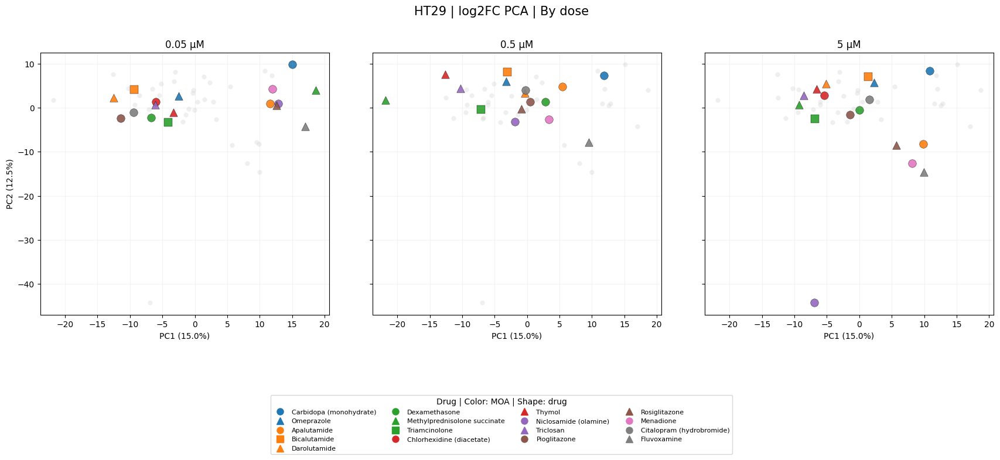

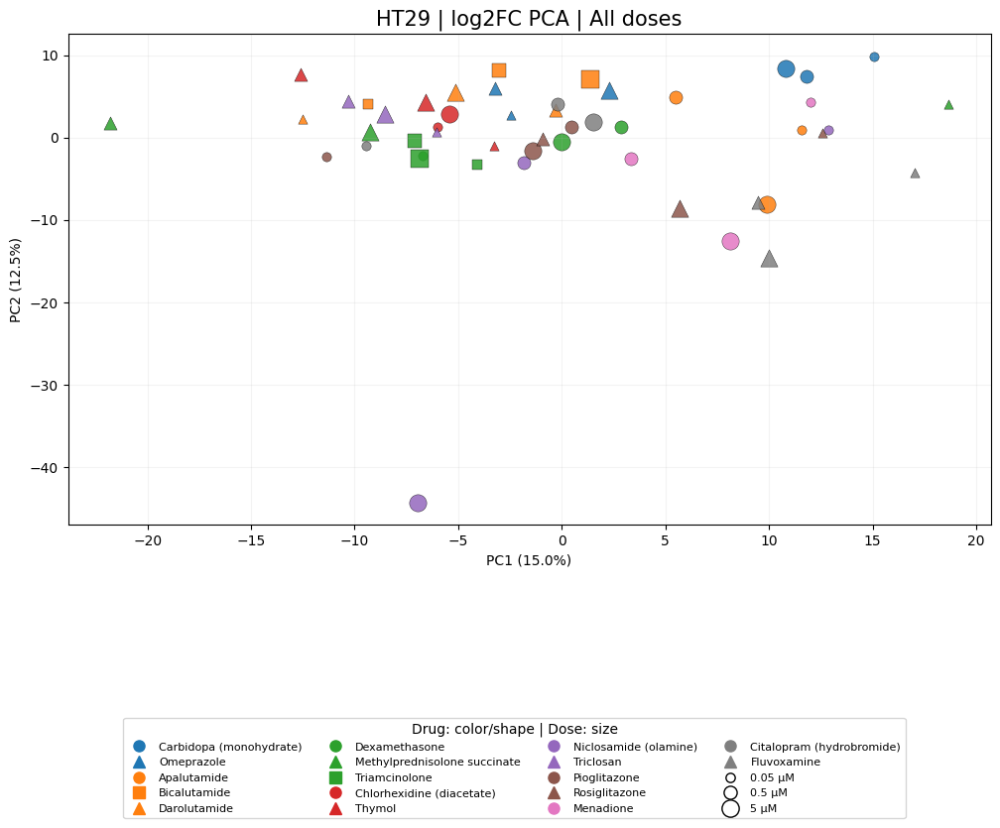

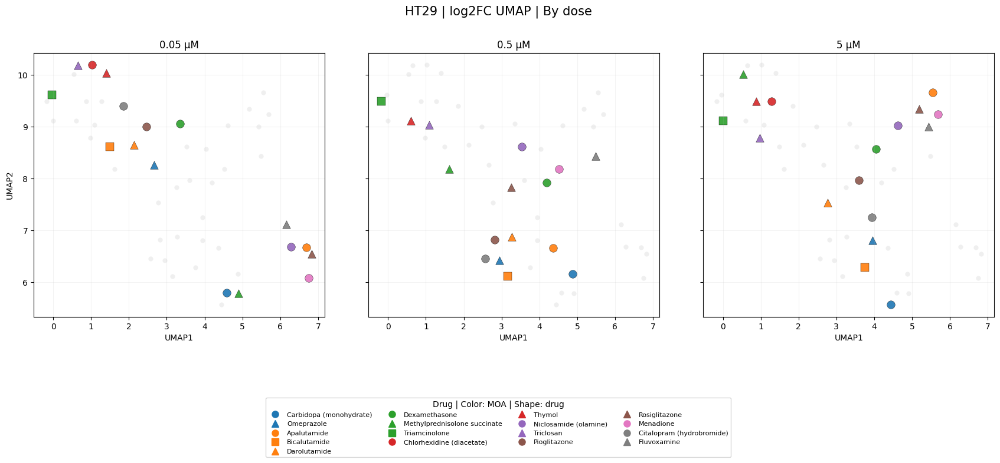

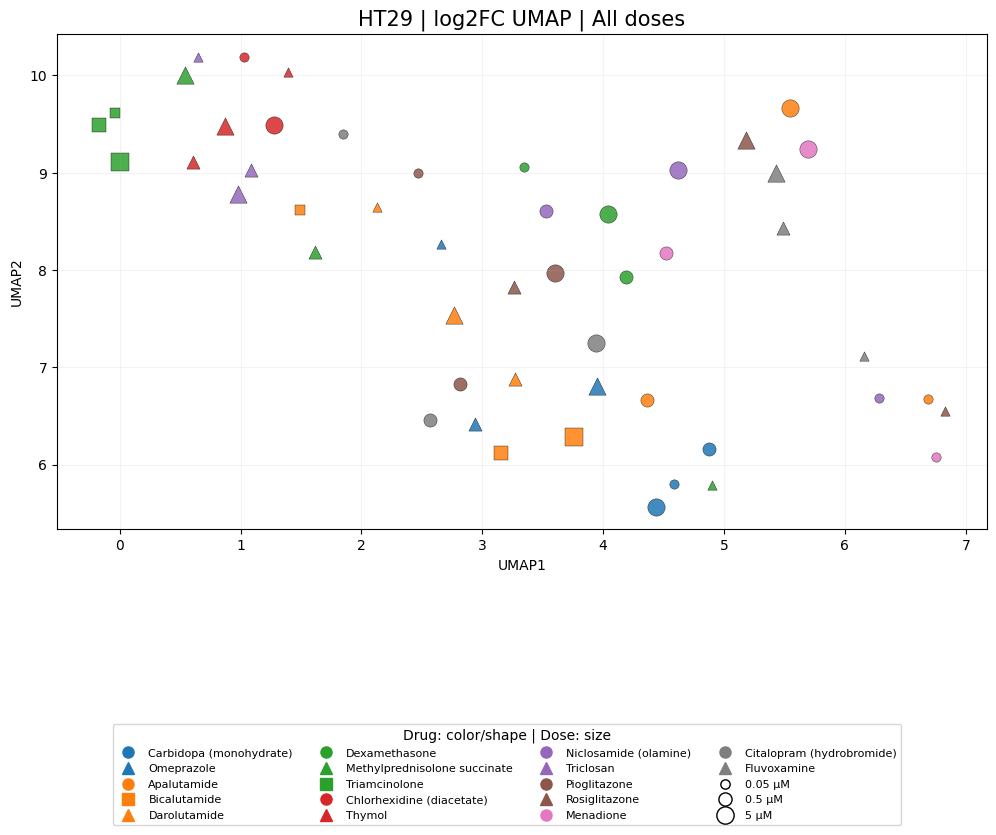


Processing: PANC1
Shared eligible genes: 14357
Selected genes: 2000
PCA variance explained: [0.134 0.122]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


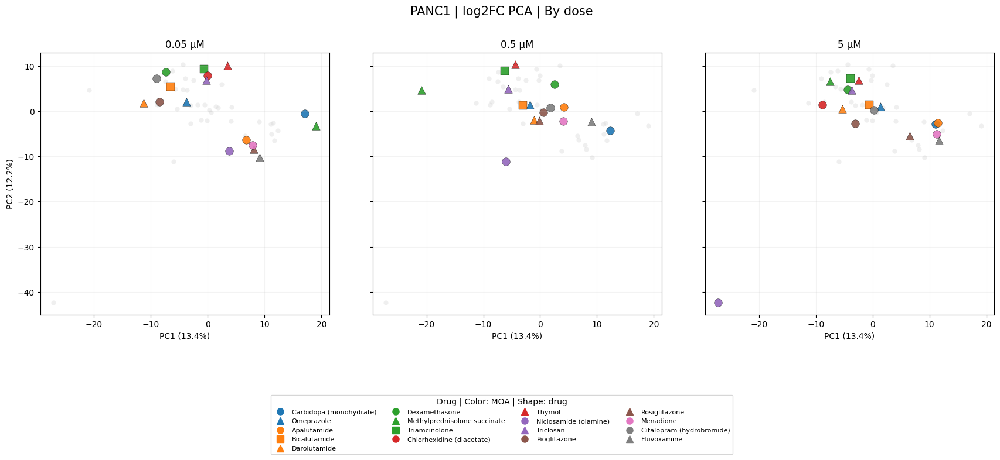

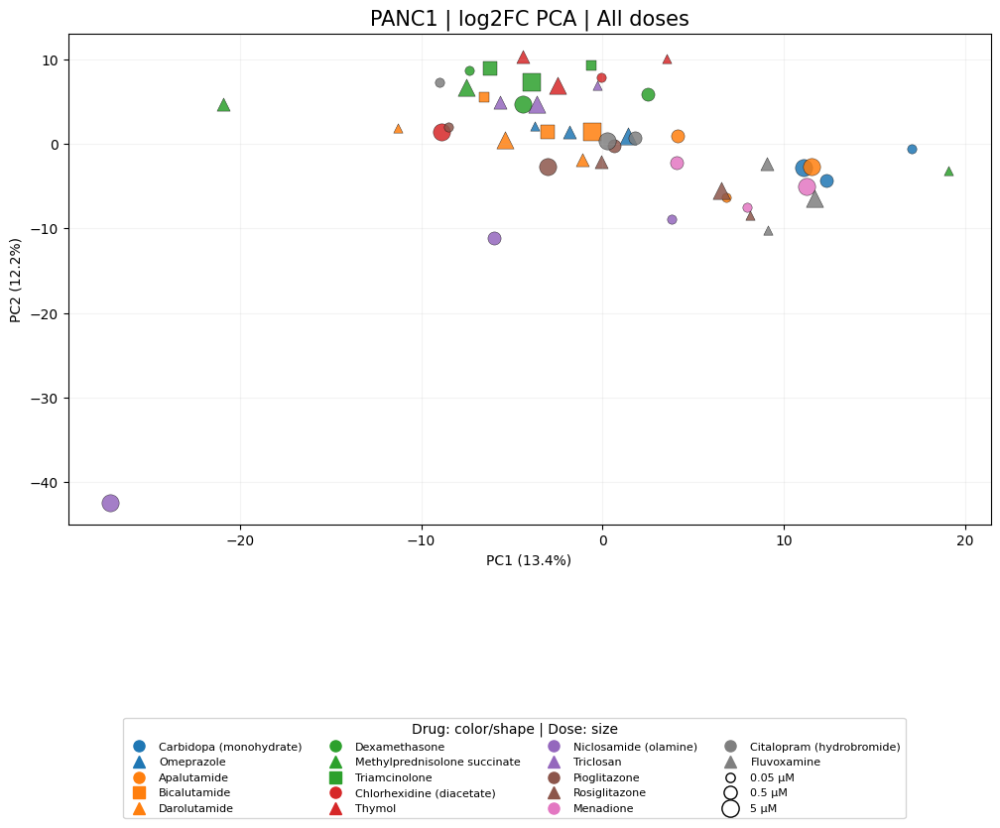

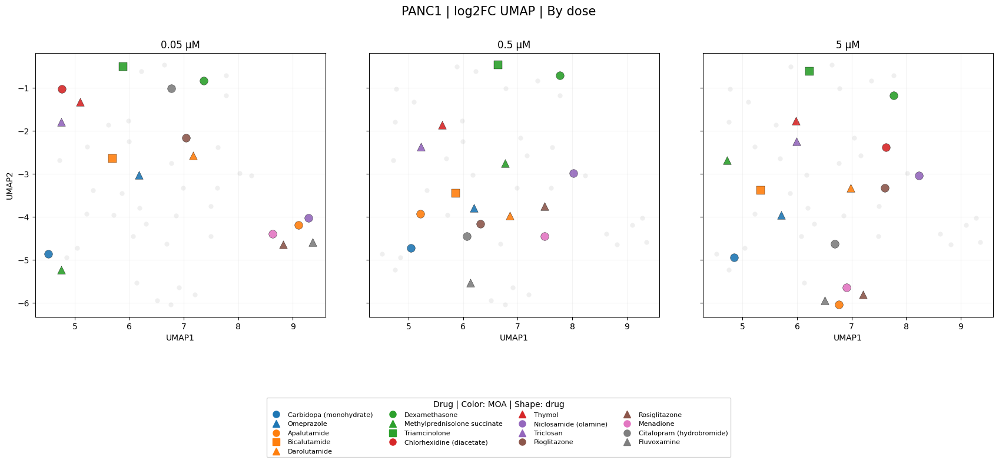

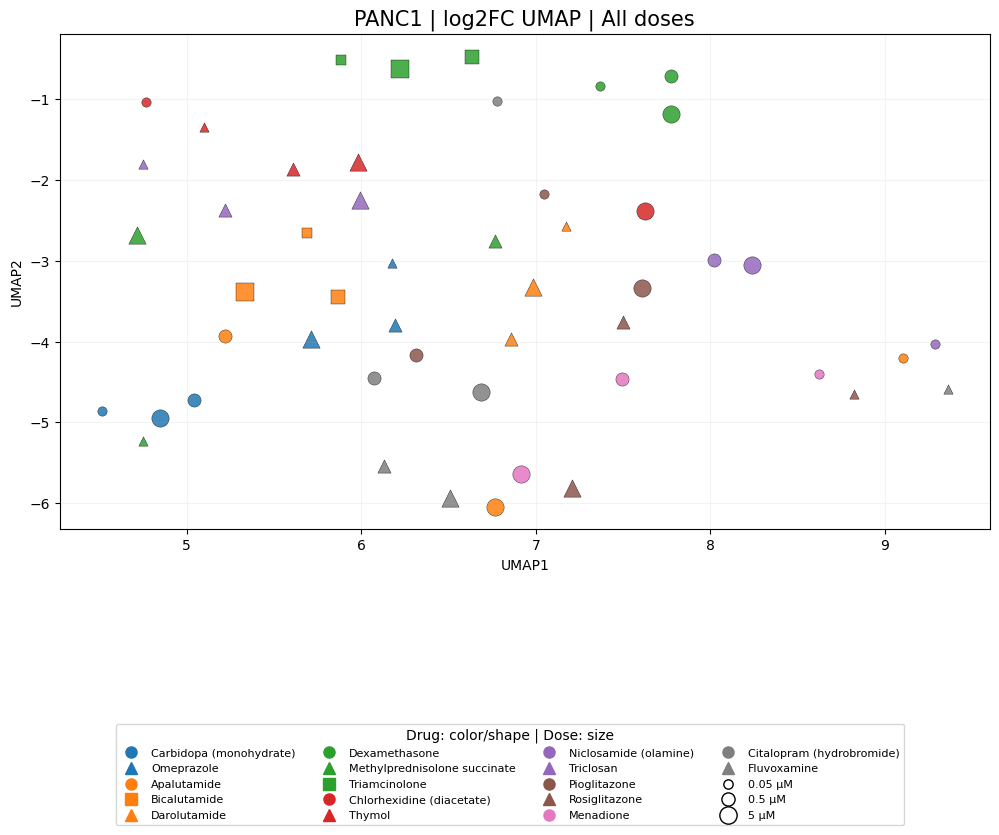


Processing: HepG2_C3A
Shared eligible genes: 8651
Selected genes: 2000
PCA variance explained: [0.232 0.087]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


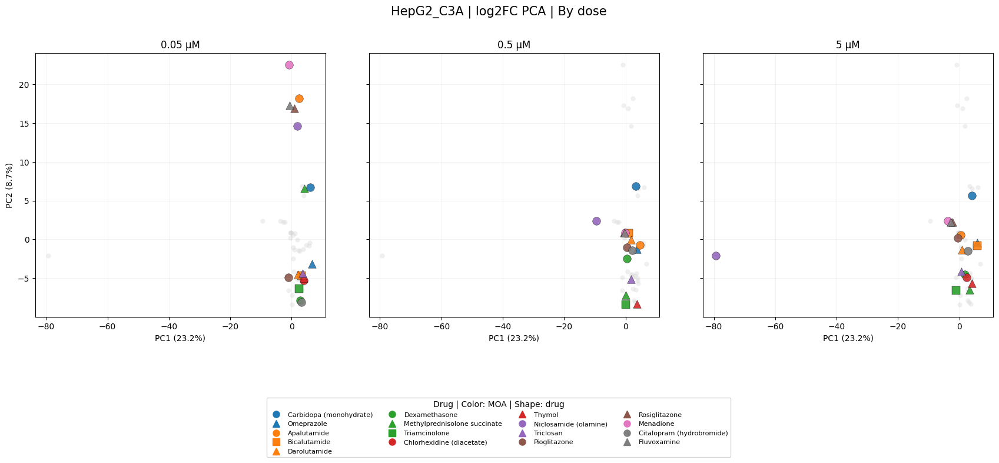

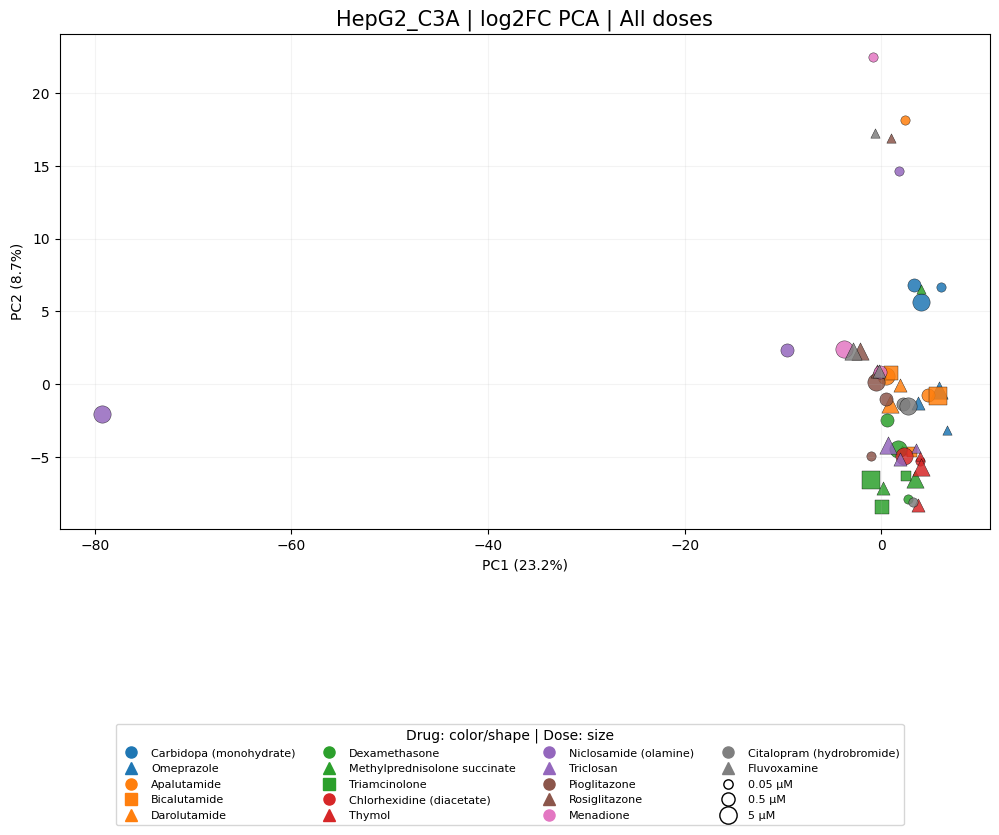

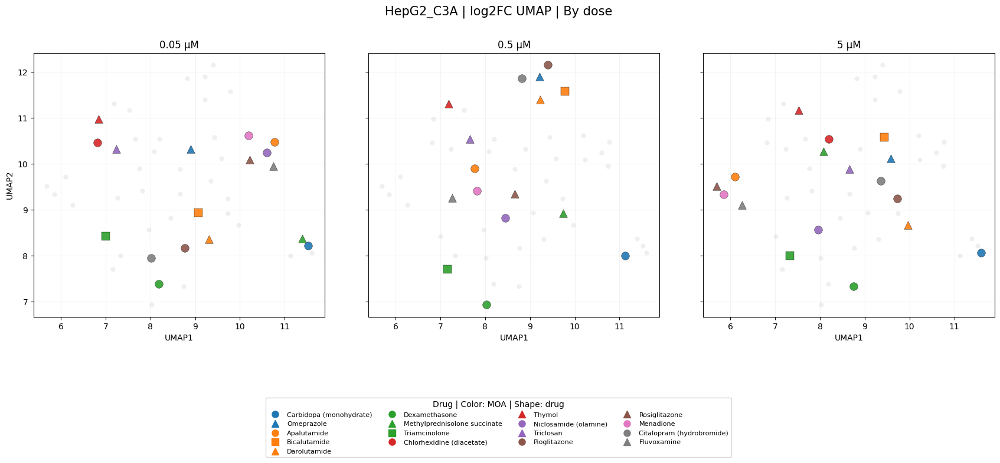

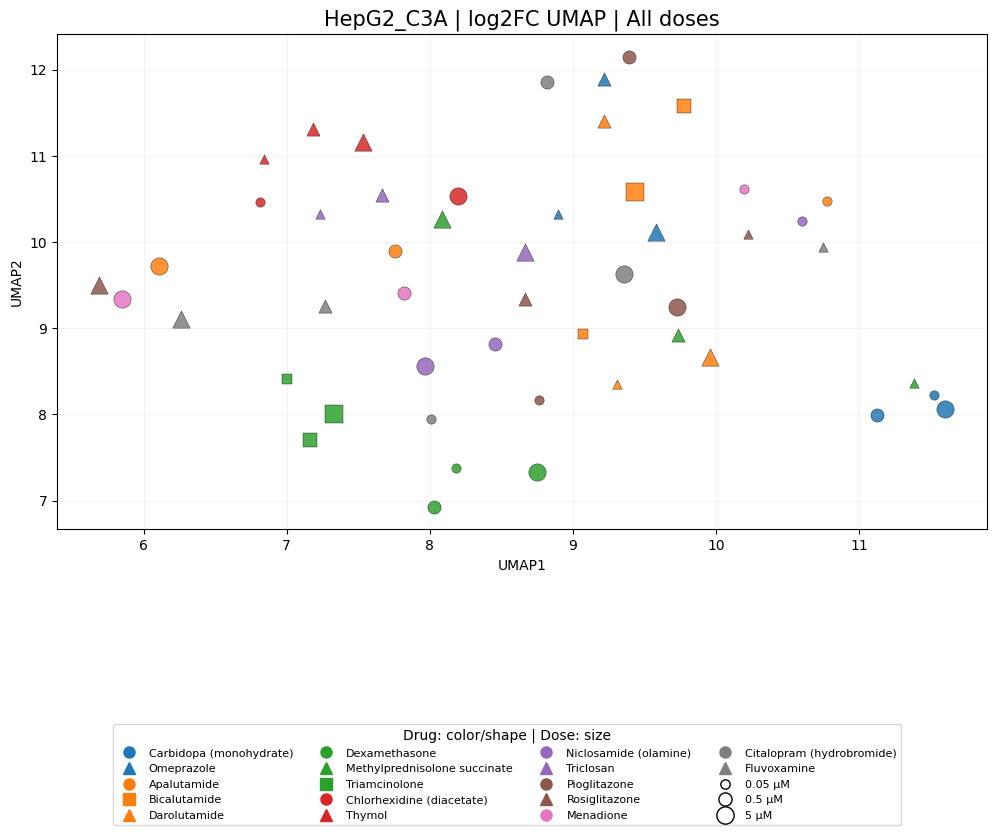


Processing: A172
Shared eligible genes: 12168
Selected genes: 2000
PCA variance explained: [0.153 0.127]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


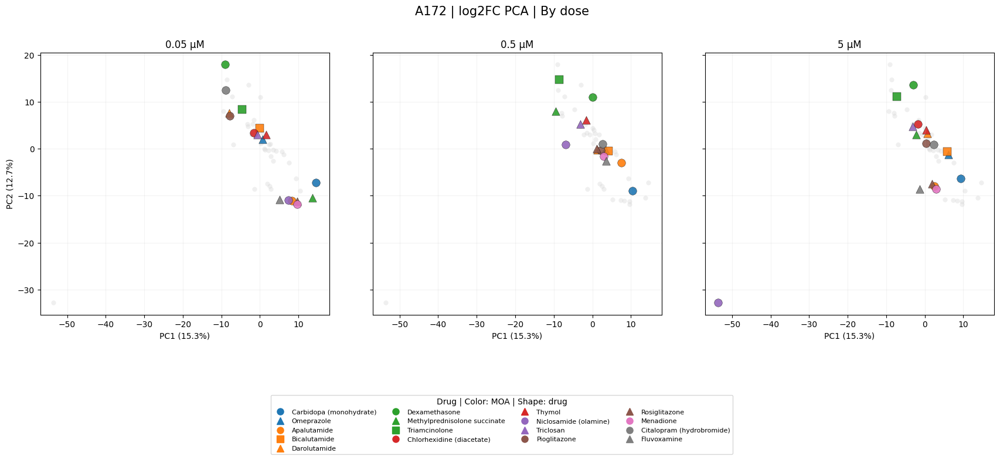

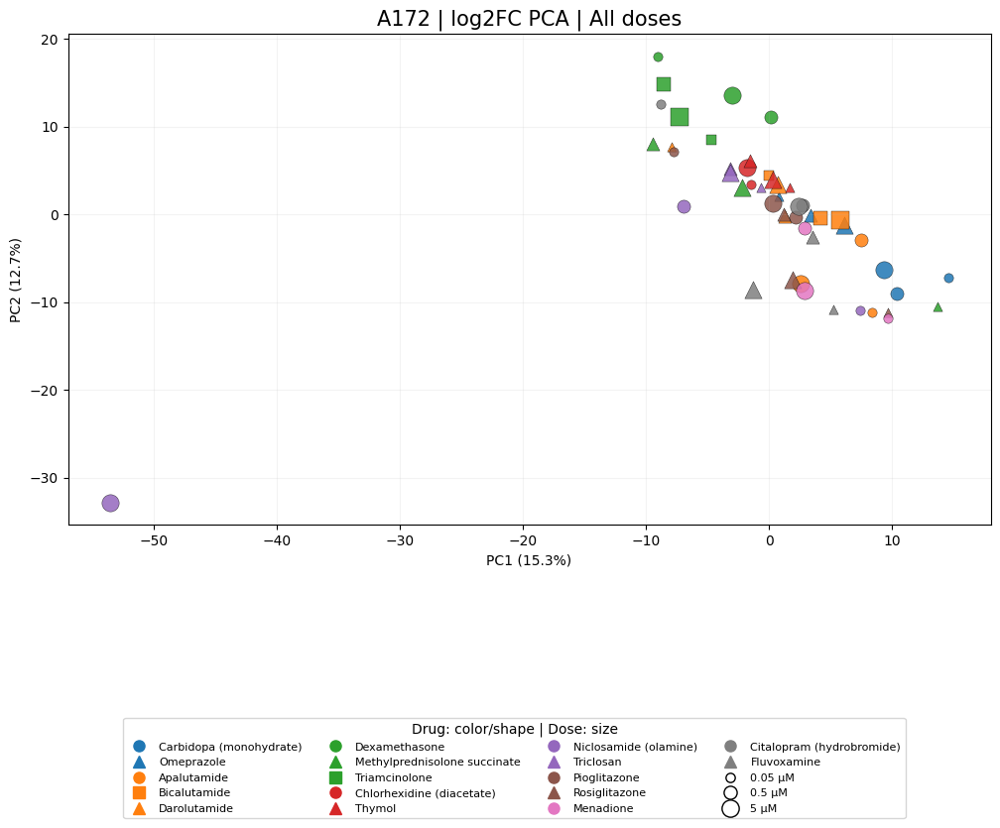

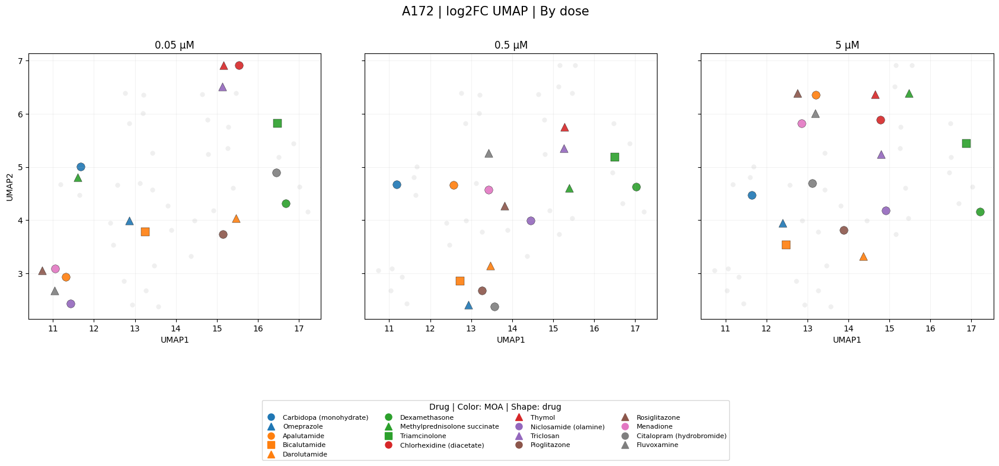

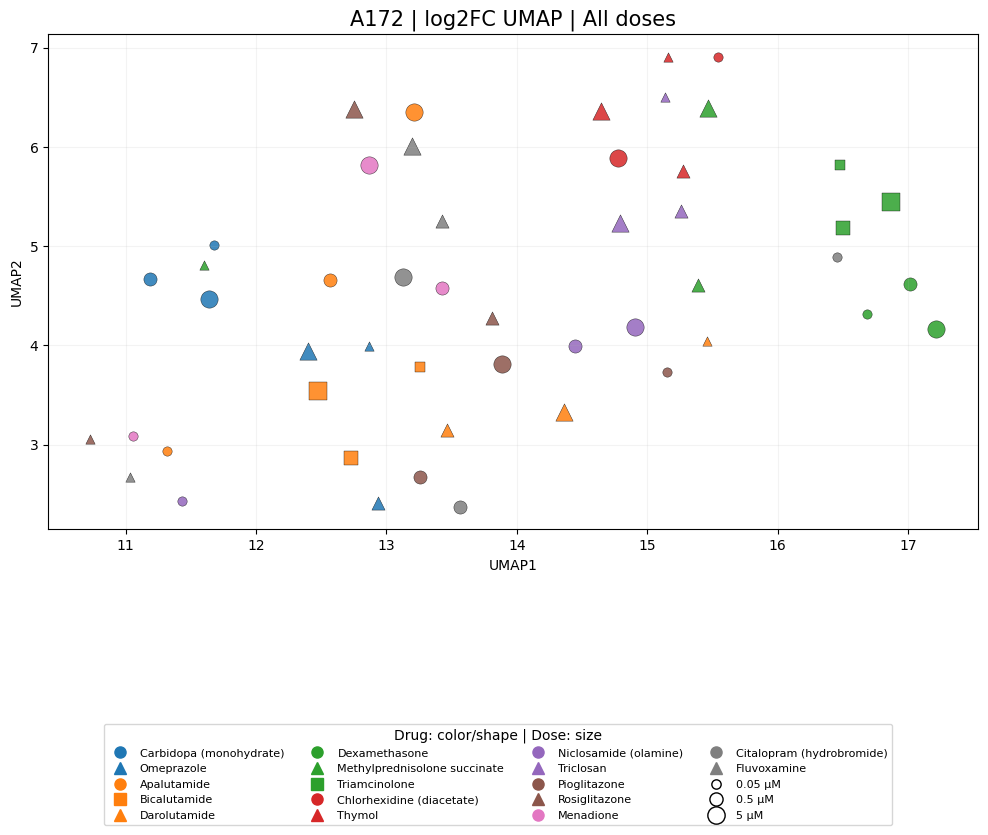


Processing: BT474
Shared eligible genes: 10176
Selected genes: 2000
PCA variance explained: [0.38  0.088]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


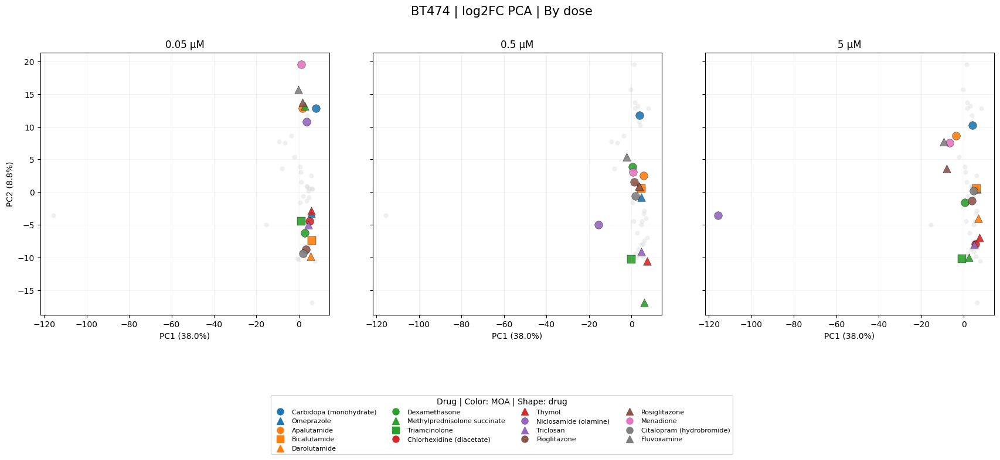

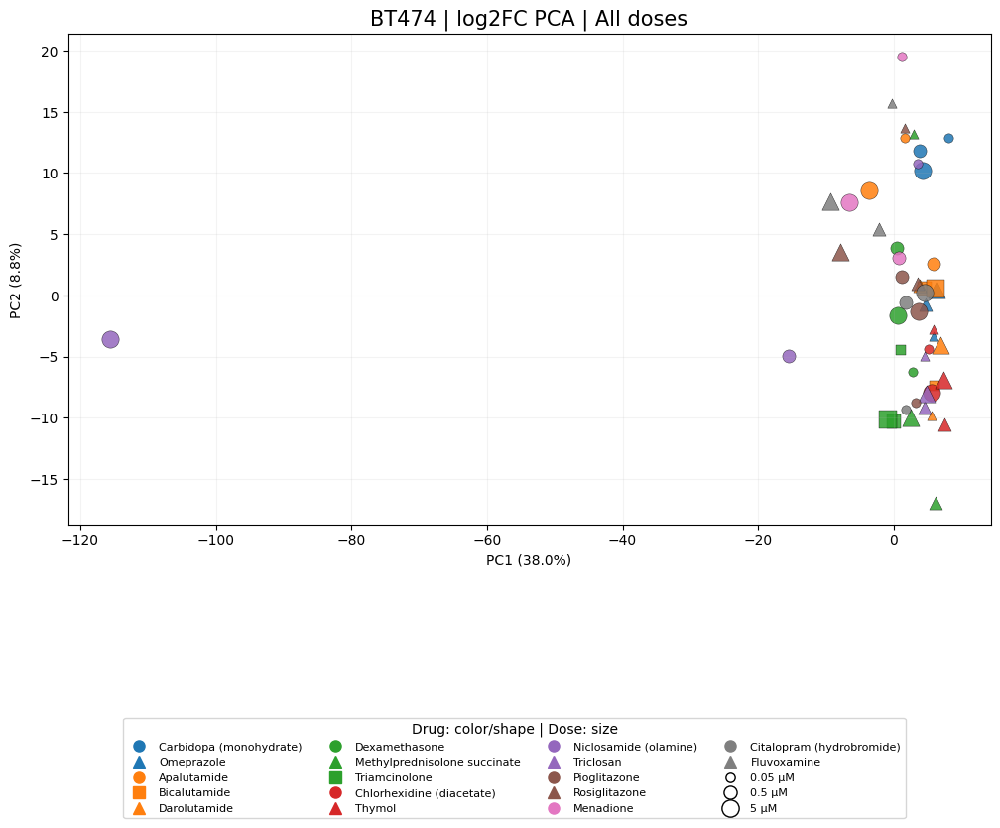

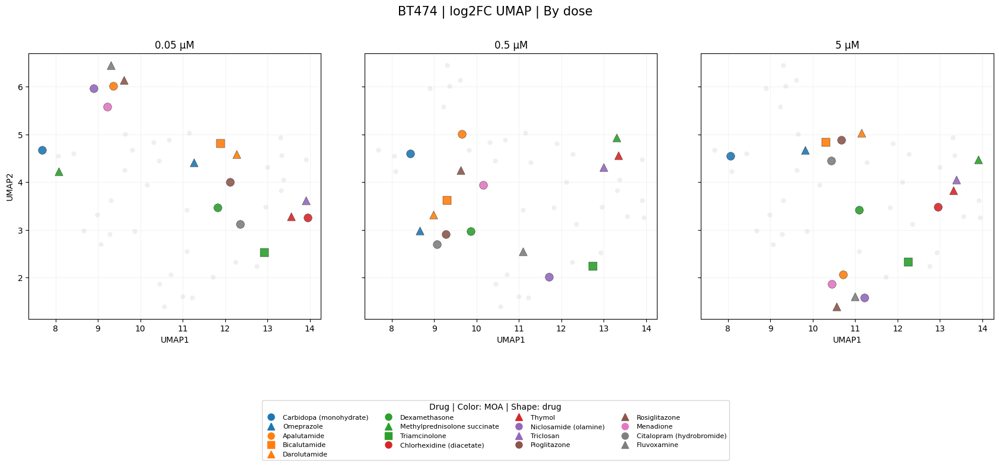

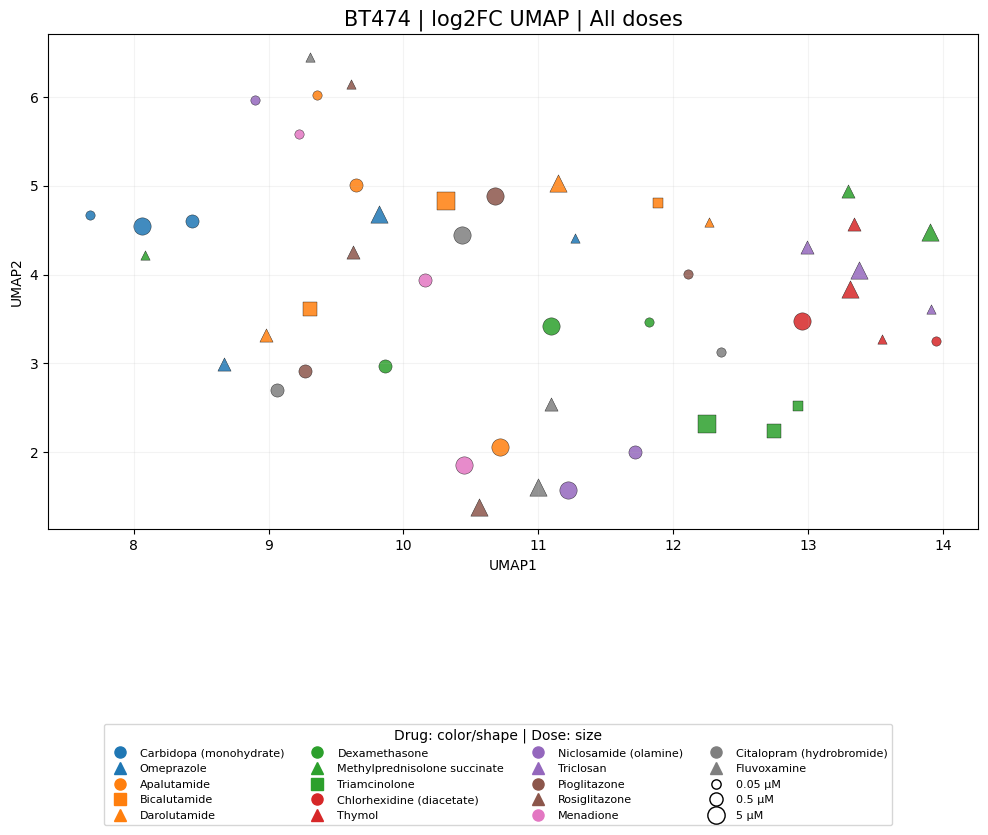


Completed all cell lines.


,cell_line,n_conditions,n_shared_eligible_genes,n_selected_genes,PC1_variance,PC2_variance,PCA_10PC_variance,UMAP_n_neighbors,UMAP_min_dist,random_seed
0,HT29,50,11370,2000,0.150,0.125,0.611,10,0.3,42
1,PANC1,50,14357,2000,0.134,0.122,0.634,10,0.3,42
2,HepG2_C3A,50,8651,2000,0.232,0.087,0.638,10,0.3,42
3,A172,50,12168,2000,0.153,0.127,0.648,10,0.3,42
4,BT474,50,10176,2000,0.380,0.088,0.727,10,0.3,42



Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/log2FC_embedding


In [ ]:
# Gene-level log2FC PCA & UMAP
# After expression-aware filtering

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from umap import UMAP


# ============================================================
# 1. Load saved results
# ============================================================

OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)

RESULTS = OUT.parent / "gene_pathway"

EMBED_DIR = RESULTS / "log2FC_embedding"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

lfc = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

moa = pd.read_csv(
    RESULTS / "drug_moa_annotations_with_family.csv"
)

assert lfc.shape == (250, 62710)
assert "expression_eligible" in lfc.layers
assert moa["drug"].is_unique

drug_family = (
    moa.set_index("drug")["moa_family"].to_dict()
)

drug_order = (
    moa.sort_values(["moa_family", "drug"])["drug"]
    .tolist()
)


# ============================================================
# 2. Plot settings
# ============================================================

CELL_LINES = [
    "HT29", "PANC1", "HepG2_C3A", "A172", "BT474"
]

DOSES = [0.05, 0.5, 5.0]

N_GENES = 2000
N_PCS = 10

family_color = {
    "AHR signaling activation": "#1f77b4",
    "Androgen receptor antagonist": "#ff7f0e",
    "Glucocorticoid receptor agonist": "#2ca02c",
    "Membrane perturbation": "#d62728",
    "Mitochondrial OXPHOS uncoupling": "#9467bd",
    "PPAR gamma agonist": "#8c564b",
    "Redox cycling": "#e377c2",
    "Serotonin reuptake inhibitor": "#7f7f7f",
}

drug_marker = {
    "Carbidopa (monohydrate)": "o",
    "Omeprazole": "^",

    "Apalutamide": "o",
    "Bicalutamide": "s",
    "Darolutamide": "^",

    "Dexamethasone": "o",
    "Methylprednisolone succinate": "^",
    "Triamcinolone": "s",

    "Chlorhexidine (diacetate)": "o",
    "Thymol": "^",

    "Niclosamide (olamine)": "o",
    "Triclosan": "^",

    "Pioglitazone": "o",
    "Rosiglitazone": "^",

    "Menadione": "o",

    "Citalopram (hydrobromide)": "o",
    "Fluvoxamine": "^",
}

assert set(moa["drug"]) == set(drug_marker)
assert set(moa["moa_family"]).issubset(family_color)

dose_sizes = {
    0.05: 45,
    0.5: 90,
    5.0: 155
}


# ============================================================
# 3. Legend
# ============================================================

drug_handles = []

for drug in drug_order:

    drug_handles.append(
        Line2D(
            [0], [0],
            marker=drug_marker[drug],
            linestyle="None",
            markerfacecolor=family_color[drug_family[drug]],
            markeredgecolor=family_color[drug_family[drug]],
            markersize=8,
            label=drug
        )
    )

dose_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=np.sqrt(dose_sizes[dose]),
        label=f"{dose:g} µM"
    )
    for dose in DOSES
]


# ============================================================
# 4. Plot function
# ============================================================

def plot_embedding(df, x, y, method, cell_line, xlabel, ylabel):

    # --------------------------------------------------------
    # A. By dose
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 3,
        figsize=(21, 8),
        sharex=True,
        sharey=True
    )

    for ax, dose in zip(axes, DOSES):

        # Other doses: gray background
        background = df.loc[
            df["concentration"] != dose
        ]

        ax.scatter(
            background[x],
            background[y],
            c="lightgray",
            s=35,
            alpha=0.35,
            linewidths=0
        )

        current = df.loc[
            df["concentration"] == dose
        ]

        for drug in drug_order:

            part = current.loc[
                current["drug"] == drug
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=95,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3
            )

        ax.set_title(f"{dose:g} µM")
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.15)

    axes[0].set_ylabel(ylabel)

    fig.suptitle(
        f"{cell_line} | log2FC {method} | By dose",
        fontsize=15
    )

    fig.legend(
        handles=drug_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug | Color: MOA | Shape: drug"
    )

    fig.subplots_adjust(
        bottom=0.32,
        top=0.88,
        wspace=0.15
    )

    path_dose = (
        EMBED_DIR / f"{cell_line}_{method}_by_dose.png"
    )

    fig.savefig(
        path_dose,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # B. All doses combined
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 9))

    for drug in drug_order:

        for dose in DOSES:

            part = df.loc[
                (df["drug"] == drug) &
                (df["concentration"] == dose)
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=dose_sizes[dose],
                alpha=0.85,
                edgecolors="black",
                linewidths=0.3
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_title(
        f"{cell_line} | log2FC {method} | All doses",
        fontsize=15
    )

    ax.grid(alpha=0.15)

    fig.legend(
        handles=drug_handles + dose_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug: color/shape | Dose: size"
    )

    fig.subplots_adjust(
        bottom=0.35,
        top=0.90
    )

    path_all = (
        EMBED_DIR / f"{cell_line}_{method}_all_doses.png"
    )

    fig.savefig(
        path_all,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 5. Cell-line-specific PCA and UMAP
# ============================================================

summary = []

for cell_line in CELL_LINES:

    print(f"\nProcessing: {cell_line}")

    # --------------------------------------------------------
    # A. One cell line
    # --------------------------------------------------------

    mask = (
        lfc.obs["cell_line"].astype(str) == cell_line
    )

    sub = lfc[mask]

    assert sub.n_obs == 50

    df = sub.obs[
        ["drug", "concentration", "signature_status"]
    ].copy()

    df["drug"] = df["drug"].astype(str)

    df["concentration"] = pd.to_numeric(
        df["concentration"].astype(str)
    )

    df["moa_family"] = df["drug"].map(drug_family)

    assert df["moa_family"].notna().all()


    # --------------------------------------------------------
    # B. Genes eligible in all 50 conditions
    # --------------------------------------------------------

    eligible = np.asarray(
        sub.layers["expression_eligible"],
        dtype=bool
    )

    shared_genes = eligible.all(axis=0)

    n_shared = int(shared_genes.sum())

    print("Shared eligible genes:", n_shared)

    assert n_shared >= 100, (
        f"{cell_line}: Too few shared eligible genes. "
        "Review feature selection."
    )

    X = np.asarray(
        sub.X[:, shared_genes],
        dtype=np.float32
    )

    assert np.isfinite(X).all()


    # --------------------------------------------------------
    # C. Select up to 2000 variable log2FC genes
    # --------------------------------------------------------

    variance = X.var(axis=0)

    variable_idx = np.flatnonzero(
        variance > 0
    )

    n_select = min(
        N_GENES,
        len(variable_idx)
    )

    assert n_select >= N_PCS

    selected_idx = variable_idx[
        np.argsort(
            -variance[variable_idx],
            kind="mergesort"
        )[:n_select]
    ]

    X_selected = X[:, selected_idx]

    selected_genes = (
        sub.var_names[shared_genes][selected_idx]
    )

    assert np.isfinite(X_selected).all()

    print("Selected genes:", len(selected_genes))


    # --------------------------------------------------------
    # D. PCA
    # --------------------------------------------------------

    pca = PCA(
        n_components=N_PCS,
        svd_solver="full"
    )

    pc = pca.fit_transform(X_selected)

    df["PC1"] = pc[:, 0]
    df["PC2"] = pc[:, 1]

    # Save all 10 PC scores
    for k in range(N_PCS):
        df[f"PC{k + 1}"] = pc[:, k]

    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]

    print(
        "PCA variance explained:",
        pca.explained_variance_ratio_[:2].round(3)
    )


    # --------------------------------------------------------
    # E. UMAP using 10 PCs
    # --------------------------------------------------------

    reducer = UMAP(
        n_neighbors=10,
        min_dist=0.3,
        n_components=2,
        metric="euclidean",
        random_state=42
    )

    xy = reducer.fit_transform(pc)

    df["UMAP1"] = xy[:, 0]
    df["UMAP2"] = xy[:, 1]

    # Save coordinates
    df.to_csv(
        EMBED_DIR / f"{cell_line}_embedding_coordinates.csv",
        index_label="condition_id"
    )

    pd.DataFrame({
        "gene_id": selected_genes,
        "gene_symbol": sub.var.loc[
            selected_genes, "gene_symbol"
        ].to_numpy()
    }).to_csv(
        EMBED_DIR / f"{cell_line}_selected_genes.csv",
        index=False
    )


    # --------------------------------------------------------
    # F. PCA figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="PC1",
        y="PC2",
        method="PCA",
        cell_line=cell_line,
        xlabel=f"PC1 ({pc1_var:.1%})",
        ylabel=f"PC2 ({pc2_var:.1%})"
    )


    # --------------------------------------------------------
    # G. UMAP figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="UMAP1",
        y="UMAP2",
        method="UMAP",
        cell_line=cell_line,
        xlabel="UMAP1",
        ylabel="UMAP2"
    )


    summary.append({
        "cell_line": cell_line,
        "n_conditions": len(df),
        "n_shared_eligible_genes": n_shared,
        "n_selected_genes": len(selected_genes),
        "PC1_variance": pc1_var,
        "PC2_variance": pc2_var,
        "PCA_10PC_variance": (
            pca.explained_variance_ratio_.sum()
        ),
        "UMAP_n_neighbors": 10,
        "UMAP_min_dist": 0.3,
        "random_seed": 42
    })

    del sub, eligible, X, X_selected, pc, xy


# ============================================================
# 6. Save summary
# ============================================================

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    EMBED_DIR / "log2FC_embedding_summary.csv",
    index=False
)

print("\nCompleted all cell lines.")
display(summary_df.round(3))

print("\nSaved to:", EMBED_DIR)

In [ ]:
# Niclosmide (olamine) - 5 um 가 지속적으로 outlier -> 제외하고 다시 PCA 및 umap 해보기

# Sensitivity analysis - PCA, UMAP except Niclosmide (olamine) 5 uM

Excluded conditions: 5


,cell_line,drug,concentration
condition_id,,,
HT29__Niclosamide (olamine)__5,HT29,Niclosamide (olamine),5.0
PANC1__Niclosamide (olamine)__5,PANC1,Niclosamide (olamine),5.0
HepG2_C3A__Niclosamide (olamine)__5,HepG2_C3A,Niclosamide (olamine),5.0
A172__Niclosamide (olamine)__5,A172,Niclosamide (olamine),5.0
BT474__Niclosamide (olamine)__5,BT474,Niclosamide (olamine),5.0



Processing: HT29
HT29: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 11425
Selected genes: 2000
PCA variance explained: [0.165 0.1  ]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


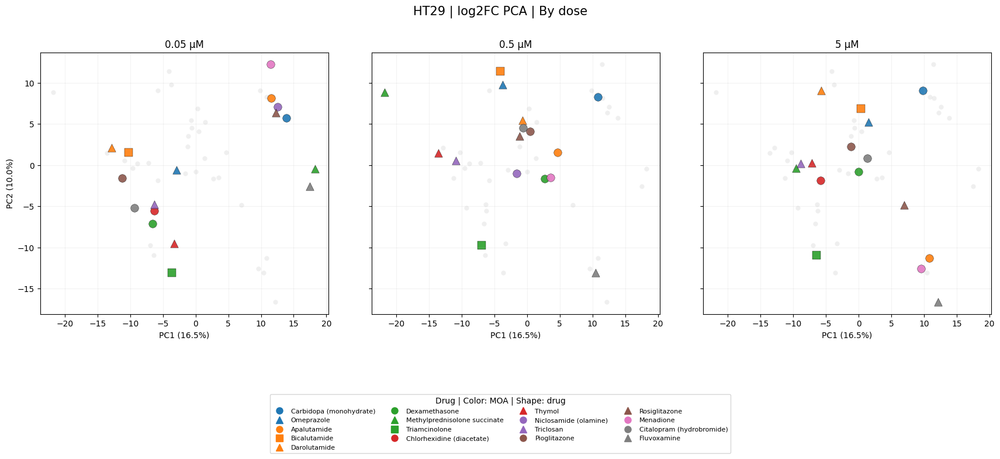

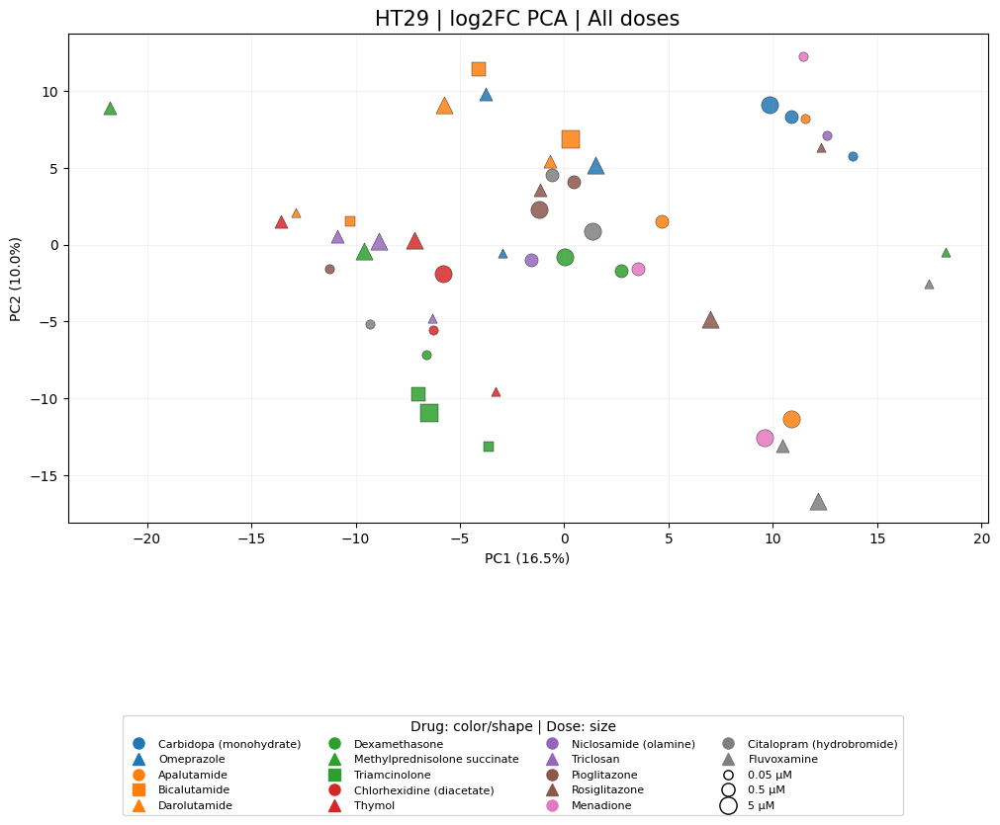

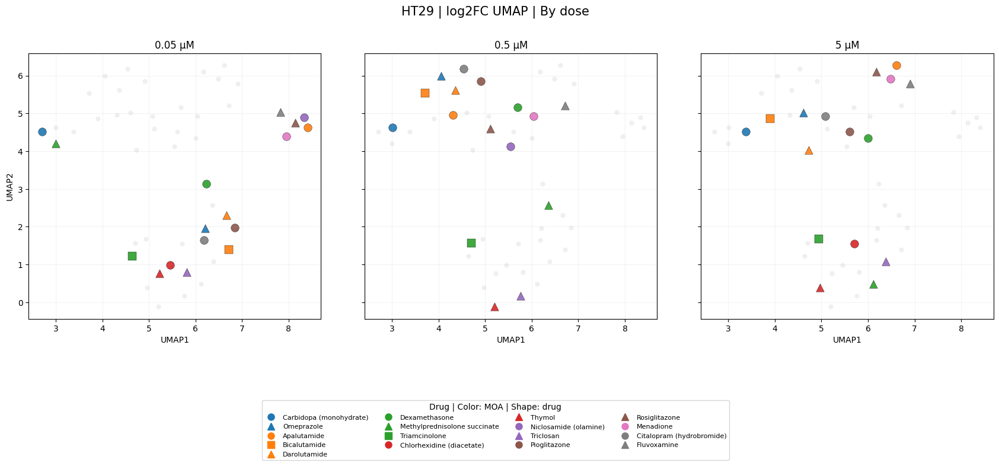

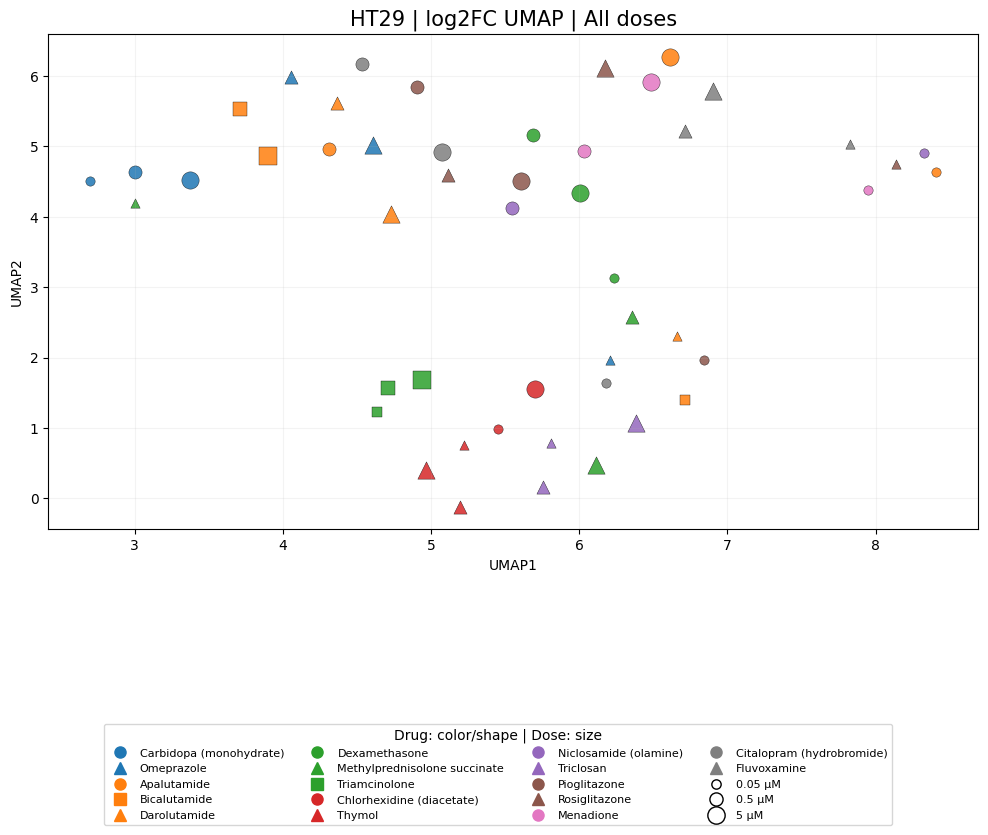


Processing: PANC1
PANC1: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 14413
Selected genes: 2000
PCA variance explained: [0.147 0.107]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


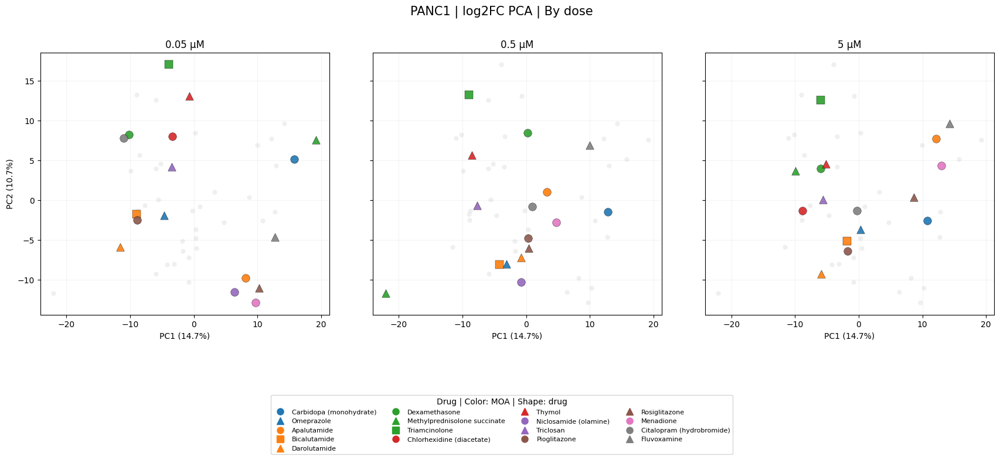

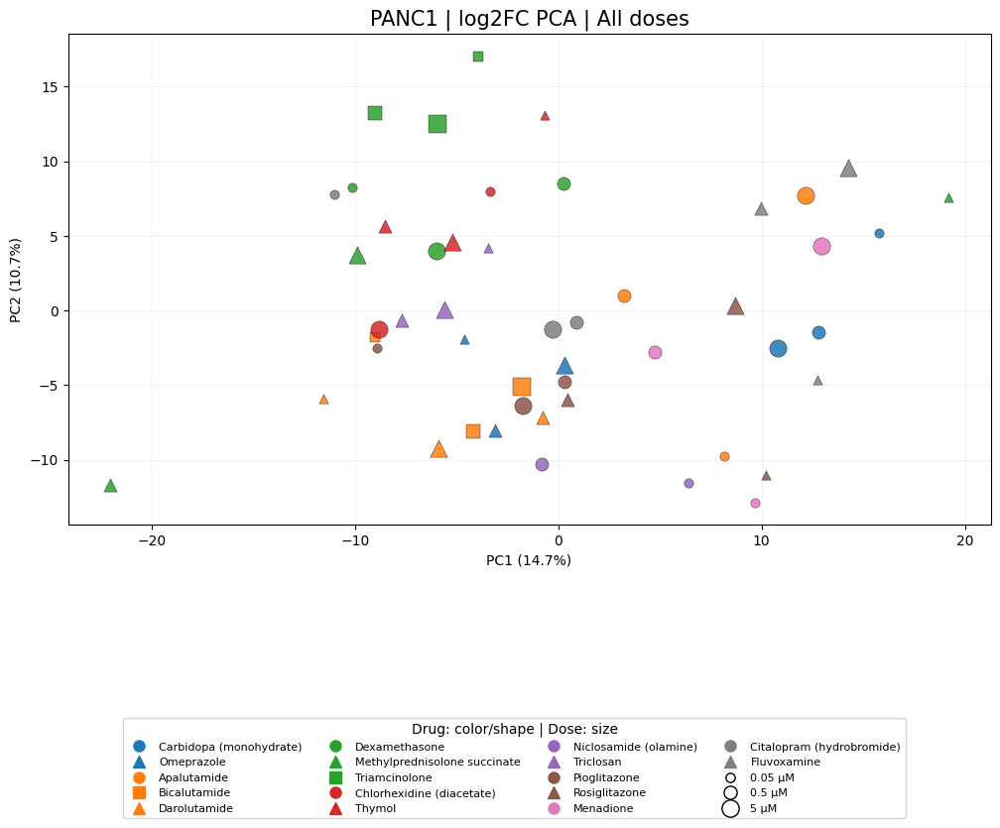

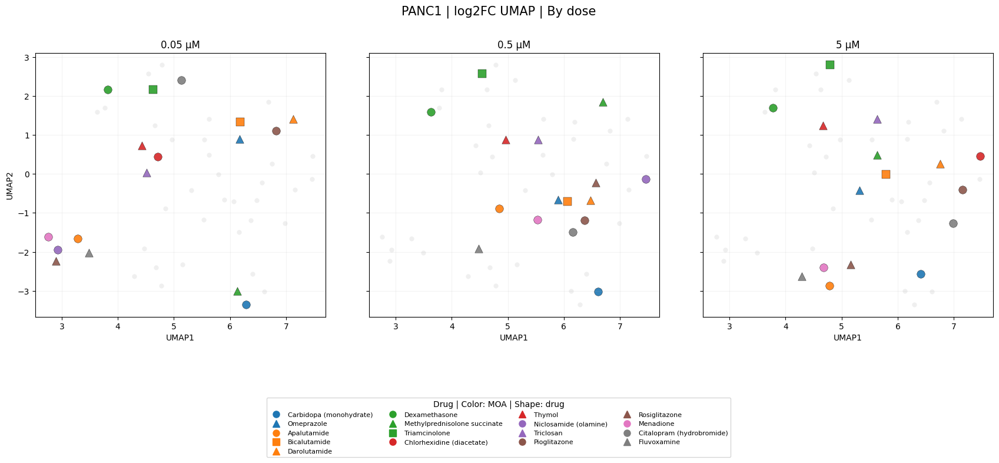

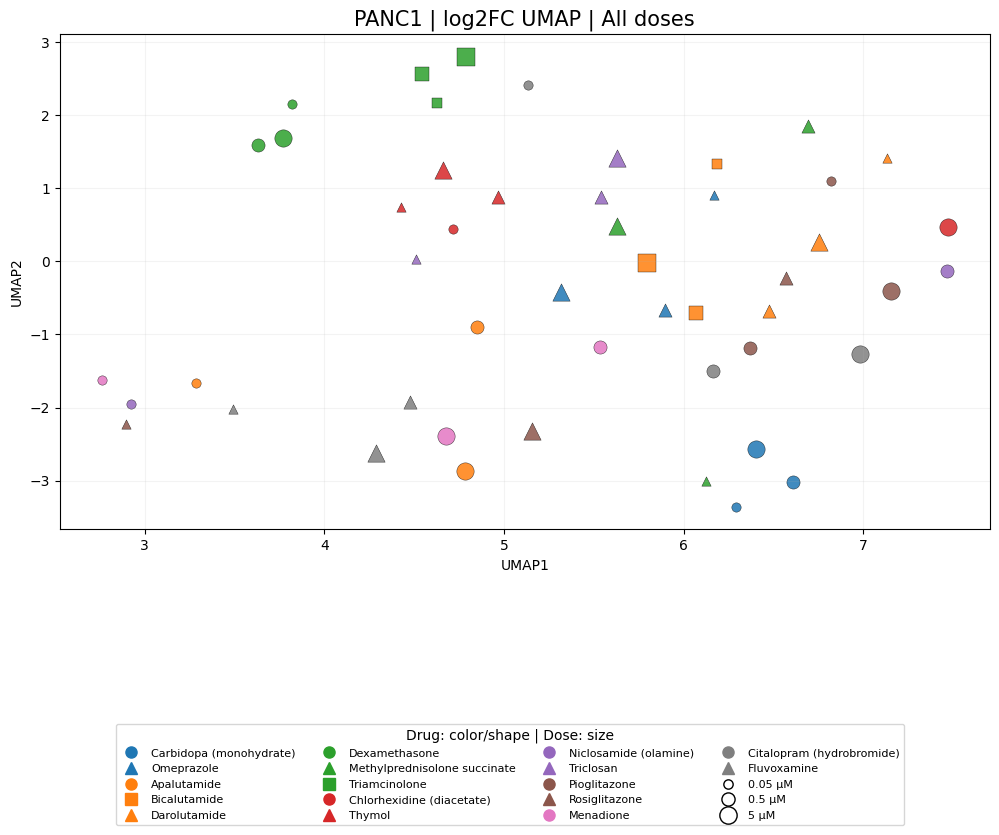


Processing: HepG2_C3A
HepG2_C3A: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 8756
Selected genes: 2000
PCA variance explained: [0.112 0.097]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


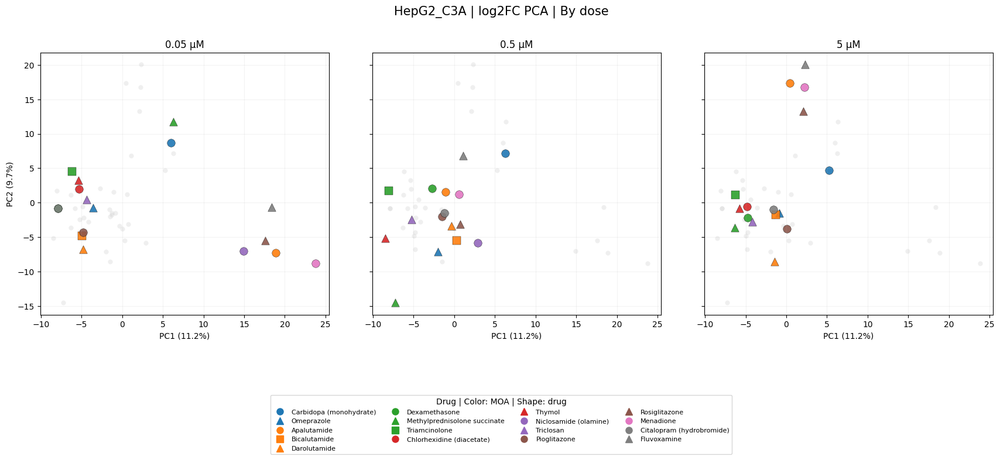

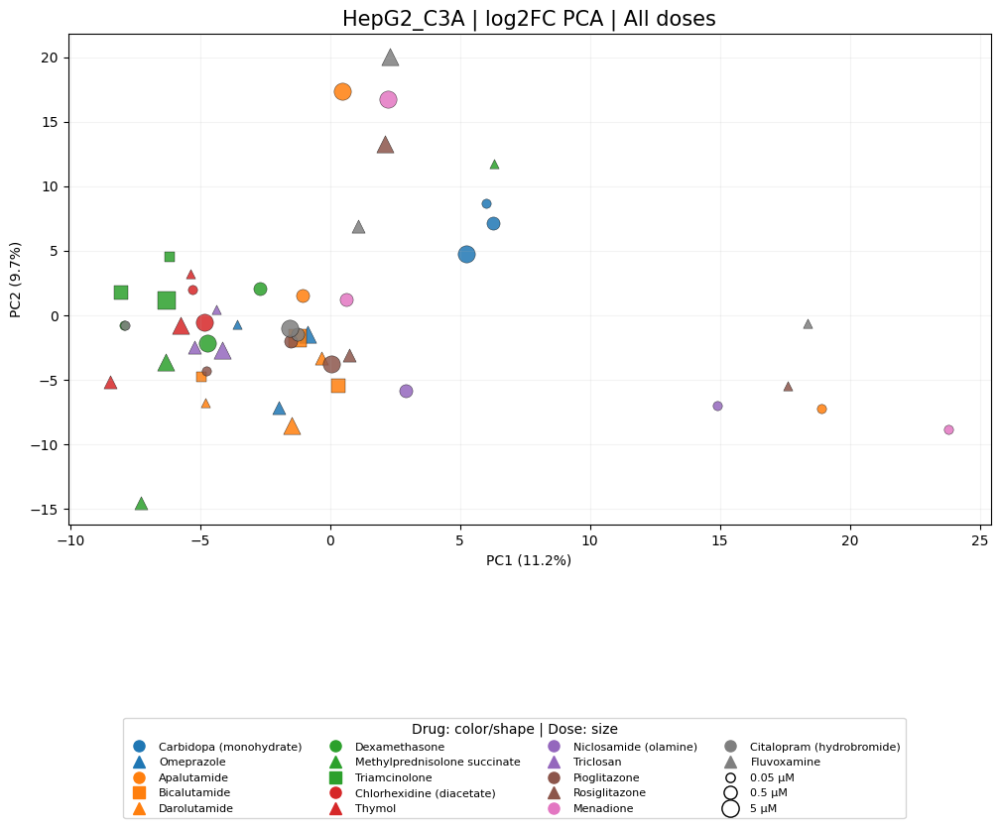

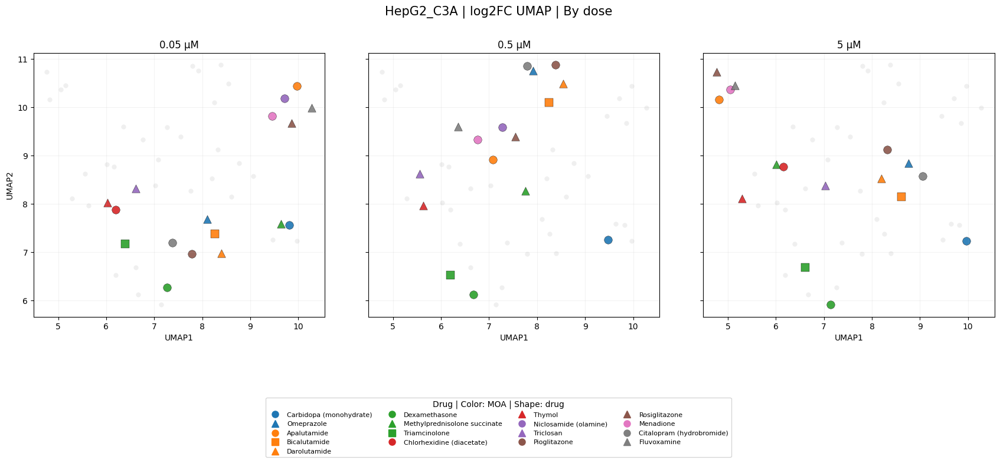

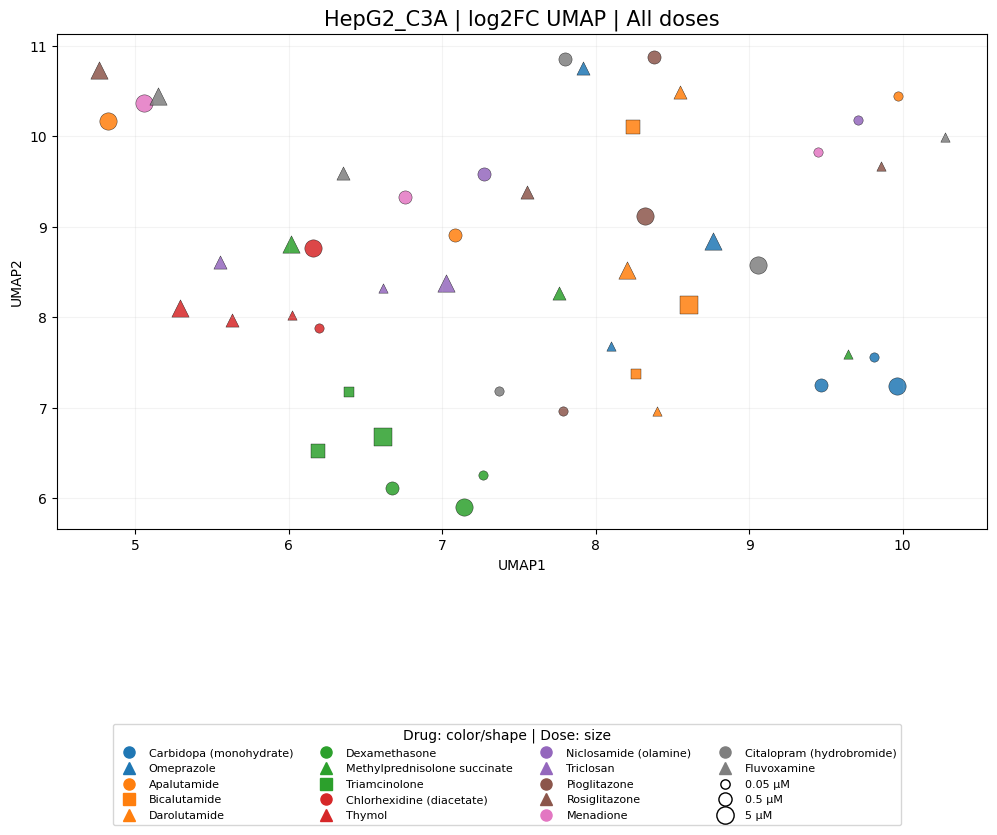


Processing: A172
A172: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 12219
Selected genes: 2000
PCA variance explained: [0.155 0.095]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


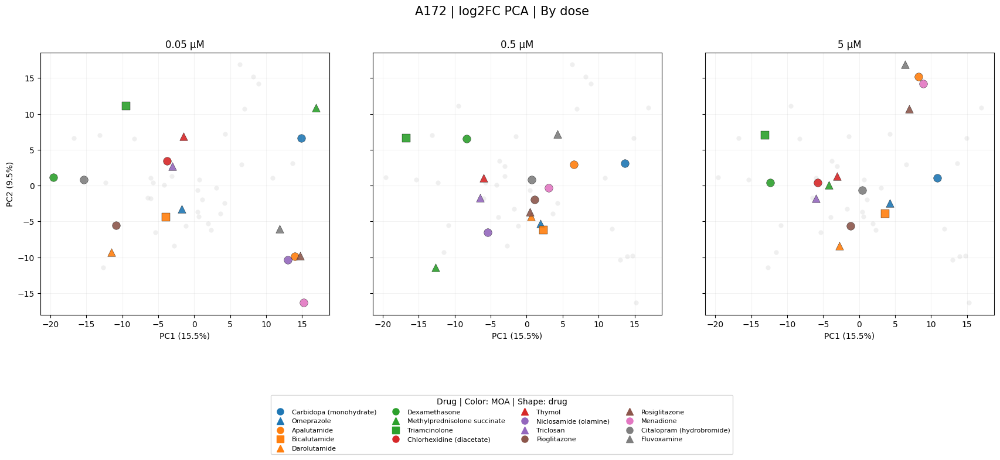

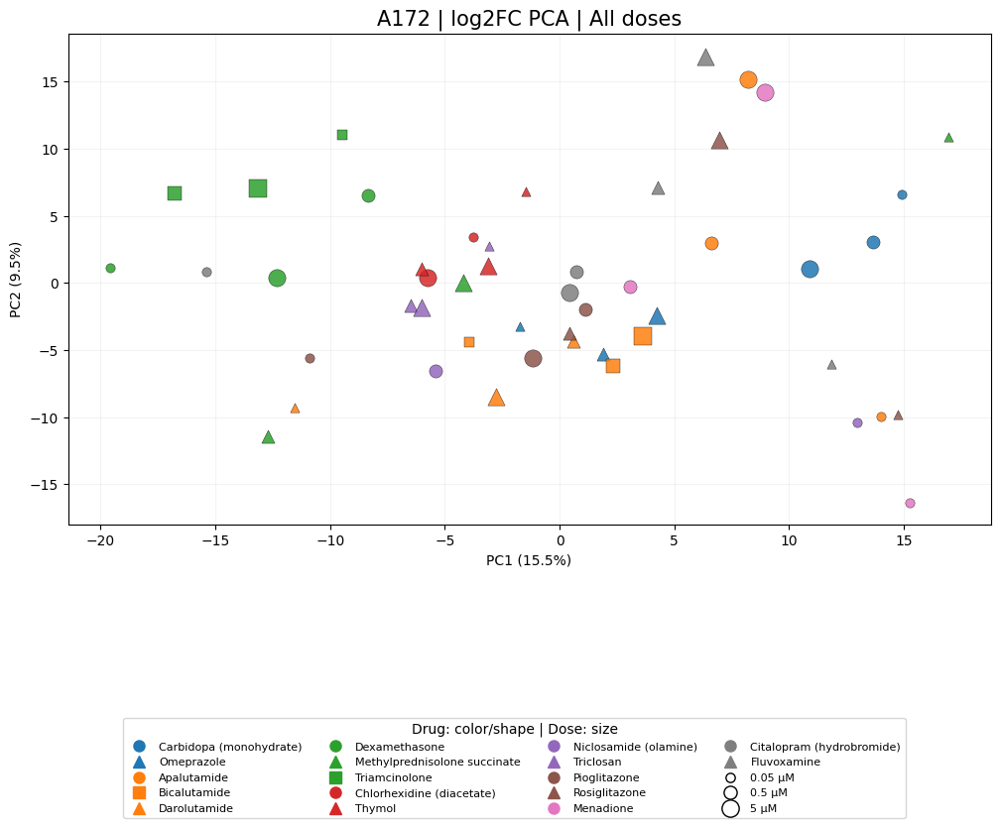

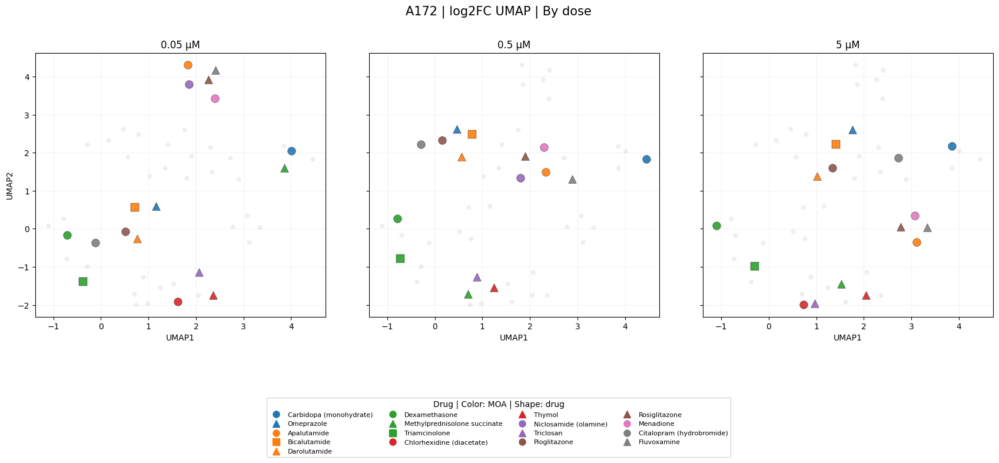

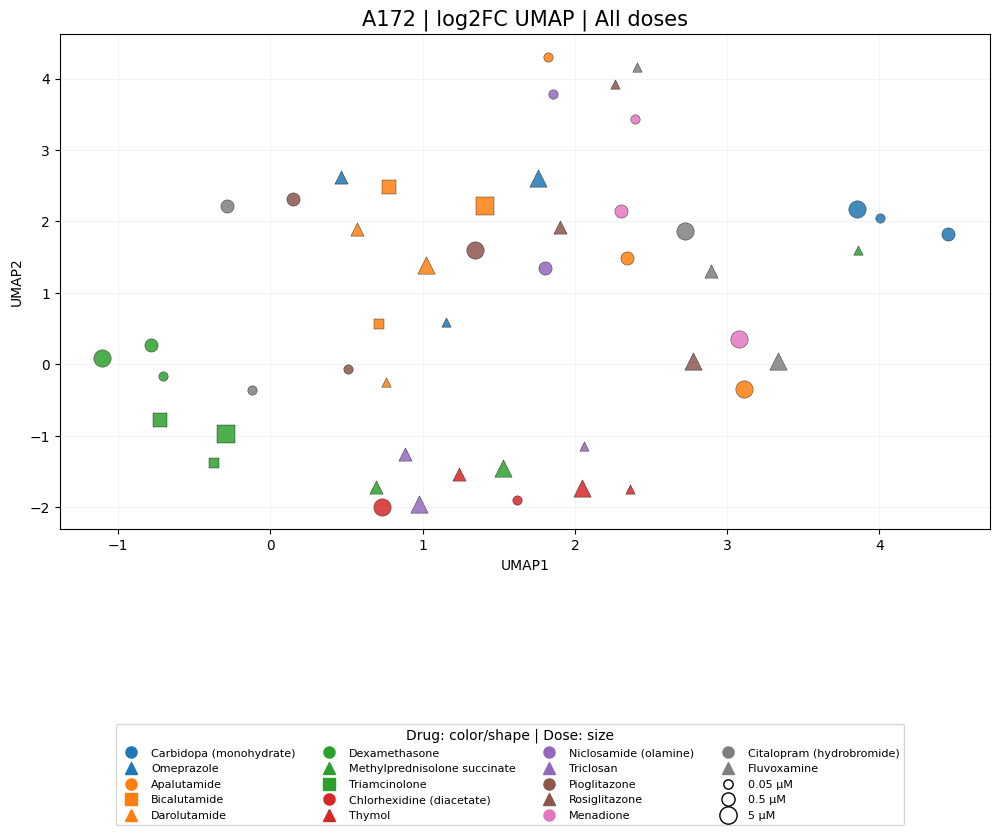


Processing: BT474
BT474: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 10315
Selected genes: 2000
PCA variance explained: [0.14  0.101]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


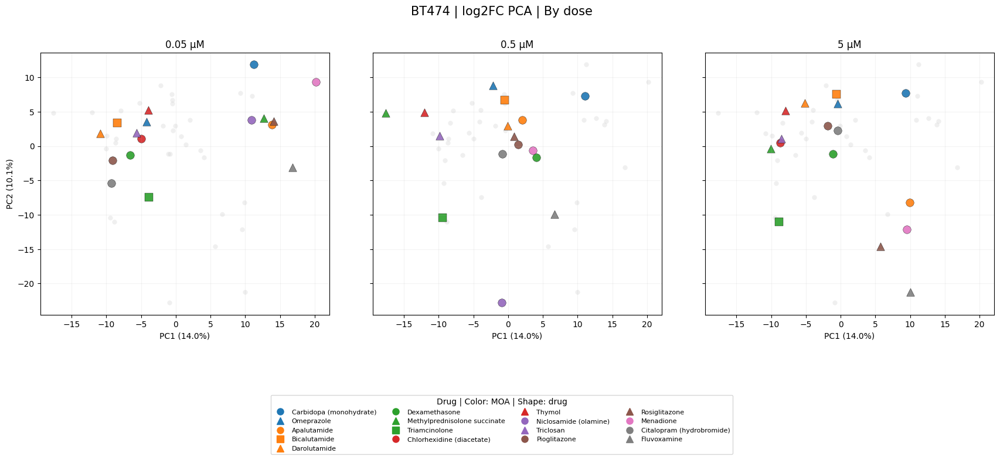

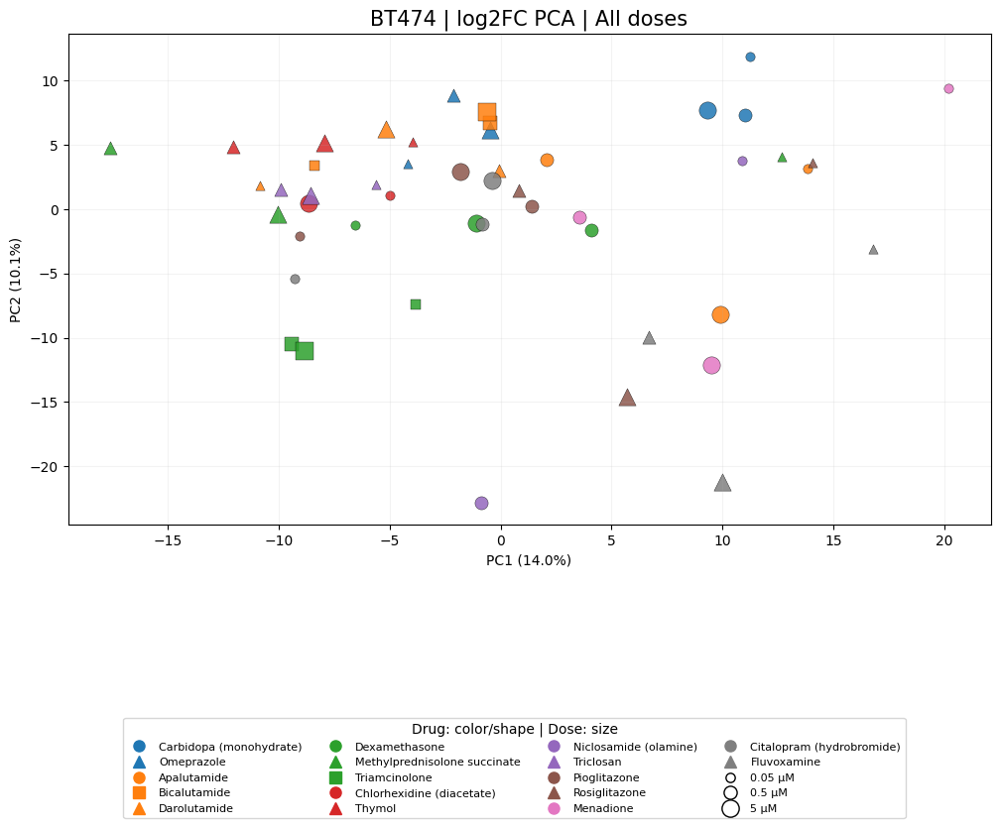

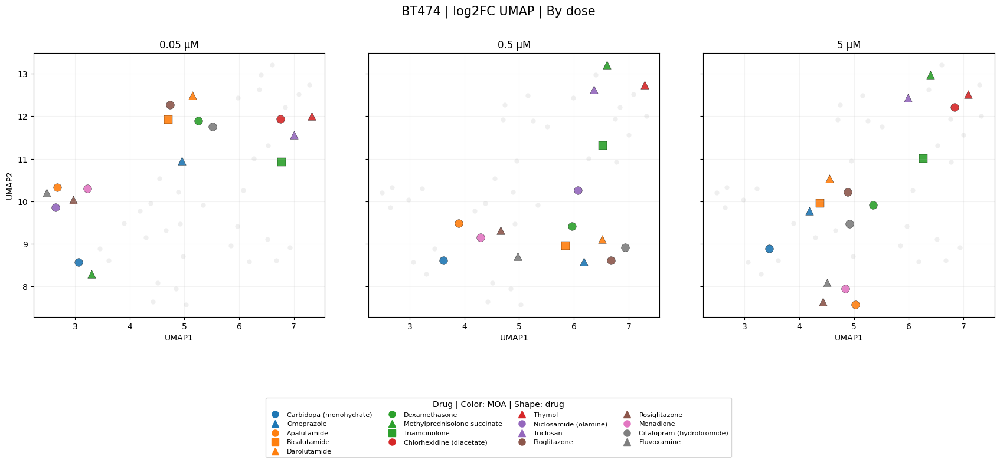

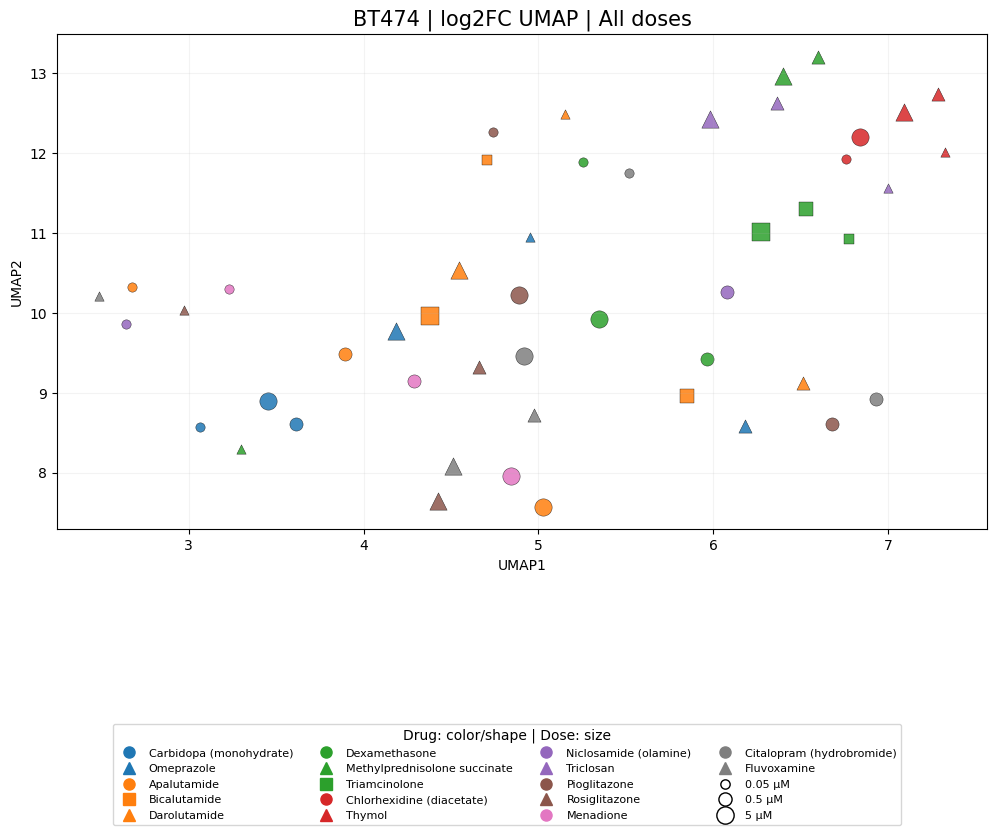


Completed all cell lines.


,cell_line,n_conditions,n_shared_eligible_genes,n_selected_genes,PC1_variance,PC2_variance,PCA_10PC_variance,UMAP_n_neighbors,UMAP_min_dist,random_seed
0,HT29,49,11425,2000,0.165,0.100,0.593,10,0.3,42
1,PANC1,49,14413,2000,0.147,0.107,0.614,10,0.3,42
2,HepG2_C3A,49,8756,2000,0.112,0.097,0.562,10,0.3,42
3,A172,49,12219,2000,0.155,0.095,0.617,10,0.3,42
4,BT474,49,10315,2000,0.140,0.101,0.594,10,0.3,42



Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/log2FC_embedding_without_Niclosamide5


In [ ]:
# Gene-level log2FC PCA & UMAP
# After expression-aware filtering

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from umap import UMAP


# ============================================================
# 1. Load saved results
# ============================================================

OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)

RESULTS = OUT.parent / "gene_pathway"

EMBED_DIR = RESULTS / "log2FC_embedding_without_Niclosamide5"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

lfc = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

moa = pd.read_csv(
    RESULTS / "drug_moa_annotations_with_family.csv"
)

assert lfc.shape == (250, 62710)
assert "expression_eligible" in lfc.layers
assert moa["drug"].is_unique

drug_family = (
    moa.set_index("drug")["moa_family"].to_dict()
)

drug_order = (
    moa.sort_values(["moa_family", "drug"])["drug"]
    .tolist()
)


# ============================================================
# 2. Plot settings
# ============================================================

CELL_LINES = [
    "HT29", "PANC1", "HepG2_C3A", "A172", "BT474"
]

DOSES = [0.05, 0.5, 5.0]

# Sensitivity analysis:
# Exclude Niclosamide (olamine) 5 µM from PCA and UMAP

exclude_niclo5 = (
    lfc.obs["drug"].astype(str).eq("Niclosamide (olamine)")
    &
    np.isclose(
        pd.to_numeric(
            lfc.obs["concentration"].astype(str),
            errors="coerce"
        ),
        5.0
    )
)

print("Excluded conditions:", exclude_niclo5.sum())

display(
    lfc.obs.loc[
        exclude_niclo5,
        ["cell_line", "drug", "concentration"]
    ]
)

assert exclude_niclo5.sum() == 5


N_GENES = 2000
N_PCS = 10

family_color = {
    "AHR signaling activation": "#1f77b4",
    "Androgen receptor antagonist": "#ff7f0e",
    "Glucocorticoid receptor agonist": "#2ca02c",
    "Membrane perturbation": "#d62728",
    "Mitochondrial OXPHOS uncoupling": "#9467bd",
    "PPAR gamma agonist": "#8c564b",
    "Redox cycling": "#e377c2",
    "Serotonin reuptake inhibitor": "#7f7f7f",
}

drug_marker = {
    "Carbidopa (monohydrate)": "o",
    "Omeprazole": "^",

    "Apalutamide": "o",
    "Bicalutamide": "s",
    "Darolutamide": "^",

    "Dexamethasone": "o",
    "Methylprednisolone succinate": "^",
    "Triamcinolone": "s",

    "Chlorhexidine (diacetate)": "o",
    "Thymol": "^",

    "Niclosamide (olamine)": "o",
    "Triclosan": "^",

    "Pioglitazone": "o",
    "Rosiglitazone": "^",

    "Menadione": "o",

    "Citalopram (hydrobromide)": "o",
    "Fluvoxamine": "^",
}

assert set(moa["drug"]) == set(drug_marker)
assert set(moa["moa_family"]).issubset(family_color)

dose_sizes = {
    0.05: 45,
    0.5: 90,
    5.0: 155
}


# ============================================================
# 3. Legend
# ============================================================

drug_handles = []

for drug in drug_order:

    drug_handles.append(
        Line2D(
            [0], [0],
            marker=drug_marker[drug],
            linestyle="None",
            markerfacecolor=family_color[drug_family[drug]],
            markeredgecolor=family_color[drug_family[drug]],
            markersize=8,
            label=drug
        )
    )

dose_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=np.sqrt(dose_sizes[dose]),
        label=f"{dose:g} µM"
    )
    for dose in DOSES
]


# ============================================================
# 4. Plot function
# ============================================================

def plot_embedding(df, x, y, method, cell_line, xlabel, ylabel):

    # --------------------------------------------------------
    # A. By dose
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 3,
        figsize=(21, 8),
        sharex=True,
        sharey=True
    )

    for ax, dose in zip(axes, DOSES):

        # Other doses: gray background
        background = df.loc[
            df["concentration"] != dose
        ]

        ax.scatter(
            background[x],
            background[y],
            c="lightgray",
            s=35,
            alpha=0.35,
            linewidths=0
        )

        current = df.loc[
            df["concentration"] == dose
        ]

        for drug in drug_order:

            part = current.loc[
                current["drug"] == drug
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=95,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3
            )

        ax.set_title(f"{dose:g} µM")
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.15)

    axes[0].set_ylabel(ylabel)

    fig.suptitle(
        f"{cell_line} | log2FC {method} | By dose",
        fontsize=15
    )

    fig.legend(
        handles=drug_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug | Color: MOA | Shape: drug"
    )

    fig.subplots_adjust(
        bottom=0.32,
        top=0.88,
        wspace=0.15
    )

    path_dose = (
        EMBED_DIR / f"{cell_line}_{method}_by_dose.png"
    )

    fig.savefig(
        path_dose,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # B. All doses combined
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 9))

    for drug in drug_order:

        for dose in DOSES:

            part = df.loc[
                (df["drug"] == drug) &
                (df["concentration"] == dose)
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=dose_sizes[dose],
                alpha=0.85,
                edgecolors="black",
                linewidths=0.3
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_title(
        f"{cell_line} | log2FC {method} | All doses",
        fontsize=15
    )

    ax.grid(alpha=0.15)

    fig.legend(
        handles=drug_handles + dose_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug: color/shape | Dose: size"
    )

    fig.subplots_adjust(
        bottom=0.35,
        top=0.90
    )

    path_all = (
        EMBED_DIR / f"{cell_line}_{method}_all_doses.png"
    )

    fig.savefig(
        path_all,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 5. Cell-line-specific PCA and UMAP
# ============================================================

summary = []

for cell_line in CELL_LINES:

    print(f"\nProcessing: {cell_line}")

    # --------------------------------------------------------
    # A. One cell line
    # --------------------------------------------------------

    # One cell line, excluding Niclosamide 5 µM

    mask = (
        (lfc.obs["cell_line"].astype(str) == cell_line)
        &
        (~exclude_niclo5)
    )

    sub = lfc[mask]

    assert sub.n_obs == 49

    print(
        f"{cell_line}: {sub.n_obs} conditions "
        "(Niclosamide 5 µM excluded)"
    )
    df = sub.obs[
        ["drug", "concentration", "signature_status"]
    ].copy()

    df["drug"] = df["drug"].astype(str)

    df["concentration"] = pd.to_numeric(
        df["concentration"].astype(str)
    )

    df["moa_family"] = df["drug"].map(drug_family)

    assert df["moa_family"].notna().all()


    # --------------------------------------------------------
    # B. Genes eligible in all 50 conditions
    # --------------------------------------------------------

    eligible = np.asarray(
        sub.layers["expression_eligible"],
        dtype=bool
    )

    shared_genes = eligible.all(axis=0)

    n_shared = int(shared_genes.sum())

    print("Shared eligible genes:", n_shared)

    assert n_shared >= 100, (
        f"{cell_line}: Too few shared eligible genes. "
        "Review feature selection."
    )

    X = np.asarray(
        sub.X[:, shared_genes],
        dtype=np.float32
    )

    assert np.isfinite(X).all()


    # --------------------------------------------------------
    # C. Select up to 2000 variable log2FC genes
    # --------------------------------------------------------

    variance = X.var(axis=0)

    variable_idx = np.flatnonzero(
        variance > 0
    )

    n_select = min(
        N_GENES,
        len(variable_idx)
    )

    assert n_select >= N_PCS

    selected_idx = variable_idx[
        np.argsort(
            -variance[variable_idx],
            kind="mergesort"
        )[:n_select]
    ]

    X_selected = X[:, selected_idx]

    selected_genes = (
        sub.var_names[shared_genes][selected_idx]
    )

    assert np.isfinite(X_selected).all()

    print("Selected genes:", len(selected_genes))


    # --------------------------------------------------------
    # D. PCA
    # --------------------------------------------------------

    pca = PCA(
        n_components=N_PCS,
        svd_solver="full"
    )

    pc = pca.fit_transform(X_selected)

    df["PC1"] = pc[:, 0]
    df["PC2"] = pc[:, 1]

    # Save all 10 PC scores
    for k in range(N_PCS):
        df[f"PC{k + 1}"] = pc[:, k]

    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]

    print(
        "PCA variance explained:",
        pca.explained_variance_ratio_[:2].round(3)
    )


    # --------------------------------------------------------
    # E. UMAP using 10 PCs
    # --------------------------------------------------------

    reducer = UMAP(
        n_neighbors=10,
        min_dist=0.3,
        n_components=2,
        metric="euclidean",
        random_state=42
    )

    xy = reducer.fit_transform(pc)

    df["UMAP1"] = xy[:, 0]
    df["UMAP2"] = xy[:, 1]

    # Save coordinates
    df.to_csv(
        EMBED_DIR / f"{cell_line}_embedding_coordinates.csv",
        index_label="condition_id"
    )

    pd.DataFrame({
        "gene_id": selected_genes,
        "gene_symbol": sub.var.loc[
            selected_genes, "gene_symbol"
        ].to_numpy()
    }).to_csv(
        EMBED_DIR / f"{cell_line}_selected_genes.csv",
        index=False
    )


    # --------------------------------------------------------
    # F. PCA figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="PC1",
        y="PC2",
        method="PCA",
        cell_line=cell_line,
        xlabel=f"PC1 ({pc1_var:.1%})",
        ylabel=f"PC2 ({pc2_var:.1%})"
    )


    # --------------------------------------------------------
    # G. UMAP figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="UMAP1",
        y="UMAP2",
        method="UMAP",
        cell_line=cell_line,
        xlabel="UMAP1",
        ylabel="UMAP2"
    )


    summary.append({
        "cell_line": cell_line,
        "n_conditions": len(df),
        "n_shared_eligible_genes": n_shared,
        "n_selected_genes": len(selected_genes),
        "PC1_variance": pc1_var,
        "PC2_variance": pc2_var,
        "PCA_10PC_variance": (
            pca.explained_variance_ratio_.sum()
        ),
        "UMAP_n_neighbors": 10,
        "UMAP_min_dist": 0.3,
        "random_seed": 42
    })

    del sub, eligible, X, X_selected, pc, xy


# ============================================================
# 6. Save summary
# ============================================================

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    EMBED_DIR / "log2FC_embedding_summary.csv",
    index=False
)

print("\nCompleted all cell lines.")
display(summary_df.round(3))

print("\nSaved to:", EMBED_DIR)

In [ ]:
# 10PC variance ~ 0.5-0.6, is this appropriate?

HT29: 49 conditions, 2000 genes, 80% at PC21
PANC1: 49 conditions, 2000 genes, 80% at PC20
HepG2_C3A: 49 conditions, 2000 genes, 80% at PC22
A172: 49 conditions, 2000 genes, 80% at PC20
BT474: 49 conditions, 2000 genes, 80% at PC21

Cumulative explained variance:


,cell_line,n_conditions,n_genes,PC1-2,PC1-5,PC1-10,PC1-15,PC1-20,PC1-25,PC1-30,PCs_for_70pct,PCs_for_75pct,PCs_for_80pct,PCs_for_85pct
0,HT29,49,2000,0.266,0.429,0.593,0.706,0.788,0.850,0.897,15,18,21,26
1,PANC1,49,2000,0.254,0.437,0.614,0.725,0.806,0.866,0.910,14,17,20,24
2,HepG2_C3A,49,2000,0.210,0.380,0.562,0.690,0.781,0.850,0.899,16,19,22,26
3,A172,49,2000,0.249,0.443,0.617,0.723,0.804,0.866,0.910,14,17,20,24
4,BT474,49,2000,0.241,0.428,0.594,0.709,0.793,0.857,0.903,15,18,21,25


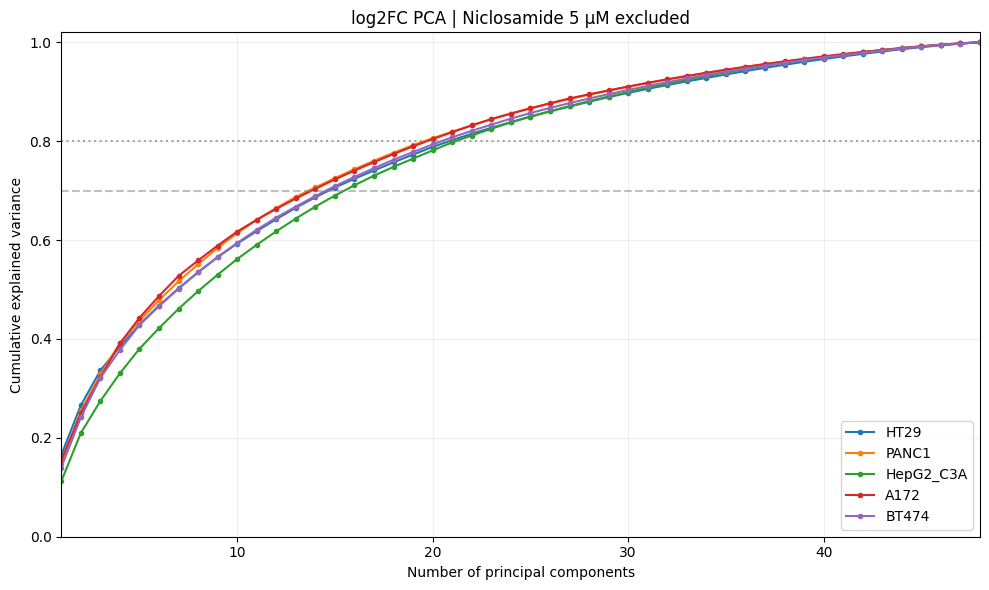

In [ ]:
# ============================================================
# Check cumulative PCA variance across all 5 cell lines
# Standalone cell: no X_selected variable required
#
# Niclosamide (olamine) 5 µM excluded
# Same gene selection as previous PCA/UMAP analysis
# ============================================================

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 1. Load screened log2FC data
# ------------------------------------------------------------

RESULTS = Path(
    "/content/drive/MyDrive/Tahoe_project/results/gene_pathway"
)

adata = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

assert "expression_eligible" in adata.layers

CELL_LINES = [
    "HT29",
    "PANC1",
    "HepG2_C3A",
    "A172",
    "BT474"
]

N_GENES = 2000

summary = []
variance_curves = {}


# ------------------------------------------------------------
# 2. Repeat for every cell line
# ------------------------------------------------------------

for cell_line in CELL_LINES:

    # Exclude Niclosamide 5 µM
    conc = pd.to_numeric(
        adata.obs["concentration"].astype(str)
    )

    mask = (
        adata.obs["cell_line"].astype(str).eq(cell_line)
        &
        ~(
            adata.obs["drug"].astype(str).eq(
                "Niclosamide (olamine)"
            )
            &
            np.isclose(conc, 5.0)
        )
    )

    sub = adata[mask]

    assert sub.n_obs == 49

    # Genes eligible in all 49 conditions
    eligible = np.asarray(
        sub.layers["expression_eligible"],
        dtype=bool
    )

    shared_genes = eligible.all(axis=0)

    X = np.asarray(
        sub.X[:, shared_genes],
        dtype=np.float32
    )

    assert np.isfinite(X).all()

    # Same feature selection as previous analysis:
    # top 2,000 genes by log2FC variance
    gene_variance = X.var(axis=0)

    variable_idx = np.flatnonzero(
        gene_variance > 0
    )

    n_select = min(
        N_GENES,
        len(variable_idx)
    )

    assert n_select >= 30

    selected_idx = variable_idx[
        np.argsort(
            -gene_variance[variable_idx],
            kind="mergesort"
        )[:n_select]
    ]

    X_selected = X[:, selected_idx]

    # --------------------------------------------------------
    # PCA: calculate up to 48 PCs for 49 conditions
    # --------------------------------------------------------

    max_pcs = min(
        X_selected.shape[0] - 1,
        X_selected.shape[1]
    )

    pca = PCA(
        n_components=max_pcs,
        svd_solver="full"
    )

    pca.fit(X_selected)

    cumulative = np.cumsum(
        pca.explained_variance_ratio_
    )

    variance_curves[cell_line] = cumulative.copy()

    # Number of PCs required to reach thresholds
    thresholds = {}

    for threshold in [0.70, 0.75, 0.80, 0.85]:

        reached = np.flatnonzero(
            cumulative >= threshold
        )

        thresholds[f"PCs_for_{int(threshold * 100)}pct"] = (
            int(reached[0] + 1)
            if len(reached) > 0
            else np.nan
        )

    row = {
        "cell_line": cell_line,
        "n_conditions": sub.n_obs,
        "n_genes": n_select
    }

    for k in [2, 5, 10, 15, 20, 25, 30]:
        row[f"PC1-{k}"] = cumulative[k - 1]

    row.update(thresholds)

    summary.append(row)

    print(
        f"{cell_line}: "
        f"{sub.n_obs} conditions, "
        f"{n_select} genes, "
        f"80% at PC{thresholds['PCs_for_80pct']}"
    )


# ------------------------------------------------------------
# 3. Summary table
# ------------------------------------------------------------

variance_summary = pd.DataFrame(summary)

print("\nCumulative explained variance:")
display(variance_summary.round(3))


# ------------------------------------------------------------
# 4. Plot cumulative variance for all cell lines
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

for cell_line, cumulative in variance_curves.items():

    ax.plot(
        np.arange(1, len(cumulative) + 1),
        cumulative,
        marker="o",
        markersize=3,
        label=cell_line
    )

ax.axhline(
    0.70,
    color="gray",
    linestyle="--",
    alpha=0.5
)

ax.axhline(
    0.80,
    color="gray",
    linestyle=":",
    alpha=0.7
)

ax.set(
    xlabel="Number of principal components",
    ylabel="Cumulative explained variance",
    title="log2FC PCA | Niclosamide 5 µM excluded",
    xlim=(1, 48),
    ylim=(0, 1.02)
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Excluded conditions: 5


,cell_line,drug,concentration
condition_id,,,
HT29__Niclosamide (olamine)__5,HT29,Niclosamide (olamine),5.0
PANC1__Niclosamide (olamine)__5,PANC1,Niclosamide (olamine),5.0
HepG2_C3A__Niclosamide (olamine)__5,HepG2_C3A,Niclosamide (olamine),5.0
A172__Niclosamide (olamine)__5,A172,Niclosamide (olamine),5.0
BT474__Niclosamide (olamine)__5,BT474,Niclosamide (olamine),5.0



Processing: HT29
HT29: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 11425
Selected genes: 2000
PCA variance explained: [0.165 0.1  ]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


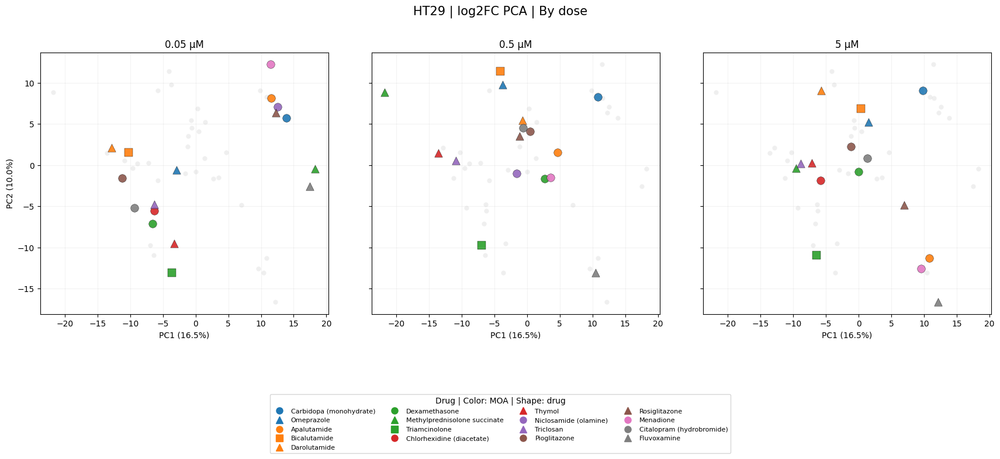

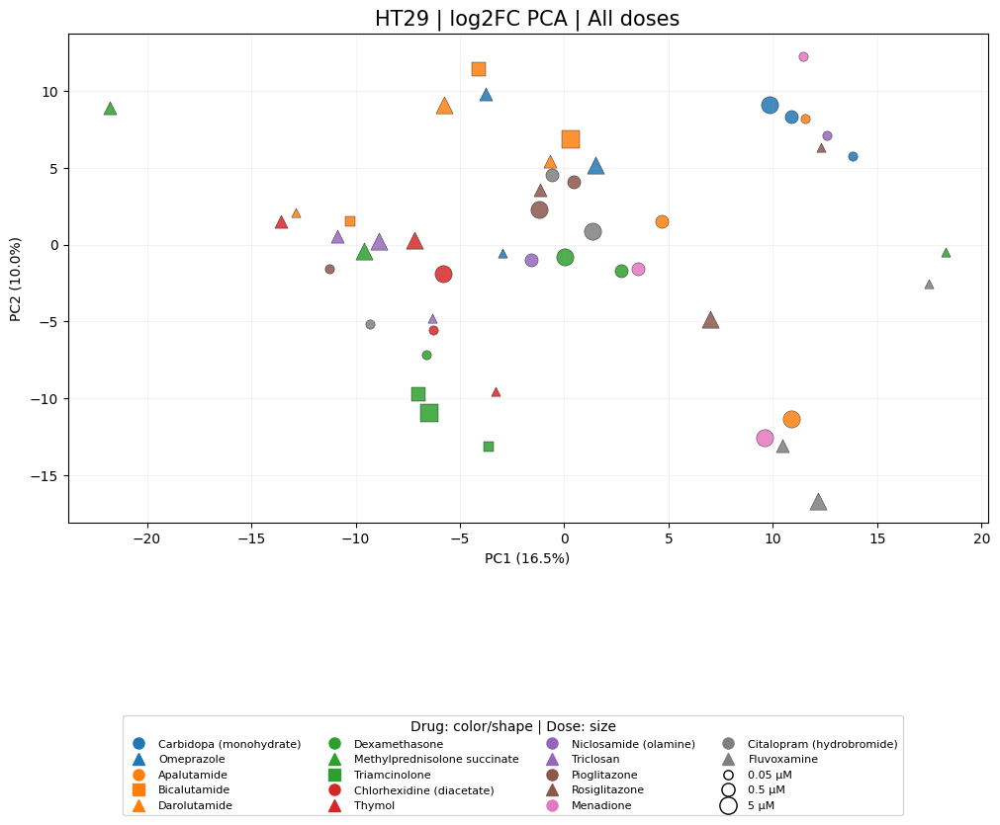

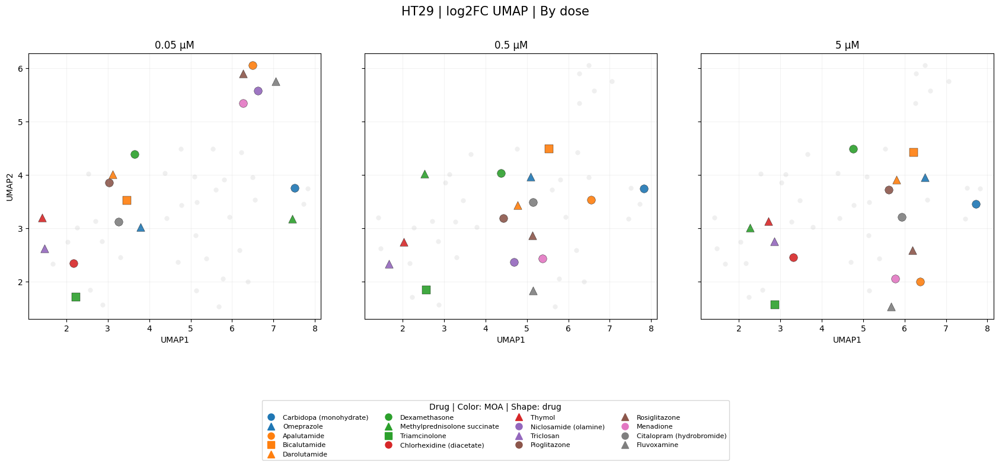

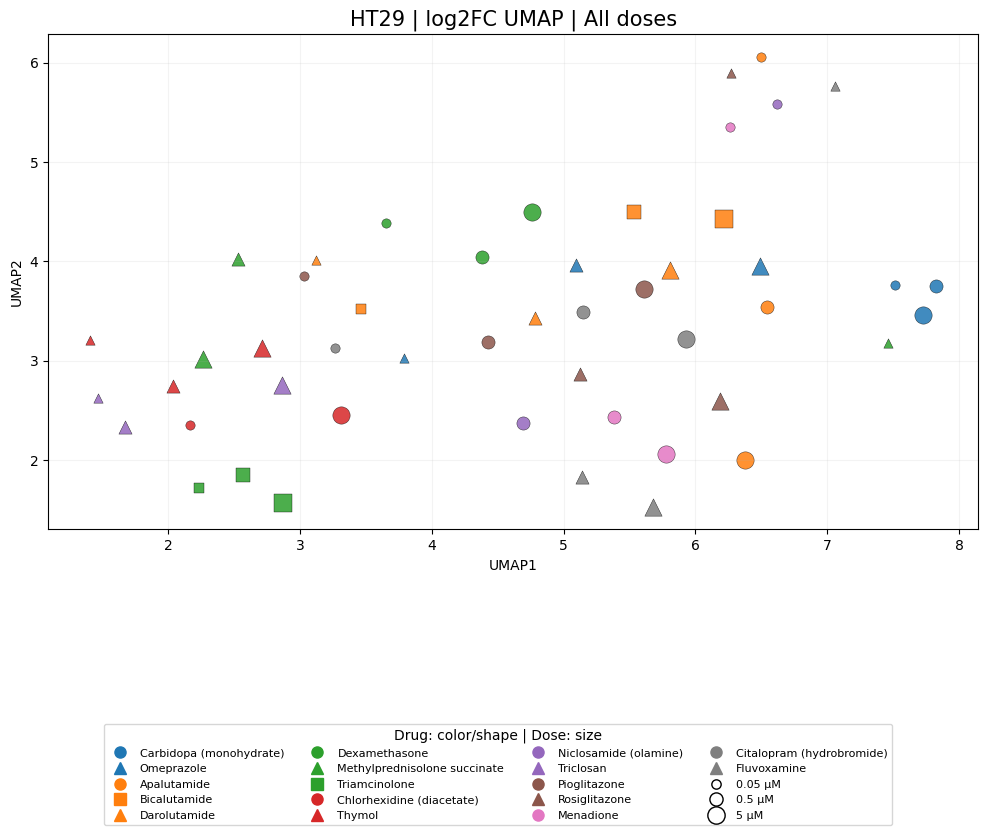


Processing: PANC1
PANC1: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 14413
Selected genes: 2000
PCA variance explained: [0.147 0.107]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


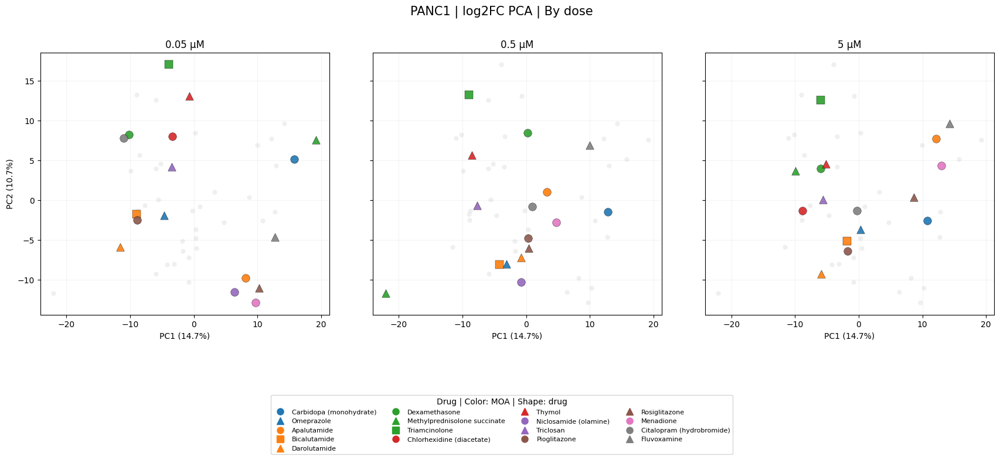

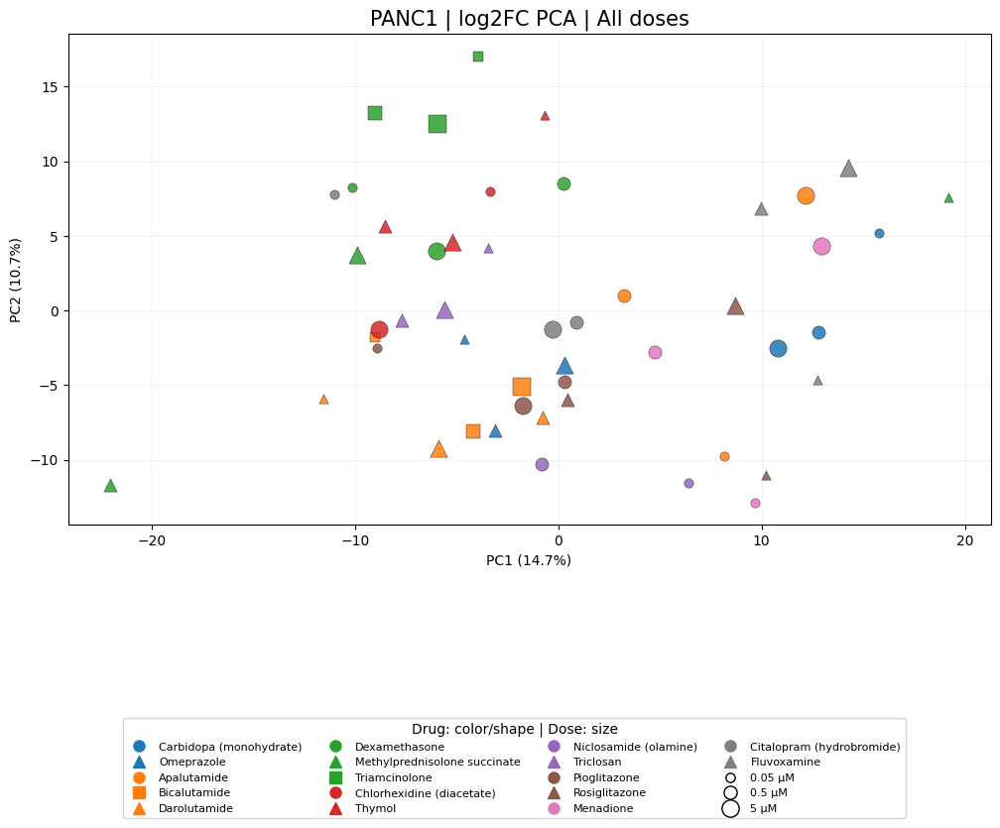

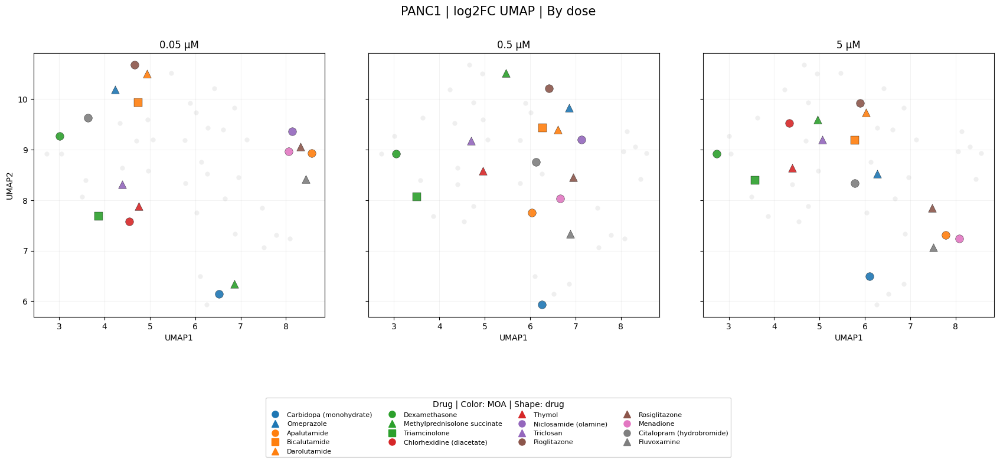

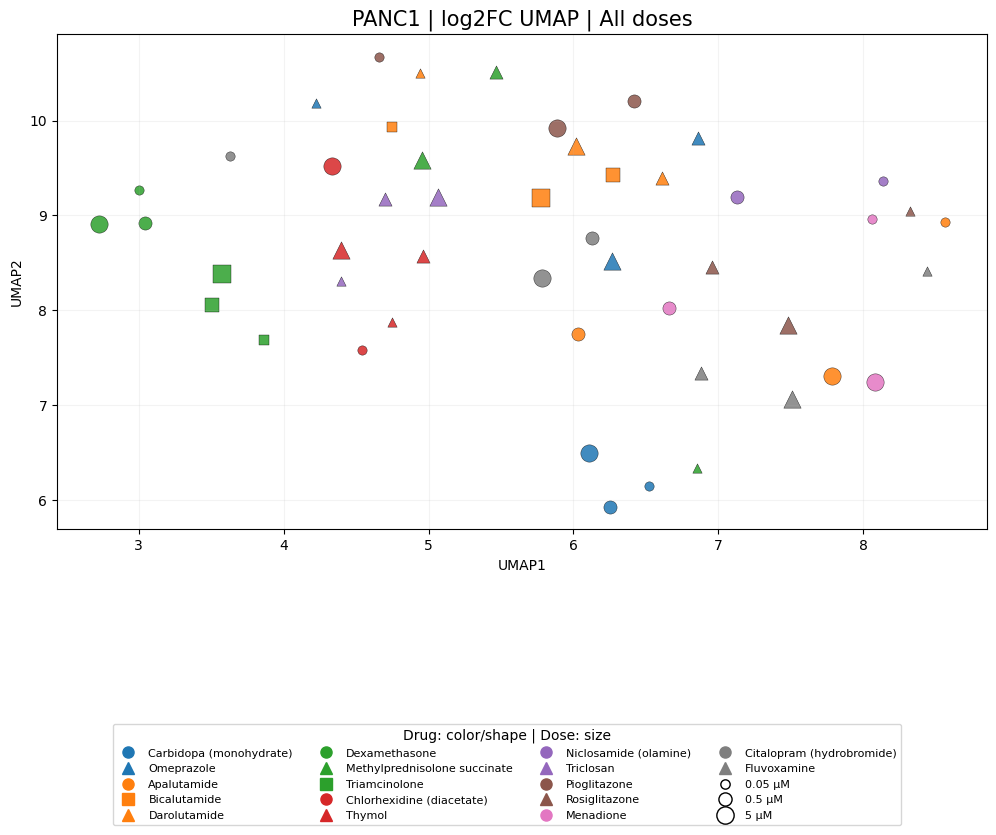


Processing: HepG2_C3A
HepG2_C3A: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 8756
Selected genes: 2000
PCA variance explained: [0.112 0.097]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


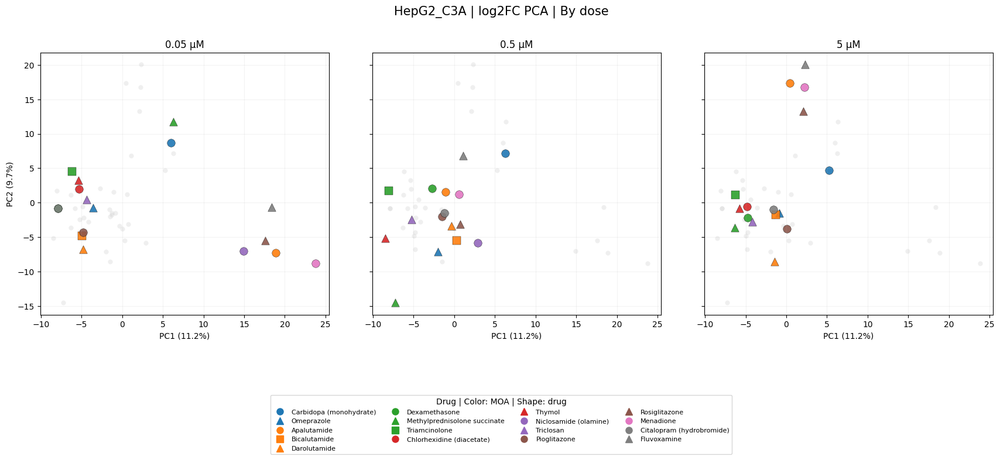

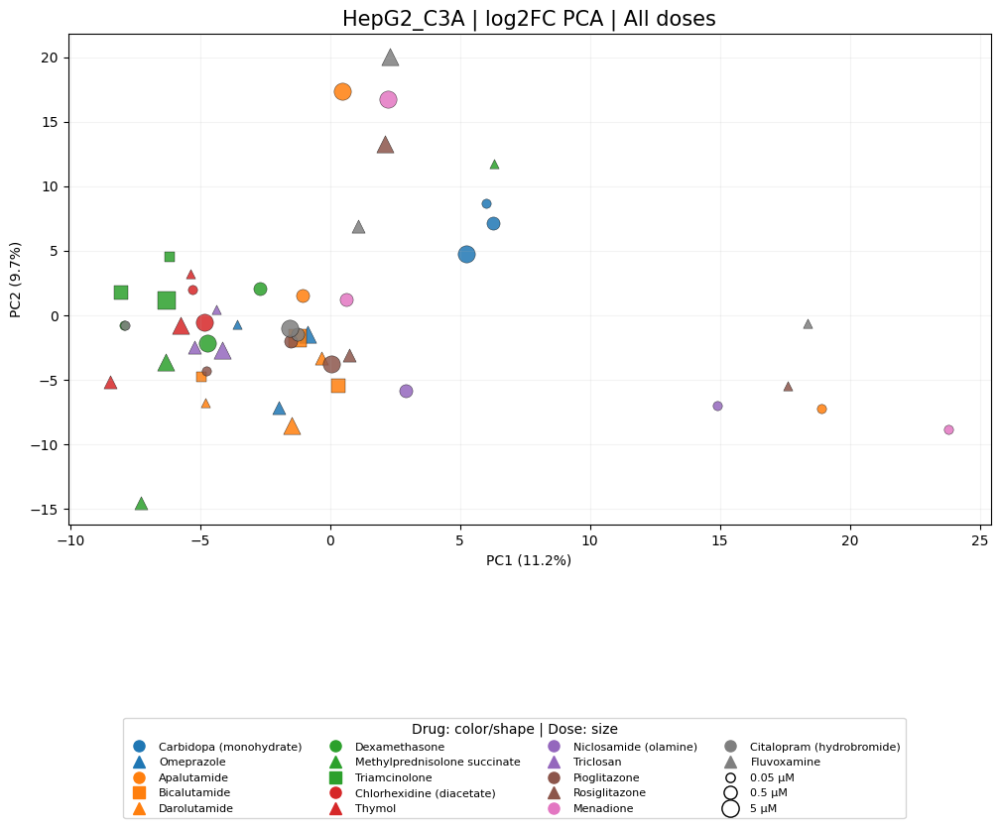

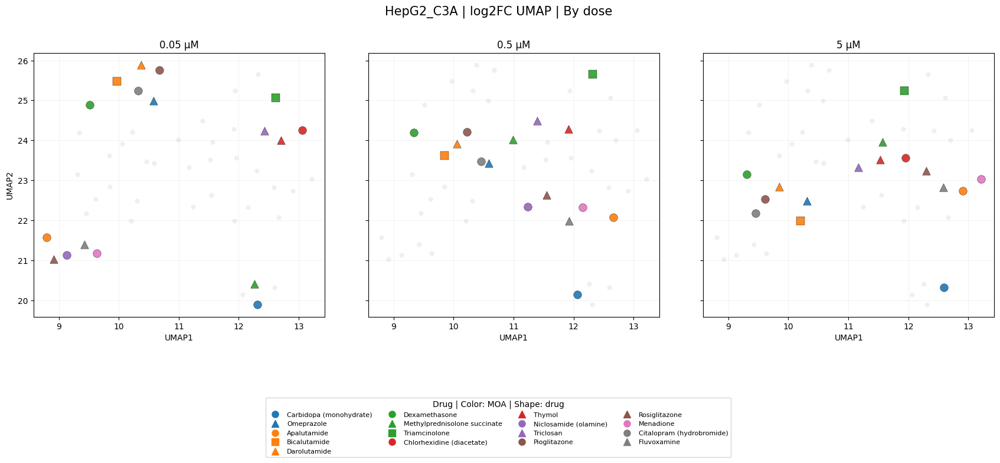

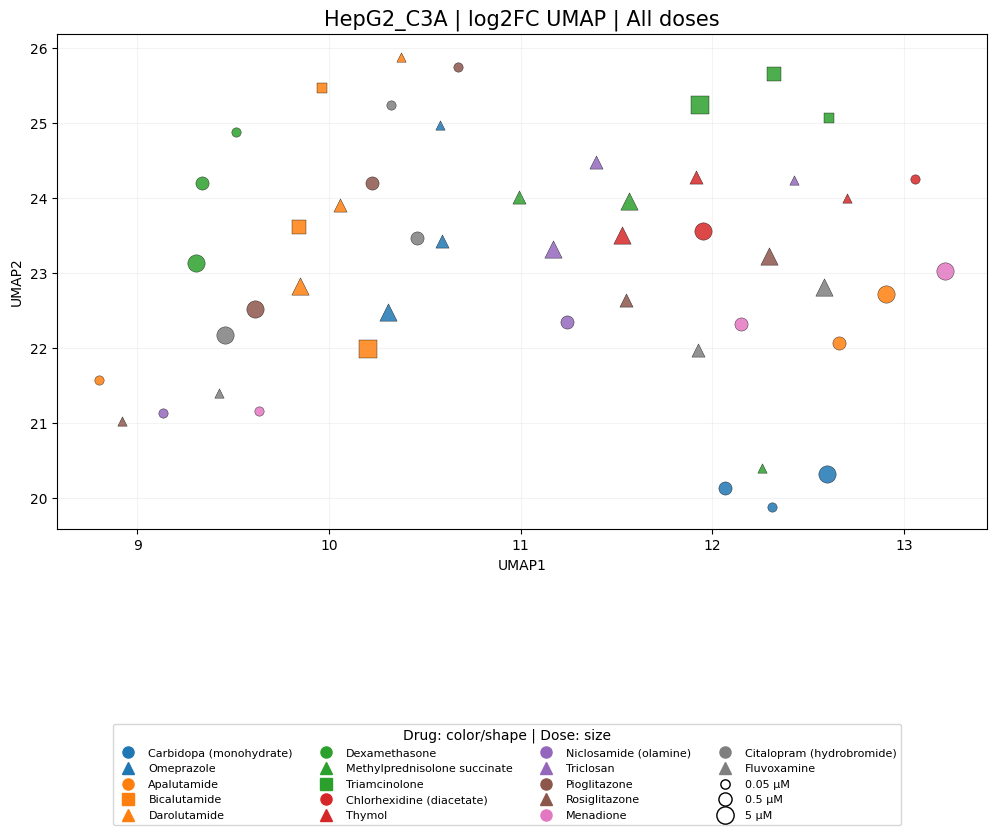


Processing: A172
A172: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 12219
Selected genes: 2000
PCA variance explained: [0.155 0.095]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


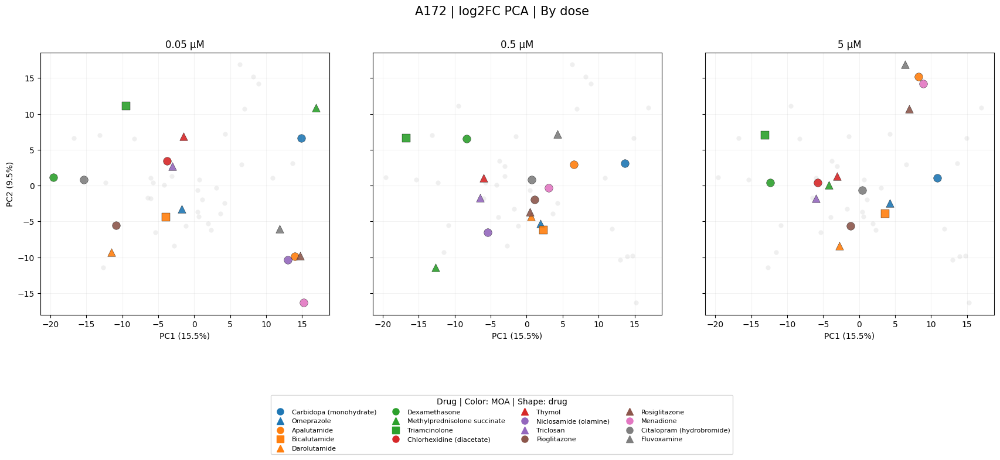

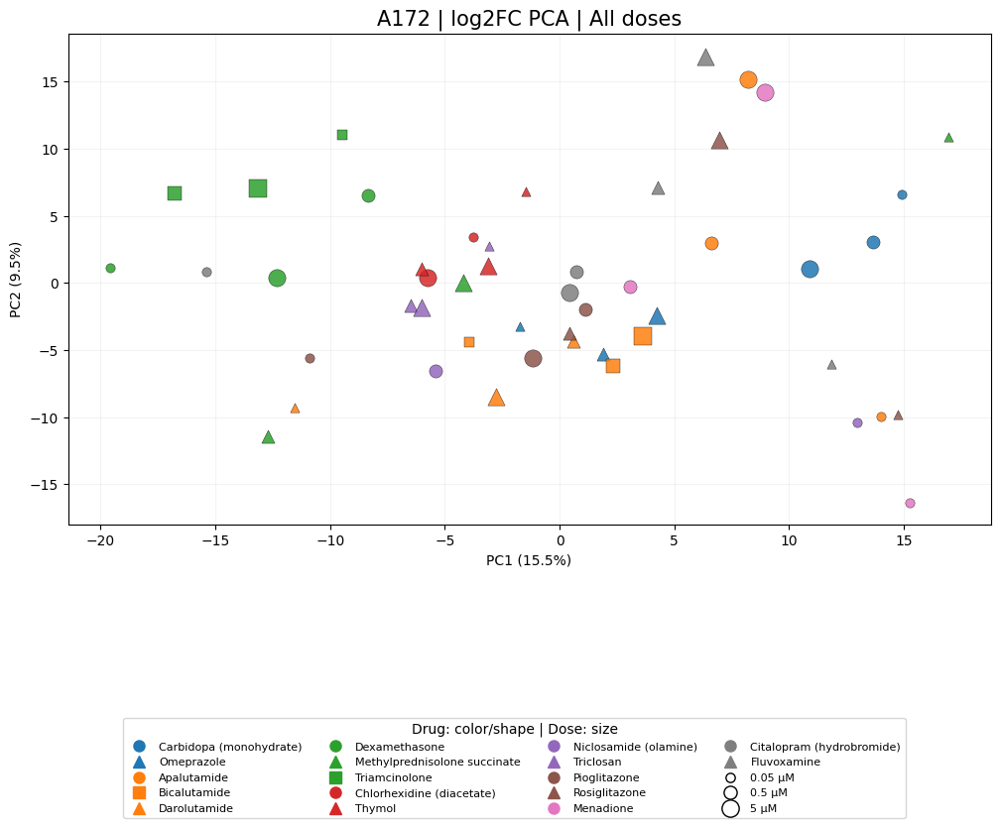

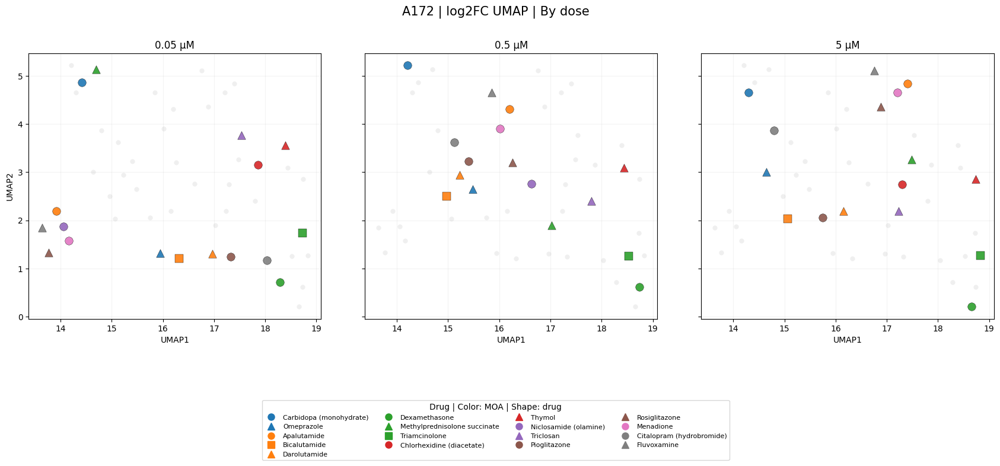

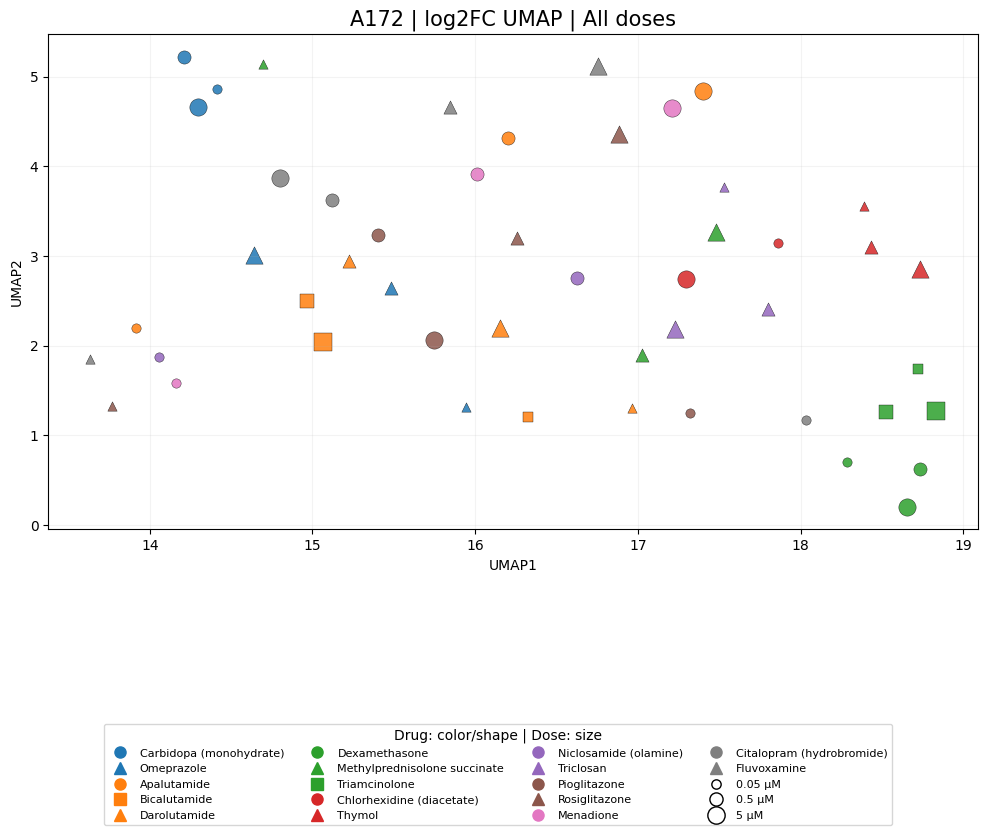


Processing: BT474
BT474: 49 conditions (Niclosamide 5 µM excluded)
Shared eligible genes: 10315
Selected genes: 2000
PCA variance explained: [0.14  0.101]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


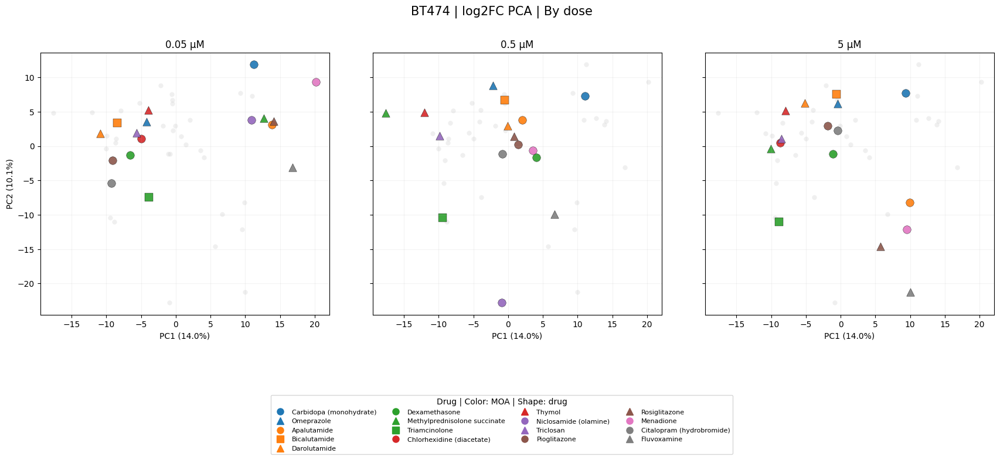

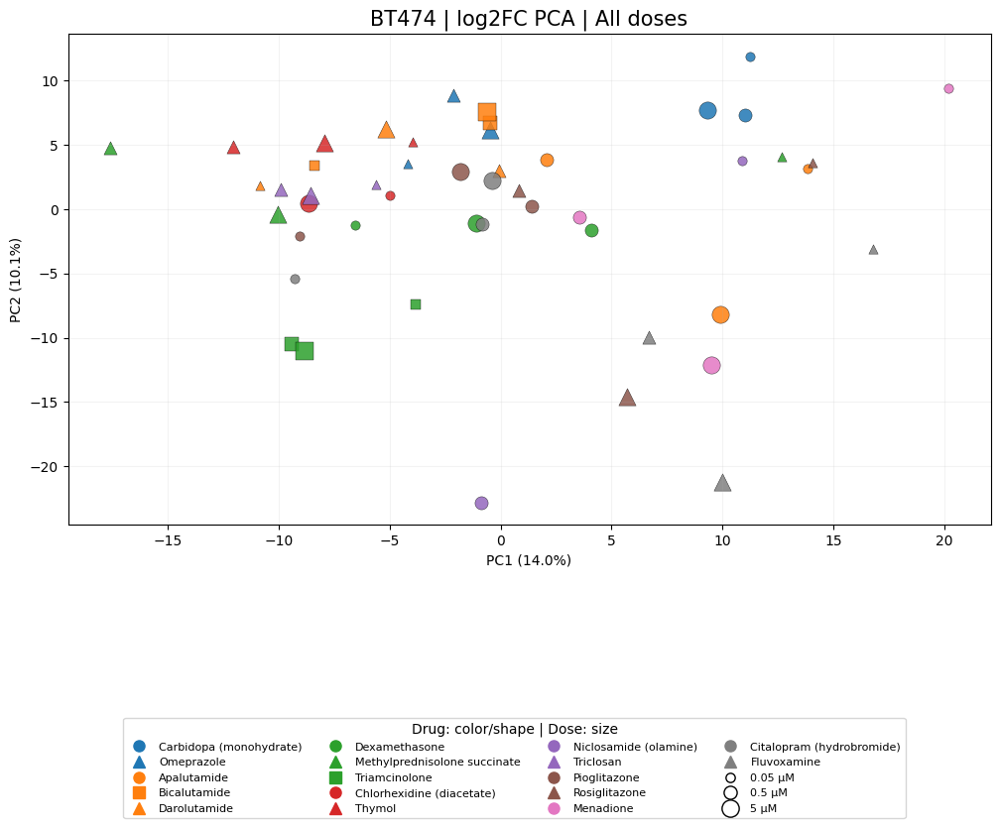

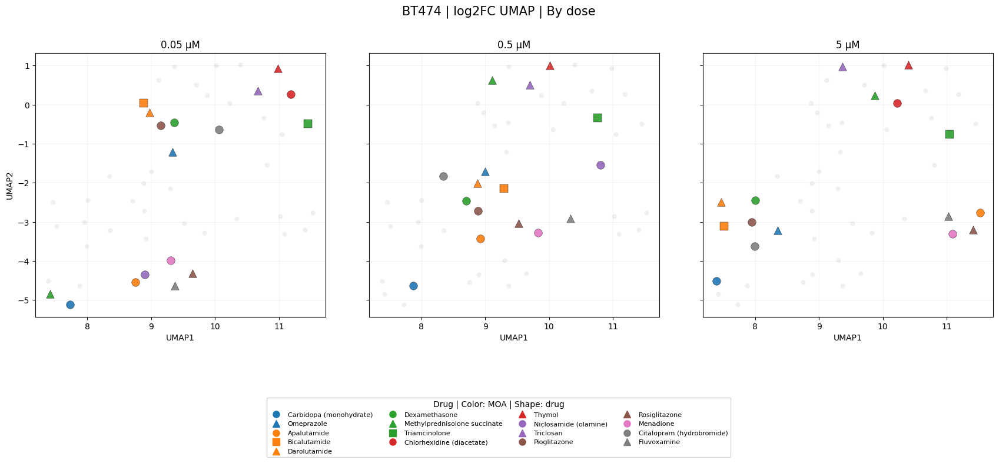

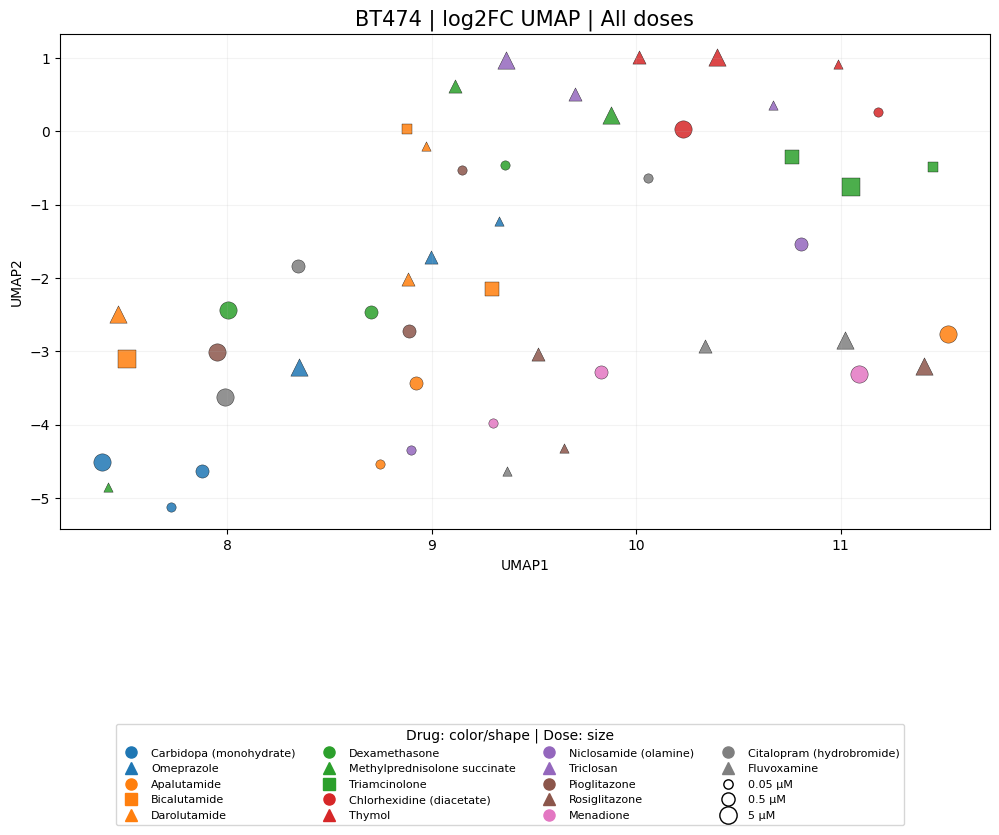


Completed all cell lines.


,cell_line,n_conditions,n_shared_eligible_genes,n_selected_genes,PC1_variance,PC2_variance,PCA_10PC_variance,UMAP_n_neighbors,UMAP_min_dist,random_seed
0,HT29,49,11425,2000,0.165,0.100,0.788,10,0.3,42
1,PANC1,49,14413,2000,0.147,0.107,0.806,10,0.3,42
2,HepG2_C3A,49,8756,2000,0.112,0.097,0.781,10,0.3,42
3,A172,49,12219,2000,0.155,0.095,0.804,10,0.3,42
4,BT474,49,10315,2000,0.140,0.101,0.793,10,0.3,42



Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/log2FC_embedding_without_Niclosamide5_20PC


In [ ]:
# Gene-level log2FC PCA & UMAP
# After expression-aware filtering

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from umap import UMAP


# ============================================================
# 1. Load saved results
# ============================================================

OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)

RESULTS = OUT.parent / "gene_pathway"

EMBED_DIR = (RESULTS / "log2FC_embedding_without_Niclosamide5_20PC")
EMBED_DIR.mkdir(parents=True, exist_ok=True)

lfc = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

moa = pd.read_csv(
    RESULTS / "drug_moa_annotations_with_family.csv"
)

assert lfc.shape == (250, 62710)
assert "expression_eligible" in lfc.layers
assert moa["drug"].is_unique

drug_family = (
    moa.set_index("drug")["moa_family"].to_dict()
)

drug_order = (
    moa.sort_values(["moa_family", "drug"])["drug"]
    .tolist()
)


# ============================================================
# 2. Plot settings
# ============================================================

CELL_LINES = [
    "HT29", "PANC1", "HepG2_C3A", "A172", "BT474"
]

DOSES = [0.05, 0.5, 5.0]

# Sensitivity analysis:
# Exclude Niclosamide (olamine) 5 µM from PCA and UMAP

exclude_niclo5 = (
    lfc.obs["drug"].astype(str).eq("Niclosamide (olamine)")
    &
    np.isclose(
        pd.to_numeric(
            lfc.obs["concentration"].astype(str),
            errors="coerce"
        ),
        5.0
    )
)

print("Excluded conditions:", exclude_niclo5.sum())

display(
    lfc.obs.loc[
        exclude_niclo5,
        ["cell_line", "drug", "concentration"]
    ]
)

assert exclude_niclo5.sum() == 5


N_GENES = 2000
N_PCS = 20  # INCREASED!! (10 -> 20)

family_color = {
    "AHR signaling activation": "#1f77b4",
    "Androgen receptor antagonist": "#ff7f0e",
    "Glucocorticoid receptor agonist": "#2ca02c",
    "Membrane perturbation": "#d62728",
    "Mitochondrial OXPHOS uncoupling": "#9467bd",
    "PPAR gamma agonist": "#8c564b",
    "Redox cycling": "#e377c2",
    "Serotonin reuptake inhibitor": "#7f7f7f",
}

drug_marker = {
    "Carbidopa (monohydrate)": "o",
    "Omeprazole": "^",

    "Apalutamide": "o",
    "Bicalutamide": "s",
    "Darolutamide": "^",

    "Dexamethasone": "o",
    "Methylprednisolone succinate": "^",
    "Triamcinolone": "s",

    "Chlorhexidine (diacetate)": "o",
    "Thymol": "^",

    "Niclosamide (olamine)": "o",
    "Triclosan": "^",

    "Pioglitazone": "o",
    "Rosiglitazone": "^",

    "Menadione": "o",

    "Citalopram (hydrobromide)": "o",
    "Fluvoxamine": "^",
}

assert set(moa["drug"]) == set(drug_marker)
assert set(moa["moa_family"]).issubset(family_color)

dose_sizes = {
    0.05: 45,
    0.5: 90,
    5.0: 155
}


# ============================================================
# 3. Legend
# ============================================================

drug_handles = []

for drug in drug_order:

    drug_handles.append(
        Line2D(
            [0], [0],
            marker=drug_marker[drug],
            linestyle="None",
            markerfacecolor=family_color[drug_family[drug]],
            markeredgecolor=family_color[drug_family[drug]],
            markersize=8,
            label=drug
        )
    )

dose_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=np.sqrt(dose_sizes[dose]),
        label=f"{dose:g} µM"
    )
    for dose in DOSES
]


# ============================================================
# 4. Plot function
# ============================================================

def plot_embedding(df, x, y, method, cell_line, xlabel, ylabel):

    # --------------------------------------------------------
    # A. By dose
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1, 3,
        figsize=(21, 8),
        sharex=True,
        sharey=True
    )

    for ax, dose in zip(axes, DOSES):

        # Other doses: gray background
        background = df.loc[
            df["concentration"] != dose
        ]

        ax.scatter(
            background[x],
            background[y],
            c="lightgray",
            s=35,
            alpha=0.35,
            linewidths=0
        )

        current = df.loc[
            df["concentration"] == dose
        ]

        for drug in drug_order:

            part = current.loc[
                current["drug"] == drug
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=95,
                alpha=0.9,
                edgecolors="black",
                linewidths=0.3
            )

        ax.set_title(f"{dose:g} µM")
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.15)

    axes[0].set_ylabel(ylabel)

    fig.suptitle(
        f"{cell_line} | log2FC {method} | By dose",
        fontsize=15
    )

    fig.legend(
        handles=drug_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug | Color: MOA | Shape: drug"
    )

    fig.subplots_adjust(
        bottom=0.32,
        top=0.88,
        wspace=0.15
    )

    path_dose = (
        EMBED_DIR / f"{cell_line}_{method}_by_dose.png"
    )

    fig.savefig(
        path_dose,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # B. All doses combined
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 9))

    for drug in drug_order:

        for dose in DOSES:

            part = df.loc[
                (df["drug"] == drug) &
                (df["concentration"] == dose)
            ]

            if part.empty:
                continue

            ax.scatter(
                part[x],
                part[y],
                c=family_color[drug_family[drug]],
                marker=drug_marker[drug],
                s=dose_sizes[dose],
                alpha=0.85,
                edgecolors="black",
                linewidths=0.3
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_title(
        f"{cell_line} | log2FC {method} | All doses",
        fontsize=15
    )

    ax.grid(alpha=0.15)

    fig.legend(
        handles=drug_handles + dose_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=4,
        fontsize=8,
        title="Drug: color/shape | Dose: size"
    )

    fig.subplots_adjust(
        bottom=0.35,
        top=0.90
    )

    path_all = (
        EMBED_DIR / f"{cell_line}_{method}_all_doses.png"
    )

    fig.savefig(
        path_all,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 5. Cell-line-specific PCA and UMAP
# ============================================================

summary = []

for cell_line in CELL_LINES:

    print(f"\nProcessing: {cell_line}")

    # --------------------------------------------------------
    # A. One cell line
    # --------------------------------------------------------

    # One cell line, excluding Niclosamide 5 µM

    mask = (
        (lfc.obs["cell_line"].astype(str) == cell_line)
        &
        (~exclude_niclo5)
    )

    sub = lfc[mask]

    assert sub.n_obs == 49

    print(
        f"{cell_line}: {sub.n_obs} conditions "
        "(Niclosamide 5 µM excluded)"
    )
    df = sub.obs[
        ["drug", "concentration", "signature_status"]
    ].copy()

    df["drug"] = df["drug"].astype(str)

    df["concentration"] = pd.to_numeric(
        df["concentration"].astype(str)
    )

    df["moa_family"] = df["drug"].map(drug_family)

    assert df["moa_family"].notna().all()


    # --------------------------------------------------------
    # B. Genes eligible in all 50 conditions
    # --------------------------------------------------------

    eligible = np.asarray(
        sub.layers["expression_eligible"],
        dtype=bool
    )

    shared_genes = eligible.all(axis=0)

    n_shared = int(shared_genes.sum())

    print("Shared eligible genes:", n_shared)

    assert n_shared >= 100, (
        f"{cell_line}: Too few shared eligible genes. "
        "Review feature selection."
    )

    X = np.asarray(
        sub.X[:, shared_genes],
        dtype=np.float32
    )

    assert np.isfinite(X).all()


    # --------------------------------------------------------
    # C. Select up to 2000 variable log2FC genes
    # --------------------------------------------------------

    variance = X.var(axis=0)

    variable_idx = np.flatnonzero(
        variance > 0
    )

    n_select = min(
        N_GENES,
        len(variable_idx)
    )

    assert n_select >= N_PCS

    selected_idx = variable_idx[
        np.argsort(
            -variance[variable_idx],
            kind="mergesort"
        )[:n_select]
    ]

    X_selected = X[:, selected_idx]

    selected_genes = (
        sub.var_names[shared_genes][selected_idx]
    )

    assert np.isfinite(X_selected).all()

    print("Selected genes:", len(selected_genes))


    # --------------------------------------------------------
    # D. PCA
    # --------------------------------------------------------

    pca = PCA(
        n_components=N_PCS,
        svd_solver="full"
    )

    pc = pca.fit_transform(X_selected)

    df["PC1"] = pc[:, 0]
    df["PC2"] = pc[:, 1]

    # Save all 10 PC scores
    for k in range(N_PCS):
        df[f"PC{k + 1}"] = pc[:, k]

    pc1_var = pca.explained_variance_ratio_[0]
    pc2_var = pca.explained_variance_ratio_[1]

    print(
        "PCA variance explained:",
        pca.explained_variance_ratio_[:2].round(3)
    )


    # --------------------------------------------------------
    # E. UMAP using 10 PCs
    # --------------------------------------------------------

    reducer = UMAP(
        n_neighbors=10,
        min_dist=0.3,
        n_components=2,
        metric="euclidean",
        random_state=42
    )

    xy = reducer.fit_transform(pc)

    df["UMAP1"] = xy[:, 0]
    df["UMAP2"] = xy[:, 1]

    # Save coordinates
    df.to_csv(
        EMBED_DIR / f"{cell_line}_embedding_coordinates.csv",
        index_label="condition_id"
    )

    pd.DataFrame({
        "gene_id": selected_genes,
        "gene_symbol": sub.var.loc[
            selected_genes, "gene_symbol"
        ].to_numpy()
    }).to_csv(
        EMBED_DIR / f"{cell_line}_selected_genes.csv",
        index=False
    )


    # --------------------------------------------------------
    # F. PCA figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="PC1",
        y="PC2",
        method="PCA",
        cell_line=cell_line,
        xlabel=f"PC1 ({pc1_var:.1%})",
        ylabel=f"PC2 ({pc2_var:.1%})"
    )


    # --------------------------------------------------------
    # G. UMAP figures
    # --------------------------------------------------------

    plot_embedding(
        df,
        x="UMAP1",
        y="UMAP2",
        method="UMAP",
        cell_line=cell_line,
        xlabel="UMAP1",
        ylabel="UMAP2"
    )


    summary.append({
        "cell_line": cell_line,
        "n_conditions": len(df),
        "n_shared_eligible_genes": n_shared,
        "n_selected_genes": len(selected_genes),
        "PC1_variance": pc1_var,
        "PC2_variance": pc2_var,
        "PCA_10PC_variance": (
            pca.explained_variance_ratio_.sum()
        ),
        "UMAP_n_neighbors": 10,
        "UMAP_min_dist": 0.3,
        "random_seed": 42
    })

    del sub, eligible, X, X_selected, pc, xy


# ============================================================
# 6. Save summary
# ============================================================

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    EMBED_DIR / "log2FC_embedding_summary.csv",
    index=False
)

print("\nCompleted all cell lines.")
display(summary_df.round(3))

print("\nSaved to:", EMBED_DIR)

In [ ]:
# PC10이 더 나아보임!!! - 지우기?

# log2FC similarit clustermap


Processing: HT29
Shared eligible genes: 11425
Reusing selected genes: HT29_selected_genes.csv
Input matrix: (49, 2000)


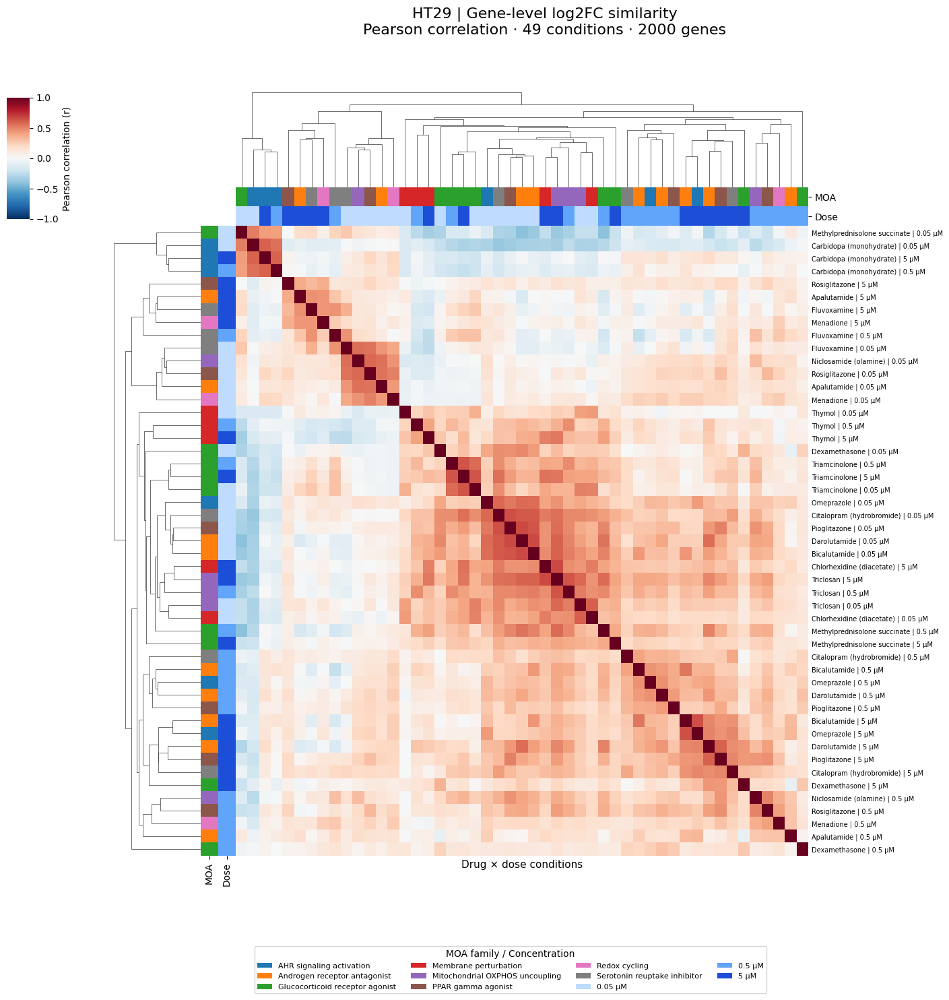


Highest correlations between different drugs:


,drug_a,dose_a,drug_b,dose_b,same_MOA_family,pearson_r
316,Chlorhexidine (diacetate),5.00,Triclosan,5.00,False,0.661
946,Pioglitazone,0.05,Darolutamide,0.05,False,0.660
925,Bicalutamide,0.05,Darolutamide,0.05,True,0.660
1110,Omeprazole,5.00,Bicalutamide,5.00,False,0.647
945,Pioglitazone,0.05,Citalopram (hydrobromide),0.05,False,0.642
923,Bicalutamide,0.05,Pioglitazone,0.05,False,0.629
966,Citalopram (hydrobromide),0.05,Darolutamide,0.05,False,0.624
924,Bicalutamide,0.05,Citalopram (hydrobromide),0.05,False,0.614
1,Chlorhexidine (diacetate),0.05,Triclosan,0.05,False,0.601
415,Triclosan,5.00,Darolutamide,0.05,False,0.590



Lowest response magnitudes:


,drug,concentration,RMS_log2FC,median_abs_log2FC
condition_id,,,,
HT29__Apalutamide__0.5,Apalutamide,0.5,0.387,0.254
HT29__Citalopram (hydrobromide)__5,Citalopram (hydrobromide),5.0,0.388,0.245
HT29__Omeprazole__5,Omeprazole,5.0,0.400,0.242
HT29__Bicalutamide__5,Bicalutamide,5.0,0.401,0.251
HT29__Chlorhexidine (diacetate)__5,Chlorhexidine (diacetate),5.0,0.404,0.259


Saved: HT29_log2FC_similarity_clustermap.png

Processing: PANC1
Shared eligible genes: 14413
Reusing selected genes: PANC1_selected_genes.csv
Input matrix: (49, 2000)


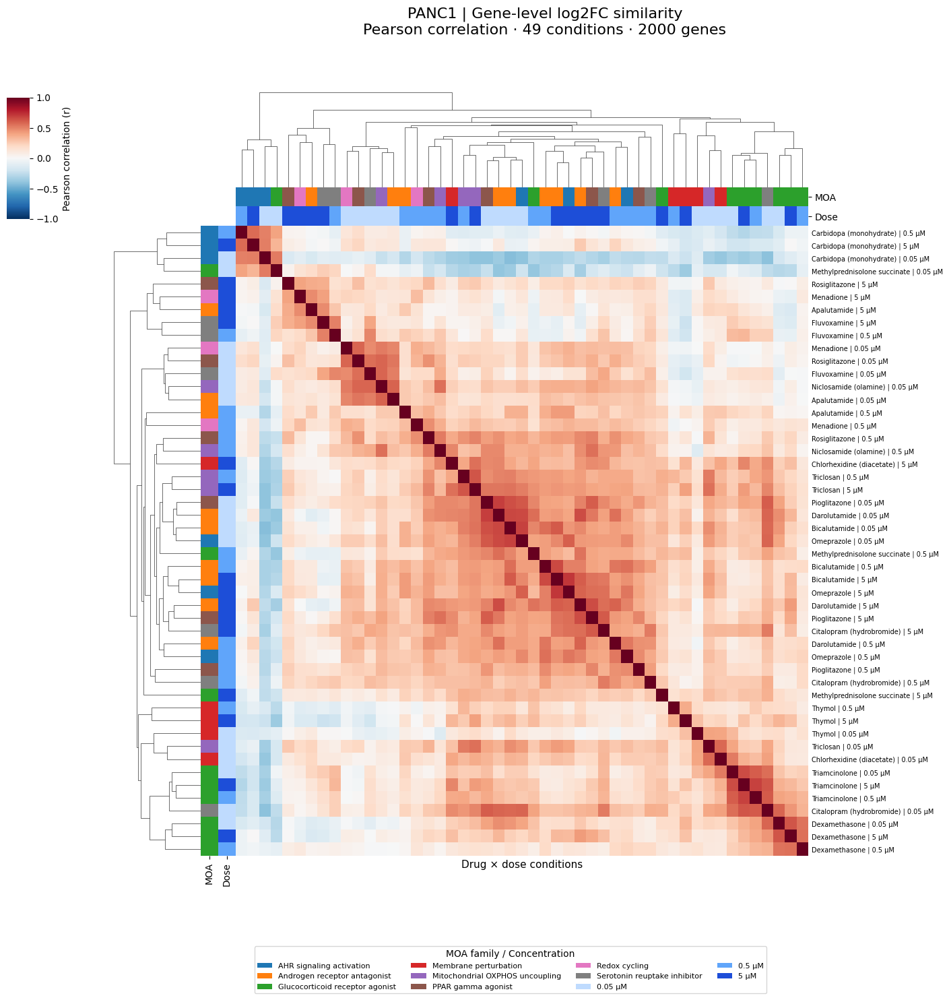


Highest correlations between different drugs:


,drug_a,dose_a,drug_b,dose_b,same_MOA_family,pearson_r
1110,Omeprazole,5.00,Bicalutamide,5.00,False,0.714
946,Pioglitazone,0.05,Darolutamide,0.05,False,0.689
900,Omeprazole,0.05,Bicalutamide,0.05,False,0.680
925,Bicalutamide,0.05,Darolutamide,0.05,True,0.665
903,Omeprazole,0.05,Darolutamide,0.05,False,0.657
1141,Pioglitazone,5.00,Darolutamide,5.00,False,0.656
923,Bicalutamide,0.05,Pioglitazone,0.05,False,0.648
452,Triamcinolone,5.00,Citalopram (hydrobromide),0.05,False,0.626
901,Omeprazole,0.05,Pioglitazone,0.05,False,0.623
252,Triamcinolone,0.50,Citalopram (hydrobromide),0.05,False,0.614



Lowest response magnitudes:


,drug,concentration,RMS_log2FC,median_abs_log2FC
condition_id,,,,
PANC1__Apalutamide__0.5,Apalutamide,0.5,0.384,0.249
PANC1__Omeprazole__5,Omeprazole,5.0,0.408,0.233
PANC1__Citalopram (hydrobromide)__5,Citalopram (hydrobromide),5.0,0.422,0.252
PANC1__Bicalutamide__5,Bicalutamide,5.0,0.428,0.254
PANC1__Carbidopa (monohydrate)__0.5,Carbidopa (monohydrate),0.5,0.433,0.282


Saved: PANC1_log2FC_similarity_clustermap.png

Processing: HepG2_C3A
Shared eligible genes: 8756
Reusing selected genes: HepG2_C3A_selected_genes.csv
Input matrix: (49, 2000)


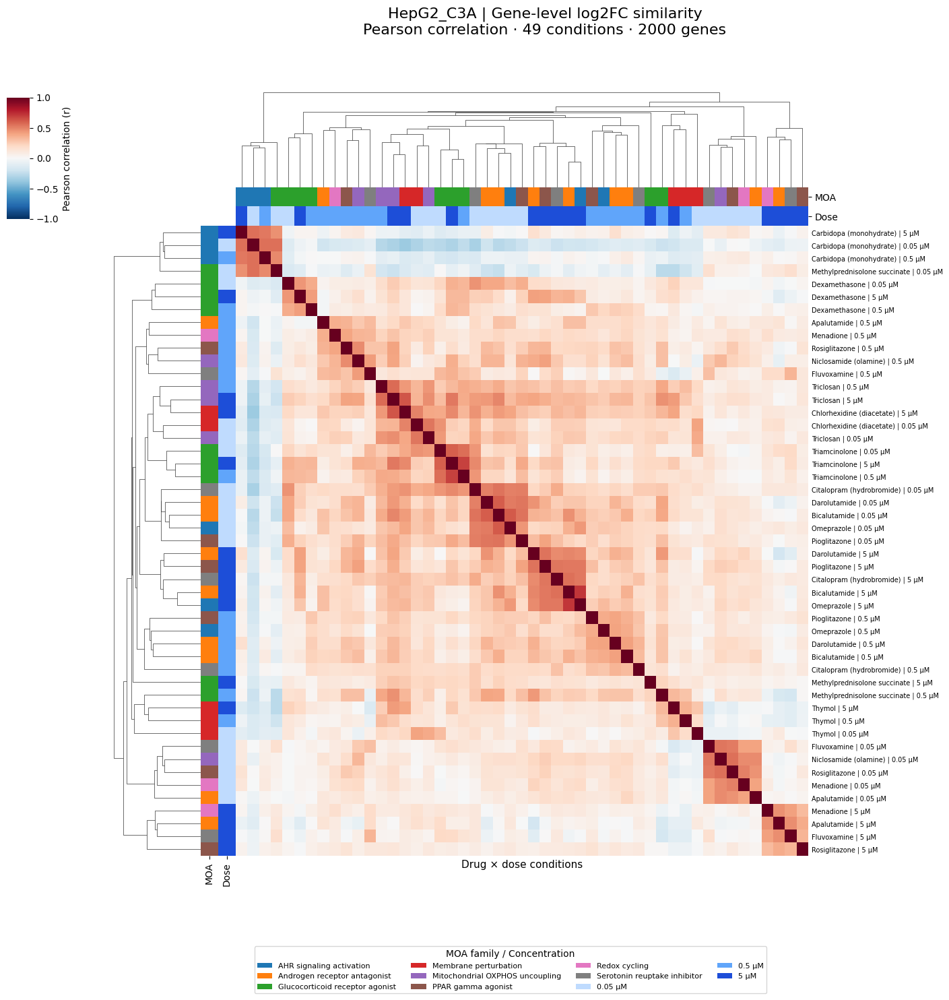


Highest correlations between different drugs:


,drug_a,dose_a,drug_b,dose_b,same_MOA_family,pearson_r
1110,Omeprazole,5.00,Bicalutamide,5.00,False,0.715
316,Chlorhexidine (diacetate),5.00,Triclosan,5.00,False,0.632
900,Omeprazole,0.05,Bicalutamide,0.05,False,0.616
925,Bicalutamide,0.05,Darolutamide,0.05,True,0.608
1123,Bicalutamide,5.00,Citalopram (hydrobromide),5.00,False,0.554
473,Niclosamide (olamine),0.05,Rosiglitazone,0.05,False,0.551
1163,Methylprednisolone succinate,0.05,Carbidopa (monohydrate),0.05,False,0.550
1141,Pioglitazone,5.00,Darolutamide,5.00,False,0.546
923,Bicalutamide,0.05,Pioglitazone,0.05,False,0.543
924,Bicalutamide,0.05,Citalopram (hydrobromide),0.05,False,0.540



Lowest response magnitudes:


,drug,concentration,RMS_log2FC,median_abs_log2FC
condition_id,,,,
HepG2_C3A__Thymol__5,Thymol,5.0,0.343,0.222
HepG2_C3A__Chlorhexidine (diacetate)__5,Chlorhexidine (diacetate),5.0,0.352,0.202
HepG2_C3A__Triclosan__5,Triclosan,5.0,0.353,0.226
HepG2_C3A__Omeprazole__5,Omeprazole,5.0,0.354,0.213
HepG2_C3A__Bicalutamide__5,Bicalutamide,5.0,0.357,0.211


Saved: HepG2_C3A_log2FC_similarity_clustermap.png

Processing: A172
Shared eligible genes: 12219
Reusing selected genes: A172_selected_genes.csv
Input matrix: (49, 2000)


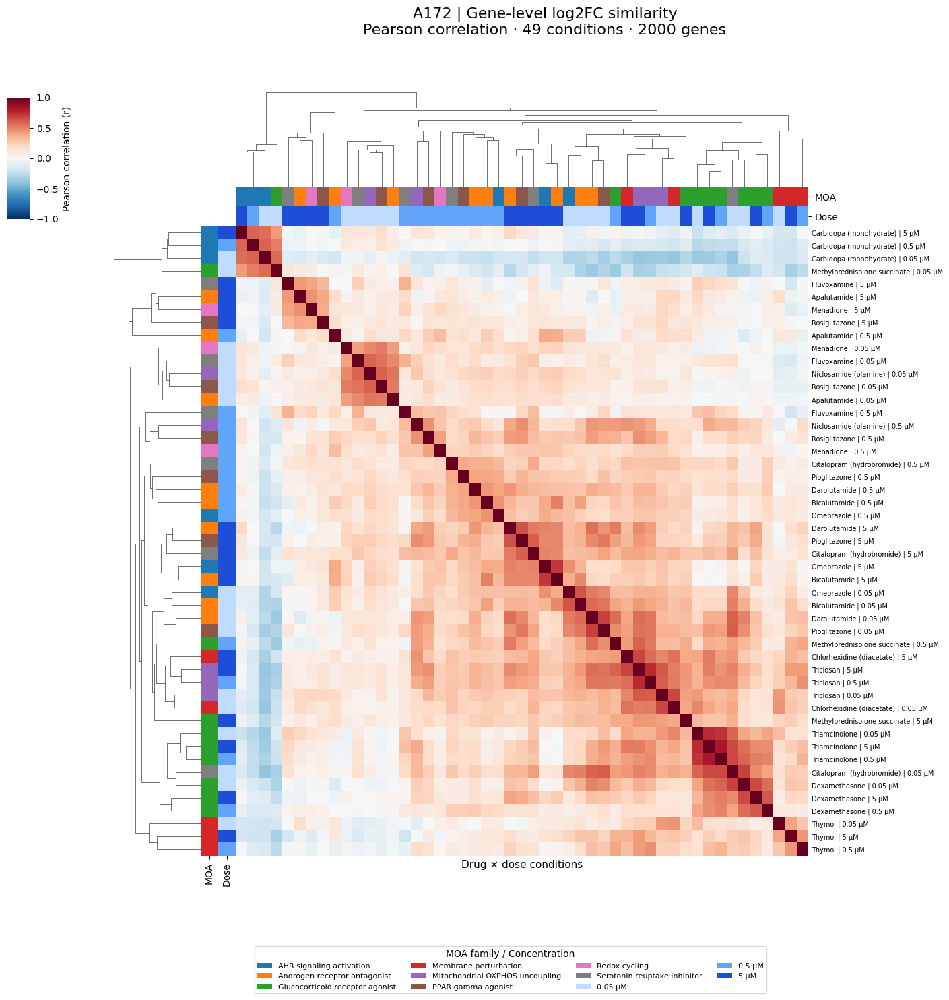


Highest correlations between different drugs:


,drug_a,dose_a,drug_b,dose_b,same_MOA_family,pearson_r
1110,Omeprazole,5.00,Bicalutamide,5.00,False,0.716
946,Pioglitazone,0.05,Darolutamide,0.05,False,0.686
967,Citalopram (hydrobromide),0.05,Dexamethasone,0.05,False,0.683
316,Chlorhexidine (diacetate),5.00,Triclosan,5.00,False,0.675
1,Chlorhexidine (diacetate),0.05,Triclosan,0.05,False,0.665
252,Triamcinolone,0.50,Citalopram (hydrobromide),0.05,False,0.663
452,Triamcinolone,5.00,Citalopram (hydrobromide),0.05,False,0.661
1141,Pioglitazone,5.00,Darolutamide,5.00,False,0.635
900,Omeprazole,0.05,Bicalutamide,0.05,False,0.629
945,Pioglitazone,0.05,Citalopram (hydrobromide),0.05,False,0.609



Lowest response magnitudes:


,drug,concentration,RMS_log2FC,median_abs_log2FC
condition_id,,,,
A172__Thymol__5,Thymol,5.0,0.372,0.242
A172__Apalutamide__0.5,Apalutamide,0.5,0.405,0.259
A172__Bicalutamide__5,Bicalutamide,5.0,0.409,0.230
A172__Citalopram (hydrobromide)__5,Citalopram (hydrobromide),5.0,0.410,0.264
A172__Omeprazole__5,Omeprazole,5.0,0.412,0.248


Saved: A172_log2FC_similarity_clustermap.png

Processing: BT474
Shared eligible genes: 10315
Reusing selected genes: BT474_selected_genes.csv
Input matrix: (49, 2000)


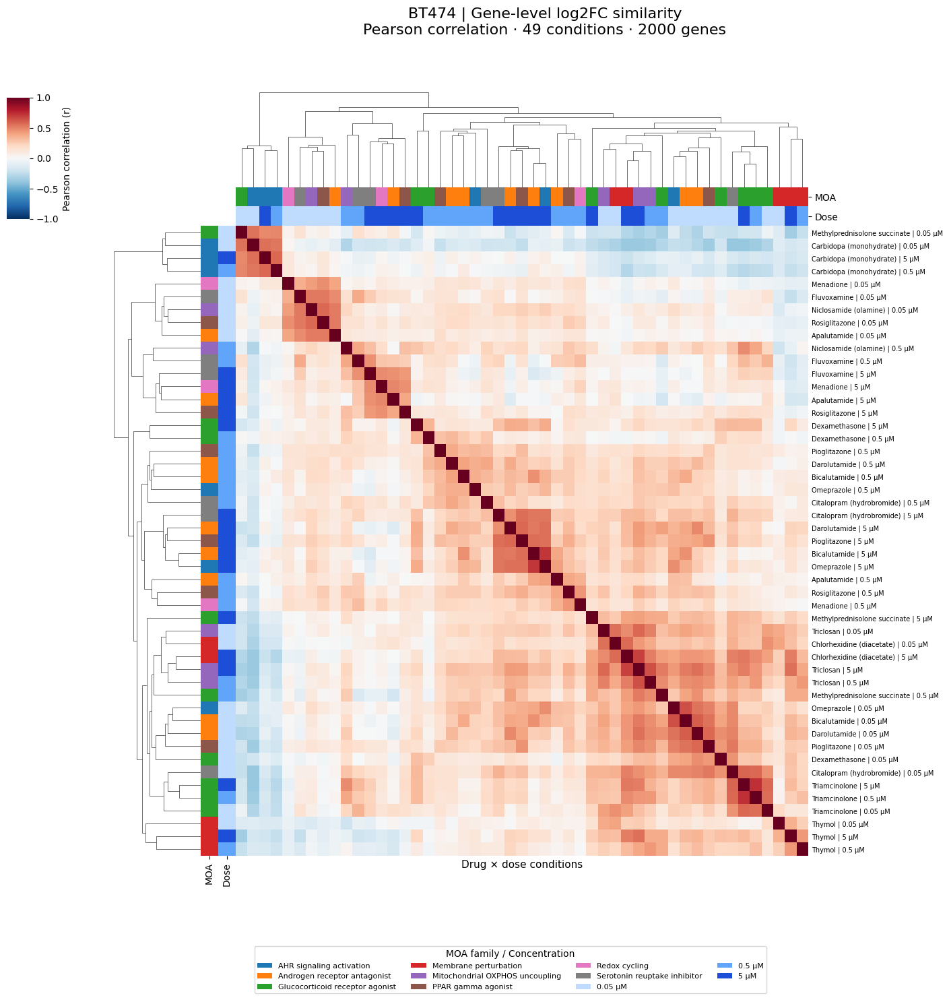


Highest correlations between different drugs:


,drug_a,dose_a,drug_b,dose_b,same_MOA_family,pearson_r
1110,Omeprazole,5.00,Bicalutamide,5.00,False,0.716
316,Chlorhexidine (diacetate),5.00,Triclosan,5.00,False,0.684
900,Omeprazole,0.05,Bicalutamide,0.05,False,0.641
925,Bicalutamide,0.05,Darolutamide,0.05,True,0.604
452,Triamcinolone,5.00,Citalopram (hydrobromide),0.05,False,0.586
510,Niclosamide (olamine),0.05,Rosiglitazone,0.05,False,0.577
252,Triamcinolone,0.50,Citalopram (hydrobromide),0.05,False,0.577
1141,Pioglitazone,5.00,Darolutamide,5.00,False,0.572
946,Pioglitazone,0.05,Darolutamide,0.05,False,0.571
1122,Bicalutamide,5.00,Pioglitazone,5.00,False,0.561



Lowest response magnitudes:


,drug,concentration,RMS_log2FC,median_abs_log2FC
condition_id,,,,
BT474__Apalutamide__0.5,Apalutamide,0.5,0.378,0.242
BT474__Citalopram (hydrobromide)__5,Citalopram (hydrobromide),5.0,0.395,0.249
BT474__Thymol__5,Thymol,5.0,0.407,0.258
BT474__Omeprazole__5,Omeprazole,5.0,0.409,0.244
BT474__Bicalutamide__5,Bicalutamide,5.0,0.411,0.249


Saved: BT474_log2FC_similarity_clustermap.png

Completed all cell lines.


,cell_line,n_conditions,n_shared_eligible_genes,n_selected_genes,median_RMS_log2FC,n_condition_pairs,distance,linkage
0,HT29,49,11425,2000,0.515,1176,1 - Pearson r,average
1,PANC1,49,14413,2000,0.566,1176,1 - Pearson r,average
2,HepG2_C3A,49,8756,2000,0.488,1176,1 - Pearson r,average
3,A172,49,12219,2000,0.564,1176,1 - Pearson r,average
4,BT474,49,10315,2000,0.520,1176,1 - Pearson r,average



Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/log2FC_similarity_without_Niclosamide5


In [ ]:
# ============================================================
# 04-2C. Gene-level log2FC similarity & hierarchical clustering
#
# Unit: drug × dose condition
# One heatmap per cell line
# Niclosamide (olamine) 5 µM excluded
#
# Pearson correlation + average linkage
# No clustering on 2D UMAP coordinates
# ============================================================

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.patches import Patch

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage


# ============================================================
# 1. Settings
# ============================================================

ROOT = Path("/content/drive/MyDrive/Tahoe_project")

RESULTS = ROOT / "results" / "gene_pathway"

SAVE_DIR = RESULTS / "log2FC_similarity_without_Niclosamide5"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CELL_LINES = [
    "HT29",
    "PANC1",
    "HepG2_C3A",
    "A172",
    "BT474"
]

N_GENES = 2000

EXCLUDE_DRUG = "Niclosamide (olamine)"
EXCLUDE_DOSE = 5.0


# ============================================================
# 2. Load existing data
# ============================================================

lfc = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

moa = pd.read_csv(
    RESULTS / "drug_moa_annotations_with_family.csv"
)

assert lfc.n_obs == 250
assert "expression_eligible" in lfc.layers

assert moa["drug"].is_unique

drug_family = (
    moa.set_index("drug")["moa_family"].to_dict()
)


# ============================================================
# 3. Colors: same MOA colors as previous PCA / UMAP
# ============================================================

family_color = {
    "AHR signaling activation": "#1f77b4",
    "Androgen receptor antagonist": "#ff7f0e",
    "Glucocorticoid receptor agonist": "#2ca02c",
    "Membrane perturbation": "#d62728",
    "Mitochondrial OXPHOS uncoupling": "#9467bd",
    "PPAR gamma agonist": "#8c564b",
    "Redox cycling": "#e377c2",
    "Serotonin reuptake inhibitor": "#7f7f7f",
}

dose_color = {
    0.05: "#BFDBFE",
    0.5: "#60A5FA",
    5.0: "#1D4ED8"
}

assert set(moa["moa_family"]).issubset(family_color)


# ============================================================
# 4. Previously saved gene lists
#
# Reuse the exact selected genes if available.
# Otherwise, regenerate using the previous PCA rule.
# ============================================================

PREVIOUS_DIRS = [
    RESULTS / "log2FC_embedding_without_Niclosamide5_20PC",
    RESULTS / "log2FC_embedding_without_Niclosamide5"
]


# ============================================================
# 5. Loop over cell lines
# ============================================================

summary = []

for cell_line in CELL_LINES:

    print("\n" + "=" * 65)
    print("Processing:", cell_line, flush=True)

    # --------------------------------------------------------
    # A. Select one cell line and exclude Niclosamide 5 µM
    # --------------------------------------------------------

    obs = lfc.obs

    conc = pd.to_numeric(
        obs["concentration"].astype(str),
        errors="coerce"
    )

    is_excluded = (
        obs["drug"].astype(str).eq(EXCLUDE_DRUG)
        &
        np.isclose(conc, EXCLUDE_DOSE)
    )

    mask = (
        obs["cell_line"].astype(str).eq(cell_line)
        &
        ~is_excluded
    )

    sub = lfc[mask]

    assert sub.n_obs == 49, (
        f"{cell_line}: Expected 49 conditions, "
        f"found {sub.n_obs}"
    )

    meta = sub.obs[
        ["drug", "concentration", "signature_status"]
    ].copy()

    meta["drug"] = meta["drug"].astype(str)

    meta["concentration"] = pd.to_numeric(
        meta["concentration"].astype(str)
    ).round(2)

    meta["moa_family"] = meta["drug"].map(drug_family)

    assert meta["moa_family"].notna().all()
    assert meta["concentration"].isin(dose_color).all()

    assert not meta.duplicated(
        ["drug", "concentration"]
    ).any()


    # --------------------------------------------------------
    # B. Common expression-eligible genes
    # --------------------------------------------------------

    eligible = np.asarray(
        sub.layers["expression_eligible"],
        dtype=bool
    )

    shared = eligible.all(axis=0)

    n_shared = int(shared.sum())

    print("Shared eligible genes:", n_shared)

    assert n_shared >= N_GENES


    # --------------------------------------------------------
    # C. Reuse previous selected genes if available
    # --------------------------------------------------------

    previous_gene_file = None

    for folder in PREVIOUS_DIRS:

        candidate = folder / f"{cell_line}_selected_genes.csv"

        if candidate.exists():
            previous_gene_file = candidate
            break

    if previous_gene_file is not None:

        selected = pd.read_csv(
            previous_gene_file
        )["gene_id"].astype(str).tolist()

        print(
            "Reusing selected genes:",
            previous_gene_file.name
        )

    else:

        print(
            "Previous gene list not found. "
            "Selecting genes with the same PCA rule."
        )

        X_shared = np.asarray(
            sub.X[:, shared],
            dtype=np.float32
        )

        variance = X_shared.var(axis=0)

        valid_idx = np.flatnonzero(
            variance > 0
        )

        assert len(valid_idx) >= N_GENES

        top_idx = valid_idx[
            np.argsort(
                -variance[valid_idx],
                kind="mergesort"
            )[:N_GENES]
        ]

        selected = (
            sub.var_names[shared][top_idx].tolist()
        )

        del X_shared


    # --------------------------------------------------------
    # D. Validate selected genes
    # --------------------------------------------------------

    selected = pd.Index(selected)

    assert selected.is_unique
    assert len(selected) == N_GENES

    gene_idx = sub.var_names.get_indexer(selected)

    assert (gene_idx >= 0).all(), (
        f"{cell_line}: Missing selected genes"
    )

    assert eligible[:, gene_idx].all(), (
        f"{cell_line}: Some selected genes "
        "do not pass the expression filter."
    )

    X = np.asarray(
        sub.X[:, gene_idx],
        dtype=np.float64
    )

    assert X.shape == (49, N_GENES)
    assert np.isfinite(X).all()

    print("Input matrix:", X.shape)


    # --------------------------------------------------------
    # E. Response magnitude
    #
    # Correlation can be unstable for near-zero responses.
    # Save response strength for interpretation.
    # --------------------------------------------------------

    meta["RMS_log2FC"] = np.sqrt(
        np.mean(X**2, axis=1)
    )

    meta["median_abs_log2FC"] = np.median(
        np.abs(X),
        axis=1
    )

    row_sd = X.std(axis=1)

    if np.any(row_sd <= 1e-10):

        problematic = meta.index[
            row_sd <= 1e-10
        ].tolist()

        raise ValueError(
            f"{cell_line}: Near-constant signatures: "
            f"{problematic}. Inspect before clustering."
        )


    # --------------------------------------------------------
    # F. Pearson correlation distance
    #
    # Distance = 1 - Pearson r
    # No gene-wise z-score scaling
    # --------------------------------------------------------

    distances = pdist(
        X,
        metric="correlation"
    )

    assert np.isfinite(distances).all()

    Z = linkage(
        distances,
        method="average",
        optimal_ordering=True
    )

    correlation = 1 - squareform(distances)

    correlation = np.clip(
        correlation,
        -1,
        1
    )

    np.fill_diagonal(correlation, 1.0)

    corr_df = pd.DataFrame(
        correlation,
        index=meta.index,
        columns=meta.index
    )


    # --------------------------------------------------------
    # G. Save numerical results
    # --------------------------------------------------------

    corr_df.to_csv(
        SAVE_DIR / f"{cell_line}_Pearson_similarity.csv"
    )

    meta.to_csv(
        SAVE_DIR / f"{cell_line}_condition_metadata.csv",
        index_label="condition_id"
    )

    pd.DataFrame({
        "gene_id": selected,
        "gene_symbol": sub.var.loc[
            selected, "gene_symbol"
        ].to_numpy()
    }).to_csv(
        SAVE_DIR / f"{cell_line}_selected_genes.csv",
        index=False
    )

    pd.DataFrame(
        Z,
        columns=[
            "cluster_left",
            "cluster_right",
            "distance",
            "n_conditions"
        ]
    ).to_csv(
        SAVE_DIR / f"{cell_line}_linkage.csv",
        index=False
    )


    # --------------------------------------------------------
    # H. Pairwise correlation table
    #
    # 49 conditions -> 1176 unique pairs
    # --------------------------------------------------------

    i, j = np.triu_indices(
        len(meta),
        k=1
    )

    drugs = meta["drug"].to_numpy()
    doses = meta["concentration"].to_numpy()
    families = meta["moa_family"].to_numpy()

    pairs = pd.DataFrame({

        "condition_a": meta.index.to_numpy()[i],
        "condition_b": meta.index.to_numpy()[j],

        "drug_a": drugs[i],
        "drug_b": drugs[j],

        "dose_a": doses[i],
        "dose_b": doses[j],

        "moa_a": families[i],
        "moa_b": families[j],

        "pearson_r": correlation[i, j]

    })

    pairs["same_MOA_family"] = (
        pairs["moa_a"] == pairs["moa_b"]
    )

    pairs["same_drug"] = (
        pairs["drug_a"] == pairs["drug_b"]
    )

    pairs = pairs.sort_values(
        "pearson_r",
        ascending=False
    )

    pairs.to_csv(
        SAVE_DIR / f"{cell_line}_pairwise_correlations.csv",
        index=False
    )


    # ========================================================
    # I. MOA and dose annotation bars
    # ========================================================

    annotations = pd.DataFrame({

        "MOA": meta["moa_family"].map(
            family_color
        ),

        "Dose": meta["concentration"].map(
            dose_color
        )

    }, index=meta.index)

    assert annotations.notna().all().all()


    # ========================================================
    # J. Hierarchical clustering heatmap
    # ========================================================

    g = sns.clustermap(

        corr_df,

        row_linkage=Z,
        col_linkage=Z,

        row_colors=annotations,
        col_colors=annotations,

        cmap="RdBu_r",

        vmin=-1,
        vmax=1,
        center=0,

        xticklabels=False,
        yticklabels=False,

        figsize=(17, 15),

        dendrogram_ratio=(0.13, 0.13),

        colors_ratio=0.025,

        cbar_kws={
            "label": "Pearson correlation (r)"
        }

    )


    # --------------------------------------------------------
    # K. Display condition labels in clustered order
    # --------------------------------------------------------

    order = g.dendrogram_row.reordered_ind

    ordered_ids = corr_df.index[
        order
    ]

    ordered_meta = meta.loc[
        ordered_ids
    ].copy()

    ordered_meta.insert(
        0,
        "dendrogram_order",
        np.arange(1, len(ordered_meta) + 1)
    )

    ordered_meta.to_csv(
        SAVE_DIR /
        f"{cell_line}_dendrogram_order.csv",
        index_label="condition_id"
    )

    labels = [
        f"{row.drug} | {row.concentration:g} µM"
        for row in ordered_meta.itertuples()
    ]

    g.ax_heatmap.set_yticks(
        np.arange(len(labels)) + 0.5
    )

    g.ax_heatmap.set_yticklabels(
        labels,
        fontsize=7,
        rotation=0
    )

    g.ax_heatmap.tick_params(
        axis="y",
        length=0
    )

    g.ax_heatmap.set_xlabel(
        "Drug × dose conditions",
        fontsize=11
    )

    g.ax_heatmap.set_ylabel("")


    # --------------------------------------------------------
    # L. Legends
    # --------------------------------------------------------

    family_handles = [

        Patch(
            facecolor=family_color[family],
            label=family
        )

        for family in sorted(
            meta["moa_family"].unique()
        )
    ]

    dose_handles = [

        Patch(
            facecolor=dose_color[dose],
            label=f"{dose:g} µM"
        )

        for dose in sorted(dose_color)
    ]

    g.fig.suptitle(
        f"{cell_line} | Gene-level log2FC similarity\n"
        f"Pearson correlation · {len(meta)} conditions · "
        f"{len(selected)} genes",
        fontsize=16,
        y=0.99
    )

    g.fig.subplots_adjust(
        left=0.12,
        right=0.73,
        top=0.91,
        bottom=0.15
    )

    g.cax.set_position([
        0.03, 0.78, 0.02, 0.12
    ])

    g.fig.legend(
        handles=family_handles + dose_handles,
        loc="lower center",
        bbox_to_anchor=(0.47, 0.01),
        ncol=4,
        fontsize=8,
        frameon=True,
        title="MOA family / Concentration"
    )


    # --------------------------------------------------------
    # M. Save and display
    # --------------------------------------------------------

    figure_path = (
        SAVE_DIR /
        f"{cell_line}_log2FC_similarity_clustermap.png"
    )

    g.fig.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(g.fig)


    # --------------------------------------------------------
    # N. Print exploratory pairwise results
    # --------------------------------------------------------

    # Different drugs only:
    # avoid same-drug dose pairs dominating this table.

    cross_drug = pairs.loc[
        ~pairs["same_drug"]
    ]

    print("\nHighest correlations between different drugs:")

    display(
        cross_drug[
            [
                "drug_a",
                "dose_a",
                "drug_b",
                "dose_b",
                "same_MOA_family",
                "pearson_r"
            ]
        ].head(10).round(3)
    )

    print("\nLowest response magnitudes:")

    display(
        meta[
            [
                "drug",
                "concentration",
                "RMS_log2FC",
                "median_abs_log2FC"
            ]
        ]
        .sort_values("RMS_log2FC")
        .head(5)
        .round(3)
    )


    # --------------------------------------------------------
    # O. Summary
    # --------------------------------------------------------

    summary.append({

        "cell_line": cell_line,
        "n_conditions": len(meta),

        "n_shared_eligible_genes": n_shared,

        "n_selected_genes": len(selected),

        "median_RMS_log2FC": meta[
            "RMS_log2FC"
        ].median(),

        "n_condition_pairs": len(pairs),

        "distance": "1 - Pearson r",

        "linkage": "average"

    })

    print("Saved:", figure_path.name, flush=True)

    del sub, eligible, X, correlation, corr_df


# ============================================================
# 6. Final summary
# ============================================================

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    SAVE_DIR / "similarity_analysis_summary.csv",
    index=False
)

print("\nCompleted all cell lines.")

display(summary_df.round(3))

print("\nSaved to:", SAVE_DIR)

# Pathway analysis

In [ ]:
%pip install -q gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 10.5 MB/s eta 0:00:00


In [ ]:
# Download official MSigDB gene sets

from pathlib import Path
from urllib.request import urlretrieve
import gseapy as gp

GENESETS = RESULTS / "gene_sets"
GENESETS.mkdir(parents=True, exist_ok=True)

MSIGDB_VERSION = "2026.1.Hs"

BASE_URL = (
    "https://data.broadinstitute.org/gsea-msigdb/"
    f"msigdb/release/{MSIGDB_VERSION}/"
)

gene_set_files = {
    "hallmark": f"h.all.v{MSIGDB_VERSION}.symbols.gmt",
    "reactome": f"c2.cp.reactome.v{MSIGDB_VERSION}.symbols.gmt",
    "cgp": f"c2.cgp.v{MSIGDB_VERSION}.symbols.gmt",
}

paths = {}

for collection, filename in gene_set_files.items():

    path = GENESETS / filename

    if not path.exists() or path.stat().st_size == 0:
        print("Downloading:", collection)
        urlretrieve(BASE_URL + filename, path)
    else:
        print("Already exists:", collection)

    assert path.stat().st_size > 0

    paths[collection] = path


# GMT 파일을 Python dictionary로 읽기
def read_gmt(path):

    gene_sets = {}

    with open(path, encoding="utf-8") as f:

        for line in f:

            fields = line.rstrip("\n").split("\t")

            assert len(fields) >= 3

            term = fields[0]
            genes = fields[2:]

            gene_sets[term] = list(dict.fromkeys(genes))

    return gene_sets


hallmark_sets = read_gmt(paths["hallmark"])
reactome_sets = read_gmt(paths["reactome"])
cgp_sets = read_gmt(paths["cgp"])

assert len(hallmark_sets) == 50

print("\nGene set collections:")
print("Hallmark:", len(hallmark_sets))
print("Reactome:", len(reactome_sets))
print("CGP:", len(cgp_sets))

print("\nSaved to:", GENESETS)

Already exists: hallmark
Already exists: reactome
Already exists: cgp

Gene set collections:
Hallmark: 50
Reactome: 1839
CGP: 3555

Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/gene_sets


In [ ]:
# Inspect drug MOA annotations from RAW metadata (from original Tahoe-100M data)

import anndata as ad
import pandas as pd

raw_path = (
    OUT.parent.parent
    / "anndata"
    / "HT29_raw.h5ad"
)

# 원본 expression matrix는 메모리에 올리지 않고
# obs metadata만 읽기
raw = ad.read_h5ad(raw_path, backed="r")

try:
    assert {"drug", "moa_fine", "is_control"}.issubset(
        raw.obs.columns
    )

    moa_table = (
        raw.obs.loc[
            ~raw.obs["is_control"].astype(bool),
            ["drug", "moa_fine"]
        ]
        .drop_duplicates()
        .sort_values(["moa_fine", "drug"])
        .reset_index(drop=True)
    )

finally:
    raw.file.close()

# 결과 확인
print("Unique drugs:", moa_table["drug"].nunique())
print("Drug-MOA annotation rows:", len(moa_table))

display(moa_table)

# 한 물질에 여러 MOA annotation이 있는지도 확인
print("\nMOA annotations per drug:")
display(
    moa_table.groupby("drug")["moa_fine"]
    .nunique(dropna=False)
)

# 저장
output = RESULTS / "drug_moa_annotations.csv"

moa_table.to_csv(output, index=False)

print("\nSaved:", output)

Unique drugs: 17
Drug-MOA annotation rows: 17


,drug,moa_fine
0,Apalutamide,Androgen receptor antagonist
1,Bicalutamide,Androgen receptor antagonist
2,Darolutamide,Androgen receptor antagonist
3,Dexamethasone,Glucocorticoid receptor agonist
4,Methylprednisolone succinate,Glucocorticoid receptor agonist
5,Triamcinolone,Glucocorticoid receptor agonist
6,Carbidopa (monohydrate),unclear
7,Chlorhexidine (diacetate),unclear
8,Citalopram (hydrobromide),unclear
9,Fluvoxamine,unclear



MOA annotations per drug:


drug
Apalutamide                     1
Bicalutamide                    1
Carbidopa (monohydrate)         1
Chlorhexidine (diacetate)       1
Citalopram (hydrobromide)       1
Darolutamide                    1
Dexamethasone                   1
Fluvoxamine                     1
Menadione                       1
Methylprednisolone succinate    1
Niclosamide (olamine)           1
Omeprazole                      1
Pioglitazone                    1
Rosiglitazone                   1
Thymol                          1
Triamcinolone                   1
Triclosan                       1
Name: moa_fine, dtype: int64


Saved: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/drug_moa_annotations.csv


In [ ]:
# Add curated MOA annotations

import pandas as pd

moa_curated = moa_table.copy()

moa_curated["moa_curated"] = moa_curated["moa_fine"].astype("object")
moa_curated["moa_source"] = "Tahoe annotation"

# unclear -> empty
mask_unclear = moa_curated["moa_fine"].eq("unclear")

moa_curated.loc[mask_unclear, "moa_curated"] = pd.NA
moa_curated.loc[mask_unclear, "moa_source"] = pd.NA

display(moa_curated)

,drug,moa_fine,moa_curated,moa_source
0,Apalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
1,Bicalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
2,Darolutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
3,Dexamethasone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
4,Methylprednisolone succinate,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
5,Triamcinolone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
6,Carbidopa (monohydrate),unclear,<NA>,NaN
7,Chlorhexidine (diacetate),unclear,<NA>,NaN
8,Citalopram (hydrobromide),unclear,<NA>,NaN
9,Fluvoxamine,unclear,<NA>,NaN


In [ ]:
# Add additional MOA for unclear MOA compounds
custom_moa = {
    "Thymol": "Putative membrane intercalation",
    "Chlorhexidine (diacetate)": "Membrane disorder/permeability",
    "Niclosamide (olamine)": "OXPHOS Uncoupling",
    "Triclosan": "OXPHOS Uncoupling, Complex II inhibition",
    "Menadione": "Redox cycling",
    "Carbidopa (monohydrate)": "Aryl hydrocarbon receptor agonist",
    "Omeprazole": "Aryl hydrocarbon receptor activator",
    "Pioglitazone": "PPAR gamma agonist",
    "Rosiglitazone": "PPAR gamma agonist",
    "Citalopram (hydrobromide)": "Serotonin reuptake inhibitor",
    "Fluvoxamine": "Serotonin reuptake inhibitor",

}

for drug, moa in custom_moa.items():

    hit = moa_curated["drug"].eq(drug)

    assert hit.sum() == 1

    moa_curated.loc[hit, "moa_curated"] = moa
    moa_curated.loc[hit, "moa_source"] = "user-curated"

display(moa_curated)

,drug,moa_fine,moa_curated,moa_source
0,Apalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
1,Bicalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
2,Darolutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
3,Dexamethasone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
4,Methylprednisolone succinate,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
5,Triamcinolone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
6,Carbidopa (monohydrate),unclear,Aryl hydrocarbon receptor agonist,user-curated
7,Chlorhexidine (diacetate),unclear,Membrane disorder/permeability,user-curated
8,Citalopram (hydrobromide),unclear,Serotonin reuptake inhibitor,user-curated
9,Fluvoxamine,unclear,Serotonin reuptake inhibitor,user-curated


In [ ]:
moa_curated.to_csv(
    RESULTS / "drug_moa_annotations_curated.csv",
    index=False
)

In [ ]:
# Pilot Hallmark GSEA

import numpy as np
import pandas as pd
import gseapy as gp

condition_id = "PANC1__Niclosamide (olamine)__5"

assert condition_id in adata.obs_names

idx = adata.obs_names.get_loc(condition_id)

# 1. Ranked gene table
rank_df = pd.DataFrame({
    "gene_symbol": adata.var["gene_symbol"].to_numpy(),
    "log2FC": np.asarray(adata.X[idx, :]).ravel(),
    "eligible": np.asarray(
        adata.layers["expression_eligible"][idx, :]
    ).ravel()
})

# 2. 발현 필터
rank_df = rank_df.loc[
    rank_df["eligible"] &
    rank_df["gene_symbol"].notna(),
    ["gene_symbol", "log2FC"]
].copy()

# 3. Gene symbol 정리
rank_df["gene_symbol"] = (
    rank_df["gene_symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

rank_df = rank_df.loc[
    rank_df["gene_symbol"].ne("") &
    ~rank_df["gene_symbol"].str.match(
        r"^ENSG\d+(\.\d+)?$"
    ) &
    np.isfinite(rank_df["log2FC"])
]

# 4. 중복 symbol은 평균 log2FC로 요약
rank_df = (
    rank_df.groupby("gene_symbol", as_index=False)["log2FC"]
    .mean()
    .sort_values(
        ["log2FC", "gene_symbol"],
        ascending=[False, True],
        kind="mergesort"
    )
)

assert rank_df["gene_symbol"].is_unique

print("Genes in ranked list:", len(rank_df))

print(
    "Genes with tied scores:",
    rank_df["log2FC"].duplicated(keep=False).sum()
)

# 5. Ranked list 저장
rank_df.to_csv(
    RESULTS / "PANC1_Niclosamide_5_ranked_genes.csv",
    index=False
)

# 6. Hallmark GSEA
gsea = gp.prerank(
    rnk=rank_df[["gene_symbol", "log2FC"]],
    gene_sets=str(paths["hallmark"]),
    min_size=15,
    max_size=500,
    permutation_num=1000,
    threads=4,
    seed=42,
    outdir=None,
    no_plot=True,
    verbose=False
)

# 7. Results
hallmark_result = gsea.res2d.copy()

hallmark_result["NES"] = pd.to_numeric(
    hallmark_result["NES"]
)

hallmark_result.to_csv(
    RESULTS / "PANC1_Niclosamide_5_Hallmark_GSEA.csv",
    index=False
)

print("\nPositive NES:")
display(
    hallmark_result.nlargest(10, "NES")[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ]
)

print("\nNegative NES:")
display(
    hallmark_result.nsmallest(10, "NES")[
        ["Term", "NES", "NOM p-val", "FDR q-val"]
    ]
)
# NES: Normalized Enrichment Score - 어느 방향으로 얼마나 집중되어있나? 유전자 집합이 순위의 어느 부분에 집중되어있는지(log2FC가 위쪽/아래쪽인지)를 나타내는 ES 를 gene set 전체의 분포를 이용해 보정한것
# p-value: 이 gene set의 집중도가 무작위 배치에 비해 얼마나 드문가? 유전자 순위에서 관찰된 집중도에 대한 통계량 (계산된 유전자 순위가 무작위 배치와 비교했을 때 해당 위치에 더 집중되어있는가)
# q-val: 여러 gene set을 함께 검사할때 이 enrichment결과의 통계적 근거는 어느 정도인가?

Genes in ranked list: 14710
Genes with tied scores: 1303


2026-09-25 17:20:30,009 [WARNING] Duplicated values found in preranked stats: 5.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



Positive NES:


,Term,NES,NOM p-val,FDR q-val
0,HALLMARK_TNFA_SIGNALING_VIA_NFKB,2.831491,0.0,0.000000
1,HALLMARK_MYC_TARGETS_V1,2.583800,0.0,0.000000
2,HALLMARK_G2M_CHECKPOINT,2.475718,0.0,0.000000
3,HALLMARK_E2F_TARGETS,2.329396,0.0,0.000000
4,HALLMARK_UV_RESPONSE_UP,1.960758,0.0,0.000437
5,HALLMARK_APOPTOSIS,1.844172,0.0,0.002184
6,HALLMARK_MYC_TARGETS_V2,1.837606,0.0,0.001872
7,HALLMARK_APICAL_JUNCTION,1.819578,0.0,0.001911
8,HALLMARK_MITOTIC_SPINDLE,1.775581,0.0,0.003883
9,HALLMARK_IL6_JAK_STAT3_SIGNALING,1.772669,0.0,0.003495



Negative NES:


,Term,NES,NOM p-val,FDR q-val
11,HALLMARK_GLYCOLYSIS,-1.735214,0.000000,0.010608
16,HALLMARK_HYPOXIA,-1.584767,0.001473,0.027888
18,HALLMARK_INTERFERON_ALPHA_RESPONSE,-1.548323,0.006135,0.026919
30,HALLMARK_BILE_ACID_METABOLISM,-1.160295,0.214047,0.525859
39,HALLMARK_KRAS_SIGNALING_DN,-0.922003,0.608295,1.000000
43,HALLMARK_ADIPOGENESIS,-0.725799,0.980910,1.000000
44,HALLMARK_FATTY_ACID_METABOLISM,-0.712555,0.969880,1.000000
45,HALLMARK_COAGULATION,-0.698307,0.964800,1.000000
46,HALLMARK_UV_RESPONSE_DN,-0.670851,0.986322,1.000000
47,HALLMARK_PEROXISOME,-0.661899,0.989114,1.000000


In [ ]:
## PANC-1 · Niclosamide 5 µM
# increase: TNFα/NF-κB, MYC targets, G2M checkpoint, E2F targets, apoptosis related genes
# decrease: Glycolysis, hypoxia, interferon-alpha response related genes

In [ ]:
# Inspect leading-edge genes - why genes contributed to enrichment of specific gene set?

terms = [
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_GLYCOLYSIS",
    "HALLMARK_HYPOXIA",
    "HALLMARK_INTERFERON_ALPHA_RESPONSE"
]

display(
    hallmark_result.loc[
        hallmark_result["Term"].isin(terms),
        ["Term", "NES", "FDR q-val", "Lead_genes"]
    ]
)

,Term,NES,FDR q-val,Lead_genes
0,HALLMARK_TNFA_SIGNALING_VIA_NFKB,2.831491,0.000000,DUSP2;TNF;TNFSF9;CSF2;PHLDA2;RHOB;NFKBIA;MAFF;...
2,HALLMARK_G2M_CHECKPOINT,2.475718,0.000000,H2BC12;E2F2;DDX39A;HIF1A;NUMA1;EZH2;TGFB1;KIF2...
3,HALLMARK_E2F_TARGETS,2.329396,0.000000,DDX39A;NUP153;EZH2;PPM1D;UBR7;RBBP7;CKS2;POLD1...
11,HALLMARK_GLYCOLYSIS,-1.735214,0.010608,EFNA3;PYGL;CITED2;ANGPTL4;IDUA;PPFIA4;SPAG4;MX...
16,HALLMARK_HYPOXIA,-1.584767,0.027888,EFNA3;ALDOC;CITED2;ANGPTL4;PPFIA4;PLAC8;PLIN2;...
18,HALLMARK_INTERFERON_ALPHA_RESPONSE,-1.548323,0.026919,UBE2L6;SAMD9;DDX60;IFITM1;TXNIP;DHX58;PARP9;SP...


In [ ]:
# Batch Hallmark GSEA

import anndata as ad
import numpy as np
import pandas as pd
import gseapy as gp

from pathlib import Path

# 1. 경로 및 데이터
OUT = Path(
    "/content/drive/MyDrive/Tahoe_project/results/pseudobulk"
)

RESULTS = OUT.parent / "gene_pathway"

adata = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

gmt_path = (
    RESULTS / "gene_sets"
    / "h.all.v2026.1.Hs.symbols.gmt"
)

assert gmt_path.exists()
assert adata.n_obs == 250
assert "expression_eligible" in adata.layers

SAVE_DIR = RESULTS / "hallmark_per_condition"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 2. 실행 범위
# 처음에는 Niclosamide 15개 조건만 실행
# 이후 "all"로 바꾸면 전체 250개 실행

RUN_MODE = "all"

if RUN_MODE == "niclosamide":

    positions = np.flatnonzero(
        adata.obs["drug"].astype(str).to_numpy()
        == "Niclosamide (olamine)"
    )

elif RUN_MODE == "all":

    positions = np.arange(adata.n_obs)

else:
    raise ValueError("Unknown RUN_MODE")

print("Conditions to process:", len(positions))


# 3. 조건별 GSEA

all_results = []

for i in positions:

    condition_id = adata.obs_names[i]
    info = adata.obs.iloc[i]

    # 행 위치를 이용한 고유 파일명
    output = SAVE_DIR / f"hallmark_{i:03d}.csv"

    # 기존 결과가 있으면 재사용
    if output.exists():

        result = pd.read_csv(output)

        assert result["condition_id"].eq(
            condition_id
        ).all()

        print("Skipping:", condition_id)

    else:

        # 유전자별 log2FC와 발현 필터
        rank_df = pd.DataFrame({
            "gene_symbol": (
                adata.var["gene_symbol"].to_numpy()
            ),
            "log2FC": np.asarray(
                adata.X[i, :]
            ).ravel(),
            "eligible": np.asarray(
                adata.layers["expression_eligible"][i, :]
            ).ravel()
        })

        # 발현 필터 적용
        rank_df = rank_df.loc[
            rank_df["eligible"] &
            rank_df["gene_symbol"].notna(),
            ["gene_symbol", "log2FC"]
        ].copy()

        # Gene symbol 정리
        rank_df["gene_symbol"] = (
            rank_df["gene_symbol"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        rank_df = rank_df.loc[
            rank_df["gene_symbol"].ne("") &
            ~rank_df["gene_symbol"].str.match(
                r"^ENSG\d+(\.\d+)?$"
            ) &
            np.isfinite(rank_df["log2FC"])
        ]

        # 중복 gene symbol 통합
        rank_df = (
            rank_df
            .groupby(
                "gene_symbol",
                as_index=False
            )["log2FC"]
            .mean()
            .sort_values(
                ["log2FC", "gene_symbol"],
                ascending=[False, True],
                kind="mergesort"
            )
        )

        assert len(rank_df) > 1000

        # GSEA 실행
        gsea = gp.prerank(
            rnk=rank_df[["gene_symbol", "log2FC"]],
            gene_sets=str(gmt_path),
            min_size=15,
            max_size=500,
            permutation_num=1000,
            threads=4,
            seed=42,
            outdir=None,
            no_plot=True,
            verbose=False
        )

        result = gsea.res2d.copy()

        # 조건 정보 기록
        result["condition_id"] = condition_id
        result["cell_line"] = info["cell_line"]
        result["drug"] = info["drug"]
        result["concentration"] = info["concentration"]
        result["signature_status"] = (
            info["signature_status"]
        )
        result["n_ranked_genes"] = len(rank_df)

        # 즉시 저장
        result.to_csv(output, index=False)

        print("Completed:", condition_id)

    all_results.append(result)


# 4. 실행한 조건의 결과 통합

batch_result = pd.concat(
    all_results,
    ignore_index=True
)

batch_result["NES"] = pd.to_numeric(
    batch_result["NES"]
)

batch_result["FDR q-val"] = pd.to_numeric(
    batch_result["FDR q-val"]
)

assert (
    batch_result["condition_id"].nunique()
    == len(positions)
)

print("\nCompleted conditions:",
      batch_result["condition_id"].nunique())

print("Total gene-set results:", len(batch_result))

Conditions to process: 250
Skipping: HT29__Chlorhexidine (diacetate)__0.05
Skipping: HT29__Thymol__0.05
Skipping: HT29__Triclosan__0.05
Skipping: HT29__Triamcinolone__0.05
Skipping: HT29__Thymol__0.5
Skipping: HT29__Triamcinolone__0.5
Skipping: HT29__Triclosan__0.5
Skipping: HT29__Chlorhexidine (diacetate)__5
Skipping: HT29__Thymol__5
Skipping: HT29__Triclosan__5
Skipping: HT29__Triamcinolone__5
Skipping: HT29__Menadione__0.05
Skipping: HT29__Niclosamide (olamine)__0.05
Skipping: HT29__Rosiglitazone__0.05
Skipping: HT29__Apalutamide__0.05
Skipping: HT29__Fluvoxamine__0.05
Skipping: HT29__Rosiglitazone__0.5
Skipping: HT29__Fluvoxamine__0.5
Skipping: HT29__Menadione__0.5
Skipping: HT29__Apalutamide__0.5
Skipping: HT29__Niclosamide (olamine)__0.5
Skipping: HT29__Fluvoxamine__5
Skipping: HT29__Menadione__5
Skipping: HT29__Niclosamide (olamine)__5
Skipping: HT29__Apalutamide__5
Skipping: HT29__Rosiglitazone__5
Skipping: HT29__Omeprazole__0.05
Skipping: HT29__Bicalutamide__0.05
Skipping: HT2

In [ ]:
# Combine and validate all Hallmark GSEA results

import pandas as pd
import numpy as np

SAVE_DIR = RESULTS / "hallmark_per_condition"

all_results = []

# 1. 저장된 250개 CSV 불러오기
for i, condition_id in enumerate(adata.obs_names):

    path = SAVE_DIR / f"hallmark_{i:03d}.csv"

    assert path.exists(), f"Missing file: {path}"

    df = pd.read_csv(path)

    assert len(df) > 0
    assert df["condition_id"].eq(condition_id).all()
    assert df["Term"].is_unique

    all_results.append(df)

# 2. 하나의 테이블로 통합
hallmark_all = pd.concat(
    all_results,
    ignore_index=True
)

hallmark_all["NES"] = pd.to_numeric(
    hallmark_all["NES"]
)

hallmark_all["FDR q-val"] = pd.to_numeric(
    hallmark_all["FDR q-val"]
)

assert hallmark_all["condition_id"].nunique() == 250

assert not hallmark_all.duplicated(
    ["condition_id", "Term"]
).any()

# 3. Condition × Hallmark matrix 생성
nes_matrix = hallmark_all.pivot(
    index="condition_id",
    columns="Term",
    values="NES"
).reindex(adata.obs_names)

fdr_matrix = hallmark_all.pivot(
    index="condition_id",
    columns="Term",
    values="FDR q-val"
).reindex(adata.obs_names)

assert nes_matrix.shape == (250, 50)
assert fdr_matrix.shape == (250, 50)

# 결과가 없는 조합은 NaN으로 보존
assert int(nes_matrix.notna().sum().sum()) == len(hallmark_all)

# 4. 통합 결과 저장
hallmark_all.to_csv(
    RESULTS / "Hallmark_GSEA_all_conditions.csv",
    index=False
)

nes_matrix.to_csv(
    RESULTS / "Hallmark_NES_matrix.csv"
)

fdr_matrix.to_csv(
    RESULTS / "Hallmark_FDR_matrix.csv"
)

# 5. 검증 출력
print("Completed conditions:",
      hallmark_all["condition_id"].nunique())

print("Total GSEA results:", len(hallmark_all))

print("NES matrix shape:", nes_matrix.shape)

print("Missing combinations:",
      int(nes_matrix.isna().sum().sum()))

print("\nGene sets analyzed per condition:")
display(
    nes_matrix.notna().sum(axis=1).describe()
)

print("\nGene sets missing in some conditions:")
display(
    nes_matrix.isna().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\nSaved all results.")

Completed conditions: 250
Total GSEA results: 12381
NES matrix shape: (250, 50)
Missing combinations: 119

Gene sets analyzed per condition:


count    250.000000
mean      49.524000
std        0.500426
min       49.000000
25%       49.000000
50%       50.000000
75%       50.000000
max       50.000000
dtype: float64


Gene sets missing in some conditions:


Term
HALLMARK_PANCREAS_BETA_CELLS    119
dtype: int64


Saved all results.


In [ ]:
# Investigation for niclosamide
# Niclosamide dose × cell-line pathway overview

import pandas as pd

selected_terms = [  # 이 gene set들 비교하기
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_GLYCOLYSIS",
    "HALLMARK_HYPOXIA",
    "HALLMARK_INTERFERON_ALPHA_RESPONSE"
]

# Niclosamide 결과만 선택
niclo = batch_result.loc[
    batch_result["drug"]
    == "Niclosamide (olamine)"
].copy()

assert niclo["condition_id"].nunique() == 15

# 주요 pathway만 선택
niclo_selected = niclo.loc[
    niclo["Term"].isin(selected_terms)
].copy()

# NES matrix
nes_table = niclo_selected.pivot_table(
    index=["cell_line", "concentration"],
    columns="Term",
    values="NES"
)

# 열 이름 단순화
nes_table.columns = (
    nes_table.columns
    .str.replace("HALLMARK_", "", regex=False)
)

print("Niclosamide pathway NES:")
display(nes_table.round(2))

# 저장
nes_table.to_csv(
    RESULTS / "Niclosamide_dose_cellline_Hallmark_NES.csv"
)

print("\nSaved Niclosamide NES table")

Niclosamide pathway NES:


Term                     E2F_TARGETS  G2M_CHECKPOINT  GLYCOLYSIS  HYPOXIA  \
cell_line concentration                                                     
A172      0.05                  1.79            1.46        1.01     1.40   
          0.50                 -1.80           -1.37        1.30     1.85   
          5.00                  2.46            2.37       -1.76    -2.20   
BT474     0.05                  1.75            1.66        1.11     1.32   
          0.50                  2.08            1.67       -0.77     1.49   
          5.00                 -0.97           -1.07       -1.54    -1.16   
HT29      0.05                  1.03            0.56        1.17     1.56   
          0.50                  1.30            1.28        1.34     1.95   
          5.00                  2.80            2.80       -2.03    -2.34   
HepG2_C3A 0.05                  1.19            0.88        1.14     1.16   
          0.50                  1.53            1.57        1.12     1.82   
          5.00                  1.77            1.79       -1.96    -2.07   
PANC1     0.05                  0.84            0.67        0.98     1.69   
          0.50                  1.47            1.78        1.47     2.18   
          5.00                  2.33            2.48       -1.74    -1.58   

Term                     INTERFERON_ALPHA_RESPONSE  TNFA_SIGNALING_VIA_NFKB  
cell_line concentration                                                      
A172      0.05                               -0.95                    -1.09  
          0.50                               -2.05                     1.47  
          5.00                               -3.04                     1.66  
BT474     0.05                               -1.85                    -1.66  
          0.50                               -2.81                     1.68  
          5.00                               -2.43                     1.23  
HT29      0.05                                1.01                     0.98  
          0.50                                1.12                     1.12  
          5.00                               -0.97                    -1.27  
HepG2_C3A 0.05                               -0.82                    -0.81  
          0.50                               -2.32                     1.99  
          5.00                               -2.14                     2.28  
PANC1     0.05                                0.75                    -0.90  
          0.50                               -1.22                     1.79  
          5.00                               -1.55                     2.83


Saved Niclosamide NES table


In [ ]:
# Inspect all Hallmark results

# 조건별로 실제 분석된 gene set 수
print("Hallmark sets per condition:")

display(
    batch_result.groupby(
        ["cell_line", "concentration"]
    )["Term"].nunique()
)

# To print all Hallmark results for individual condition: e.g., PANC1 Niclosamide 5 µM all Hallmark
# panc5 = batch_result.loc[
#     batch_result["condition_id"]
#     == "PANC1__Niclosamide (olamine)__5"
# ].copy()

# print("Selected condition:")
# print(panc5["condition_id"].unique())

# display(
#     panc5.sort_values(
#         "NES",
#         ascending=False
#     )[["Term", "NES", "FDR q-val"]]
# )

Hallmark sets per condition:


cell_line  concentration
A172       0.05             50
           0.50             50
           5.00             50
BT474      0.05             49
           0.50             49
           5.00             49
HT29       0.05             50
           0.50             50
           5.00             50
HepG2_C3A  0.05             50
           0.50             49
           5.00             50
PANC1      0.05             50
           0.50             50
           5.00             50
Name: Term, dtype: int64

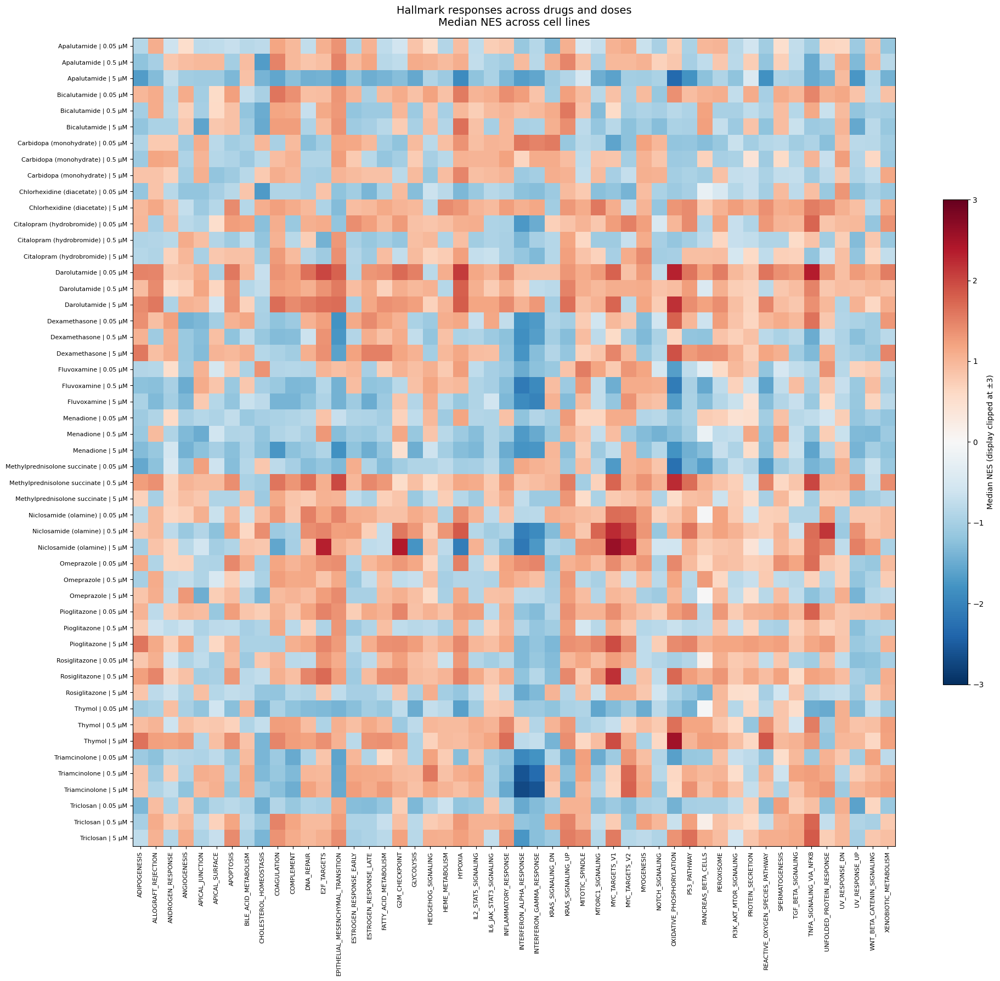

Overview matrix: (50, 50)
Saved overview heatmap.


In [ ]:
# Drug × dose Hallmark overview heatmap for all 5 cell lines

import numpy as np
import matplotlib.pyplot as plt

# 1. 이미 저장한 전체 NES matrix에 조건 정보 연결
meta = adata.obs[["drug", "concentration"]].copy()

overview_input = nes_matrix.join(meta)

# 2. 물질 × 농도별 5개 세포주의 NES 중앙값
overview = (
    overview_input
    .groupby(["drug", "concentration"], observed=True)[
        nes_matrix.columns.tolist()
    ]
    .median()
    .sort_index()
)

assert overview.shape == (50, 50)

# 3. CSV 저장
overview.to_csv(
    RESULTS / "Hallmark_drug_dose_median_NES.csv"
)

# 4. Heatmap
row_labels = [
    f"{drug} | {dose:g} µM"
    for drug, dose in overview.index
]

col_labels = [
    term.replace("HALLMARK_", "")
    for term in overview.columns
]

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 18))

im = ax.imshow(
    np.ma.masked_invalid(overview.to_numpy(dtype=float)),
    aspect="auto",
    cmap=cmap,
    vmin=-3,
    vmax=3
)

ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(
    col_labels,
    rotation=90,
    fontsize=8
)

ax.set_title(
    "Hallmark responses across drugs and doses\n"
    "Median NES across cell lines",
    fontsize=14,
    pad=16
)

fig.colorbar(
    im,
    ax=ax,
    label="Median NES (display clipped at ±3)",
    shrink=0.6
)

plt.tight_layout()

fig.savefig(
    RESULTS / "Hallmark_drug_dose_overview.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Overview matrix:", overview.shape)
print("Saved overview heatmap.")

Clustering pathways: 50
Pathways displayed separately: []


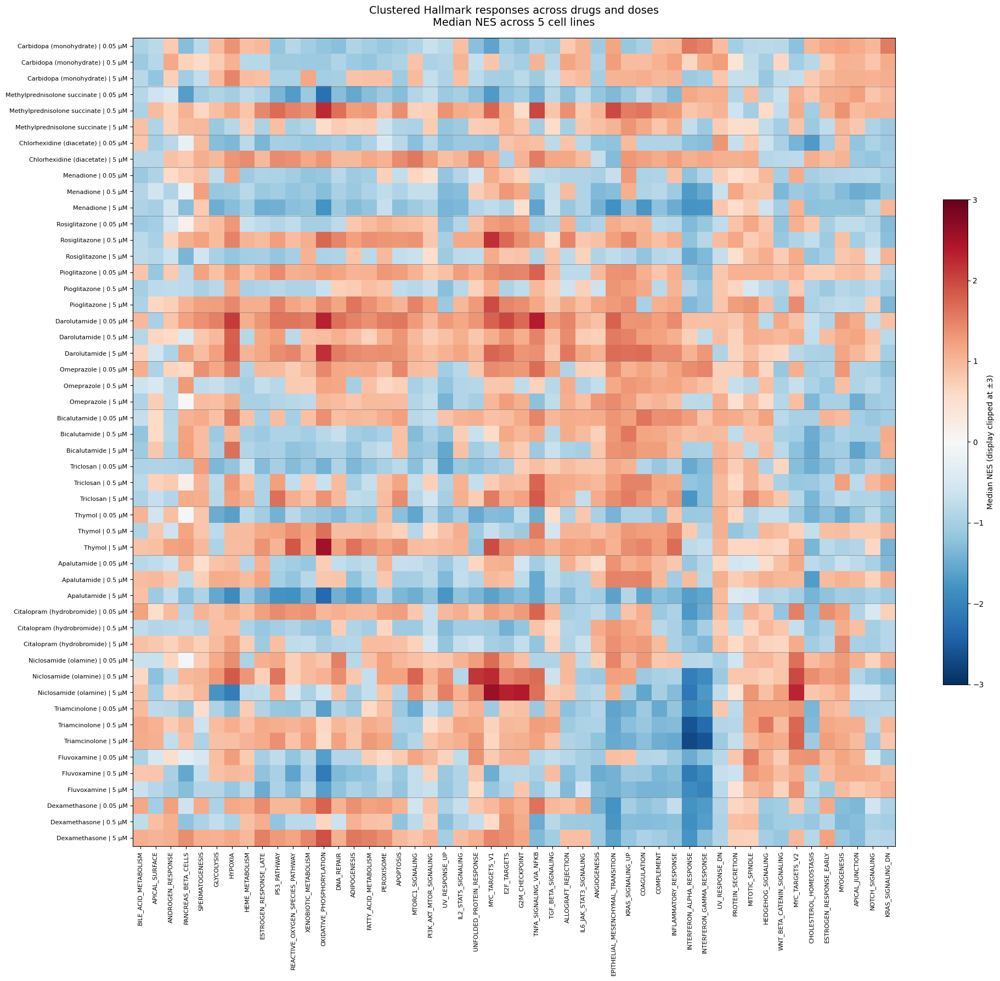

Clustered matrix: (50, 50)
Saved clustered heatmap.


In [ ]:
# Clustered Hallmark overview heatmap for all 5 cell lines

import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


# 1. Missing value가 없는 Hallmark만 클러스터링에 사용
complete_cols = overview.columns[
    overview.notna().all(axis=0)
]

partial_cols = overview.columns[
    ~overview.notna().all(axis=0)
]

print("Clustering pathways:", len(complete_cols))
print("Pathways displayed separately:", partial_cols.tolist())


# 2. 물질별 평균 NES 패턴
#    클러스터링 순서 계산에만 사용
drug_profile = (
    overview[complete_cols]
    .groupby(level="drug", observed=True)
    .mean()
)

# Pearson correlation distance
drug_distance = pdist(
    drug_profile.to_numpy(),
    metric="correlation"
)

assert np.isfinite(drug_distance).all()

drug_linkage = linkage(
    drug_distance,
    method="average",
    optimal_ordering=True
)

drug_order = drug_profile.index[
    leaves_list(drug_linkage)
]


# 3. 같은 물질의 농도는 서로 붙여서 유지
row_order = [
    idx
    for drug in drug_order
    for idx in overview.index
    if idx[0] == drug
]


# 4. Pathway 클러스터링
pathway_distance = pdist(
    overview[complete_cols].to_numpy().T,
    metric="correlation"
)

assert np.isfinite(pathway_distance).all()

pathway_linkage = linkage(
    pathway_distance,
    method="average",
    optimal_ordering=True
)

pathway_order = complete_cols[
    leaves_list(pathway_linkage)
].tolist()

# 누락이 있는 gene set은 마지막에 표시
column_order = pathway_order + partial_cols.tolist()


# 5. 순서 재배치
clustered = overview.loc[
    row_order,
    column_order
]


# 6. Heatmap
row_labels = [
    f"{drug} | {dose:g} µM"
    for drug, dose in clustered.index
]

col_labels = [
    term.replace("HALLMARK_", "")
    for term in clustered.columns
]

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 18))

im = ax.imshow(
    np.ma.masked_invalid(
        clustered.to_numpy(dtype=float)
    ),
    aspect="auto",
    cmap=cmap,
    vmin=-3,
    vmax=3
)

ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(
    col_labels,
    rotation=90,
    fontsize=8
)

# 물질 사이에 구분선 추가
position = 0

for drug in drug_order:

    n_rows = sum(
        idx[0] == drug
        for idx in clustered.index
    )

    position += n_rows

    if position < len(clustered):
        ax.axhline(
            position - 0.5,
            color="gray",
            linewidth=0.5
        )

ax.set_title(
    "Clustered Hallmark responses across drugs and doses\n"
    "Median NES across 5 cell lines",
    fontsize=14,
    pad=16
)

fig.colorbar(
    im,
    ax=ax,
    label="Median NES (display clipped at ±3)",
    shrink=0.6
)

plt.tight_layout()

fig.savefig(
    RESULTS / "Hallmark_drug_dose_clustered.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 재정렬된 행렬 저장
clustered.to_csv(
    RESULTS / "Hallmark_drug_dose_clustered.csv"
)

print("Clustered matrix:", clustered.shape)
print("Saved clustered heatmap.")

In [ ]:
############# 클러스터링 관계도 표시하기?
#########근데 이건 대표 50개에 대한것이고, 주요 pathway나 다른 분석되지 않은 주요요소까지 따로 뽑아서 클러스터링하면 또 다를지도.

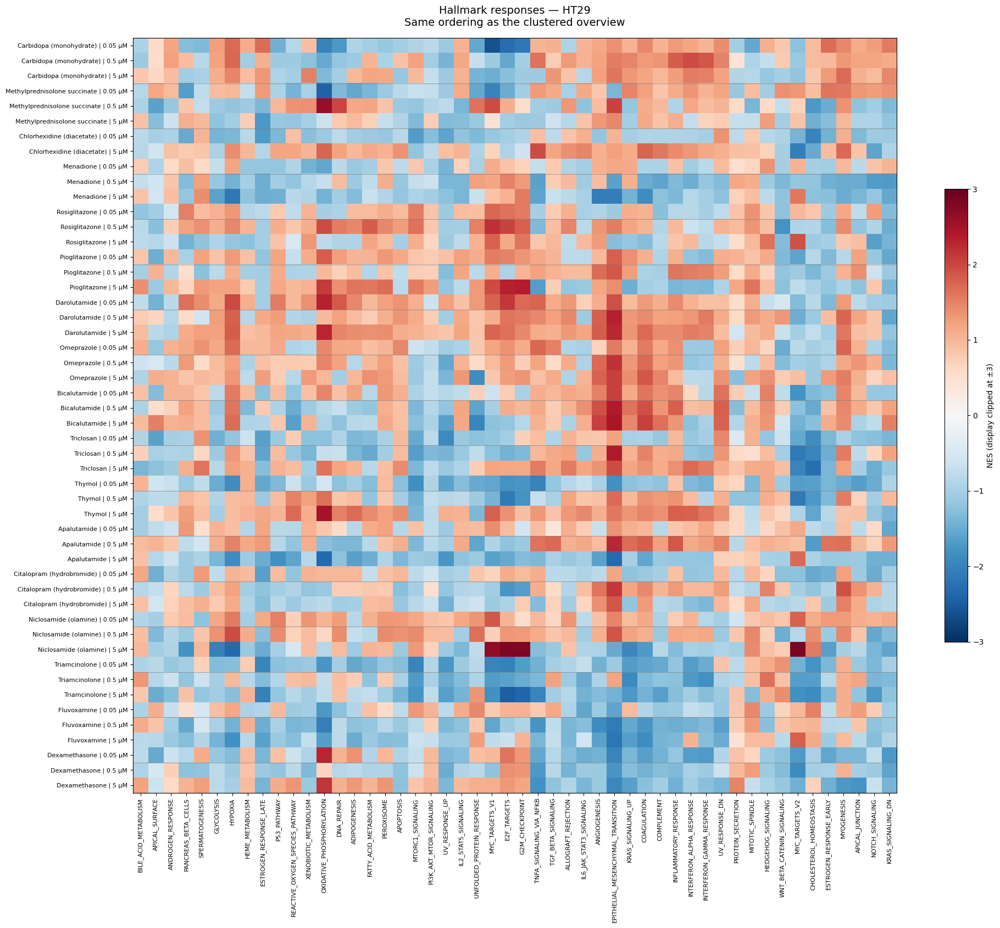

Saved: HT29 | (50, 50)


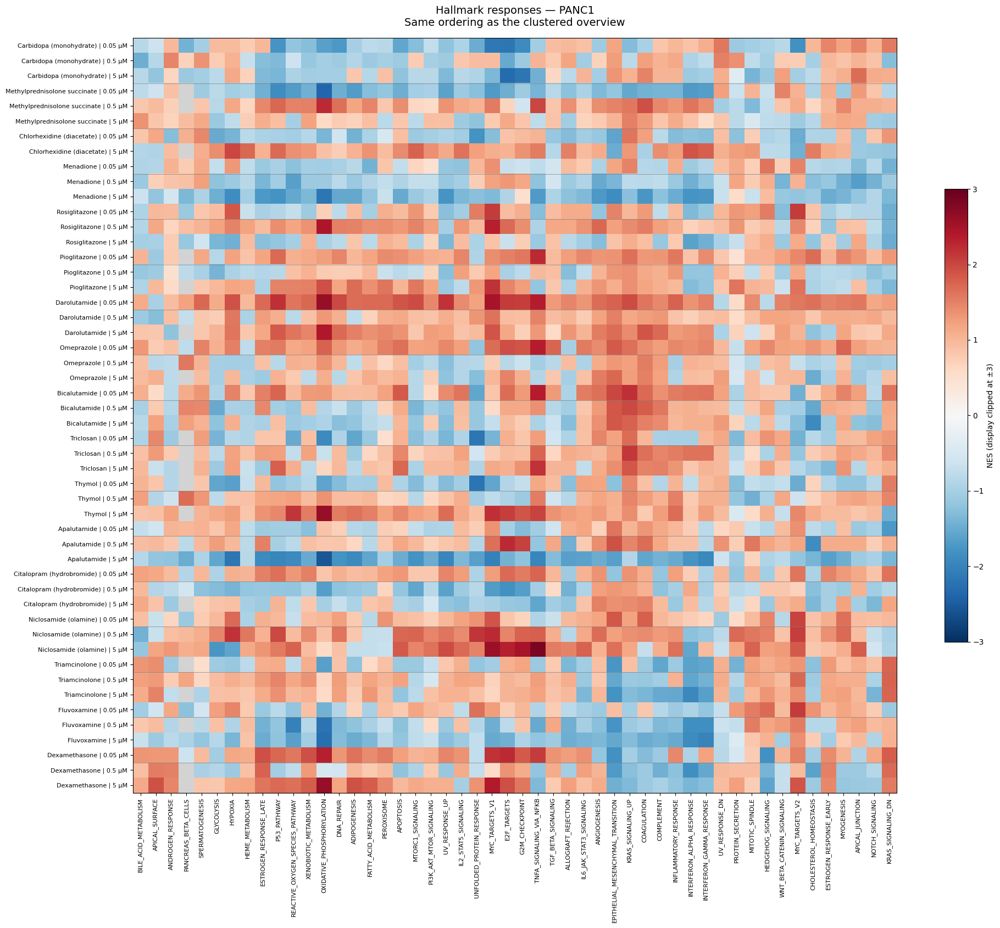

Saved: PANC1 | (50, 50)


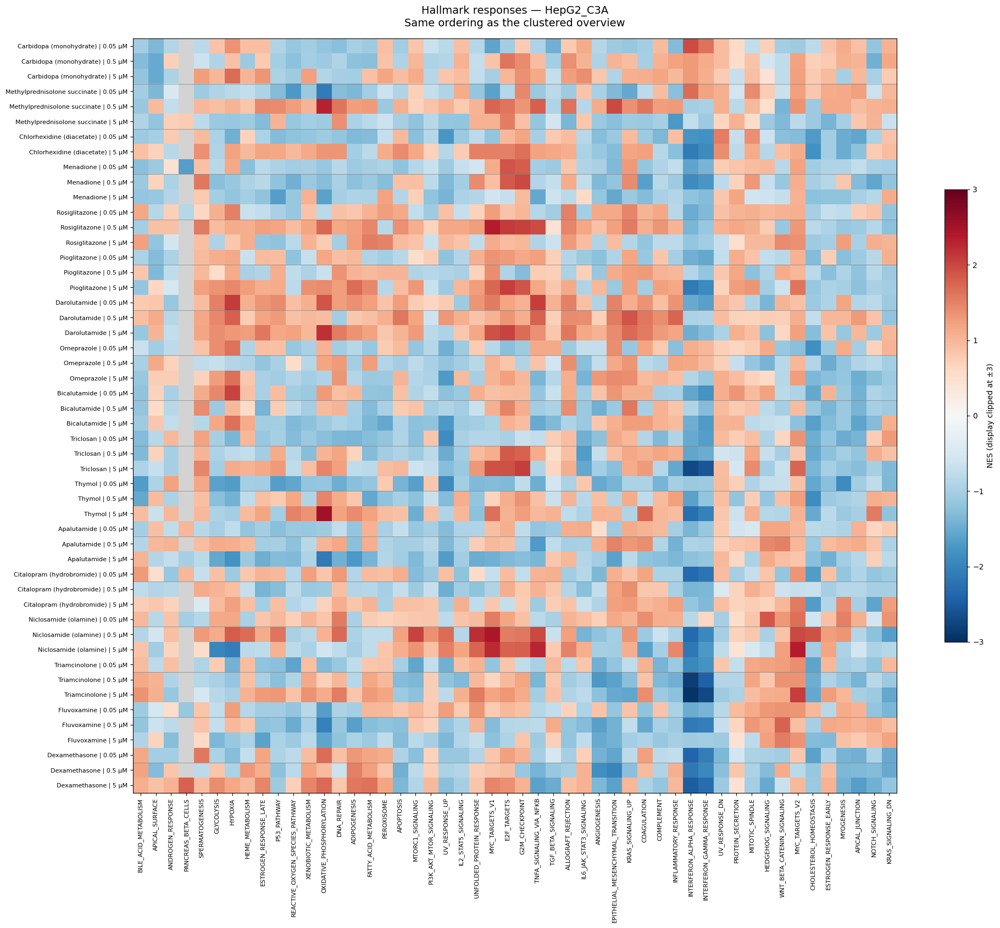

Saved: HepG2_C3A | (50, 50)


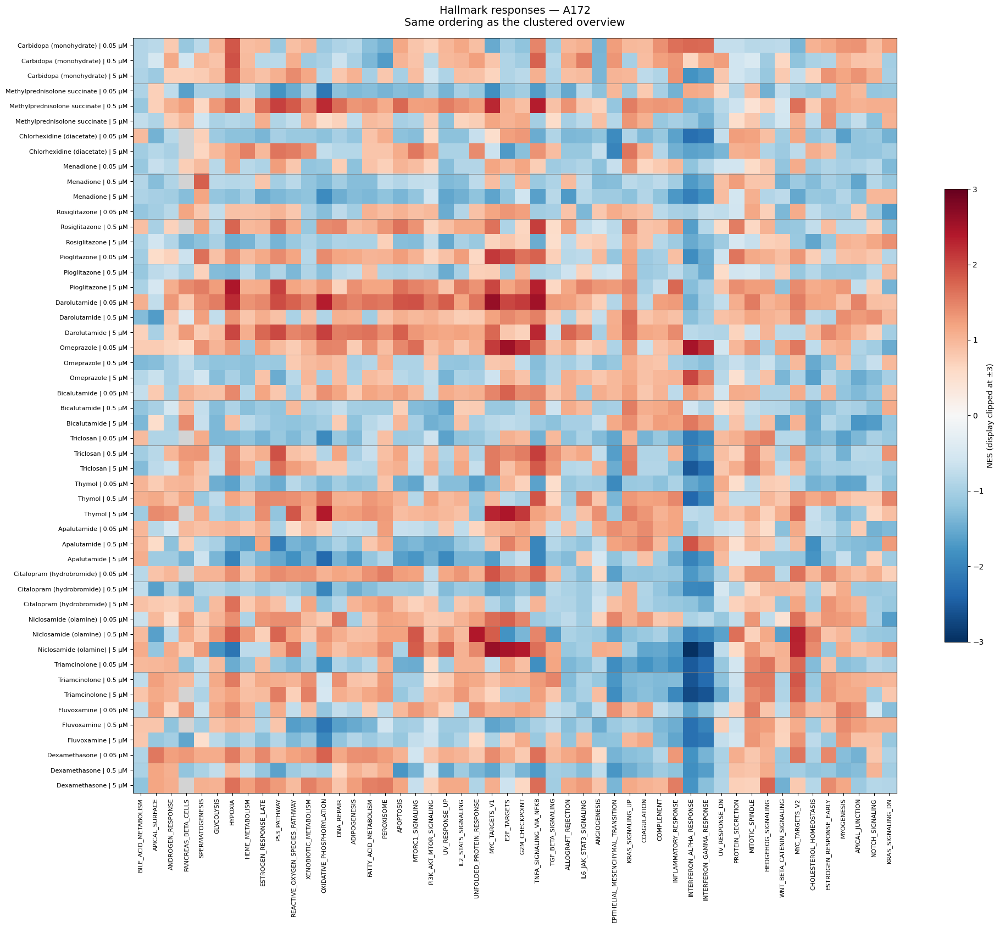

Saved: A172 | (50, 50)


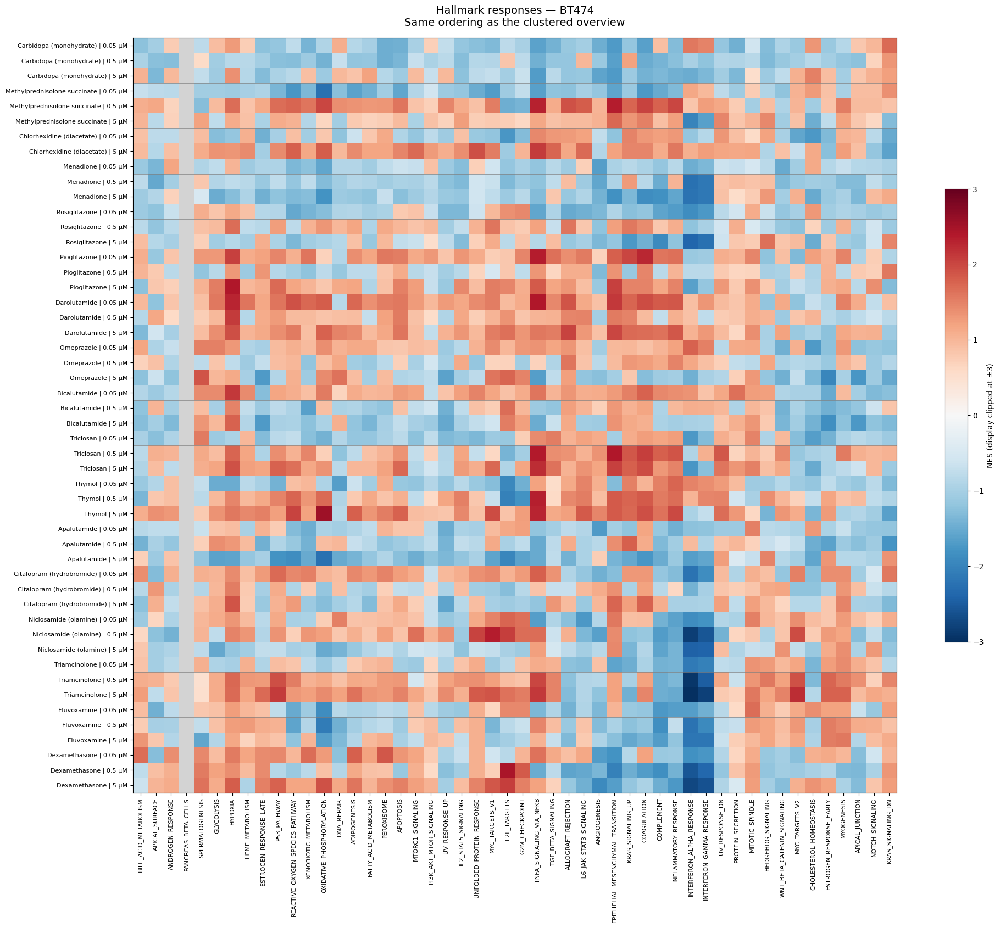

Saved: BT474 | (50, 50)


In [ ]:
# Cell-line-specific Hallmark heatmaps
# Same row / column order / color scale across all cell lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cell_lines = ["HT29", "PANC1", "HepG2_C3A", "A172", "BT474"]

meta = adata.obs[["cell_line", "drug", "concentration"]].copy()

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

for cell_line in cell_lines:

    # 1. 해당 세포주의 50개 조건 선택
    condition_ids = meta.index[
        meta["cell_line"].astype(str) == cell_line
    ]

    matrix = nes_matrix.loc[condition_ids].copy()

    # 2. condition_id 대신 물질 × 농도를 행 인덱스로 사용
    matrix.index = pd.MultiIndex.from_frame(
        meta.loc[condition_ids, ["drug", "concentration"]]
    )

    assert matrix.index.is_unique

    # 3. 앞선 clustered heatmap과 동일한 행/열 순서
    matrix = matrix.reindex(
        index=clustered.index,
        columns=clustered.columns
    )

    assert matrix.shape == (50, 50)

    # 4. 시각화
    fig, ax = plt.subplots(figsize=(20, 17))

    im = ax.imshow(
        np.ma.masked_invalid(matrix.to_numpy(dtype=float)),
        aspect="auto",
        cmap=cmap,
        vmin=-3,
        vmax=3
    )

    ax.set_yticks(range(len(matrix)))
    ax.set_yticklabels(
        [f"{drug} | {dose:g} µM" for drug, dose in matrix.index],
        fontsize=8
    )

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(
        [term.replace("HALLMARK_", "") for term in matrix.columns],
        rotation=90,
        fontsize=8
    )

    # 물질 간 경계선
    for pos in range(3, 50, 3):
        ax.axhline(
            pos - 0.5,
            color="gray",
            linewidth=0.5
        )

    ax.set_title(
        f"Hallmark responses — {cell_line}\n"
        "Same ordering as the clustered overview",
        fontsize=14,
        pad=16
    )

    fig.colorbar(
        im,
        ax=ax,
        label="NES (display clipped at ±3)",
        shrink=0.6
    )

    plt.tight_layout()

    # 5. 각 세포주별 이미지와 행렬 저장
    fig.savefig(
        RESULTS / f"Hallmark_{cell_line}_heatmap.png",
        dpi=200,
        bbox_inches="tight"
    )

    matrix.to_csv(
        RESULTS / f"Hallmark_{cell_line}_NES_matrix.csv"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {cell_line} | {matrix.shape}")

# Exploratory analysis - remove later?

In [ ]:
# Summarize pathway heterogeneity across cell lines

import pandas as pd

# 1. 전체 결과에서 필요한 정보만 사용
df = hallmark_all[
    ["drug", "concentration", "cell_line",
     "Term", "NES", "FDR q-val"]
].copy()

df["NES"] = pd.to_numeric(df["NES"])
df["FDR q-val"] = pd.to_numeric(df["FDR q-val"])

df["positive_supported"] = (
    (df["NES"] > 0) & (df["FDR q-val"] < 0.05)
)

df["negative_supported"] = (
    (df["NES"] < 0) & (df["FDR q-val"] < 0.05)
)

# 2. 같은 물질 × 농도 × pathway의 세포주 간 차이
comparison = (
    df.groupby(
        ["drug", "concentration", "Term"],
        observed=True
    )
    .agg(
        n_cell_lines=("cell_line", "nunique"),
        min_NES=("NES", "min"),
        max_NES=("NES", "max"),
        n_positive_supported=("positive_supported", "sum"),
        n_negative_supported=("negative_supported", "sum")
    )
    .reset_index()
)

# 다섯 세포주 결과가 모두 있는 경우만 비교
comparison = comparison.loc[
    comparison["n_cell_lines"] == 5
].copy()

comparison["NES_range"] = (
    comparison["max_NES"] - comparison["min_NES"]
)

# 양쪽 방향에 각각 FDR 근거가 있는 경우
comparison["opposite_supported"] = (
    (comparison["n_positive_supported"] > 0) &
    (comparison["n_negative_supported"] > 0)
)

# 3. 물질 × 농도별 세포주 차이 요약
drug_dose_summary = (
    comparison.groupby(
        ["drug", "concentration"],
        observed=True
    )
    .agg(
        n_pathways=("Term", "size"),
        n_opposite=("opposite_supported", "sum"),
        median_NES_range=("NES_range", "median")
    )
    .reset_index()
    .sort_values(
        ["n_opposite", "median_NES_range"],
        ascending=[False, False]
    )
)

print("Drug-dose overview:")
display(drug_dose_summary.head(15).round(3))

# 4. 양쪽 방향에 FDR 근거가 있는 구체적인 pathway
opposite = (
    comparison.loc[comparison["opposite_supported"]]
    .sort_values("NES_range", ascending=False)
)

print("\nOpposite-direction pathway candidates:")
print("Total candidates:", len(opposite))

display(
    opposite[
        ["drug", "concentration", "Term",
         "min_NES", "max_NES", "NES_range",
         "n_positive_supported", "n_negative_supported"]
    ].head(15).round(3)
)

# 5. 저장
comparison.to_csv(
    RESULTS / "Hallmark_cross_cellline_comparison.csv",
    index=False
)

drug_dose_summary.to_csv(
    RESULTS / "Hallmark_drug_dose_heterogeneity_summary.csv",
    index=False
)

opposite.to_csv(
    RESULTS / "Hallmark_opposite_direction_candidates.csv",
    index=False
)

print("\nResults saved.")

Drug-dose overview:


,drug,concentration,n_pathways,n_opposite,median_NES_range
46,Triamcinolone,5.00,49,6,2.327
17,Dexamethasone,0.05,49,3,2.400
48,Triclosan,0.50,49,3,2.312
10,Chlorhexidine (diacetate),5.00,49,3,2.234
30,Niclosamide (olamine),0.50,49,3,2.174
49,Triclosan,5.00,49,3,2.165
43,Thymol,5.00,49,2,2.028
31,Niclosamide (olamine),5.00,49,1,2.541
1,Apalutamide,0.50,49,1,2.322
45,Triamcinolone,0.50,49,1,2.302



Opposite-direction pathway candidates:
Total candidates: 30


,drug,concentration,Term,min_NES,max_NES,NES_range,n_positive_supported,n_negative_supported
2475,Triclosan,5.0,HALLMARK_INTERFERON_ALPHA_RESPONSE,-2.712,1.710,4.422,1,3
2476,Triclosan,5.0,HALLMARK_INTERFERON_GAMMA_RESPONSE,-2.574,1.538,4.112,1,2
2312,Triamcinolone,5.0,HALLMARK_E2F_TARGETS,-2.482,1.629,4.110,1,1
2344,Triamcinolone,5.0,HALLMARK_TNFA_SIGNALING_VIA_NFKB,-1.986,2.120,4.106,1,1
2413,Triclosan,0.5,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,-1.654,2.404,4.058,2,1
2332,Triamcinolone,5.0,HALLMARK_MYC_TARGETS_V2,-1.828,2.214,4.042,3,1
2175,Thymol,5.0,HALLMARK_INTERFERON_ALPHA_RESPONSE,-2.258,1.769,4.027,1,1
525,Chlorhexidine (diacetate),5.0,HALLMARK_INTERFERON_ALPHA_RESPONSE,-2.093,1.877,3.971,1,2
2317,Triamcinolone,5.0,HALLMARK_G2M_CHECKPOINT,-2.369,1.532,3.901,1,1
1512,Niclosamide (olamine),0.5,HALLMARK_E2F_TARGETS,-1.800,2.080,3.879,3,1



Results saved.


In [ ]:
# Drug-centered Hallmark response summary

import numpy as np
import pandas as pd

df = hallmark_all.copy()

df["NES"] = pd.to_numeric(df["NES"])
df["FDR q-val"] = pd.to_numeric(df["FDR q-val"])

# 1. 방향별 enrichment 근거
df["positive_supported"] = (
    (df["NES"] > 0) & (df["FDR q-val"] < 0.05)
)

df["negative_supported"] = (
    (df["NES"] < 0) & (df["FDR q-val"] < 0.05)
)

# 2. 물질 × pathway별 전체 조건 요약
drug_pathway_summary = (
    df.groupby(["drug", "Term"], observed=True)
    .agg(
        n_tested=("condition_id", "nunique"),
        n_positive_supported=("positive_supported", "sum"),
        n_negative_supported=("negative_supported", "sum"),
        median_NES=("NES", "median"),
        min_NES=("NES", "min"),
        max_NES=("NES", "max")
    )
    .reset_index()
)

drug_pathway_summary["n_supported"] = (
    drug_pathway_summary["n_positive_supported"]
    + drug_pathway_summary["n_negative_supported"]
)

# 3. 양쪽 방향이 모두 존재하는 경우도 보존
pos = drug_pathway_summary["n_positive_supported"] > 0
neg = drug_pathway_summary["n_negative_supported"] > 0

drug_pathway_summary["response_pattern"] = np.select(
    [
        pos & neg,
        pos & ~neg,
        ~pos & neg
    ],
    [
        "mixed",
        "positive_only",
        "negative_only"
    ],
    default="none_supported"
)

# 4. 전체 결과 저장: 17개 물질 × 50개 pathway
drug_pathway_summary.to_csv(
    RESULTS / "Hallmark_drug_pathway_summary.csv",
    index=False
)

print("Drugs:", drug_pathway_summary["drug"].nunique())
print("Pathways:", drug_pathway_summary["Term"].nunique())
print("Summary rows:", len(drug_pathway_summary))

# 5. 예시: Niclosamide
niclo_summary = drug_pathway_summary.loc[
    drug_pathway_summary["drug"] == "Niclosamide (olamine)"
].copy()

niclo_summary = niclo_summary.sort_values(
    ["n_supported", "Term"],
    ascending=[False, True]
)

print("\nNiclosamide: pathways with the most supported conditions")

display(
    niclo_summary[
        [
            "Term",
            "n_tested",
            "n_positive_supported",
            "n_negative_supported",
            "response_pattern",
            "median_NES"
        ]
    ].head(15).round(3)
)

print("\nSaved drug-centered summary.")

Drugs: 17
Pathways: 50
Summary rows: 850

Niclosamide: pathways with the most supported conditions


,Term,n_tested,n_positive_supported,n_negative_supported,response_pattern,median_NES
531,HALLMARK_MYC_TARGETS_V1,15,11,0,positive_only,1.895
532,HALLMARK_MYC_TARGETS_V2,15,11,0,positive_only,1.958
512,HALLMARK_E2F_TARGETS,15,9,1,mixed,1.527
521,HALLMARK_HYPOXIA,15,5,4,mixed,1.396
517,HALLMARK_G2M_CHECKPOINT,15,8,0,positive_only,1.574
525,HALLMARK_INTERFERON_ALPHA_RESPONSE,15,0,8,negative_only,-1.548
544,HALLMARK_TNFA_SIGNALING_VIA_NFKB,15,7,1,mixed,1.228
526,HALLMARK_INTERFERON_GAMMA_RESPONSE,15,0,7,negative_only,-1.134
545,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,15,7,0,positive_only,1.450
530,HALLMARK_MTORC1_SIGNALING,15,6,0,positive_only,1.355



Saved drug-centered summary.


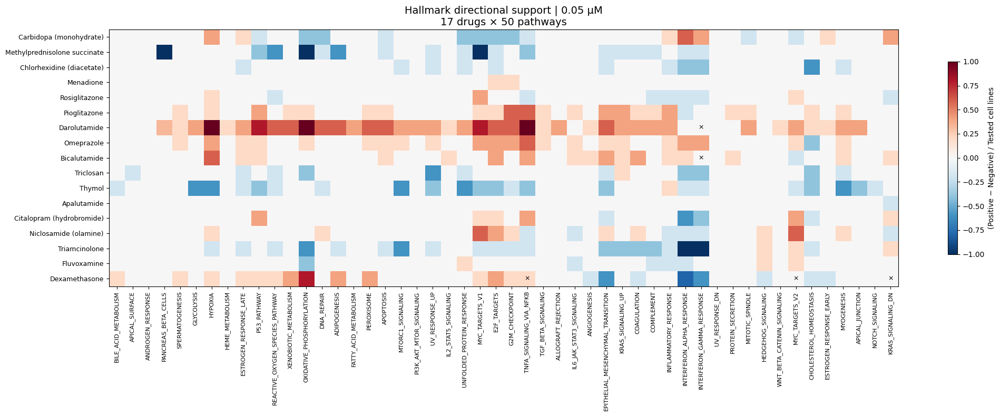

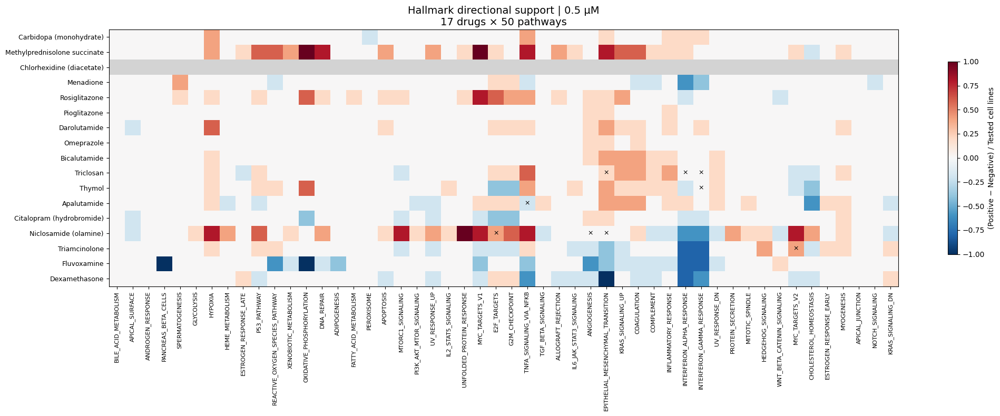

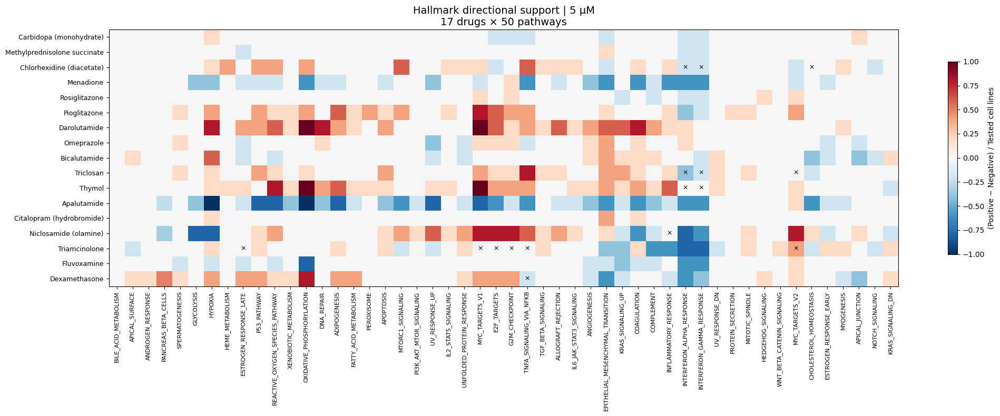

Saved dose-level summary and 3 heatmaps.


In [ ]:
# Drug × pathway support maps by dose

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = hallmark_all.copy()

df["NES"] = pd.to_numeric(df["NES"])
df["FDR q-val"] = pd.to_numeric(df["FDR q-val"])
df["concentration"] = pd.to_numeric(df["concentration"])

df["pos"] = (df["NES"] > 0) & (df["FDR q-val"] < 0.05)
df["neg"] = (df["NES"] < 0) & (df["FDR q-val"] < 0.05)

# 물질 × 농도 × pathway별 5개 세포주 요약
dose_summary = (
    df.groupby(["drug", "concentration", "Term"], observed=True)
    .agg(
        n_tested=("cell_line", "nunique"),
        n_pos=("pos", "sum"),
        n_neg=("neg", "sum")
    )
    .reset_index()
)

dose_summary["signed_fraction"] = (
    (dose_summary["n_pos"] - dose_summary["n_neg"])
    / dose_summary["n_tested"]
)

dose_summary["opposite"] = (
    (dose_summary["n_pos"] > 0) &
    (dose_summary["n_neg"] > 0)
)

# 분석되지 않은 조합까지 포함해 저장
drugs = list(dict.fromkeys(
    clustered.index.get_level_values("drug")
))
terms = clustered.columns.tolist()
doses = [0.05, 0.5, 5.0]

full_index = pd.MultiIndex.from_product(
    [drugs, doses, terms],
    names=["drug", "concentration", "Term"]
)

dose_summary = (
    dose_summary
    .set_index(["drug", "concentration", "Term"])
    .reindex(full_index)
    .reset_index()
)

dose_summary.to_csv(
    RESULTS / "Hallmark_drug_dose_support_summary.csv",
    index=False
)

# 농도별 그림 3장
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")

for dose in doses:

    subset = dose_summary.loc[
        dose_summary["concentration"] == dose
    ]

    score = subset.pivot(
        index="drug",
        columns="Term",
        values="signed_fraction"
    ).reindex(index=drugs, columns=terms)

    opposite = subset.pivot(
        index="drug",
        columns="Term",
        values="opposite"
    ).reindex(index=drugs, columns=terms)

    fig, ax = plt.subplots(figsize=(21, 8))

    im = ax.imshow(
        np.ma.masked_invalid(score.to_numpy(dtype=float)),
        aspect="auto",
        cmap=cmap,
        vmin=-1,
        vmax=1
    )

    ax.set_yticks(range(len(drugs)))
    ax.set_yticklabels(drugs, fontsize=9)

    ax.set_xticks(range(len(terms)))
    ax.set_xticklabels(
        [t.replace("HALLMARK_", "") for t in terms],
        rotation=90,
        fontsize=8
    )

    # 양·음 enrichment 근거가 모두 존재하는 칸 표시
    mixed = opposite.fillna(False).to_numpy(dtype=bool)

    for i, j in np.argwhere(mixed):
        ax.text(
            j, i, "×",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

    ax.set_title(
        f"Hallmark directional support | {dose:g} µM\n"
        "17 drugs × 50 pathways",
        fontsize=14
    )

    fig.colorbar(
        im,
        ax=ax,
        label="(Positive − Negative) / Tested cell lines",
        shrink=0.75
    )

    plt.tight_layout()

    fig.savefig(
        RESULTS / f"Hallmark_support_{dose:g}uM.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

print("Saved dose-level summary and 3 heatmaps.")

In [ ]:
# Connect curated MOA to pathway results

import pandas as pd

# 1. 저장된 MOA annotation 읽기
moa_map = pd.read_csv(
    RESULTS / "drug_moa_annotations_curated.csv"
)

assert moa_map["drug"].is_unique

# 2. 물질 × 농도 × pathway 결과에 MOA 연결
moa_pathway = dose_summary.merge(
    moa_map[
        ["drug", "moa_fine", "moa_curated", "moa_source"]
    ],
    on="drug",
    how="left",
    validate="many_to_one",
    indicator=True
)

assert moa_pathway["_merge"].eq("both").all()

moa_pathway = moa_pathway.drop(columns="_merge")

# 3. 저장
moa_pathway.to_csv(
    RESULTS / "Hallmark_drug_dose_MOA_summary.csv",
    index=False
)

# 4. MOA annotation 확인
print("Drug MOA annotations:")

display(
    moa_map[
        ["drug", "moa_fine", "moa_curated", "moa_source"]
    ].sort_values("moa_curated")
)

# 5. 동일 MOA에 속한 물질 수
print("\nDrugs per curated MOA:")

moa_counts = (
    moa_map.dropna(subset=["moa_curated"])
    .groupby("moa_curated")["drug"]
    .nunique()
    .sort_values(ascending=False)
)

display(moa_counts)

print("\nSaved MOA-linked pathway summary.")

Drug MOA annotations:


,drug,moa_fine,moa_curated,moa_source
0,Apalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
1,Bicalutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
2,Darolutamide,Androgen receptor antagonist,Androgen receptor antagonist,Tahoe annotation
12,Omeprazole,unclear,Aryl hydrocarbon receptor activator,user-curated
6,Carbidopa (monohydrate),unclear,Aryl hydrocarbon receptor agonist,user-curated
3,Dexamethasone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
4,Methylprednisolone succinate,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
5,Triamcinolone,Glucocorticoid receptor agonist,Glucocorticoid receptor agonist,Tahoe annotation
7,Chlorhexidine (diacetate),unclear,Membrane disorder/permeability,user-curated
11,Niclosamide (olamine),unclear,OXPHOS Uncoupling,user-curated



Drugs per curated MOA:


moa_curated
Androgen receptor antagonist                3
Glucocorticoid receptor agonist             3
PPAR gamma agonist                          2
Serotonin reuptake inhibitor                2
Aryl hydrocarbon receptor activator         1
Aryl hydrocarbon receptor agonist           1
Membrane disorder/permeability              1
OXPHOS Uncoupling, Complex II inhibition    1
OXPHOS Uncoupling                           1
Putative membrane intercalation             1
Redox cycling                               1
Name: drug, dtype: int64


Saved MOA-linked pathway summary.


In [ ]:
# Connect curated MOA and broad MOA families

import pandas as pd

# 1. 기존 curated MOA 불러오기
moa_map = pd.read_csv(
    RESULTS / "drug_moa_annotations_curated.csv"
)

assert moa_map["drug"].is_unique
assert moa_map["drug"].nunique() == 17

# 2. 세부 MOA는 보존하고 상위 계열 추가
moa_map["moa_family"] = moa_map["moa_curated"].astype("object")

family_map = {
    # Membrane-related
    "Chlorhexidine (diacetate)": "Membrane perturbation",
    "Thymol": "Membrane perturbation",

    # AHR-related
    "Carbidopa (monohydrate)": "AHR signaling activation",
    "Omeprazole": "AHR signaling activation",

    # Mitochondrial uncoupling
    "Niclosamide (olamine)": "Mitochondrial OXPHOS uncoupling",
    "Triclosan": "Mitochondrial OXPHOS uncoupling",
}

assert moa_map["drug"].isin(family_map).sum() == len(family_map)

for drug, family in family_map.items():
    moa_map.loc[
        moa_map["drug"] == drug,
        "moa_family"
    ] = family

# 3. 새로운 분류표 저장 (원본 보존)
moa_map.to_csv(
    RESULTS / "drug_moa_annotations_with_family.csv",
    index=False
)

# 4. 기존 pathway 결과에 MOA 계열 연결
moa_pathway = dose_summary.merge(
    moa_map[
        [
            "drug",
            "moa_fine",
            "moa_curated",
            "moa_family",
            "moa_source"
        ]
    ],
    on="drug",
    how="left",
    validate="many_to_one",
    indicator=True
)

assert moa_pathway["_merge"].eq("both").all()

moa_pathway = moa_pathway.drop(columns="_merge")

assert len(moa_pathway) == len(dose_summary)

# 5. MOA가 추가된 pathway 결과 저장
moa_pathway.to_csv(
    RESULTS / "Hallmark_drug_dose_MOA_family_summary.csv",
    index=False
)

# 6. 그룹별 물질 목록 확인
family_groups = (
    moa_map.groupby("moa_family")["drug"]
    .agg(["count", lambda x: ", ".join(sorted(x))])
)

family_groups.columns = ["n_drugs", "drugs"]

print("MOA families with multiple drugs:")

display(
    family_groups.loc[
        family_groups["n_drugs"] >= 2
    ].sort_index()
)

print("\nSaved MOA family annotations and pathway summary.")

MOA families with multiple drugs:


,n_drugs,drugs
moa_family,,
AHR signaling activation,2,"Carbidopa (monohydrate), Omeprazole"
Androgen receptor antagonist,3,"Apalutamide, Bicalutamide, Darolutamide"
Glucocorticoid receptor agonist,3,"Dexamethasone, Methylprednisolone succinate, T..."
Membrane perturbation,2,"Chlorhexidine (diacetate), Thymol"
Mitochondrial OXPHOS uncoupling,2,"Niclosamide (olamine), Triclosan"
PPAR gamma agonist,2,"Pioglitazone, Rosiglitazone"
Serotonin reuptake inhibitor,2,"Citalopram (hydrobromide), Fluvoxamine"



Saved MOA family annotations and pathway summary.


In [ ]:
# ============================================================
# 04-7B. Compare Hallmark patterns within MOA families
# ============================================================

import numpy as np
import pandas as pd
from itertools import combinations

# 조건 × pathway × 물질 NES 행렬
nes_by_drug = hallmark_all.pivot(
    index=["cell_line", "concentration", "Term"],
    columns="drug",
    values="NES"
)

pair_results = []

# MOA 계열별 물질 쌍
for family, group in moa_map.groupby("moa_family"):

    drugs = group["drug"].tolist()

    if len(drugs) < 2:
        continue

    for drug_a, drug_b in combinations(drugs, 2):

        # 두 물질 모두 결과가 있는 pathway만 비교
        matched = (
            nes_by_drug[[drug_a, drug_b]]
            .dropna()
            .reset_index()
        )

        for (cell_line, dose), sub in matched.groupby(
            ["cell_line", "concentration"]
        ):

            # 비교 가능한 pathway가 너무 적으면 제외
            if len(sub) < 30:
                continue

            r = sub[drug_a].corr(sub[drug_b])

            pair_results.append({
                "moa_family": family,
                "drug_a": drug_a,
                "drug_b": drug_b,
                "cell_line": cell_line,
                "concentration": dose,
                "n_pathways": len(sub),
                "pearson_r": r
            })

pair_similarity = pd.DataFrame(pair_results)

# 물질 쌍별로 세포주 × 농도 비교 결과 요약
pair_summary = (
    pair_similarity.groupby(
        ["moa_family", "drug_a", "drug_b"]
    )
    .agg(
        n_contexts=("pearson_r", "count"),
        median_r=("pearson_r", "median"),
        min_r=("pearson_r", "min"),
        max_r=("pearson_r", "max")
    )
    .reset_index()
    .sort_values(["moa_family", "drug_a", "drug_b"])
)

# 저장: 상세 결과와 요약 결과 모두 보존
pair_similarity.to_csv(
    RESULTS / "Hallmark_MOA_pair_similarity_by_context.csv",
    index=False
)

pair_summary.to_csv(
    RESULTS / "Hallmark_MOA_pair_similarity_summary.csv",
    index=False
)

print("MOA families compared:",
      pair_summary["moa_family"].nunique())

print("Drug pairs:", len(pair_summary))

print("Matched cell-line/dose comparisons:",
      len(pair_similarity))

print("\nWithin-MOA drug pair similarity:")

display(pair_summary.round(3))

print("\nSaved similarity results.")

MOA families compared: 7
Drug pairs: 11
Matched cell-line/dose comparisons: 160

Within-MOA drug pair similarity:


,moa_family,drug_a,drug_b,n_contexts,median_r,min_r,max_r
0,AHR signaling activation,Carbidopa (monohydrate),Omeprazole,15,-0.061,-0.311,0.277
1,Androgen receptor antagonist,Apalutamide,Bicalutamide,15,0.099,-0.138,0.679
2,Androgen receptor antagonist,Apalutamide,Darolutamide,15,0.041,-0.645,0.374
3,Androgen receptor antagonist,Bicalutamide,Darolutamide,15,0.273,-0.069,0.610
4,Glucocorticoid receptor agonist,Dexamethasone,Methylprednisolone succinate,15,-0.078,-0.669,0.184
5,Glucocorticoid receptor agonist,Dexamethasone,Triamcinolone,15,0.352,0.038,0.648
6,Glucocorticoid receptor agonist,Methylprednisolone succinate,Triamcinolone,15,0.123,-0.164,0.547
7,Membrane perturbation,Chlorhexidine (diacetate),Thymol,10,0.406,-0.047,0.750
8,Mitochondrial OXPHOS uncoupling,Niclosamide (olamine),Triclosan,15,-0.053,-0.282,0.364
9,PPAR gamma agonist,Pioglitazone,Rosiglitazone,15,0.183,-0.240,0.400



Saved similarity results.


In [ ]:
# ============================================================
# 04-7C. Within-MOA vs Between-MOA similarity
# ============================================================

import numpy as np
import pandas as pd
from itertools import combinations

# 1. 조건별 Hallmark NES
nes_by_drug = hallmark_all.pivot(
    index=["cell_line", "concentration", "Term"],
    columns="drug",
    values="NES"
)

# MOA family lookup
family_lookup = moa_map.set_index("drug")["moa_family"].to_dict()

drugs = moa_map["drug"].tolist()

results = []

# 2. 같은 세포주·농도 안에서 모든 물질 쌍 비교
for (cell_line, dose), sub in nes_by_drug.groupby(
    level=["cell_line", "concentration"]
):

    for drug_a, drug_b in combinations(drugs, 2):

        matched = sub[[drug_a, drug_b]].dropna()

        if len(matched) < 30:
            continue

        r = matched[drug_a].corr(matched[drug_b])

        if not np.isfinite(r):
            continue

        same_moa = (
            family_lookup[drug_a] == family_lookup[drug_b]
        )

        results.append({
            "cell_line": cell_line,
            "concentration": dose,
            "drug_a": drug_a,
            "drug_b": drug_b,
            "pair_type": "within" if same_moa else "between",
            "n_pathways": len(matched),
            "pearson_r": r
        })

all_pair_similarity = pd.DataFrame(results)

# 3. 전체 분포 요약
print("All pair comparisons:")

display(
    all_pair_similarity.groupby("pair_type")["pearson_r"]
    .agg(["count", "median", "min", "max"])
    .round(3)
)

# 4. 세포주·농도를 맞춘 중앙값 비교
context_comparison = (
    all_pair_similarity.groupby(
        ["cell_line", "concentration", "pair_type"]
    )["pearson_r"]
    .median()
    .unstack("pair_type")
)

context_comparison["within_minus_between"] = (
    context_comparison["within"]
    - context_comparison["between"]
)

print("\nMatched cell-line/dose comparison:")

display(context_comparison.round(3))

print("\nMedian within-minus-between difference:",
      round(context_comparison["within_minus_between"].median(), 3))

# 5. 저장
all_pair_similarity.to_csv(
    RESULTS / "Hallmark_all_drug_pair_similarity.csv",
    index=False
)

context_comparison.to_csv(
    RESULTS / "Hallmark_MOA_within_vs_between_by_context.csv"
)

print("\nSaved similarity comparison.")

All pair comparisons:


,count,median,min,max
pair_type,,,,
between,1800,0.100,-0.752,0.808
within,160,0.124,-0.669,0.750



Matched cell-line/dose comparison:


pair_type                between  within  within_minus_between
cell_line concentration                                       
A172      0.05             0.175   0.240                 0.065
          0.50             0.120   0.098                -0.022
          5.00             0.053  -0.047                -0.100
BT474     0.05             0.057   0.092                 0.035
          0.50             0.089   0.187                 0.097
          5.00             0.158  -0.027                -0.185
HT29      0.05             0.106   0.121                 0.015
          0.50             0.163   0.172                 0.010
          5.00             0.063   0.073                 0.010
HepG2_C3A 0.05             0.096   0.117                 0.021
          0.50             0.172   0.179                 0.006
          5.00             0.177   0.151                -0.026
PANC1     0.05            -0.020  -0.053                -0.033
          0.50             0.043   0.206                 0.163
          5.00             0.010   0.072                 0.062


Median within-minus-between difference: 0.01

Saved similarity comparison.


# PCA analysis

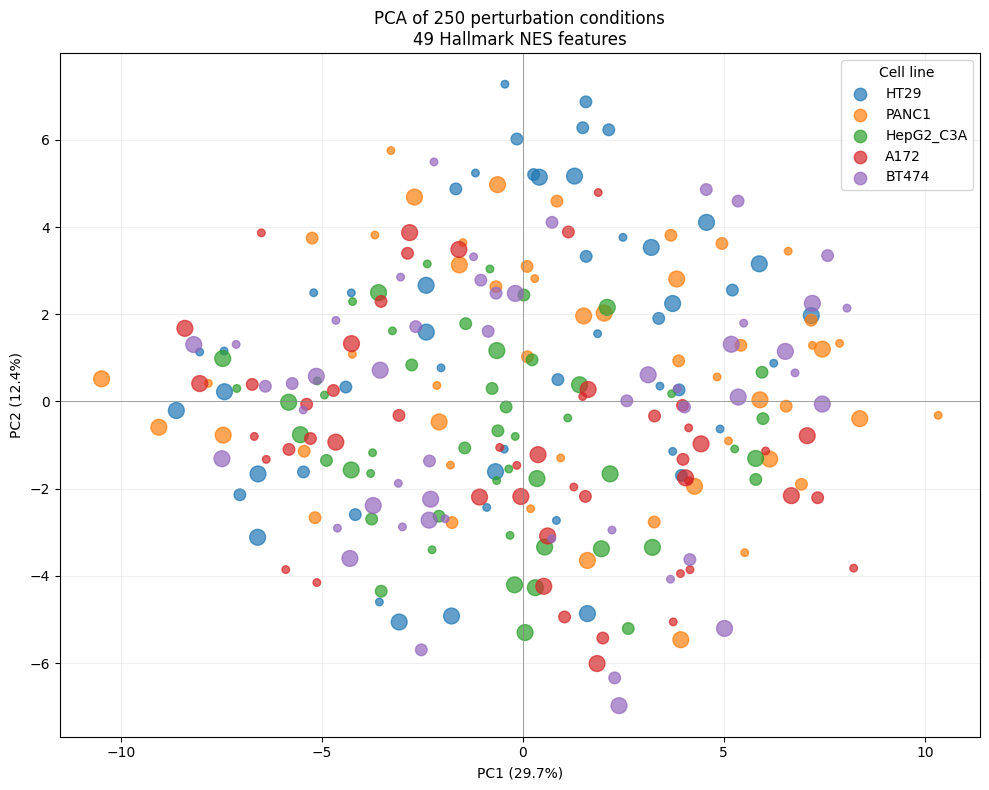

PCA input: (250, 49)
Explained variance: [0.297 0.124]
Saved PCA results.


In [ ]:
# ============================================================
# 04-8A. PCA of all conditions using Hallmark NES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 모든 조건에서 결과가 존재하는 Hallmark만 사용
features = nes_matrix.loc[
    :,
    nes_matrix.notna().all(axis=0)
].copy()

assert features.shape == (250, 49)

# 2. PCA
# sklearn PCA는 pathway별 평균을 자동으로 빼줌.
# 이번에는 pathway별 표준편차로 나누지는 않음.
pca = PCA(n_components=2)

coordinates = pca.fit_transform(features)

pca_result = adata.obs.loc[
    features.index,
    ["cell_line", "drug", "concentration"]
].copy()

pca_result["PC1"] = coordinates[:, 0]
pca_result["PC2"] = coordinates[:, 1]

pca_result["concentration"] = pd.to_numeric(
    pca_result["concentration"].astype(str)
)

# 3. 시각화
fig, ax = plt.subplots(figsize=(10, 8))

cell_lines = [
    "HT29", "PANC1", "HepG2_C3A", "A172", "BT474"
]

sizes = {0.05: 30, 0.5: 70, 5.0: 130}

colors = plt.get_cmap("tab10").colors

for i, cell_line in enumerate(cell_lines):

    sub = pca_result.loc[
        pca_result["cell_line"] == cell_line
    ]

    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=sub["concentration"].map(sizes),
        color=colors[i],
        alpha=0.7,
        label=cell_line
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"
)

ax.set_title(
    "PCA of 250 perturbation conditions\n"
    "49 Hallmark NES features"
)

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

ax.legend(title="Cell line")
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    RESULTS / "Hallmark_PCA_all_conditions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# 4. PCA 좌표와 pathway 기여도 저장
pca_result.to_csv(
    RESULTS / "Hallmark_PCA_coordinates.csv"
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=["PC1", "PC2"]
)

loadings.to_csv(
    RESULTS / "Hallmark_PCA_loadings.csv"
)

print("PCA input:", features.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

print("Saved PCA results.")

In [ ]:
# 04-8B. Identify pathways contributing to PC1 and PC2

for pc in ["PC1", "PC2"]:

    print(f"\n{'=' * 50}")
    print(f"{pc}: positive loadings")

    display(
        loadings[pc]
        .sort_values(ascending=False)
        .head(8)
        .round(3)
    )

    print(f"\n{pc}: negative loadings")

    display(
        loadings[pc]
        .sort_values()
        .head(8)
        .round(3)
    )


PC1: positive loadings


Term
HALLMARK_OXIDATIVE_PHOSPHORYLATION          0.260
HALLMARK_TNFA_SIGNALING_VIA_NFKB            0.247
HALLMARK_P53_PATHWAY                        0.224
HALLMARK_APOPTOSIS                          0.212
HALLMARK_HYPOXIA                            0.212
HALLMARK_MYC_TARGETS_V1                     0.210
HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY    0.194
HALLMARK_UV_RESPONSE_UP                     0.188
Name: PC1, dtype: float64


PC1: negative loadings


Term
HALLMARK_KRAS_SIGNALING_DN             0.017
HALLMARK_HEDGEHOG_SIGNALING            0.024
HALLMARK_BILE_ACID_METABOLISM          0.031
HALLMARK_UV_RESPONSE_DN                0.033
HALLMARK_MITOTIC_SPINDLE               0.035
HALLMARK_PROTEIN_SECRETION             0.038
HALLMARK_WNT_BETA_CATENIN_SIGNALING    0.043
HALLMARK_NOTCH_SIGNALING               0.051
Name: PC1, dtype: float64


PC2: positive loadings


Term
HALLMARK_INTERFERON_ALPHA_RESPONSE            0.327
HALLMARK_INTERFERON_GAMMA_RESPONSE            0.301
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION    0.278
HALLMARK_COMPLEMENT                           0.238
HALLMARK_COAGULATION                          0.221
HALLMARK_INFLAMMATORY_RESPONSE                0.220
HALLMARK_UV_RESPONSE_DN                       0.204
HALLMARK_KRAS_SIGNALING_UP                    0.176
Name: PC2, dtype: float64


PC2: negative loadings


Term
HALLMARK_MYC_TARGETS_V2              -0.237
HALLMARK_E2F_TARGETS                 -0.226
HALLMARK_MYC_TARGETS_V1              -0.220
HALLMARK_G2M_CHECKPOINT              -0.215
HALLMARK_UNFOLDED_PROTEIN_RESPONSE   -0.206
HALLMARK_MITOTIC_SPINDLE             -0.136
HALLMARK_MTORC1_SIGNALING            -0.133
HALLMARK_PI3K_AKT_MTOR_SIGNALING     -0.129
Name: PC2, dtype: float64

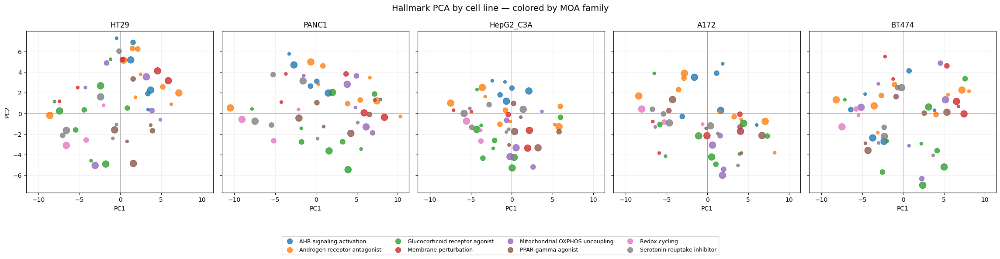

In [ ]:
# 04-8C. Existing PCA coordinates, faceted by cell line

import matplotlib.pyplot as plt
import numpy as np

plot_df = pca_result.copy()

family_lookup = moa_map.set_index("drug")["moa_family"]
plot_df["moa_family"] = plot_df["drug"].map(family_lookup)

assert plot_df["moa_family"].notna().all()

families = sorted(plot_df["moa_family"].unique())
colors = plt.get_cmap("tab10").colors
family_colors = {
    family: colors[i]
    for i, family in enumerate(families)
}

cell_lines = ["HT29", "PANC1", "HepG2_C3A", "A172", "BT474"]
sizes = {0.05: 25, 0.5: 65, 5.0: 120}

fig, axes = plt.subplots(
    1, 5, figsize=(23, 5),
    sharex=True, sharey=True
)

for ax, cell_line in zip(axes, cell_lines):

    sub = plot_df.loc[
        plot_df["cell_line"] == cell_line
    ]

    for family in families:

        part = sub.loc[
            sub["moa_family"] == family
        ]

        ax.scatter(
            part["PC1"],
            part["PC2"],
            s=part["concentration"].map(sizes),
            color=family_colors[family],
            alpha=0.8,
            label=family
        )

    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_title(cell_line)
    ax.set_xlabel("PC1")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("PC2")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=9
)

fig.suptitle(
    "Hallmark PCA by cell line — colored by MOA family",
    fontsize=14
)

plt.tight_layout()

fig.savefig(
    RESULTS / "Hallmark_PCA_by_cellline_MOA.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Heatmap by MOA class
- pathways specific for each MOA class
- common pathways for stress response (e.g., E2F_TARGETS, G2M_CHECKPOINT, APOPTOSIS, REACTIVE_OXYGEN_SPECIES_PATHWAY)
- investigated using ChatGPT and some pathways were excluded because: those pathways were too broad, overlapped with others or with too small gene list

In [ ]:
# Define final MOA-targeted pathway panel

from pathlib import Path
import re
import textwrap

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import gseapy as gp

from scipy import sparse


ROOT = Path("/content/drive/MyDrive/Tahoe_project")
RESULTS = ROOT / "results" / "gene_pathway"

ADATA_PATH = RESULTS / "condition_level_log2FC_screened.h5ad"
HALLMARK_NES_PATH = RESULTS / "Hallmark_NES_matrix.csv"

REACTOME_GMT = (
    RESULTS / "gene_sets"
    / "c2.cp.reactome.v2026.1.Hs.symbols.gmt"
)

assert ADATA_PATH.exists()
assert HALLMARK_NES_PATH.exists()
assert REACTOME_GMT.exists()

adata = ad.read_h5ad(ADATA_PATH)

assert adata.n_obs == 250
assert "expression_eligible" in adata.layers


# ------------------------------------------------------------
# Common pathways: 모든 MOA family에 동일하게 포함
# ------------------------------------------------------------

COMMON_PATHWAYS = [
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_G2M_CHECKPOINT",
    "HALLMARK_APOPTOSIS",
    "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY",
]


# ------------------------------------------------------------
# MOA-specific / mechanistic pathways
# ------------------------------------------------------------

FAMILY_SPECIFIC = {

    "Androgen receptor antagonist": [
        "HALLMARK_ANDROGEN_RESPONSE",
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
    ],

    "AHR activation": [
        "HALLMARK_XENOBIOTIC_METABOLISM",
        "REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS",
    ],

    "Glucocorticoid receptor agonist": [
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
        "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
        "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    ],

    "Membrane perturbation": [
        "REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS",
        "HALLMARK_UNFOLDED_PROTEIN_RESPONSE",
    ],

    "Mitochondrial OXPHOS uncoupling": [
        "HALLMARK_OXIDATIVE_PHOSPHORYLATION",
        "REACTOME_RESPIRATORY_ELECTRON_TRANSPORT",
        "REACTOME_FORMATION_OF_ATP_BY_CHEMIOSMOTIC_COUPLING",
        "HALLMARK_GLYCOLYSIS",
    ],

    "PPAR gamma agonist": [
        "REACTOME_TRANSCRIPTIONAL_REGULATION_OF_WHITE_ADIPOCYTE_DIFFERENTIATION",
        "HALLMARK_ADIPOGENESIS",
        "HALLMARK_FATTY_ACID_METABOLISM",
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
    ],

    "Redox cycling": [
        "REACTOME_KEAP1_NFE2L2_PATHWAY",
        "REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS",
        "HALLMARK_P53_PATHWAY",
    ],

    "Serotonin reuptake inhibitor": [
        "REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS",
    ],
}


# ------------------------------------------------------------
# Drug -> family
# ------------------------------------------------------------

DRUG_TO_FAMILY = {

    "Apalutamide":
        "Androgen receptor antagonist",
    "Bicalutamide":
        "Androgen receptor antagonist",
    "Darolutamide":
        "Androgen receptor antagonist",

    "Carbidopa (monohydrate)":
        "AHR activation",
    "Omeprazole":
        "AHR activation",

    "Dexamethasone":
        "Glucocorticoid receptor agonist",
    "Methylprednisolone succinate":
        "Glucocorticoid receptor agonist",
    "Triamcinolone":
        "Glucocorticoid receptor agonist",

    "Chlorhexidine (diacetate)":
        "Membrane perturbation",
    "Thymol":
        "Membrane perturbation",

    "Niclosamide (olamine)":
        "Mitochondrial OXPHOS uncoupling",
    "Triclosan":
        "Mitochondrial OXPHOS uncoupling",

    "Pioglitazone":
        "PPAR gamma agonist",
    "Rosiglitazone":
        "PPAR gamma agonist",

    "Menadione":
        "Redox cycling",

    "Citalopram (hydrobromide)":
        "Serotonin reuptake inhibitor",
    "Fluvoxamine":
        "Serotonin reuptake inhibitor",
}


assert set(adata.obs["drug"].astype(str)) == set(DRUG_TO_FAMILY)


# ------------------------------------------------------------
# Read GMT
# ------------------------------------------------------------

def read_gmt(path):
    gene_sets = {}

    with open(path) as f:
        for line in f:
            fields = line.rstrip("\n").split("\t")

            term = fields[0]
            genes = fields[2:]

            gene_sets[term] = list(dict.fromkeys(genes))

    return gene_sets


reactome_sets = read_gmt(REACTOME_GMT)


# 이번 분석에서 실제로 필요한 Reactome만 추출
REACTOME_TERMS = sorted({
    pathway
    for pathways in FAMILY_SPECIFIC.values()
    for pathway in pathways
    if pathway.startswith("REACTOME_")
})


missing = [
    term
    for term in REACTOME_TERMS
    if term not in reactome_sets
]

assert not missing, f"Missing Reactome terms: {missing}"


reactome_panel = {
    term: reactome_sets[term]
    for term in REACTOME_TERMS
}


# 확인
reactome_sizes = pd.DataFrame({
    "pathway": REACTOME_TERMS,
    "n_genes_in_GMT": [
        len(reactome_panel[x])
        for x in REACTOME_TERMS
    ],
})

display(reactome_sizes)

print("Selected Reactome pathways:", len(REACTOME_TERMS))
print("Conditions:", adata.n_obs)

,pathway,n_genes_in_GMT
0,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,198
1,REACTOME_FORMATION_OF_ATP_BY_CHEMIOSMOTIC_COUP...,20
2,REACTOME_KEAP1_NFE2L2_PATHWAY,113
3,REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY,53
4,REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS,104
5,REACTOME_RESPIRATORY_ELECTRON_TRANSPORT,159
6,REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSM...,21
7,REACTOME_TRANSCRIPTIONAL_REGULATION_OF_WHITE_A...,84


Selected Reactome pathways: 8
Conditions: 250


In [ ]:
# GSEA for selected Reactome pathways only

REACTOME_SAVE = (
    RESULTS / "reactome_selected_panel_v1"
)

REACTOME_SAVE.mkdir(
    parents=True,
    exist_ok=True
)


def to_1d(x):
    if sparse.issparse(x):
        return x.toarray().ravel()
    return np.asarray(x).ravel()


all_reactome_results = []


for i in range(adata.n_obs):

    condition_id = adata.obs_names[i]
    info = adata.obs.iloc[i]

    output = (
        REACTOME_SAVE
        / f"reactome_selected_{i:03d}.csv"
    )

    # --------------------------------------------
    # 이미 계산했으면 재사용
    # --------------------------------------------

    if output.exists():

        result = pd.read_csv(output)

        assert result["condition_id"].eq(
            condition_id
        ).all()

        all_reactome_results.append(result)

        continue


    # --------------------------------------------
    # Ranked gene table
    # 기존 Hallmark 분석과 동일
    # --------------------------------------------

    rank_df = pd.DataFrame({

        "gene_symbol":
            adata.var["gene_symbol"].to_numpy(),

        "log2FC":
            to_1d(adata.X[i, :]),

        "eligible":
            to_1d(
                adata.layers[
                    "expression_eligible"
                ][i, :]
            ).astype(bool),
    })


    rank_df = rank_df.loc[
        rank_df["eligible"]
        & rank_df["gene_symbol"].notna(),
        ["gene_symbol", "log2FC"],
    ].copy()


    rank_df["gene_symbol"] = (
        rank_df["gene_symbol"]
        .astype(str)
        .str.strip()
        .str.upper()
    )


    rank_df = rank_df.loc[
        rank_df["gene_symbol"].ne("")
        & ~rank_df["gene_symbol"].str.match(
            r"^ENSG\d+(\.\d+)?$"
        )
        & np.isfinite(rank_df["log2FC"])
    ]


    # duplicate symbols -> mean log2FC
    rank_df = (
        rank_df
        .groupby(
            "gene_symbol",
            as_index=False,
        )["log2FC"]
        .mean()
        .sort_values(
            ["log2FC", "gene_symbol"],
            ascending=[False, True],
            kind="mergesort",
        )
    )


    assert len(rank_df) > 1000


    # --------------------------------------------
    # 조건별로 실제 usable gene 수 확인
    # --------------------------------------------

    ranked_genes = set(
        rank_df["gene_symbol"]
    )

    usable_sets = {}
    overlap_size = {}


    for term, genes in reactome_panel.items():

        overlap = [
            gene
            for gene in genes
            if gene in ranked_genes
        ]

        overlap_size[term] = len(overlap)

        # 기존 GSEA 기준 유지
        if 15 <= len(overlap) <= 500:
            usable_sets[term] = overlap


    if len(usable_sets) == 0:
        raise RuntimeError(
            f"No usable Reactome sets: "
            f"{condition_id}"
        )


    # --------------------------------------------
    # preranked GSEA
    # --------------------------------------------

    gsea = gp.prerank(

        rnk=rank_df[
            ["gene_symbol", "log2FC"]
        ],

        gene_sets=usable_sets,

        min_size=15,
        max_size=500,

        permutation_num=1000,

        threads=4,
        seed=42,

        outdir=None,
        no_plot=True,
        verbose=False,
    )


    result = gsea.res2d.copy()


    result["condition_id"] = condition_id
    result["cell_line"] = info["cell_line"]
    result["drug"] = info["drug"]
    result["concentration"] = info["concentration"]
    result["signature_status"] = (
        info["signature_status"]
    )

    result["n_ranked_genes"] = len(rank_df)

    result["n_gene_overlap"] = (
        result["Term"]
        .map(overlap_size)
    )


    result.to_csv(
        output,
        index=False,
    )


    all_reactome_results.append(result)

    print(
        f"{i + 1:3d}/{adata.n_obs} | "
        f"{condition_id}"
    )


# ============================================================
# Combine
# ============================================================

reactome_all = pd.concat(
    all_reactome_results,
    ignore_index=True,
)


reactome_all["NES"] = pd.to_numeric(
    reactome_all["NES"],
    errors="coerce",
)

reactome_all["FDR q-val"] = pd.to_numeric(
    reactome_all["FDR q-val"],
    errors="coerce",
)


reactome_nes = (
    reactome_all
    .pivot(
        index="condition_id",
        columns="Term",
        values="NES",
    )
    .reindex(
        index=adata.obs_names,
        columns=REACTOME_TERMS,
    )
)


reactome_all.to_csv(
    RESULTS
    / "Reactome_selected_GSEA_all_conditions.csv",
    index=False,
)


reactome_nes.to_csv(
    RESULTS
    / "Reactome_selected_NES_matrix.csv"
)


print("\nReactome NES matrix:")
print(reactome_nes.shape)

print("\nConditions with NES per pathway:")
display(
    reactome_nes
    .notna()
    .sum()
    .sort_values()
)

2026-09-25 17:26:11,969 [WARNING] Duplicated values found in preranked stats: 2.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:26:13,996 [WARNING] Duplicated values found in preranked stats: 3.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  1/250 | HT29__Chlorhexidine (diacetate)__0.05


2026-09-25 17:26:15,896 [WARNING] Duplicated values found in preranked stats: 3.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  2/250 | HT29__Thymol__0.05


2026-09-25 17:26:18,620 [WARNING] Duplicated values found in preranked stats: 2.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  3/250 | HT29__Triclosan__0.05


2026-09-25 17:26:21,710 [WARNING] Duplicated values found in preranked stats: 3.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  4/250 | HT29__Triamcinolone__0.05


2026-09-25 17:26:23,803 [WARNING] Duplicated values found in preranked stats: 2.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  5/250 | HT29__Thymol__0.5


2026-09-25 17:26:25,664 [WARNING] Duplicated values found in preranked stats: 2.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  6/250 | HT29__Triamcinolone__0.5


2026-09-25 17:26:27,506 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  7/250 | HT29__Triclosan__0.5


2026-09-25 17:26:29,006 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  8/250 | HT29__Chlorhexidine (diacetate)__5


2026-09-25 17:26:30,237 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  9/250 | HT29__Thymol__5


2026-09-25 17:26:31,403 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 10/250 | HT29__Triclosan__5


2026-09-25 17:26:32,727 [WARNING] Duplicated values found in preranked stats: 14.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 11/250 | HT29__Triamcinolone__5


2026-09-25 17:26:35,290 [WARNING] Duplicated values found in preranked stats: 9.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 12/250 | HT29__Menadione__0.05


2026-09-25 17:26:37,922 [WARNING] Duplicated values found in preranked stats: 9.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 13/250 | HT29__Niclosamide (olamine)__0.05


2026-09-25 17:26:40,242 [WARNING] Duplicated values found in preranked stats: 13.14% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 14/250 | HT29__Rosiglitazone__0.05


2026-09-25 17:26:42,098 [WARNING] Duplicated values found in preranked stats: 9.87% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 15/250 | HT29__Apalutamide__0.05


2026-09-25 17:26:43,809 [WARNING] Duplicated values found in preranked stats: 2.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 16/250 | HT29__Fluvoxamine__0.05


2026-09-25 17:26:45,475 [WARNING] Duplicated values found in preranked stats: 1.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 17/250 | HT29__Rosiglitazone__0.5


2026-09-25 17:26:47,257 [WARNING] Duplicated values found in preranked stats: 3.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 18/250 | HT29__Fluvoxamine__0.5


2026-09-25 17:26:49,472 [WARNING] Duplicated values found in preranked stats: 2.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 19/250 | HT29__Menadione__0.5


2026-09-25 17:26:52,537 [WARNING] Duplicated values found in preranked stats: 1.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 20/250 | HT29__Apalutamide__0.5


2026-09-25 17:26:54,332 [WARNING] Duplicated values found in preranked stats: 8.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 21/250 | HT29__Niclosamide (olamine)__0.5


2026-09-25 17:26:56,141 [WARNING] Duplicated values found in preranked stats: 9.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 22/250 | HT29__Fluvoxamine__5


2026-09-25 17:26:57,965 [WARNING] Duplicated values found in preranked stats: 9.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 23/250 | HT29__Menadione__5


2026-09-25 17:26:59,763 [WARNING] Duplicated values found in preranked stats: 8.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 24/250 | HT29__Niclosamide (olamine)__5


2026-09-25 17:27:01,580 [WARNING] Duplicated values found in preranked stats: 10.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 25/250 | HT29__Apalutamide__5


2026-09-25 17:27:04,172 [WARNING] Duplicated values found in preranked stats: 1.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 26/250 | HT29__Rosiglitazone__5


2026-09-25 17:27:07,108 [WARNING] Duplicated values found in preranked stats: 1.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 27/250 | HT29__Omeprazole__0.05


2026-09-25 17:27:09,120 [WARNING] Duplicated values found in preranked stats: 2.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 28/250 | HT29__Bicalutamide__0.05


2026-09-25 17:27:11,030 [WARNING] Duplicated values found in preranked stats: 1.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 29/250 | HT29__Pioglitazone__0.05


2026-09-25 17:27:12,808 [WARNING] Duplicated values found in preranked stats: 1.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 30/250 | HT29__Citalopram (hydrobromide)__0.05


2026-09-25 17:27:14,632 [WARNING] Duplicated values found in preranked stats: 2.47% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 31/250 | HT29__Darolutamide__0.05


2026-09-25 17:27:16,438 [WARNING] Duplicated values found in preranked stats: 5.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 32/250 | HT29__Dexamethasone__0.05


2026-09-25 17:27:17,623 [WARNING] Duplicated values found in preranked stats: 3.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 33/250 | HT29__Omeprazole__0.5


2026-09-25 17:27:19,616 [WARNING] Duplicated values found in preranked stats: 4.24% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 34/250 | HT29__Dexamethasone__0.5


2026-09-25 17:27:23,344 [WARNING] Duplicated values found in preranked stats: 3.54% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 35/250 | HT29__Pioglitazone__0.5


2026-09-25 17:27:25,352 [WARNING] Duplicated values found in preranked stats: 4.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 36/250 | HT29__Darolutamide__0.5


2026-09-25 17:27:26,711 [WARNING] Duplicated values found in preranked stats: 5.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 37/250 | HT29__Bicalutamide__0.5


2026-09-25 17:27:28,030 [WARNING] Duplicated values found in preranked stats: 1.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 38/250 | HT29__Citalopram (hydrobromide)__0.5


2026-09-25 17:27:29,331 [WARNING] Duplicated values found in preranked stats: 1.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 39/250 | HT29__Omeprazole__5


2026-09-25 17:27:30,663 [WARNING] Duplicated values found in preranked stats: 1.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 40/250 | HT29__Bicalutamide__5


2026-09-25 17:27:32,304 [WARNING] Duplicated values found in preranked stats: 1.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 41/250 | HT29__Dexamethasone__5


2026-09-25 17:27:34,180 [WARNING] Duplicated values found in preranked stats: 1.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 42/250 | HT29__Pioglitazone__5
 43/250 | HT29__Citalopram (hydrobromide)__5


2026-09-25 17:27:37,059 [WARNING] Duplicated values found in preranked stats: 2.18% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:27:39,296 [WARNING] Duplicated values found in preranked stats: 3.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 44/250 | HT29__Darolutamide__5


2026-09-25 17:27:41,207 [WARNING] Duplicated values found in preranked stats: 3.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 45/250 | HT29__Methylprednisolone succinate__0.05


2026-09-25 17:27:43,075 [WARNING] Duplicated values found in preranked stats: 4.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 46/250 | HT29__Carbidopa (monohydrate)__5


2026-09-25 17:27:44,861 [WARNING] Duplicated values found in preranked stats: 2.95% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 47/250 | HT29__Carbidopa (monohydrate)__0.5


2026-09-25 17:27:46,778 [WARNING] Duplicated values found in preranked stats: 1.79% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 48/250 | HT29__Carbidopa (monohydrate)__0.05
 49/250 | HT29__Methylprednisolone succinate__0.5


2026-09-25 17:27:49,290 [WARNING] Duplicated values found in preranked stats: 15.21% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:27:51,977 [WARNING] Duplicated values found in preranked stats: 3.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 50/250 | HT29__Methylprednisolone succinate__5


2026-09-25 17:27:54,199 [WARNING] Duplicated values found in preranked stats: 4.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 51/250 | PANC1__Chlorhexidine (diacetate)__0.05


2026-09-25 17:27:56,152 [WARNING] Duplicated values found in preranked stats: 3.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 52/250 | PANC1__Thymol__0.05


2026-09-25 17:27:57,655 [WARNING] Duplicated values found in preranked stats: 3.19% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 53/250 | PANC1__Triclosan__0.05


2026-09-25 17:27:59,250 [WARNING] Duplicated values found in preranked stats: 4.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 54/250 | PANC1__Triamcinolone__0.05


2026-09-25 17:28:00,787 [WARNING] Duplicated values found in preranked stats: 2.19% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 55/250 | PANC1__Thymol__0.5


2026-09-25 17:28:02,738 [WARNING] Duplicated values found in preranked stats: 2.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 56/250 | PANC1__Triamcinolone__0.5


2026-09-25 17:28:06,514 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 57/250 | PANC1__Triclosan__0.5
 58/250 | PANC1__Chlorhexidine (diacetate)__5


2026-09-25 17:28:11,344 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 59/250 | PANC1__Thymol__5


2026-09-25 17:28:13,647 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 60/250 | PANC1__Triclosan__5


2026-09-25 17:28:15,967 [WARNING] Duplicated values found in preranked stats: 7.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 61/250 | PANC1__Triamcinolone__5


2026-09-25 17:28:18,361 [WARNING] Duplicated values found in preranked stats: 4.24% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 62/250 | PANC1__Menadione__0.05
 63/250 | PANC1__Niclosamide (olamine)__0.05


2026-09-25 17:28:21,662 [WARNING] Duplicated values found in preranked stats: 4.48% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:28:24,265 [WARNING] Duplicated values found in preranked stats: 6.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 64/250 | PANC1__Rosiglitazone__0.05


2026-09-25 17:28:25,874 [WARNING] Duplicated values found in preranked stats: 4.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 65/250 | PANC1__Apalutamide__0.05


2026-09-25 17:28:28,050 [WARNING] Duplicated values found in preranked stats: 1.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 66/250 | PANC1__Fluvoxamine__0.05


2026-09-25 17:28:30,328 [WARNING] Duplicated values found in preranked stats: 1.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 67/250 | PANC1__Rosiglitazone__0.5


2026-09-25 17:28:32,611 [WARNING] Duplicated values found in preranked stats: 1.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 68/250 | PANC1__Fluvoxamine__0.5
 69/250 | PANC1__Menadione__0.5


2026-09-25 17:28:37,440 [WARNING] Duplicated values found in preranked stats: 0.88% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:28:40,521 [WARNING] Duplicated values found in preranked stats: 0.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 70/250 | PANC1__Apalutamide__0.5


2026-09-25 17:28:42,348 [WARNING] Duplicated values found in preranked stats: 4.47% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 71/250 | PANC1__Niclosamide (olamine)__0.5


2026-09-25 17:28:44,133 [WARNING] Duplicated values found in preranked stats: 5.09% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 72/250 | PANC1__Fluvoxamine__5


2026-09-25 17:28:45,910 [WARNING] Duplicated values found in preranked stats: 5.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 73/250 | PANC1__Menadione__5


2026-09-25 17:28:48,203 [WARNING] Duplicated values found in preranked stats: 4.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 74/250 | PANC1__Niclosamide (olamine)__5


2026-09-25 17:28:51,375 [WARNING] Duplicated values found in preranked stats: 5.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 75/250 | PANC1__Apalutamide__5


2026-09-25 17:28:54,925 [WARNING] Duplicated values found in preranked stats: 0.70% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 76/250 | PANC1__Rosiglitazone__5


2026-09-25 17:28:57,145 [WARNING] Duplicated values found in preranked stats: 0.75% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 77/250 | PANC1__Omeprazole__0.05


2026-09-25 17:28:59,407 [WARNING] Duplicated values found in preranked stats: 1.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 78/250 | PANC1__Bicalutamide__0.05
 79/250 | PANC1__Pioglitazone__0.05


2026-09-25 17:29:01,760 [WARNING] Duplicated values found in preranked stats: 0.73% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:29:04,899 [WARNING] Duplicated values found in preranked stats: 0.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 80/250 | PANC1__Citalopram (hydrobromide)__0.05


2026-09-25 17:29:08,639 [WARNING] Duplicated values found in preranked stats: 1.23% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 81/250 | PANC1__Darolutamide__0.05


2026-09-25 17:29:11,318 [WARNING] Duplicated values found in preranked stats: 2.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 82/250 | PANC1__Dexamethasone__0.05


2026-09-25 17:29:13,048 [WARNING] Duplicated values found in preranked stats: 1.27% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 83/250 | PANC1__Omeprazole__0.5


2026-09-25 17:29:14,926 [WARNING] Duplicated values found in preranked stats: 2.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 84/250 | PANC1__Dexamethasone__0.5


2026-09-25 17:29:17,092 [WARNING] Duplicated values found in preranked stats: 1.76% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 85/250 | PANC1__Pioglitazone__0.5


2026-09-25 17:29:19,251 [WARNING] Duplicated values found in preranked stats: 1.67% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 86/250 | PANC1__Darolutamide__0.5
 87/250 | PANC1__Bicalutamide__0.5


2026-09-25 17:29:22,756 [WARNING] Duplicated values found in preranked stats: 2.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:29:25,820 [WARNING] Duplicated values found in preranked stats: 0.64% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 88/250 | PANC1__Citalopram (hydrobromide)__0.5


2026-09-25 17:29:28,097 [WARNING] Duplicated values found in preranked stats: 0.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 89/250 | PANC1__Omeprazole__5


2026-09-25 17:29:29,963 [WARNING] Duplicated values found in preranked stats: 1.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 90/250 | PANC1__Bicalutamide__5


2026-09-25 17:29:31,682 [WARNING] Duplicated values found in preranked stats: 0.69% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 91/250 | PANC1__Dexamethasone__5


2026-09-25 17:29:33,183 [WARNING] Duplicated values found in preranked stats: 0.89% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 92/250 | PANC1__Pioglitazone__5


2026-09-25 17:29:35,181 [WARNING] Duplicated values found in preranked stats: 1.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 93/250 | PANC1__Citalopram (hydrobromide)__5
 94/250 | PANC1__Darolutamide__5


2026-09-25 17:29:38,603 [WARNING] Duplicated values found in preranked stats: 1.81% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:29:41,797 [WARNING] Duplicated values found in preranked stats: 1.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 95/250 | PANC1__Methylprednisolone succinate__0.05


2026-09-25 17:29:43,485 [WARNING] Duplicated values found in preranked stats: 2.40% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 96/250 | PANC1__Carbidopa (monohydrate)__5


2026-09-25 17:29:45,651 [WARNING] Duplicated values found in preranked stats: 1.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 97/250 | PANC1__Carbidopa (monohydrate)__0.5


2026-09-25 17:29:47,683 [WARNING] Duplicated values found in preranked stats: 2.04% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 98/250 | PANC1__Carbidopa (monohydrate)__0.05


2026-09-25 17:29:49,868 [WARNING] Duplicated values found in preranked stats: 13.48% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


 99/250 | PANC1__Methylprednisolone succinate__0.5
100/250 | PANC1__Methylprednisolone succinate__5


2026-09-25 17:29:54,788 [WARNING] Duplicated values found in preranked stats: 3.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:29:57,092 [WARNING] Duplicated values found in preranked stats: 4.57% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


101/250 | HepG2_C3A__Chlorhexidine (diacetate)__0.05


2026-09-25 17:29:58,760 [WARNING] Duplicated values found in preranked stats: 3.40% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


102/250 | HepG2_C3A__Thymol__0.05


2026-09-25 17:30:00,398 [WARNING] Duplicated values found in preranked stats: 2.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


103/250 | HepG2_C3A__Triclosan__0.05


2026-09-25 17:30:01,792 [WARNING] Duplicated values found in preranked stats: 4.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


104/250 | HepG2_C3A__Triamcinolone__0.05


2026-09-25 17:30:03,130 [WARNING] Duplicated values found in preranked stats: 2.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


105/250 | HepG2_C3A__Thymol__0.5


2026-09-25 17:30:04,771 [WARNING] Duplicated values found in preranked stats: 2.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


106/250 | HepG2_C3A__Triamcinolone__0.5
107/250 | HepG2_C3A__Triclosan__0.5


2026-09-25 17:30:09,350 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


108/250 | HepG2_C3A__Chlorhexidine (diacetate)__5
109/250 | HepG2_C3A__Thymol__5
110/250 | HepG2_C3A__Triclosan__5


2026-09-25 17:30:16,046 [WARNING] Duplicated values found in preranked stats: 19.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


111/250 | HepG2_C3A__Triamcinolone__5


2026-09-25 17:30:17,840 [WARNING] Duplicated values found in preranked stats: 19.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


112/250 | HepG2_C3A__Niclosamide (olamine)__0.05


2026-09-25 17:30:19,338 [WARNING] Duplicated values found in preranked stats: 25.79% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


113/250 | HepG2_C3A__Rosiglitazone__0.05


2026-09-25 17:30:20,915 [WARNING] Duplicated values found in preranked stats: 21.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


114/250 | HepG2_C3A__Menadione__0.05


2026-09-25 17:30:23,061 [WARNING] Duplicated values found in preranked stats: 26.52% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


115/250 | HepG2_C3A__Fluvoxamine__0.05


2026-09-25 17:30:26,006 [WARNING] Duplicated values found in preranked stats: 4.67% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


116/250 | HepG2_C3A__Apalutamide__0.05


2026-09-25 17:30:27,955 [WARNING] Duplicated values found in preranked stats: 3.66% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


117/250 | HepG2_C3A__Rosiglitazone__0.5


2026-09-25 17:30:29,492 [WARNING] Duplicated values found in preranked stats: 6.64% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


118/250 | HepG2_C3A__Fluvoxamine__0.5


2026-09-25 17:30:30,711 [WARNING] Duplicated values found in preranked stats: 3.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


119/250 | HepG2_C3A__Menadione__0.5


2026-09-25 17:30:31,748 [WARNING] Duplicated values found in preranked stats: 2.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


120/250 | HepG2_C3A__Apalutamide__0.5


2026-09-25 17:30:33,237 [WARNING] Duplicated values found in preranked stats: 17.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


121/250 | HepG2_C3A__Niclosamide (olamine)__0.5


2026-09-25 17:30:34,872 [WARNING] Duplicated values found in preranked stats: 17.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


122/250 | HepG2_C3A__Fluvoxamine__5


2026-09-25 17:30:36,399 [WARNING] Duplicated values found in preranked stats: 15.19% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


123/250 | HepG2_C3A__Menadione__5


2026-09-25 17:30:38,434 [WARNING] Duplicated values found in preranked stats: 19.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


124/250 | HepG2_C3A__Apalutamide__5


2026-09-25 17:30:41,350 [WARNING] Duplicated values found in preranked stats: 20.69% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


125/250 | HepG2_C3A__Rosiglitazone__5


2026-09-25 17:30:43,505 [WARNING] Duplicated values found in preranked stats: 2.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


126/250 | HepG2_C3A__Niclosamide (olamine)__5


2026-09-25 17:30:45,056 [WARNING] Duplicated values found in preranked stats: 2.21% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


127/250 | HepG2_C3A__Omeprazole__0.05


2026-09-25 17:30:46,776 [WARNING] Duplicated values found in preranked stats: 5.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


128/250 | HepG2_C3A__Bicalutamide__0.05


2026-09-25 17:30:48,275 [WARNING] Duplicated values found in preranked stats: 3.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


129/250 | HepG2_C3A__Pioglitazone__0.05


2026-09-25 17:30:49,732 [WARNING] Duplicated values found in preranked stats: 3.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


130/250 | HepG2_C3A__Citalopram (hydrobromide)__0.05


2026-09-25 17:30:50,746 [WARNING] Duplicated values found in preranked stats: 5.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


131/250 | HepG2_C3A__Darolutamide__0.05


2026-09-25 17:30:51,752 [WARNING] Duplicated values found in preranked stats: 12.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


132/250 | HepG2_C3A__Dexamethasone__0.05


2026-09-25 17:30:52,821 [WARNING] Duplicated values found in preranked stats: 6.17% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


133/250 | HepG2_C3A__Omeprazole__0.5


2026-09-25 17:30:54,274 [WARNING] Duplicated values found in preranked stats: 10.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


134/250 | HepG2_C3A__Dexamethasone__0.5


2026-09-25 17:30:55,730 [WARNING] Duplicated values found in preranked stats: 8.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


135/250 | HepG2_C3A__Pioglitazone__0.5


2026-09-25 17:30:57,498 [WARNING] Duplicated values found in preranked stats: 11.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


136/250 | HepG2_C3A__Bicalutamide__0.5


2026-09-25 17:30:59,113 [WARNING] Duplicated values found in preranked stats: 7.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


137/250 | HepG2_C3A__Citalopram (hydrobromide)__0.5


2026-09-25 17:31:00,672 [WARNING] Duplicated values found in preranked stats: 2.29% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


138/250 | HepG2_C3A__Darolutamide__0.5


2026-09-25 17:31:02,195 [WARNING] Duplicated values found in preranked stats: 1.85% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


139/250 | HepG2_C3A__Omeprazole__5


2026-09-25 17:31:03,777 [WARNING] Duplicated values found in preranked stats: 4.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


140/250 | HepG2_C3A__Bicalutamide__5


2026-09-25 17:31:05,333 [WARNING] Duplicated values found in preranked stats: 2.85% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


141/250 | HepG2_C3A__Dexamethasone__5


2026-09-25 17:31:06,876 [WARNING] Duplicated values found in preranked stats: 3.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


142/250 | HepG2_C3A__Pioglitazone__5


2026-09-25 17:31:09,144 [WARNING] Duplicated values found in preranked stats: 4.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


143/250 | HepG2_C3A__Citalopram (hydrobromide)__5


2026-09-25 17:31:12,057 [WARNING] Duplicated values found in preranked stats: 6.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


144/250 | HepG2_C3A__Darolutamide__5


2026-09-25 17:31:14,060 [WARNING] Duplicated values found in preranked stats: 8.79% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


145/250 | HepG2_C3A__Methylprednisolone succinate__0.05


2026-09-25 17:31:15,453 [WARNING] Duplicated values found in preranked stats: 9.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


146/250 | HepG2_C3A__Carbidopa (monohydrate)__5


2026-09-25 17:31:16,472 [WARNING] Duplicated values found in preranked stats: 6.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


147/250 | HepG2_C3A__Carbidopa (monohydrate)__0.5


2026-09-25 17:31:17,476 [WARNING] Duplicated values found in preranked stats: 1.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


148/250 | HepG2_C3A__Carbidopa (monohydrate)__0.05


2026-09-25 17:31:18,532 [WARNING] Duplicated values found in preranked stats: 30.24% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


149/250 | HepG2_C3A__Methylprednisolone succinate__0.5


2026-09-25 17:31:19,609 [WARNING] Duplicated values found in preranked stats: 1.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


150/250 | HepG2_C3A__Methylprednisolone succinate__5


2026-09-25 17:31:20,908 [WARNING] Duplicated values found in preranked stats: 1.89% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


151/250 | A172__Chlorhexidine (diacetate)__0.05


2026-09-25 17:31:22,171 [WARNING] Duplicated values found in preranked stats: 1.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


152/250 | A172__Thymol__0.05


2026-09-25 17:31:23,436 [WARNING] Duplicated values found in preranked stats: 1.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


153/250 | A172__Triclosan__0.05


2026-09-25 17:31:25,282 [WARNING] Duplicated values found in preranked stats: 1.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


154/250 | A172__Triamcinolone__0.05


2026-09-25 17:31:27,084 [WARNING] Duplicated values found in preranked stats: 0.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


155/250 | A172__Thymol__0.5


2026-09-25 17:31:28,728 [WARNING] Duplicated values found in preranked stats: 0.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


156/250 | A172__Triamcinolone__0.5


2026-09-25 17:31:29,980 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


157/250 | A172__Triclosan__0.5


2026-09-25 17:31:31,215 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


158/250 | A172__Chlorhexidine (diacetate)__5
159/250 | A172__Thymol__5


2026-09-25 17:31:33,697 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


160/250 | A172__Triclosan__5


2026-09-25 17:31:34,927 [WARNING] Duplicated values found in preranked stats: 19.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


161/250 | A172__Triamcinolone__5


2026-09-25 17:31:36,183 [WARNING] Duplicated values found in preranked stats: 12.99% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


162/250 | A172__Menadione__0.05


2026-09-25 17:31:37,463 [WARNING] Duplicated values found in preranked stats: 14.54% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


163/250 | A172__Niclosamide (olamine)__0.05


2026-09-25 17:31:38,991 [WARNING] Duplicated values found in preranked stats: 18.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


164/250 | A172__Rosiglitazone__0.05


2026-09-25 17:31:42,914 [WARNING] Duplicated values found in preranked stats: 13.67% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


165/250 | A172__Apalutamide__0.05


2026-09-25 17:31:44,191 [WARNING] Duplicated values found in preranked stats: 2.97% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


166/250 | A172__Fluvoxamine__0.05


2026-09-25 17:31:45,429 [WARNING] Duplicated values found in preranked stats: 2.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


167/250 | A172__Rosiglitazone__0.5


2026-09-25 17:31:46,682 [WARNING] Duplicated values found in preranked stats: 3.93% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


168/250 | A172__Fluvoxamine__0.5


2026-09-25 17:31:47,918 [WARNING] Duplicated values found in preranked stats: 2.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


169/250 | A172__Menadione__0.5


2026-09-25 17:31:49,171 [WARNING] Duplicated values found in preranked stats: 1.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


170/250 | A172__Apalutamide__0.5


2026-09-25 17:31:50,427 [WARNING] Duplicated values found in preranked stats: 12.43% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


171/250 | A172__Niclosamide (olamine)__0.5


2026-09-25 17:31:51,692 [WARNING] Duplicated values found in preranked stats: 13.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


172/250 | A172__Fluvoxamine__5


2026-09-25 17:31:53,453 [WARNING] Duplicated values found in preranked stats: 13.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


173/250 | A172__Menadione__5


2026-09-25 17:31:55,876 [WARNING] Duplicated values found in preranked stats: 11.18% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


174/250 | A172__Niclosamide (olamine)__5


2026-09-25 17:31:57,690 [WARNING] Duplicated values found in preranked stats: 14.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


175/250 | A172__Apalutamide__5


2026-09-25 17:31:59,138 [WARNING] Duplicated values found in preranked stats: 2.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


176/250 | A172__Rosiglitazone__5


2026-09-25 17:32:00,383 [WARNING] Duplicated values found in preranked stats: 2.25% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


177/250 | A172__Omeprazole__0.05


2026-09-25 17:32:01,638 [WARNING] Duplicated values found in preranked stats: 3.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


178/250 | A172__Bicalutamide__0.05


2026-09-25 17:32:02,890 [WARNING] Duplicated values found in preranked stats: 2.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


179/250 | A172__Pioglitazone__0.05


2026-09-25 17:32:04,174 [WARNING] Duplicated values found in preranked stats: 2.75% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


180/250 | A172__Citalopram (hydrobromide)__0.05


2026-09-25 17:32:05,412 [WARNING] Duplicated values found in preranked stats: 3.52% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


181/250 | A172__Darolutamide__0.05


2026-09-25 17:32:06,650 [WARNING] Duplicated values found in preranked stats: 7.54% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


182/250 | A172__Dexamethasone__0.05


2026-09-25 17:32:07,892 [WARNING] Duplicated values found in preranked stats: 3.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


183/250 | A172__Omeprazole__0.5


2026-09-25 17:32:09,605 [WARNING] Duplicated values found in preranked stats: 6.33% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


184/250 | A172__Dexamethasone__0.5


2026-09-25 17:32:11,384 [WARNING] Duplicated values found in preranked stats: 4.85% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


185/250 | A172__Pioglitazone__0.5


2026-09-25 17:32:13,087 [WARNING] Duplicated values found in preranked stats: 5.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


186/250 | A172__Darolutamide__0.5


2026-09-25 17:32:14,343 [WARNING] Duplicated values found in preranked stats: 7.09% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


187/250 | A172__Bicalutamide__0.5


2026-09-25 17:32:15,609 [WARNING] Duplicated values found in preranked stats: 1.69% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


188/250 | A172__Citalopram (hydrobromide)__0.5


2026-09-25 17:32:16,894 [WARNING] Duplicated values found in preranked stats: 1.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


189/250 | A172__Omeprazole__5


2026-09-25 17:32:18,150 [WARNING] Duplicated values found in preranked stats: 2.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


190/250 | A172__Bicalutamide__5


2026-09-25 17:32:19,395 [WARNING] Duplicated values found in preranked stats: 1.80% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


191/250 | A172__Dexamethasone__5


2026-09-25 17:32:20,650 [WARNING] Duplicated values found in preranked stats: 2.14% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


192/250 | A172__Pioglitazone__5


2026-09-25 17:32:21,932 [WARNING] Duplicated values found in preranked stats: 2.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


193/250 | A172__Citalopram (hydrobromide)__5


2026-09-25 17:32:23,359 [WARNING] Duplicated values found in preranked stats: 5.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


194/250 | A172__Darolutamide__5


2026-09-25 17:32:25,137 [WARNING] Duplicated values found in preranked stats: 5.35% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


195/250 | A172__Methylprednisolone succinate__0.05


2026-09-25 17:32:26,939 [WARNING] Duplicated values found in preranked stats: 6.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


196/250 | A172__Carbidopa (monohydrate)__5


2026-09-25 17:32:28,316 [WARNING] Duplicated values found in preranked stats: 4.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


197/250 | A172__Carbidopa (monohydrate)__0.5


2026-09-25 17:32:29,590 [WARNING] Duplicated values found in preranked stats: 0.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


198/250 | A172__Carbidopa (monohydrate)__0.05


2026-09-25 17:32:30,886 [WARNING] Duplicated values found in preranked stats: 8.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


199/250 | A172__Methylprednisolone succinate__0.5


2026-09-25 17:32:32,196 [WARNING] Duplicated values found in preranked stats: 2.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


200/250 | A172__Methylprednisolone succinate__5


2026-09-25 17:32:33,333 [WARNING] Duplicated values found in preranked stats: 4.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


201/250 | BT474__Chlorhexidine (diacetate)__0.05


2026-09-25 17:32:34,495 [WARNING] Duplicated values found in preranked stats: 3.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


202/250 | BT474__Thymol__0.05


2026-09-25 17:32:35,639 [WARNING] Duplicated values found in preranked stats: 2.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


203/250 | BT474__Triclosan__0.05


2026-09-25 17:32:36,803 [WARNING] Duplicated values found in preranked stats: 3.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


204/250 | BT474__Triamcinolone__0.05


2026-09-25 17:32:38,202 [WARNING] Duplicated values found in preranked stats: 1.81% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


205/250 | BT474__Thymol__0.5


2026-09-25 17:32:39,838 [WARNING] Duplicated values found in preranked stats: 2.00% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


206/250 | BT474__Triamcinolone__0.5
207/250 | BT474__Triclosan__0.5


2026-09-25 17:32:42,631 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


208/250 | BT474__Chlorhexidine (diacetate)__5
209/250 | BT474__Thymol__5


2026-09-25 17:32:44,812 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


210/250 | BT474__Triclosan__5


2026-09-25 17:32:45,911 [WARNING] Duplicated values found in preranked stats: 24.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


211/250 | BT474__Triamcinolone__5


2026-09-25 17:32:47,039 [WARNING] Duplicated values found in preranked stats: 16.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


212/250 | BT474__Menadione__0.05


2026-09-25 17:32:48,178 [WARNING] Duplicated values found in preranked stats: 17.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


213/250 | BT474__Niclosamide (olamine)__0.05


2026-09-25 17:32:49,323 [WARNING] Duplicated values found in preranked stats: 21.48% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


214/250 | BT474__Rosiglitazone__0.05


2026-09-25 17:32:50,497 [WARNING] Duplicated values found in preranked stats: 17.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


215/250 | BT474__Apalutamide__0.05


2026-09-25 17:32:51,641 [WARNING] Duplicated values found in preranked stats: 3.70% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


216/250 | BT474__Fluvoxamine__0.05


2026-09-25 17:32:53,238 [WARNING] Duplicated values found in preranked stats: 2.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


217/250 | BT474__Rosiglitazone__0.5


2026-09-25 17:32:54,859 [WARNING] Duplicated values found in preranked stats: 4.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


218/250 | BT474__Fluvoxamine__0.5


2026-09-25 17:32:56,369 [WARNING] Duplicated values found in preranked stats: 2.56% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


219/250 | BT474__Menadione__0.5


2026-09-25 17:32:57,509 [WARNING] Duplicated values found in preranked stats: 2.87% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


220/250 | BT474__Apalutamide__0.5


2026-09-25 17:32:58,632 [WARNING] Duplicated values found in preranked stats: 14.37% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


221/250 | BT474__Niclosamide (olamine)__0.5


2026-09-25 17:32:59,765 [WARNING] Duplicated values found in preranked stats: 14.39% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


222/250 | BT474__Fluvoxamine__5


2026-09-25 17:33:00,895 [WARNING] Duplicated values found in preranked stats: 13.14% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


223/250 | BT474__Menadione__5


2026-09-25 17:33:02,039 [WARNING] Duplicated values found in preranked stats: 15.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


224/250 | BT474__Apalutamide__5


2026-09-25 17:33:03,149 [WARNING] Duplicated values found in preranked stats: 25.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


225/250 | BT474__Rosiglitazone__5


2026-09-25 17:33:04,273 [WARNING] Duplicated values found in preranked stats: 2.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


226/250 | BT474__Niclosamide (olamine)__5


2026-09-25 17:33:05,397 [WARNING] Duplicated values found in preranked stats: 2.92% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


227/250 | BT474__Omeprazole__0.05


2026-09-25 17:33:06,709 [WARNING] Duplicated values found in preranked stats: 4.59% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


228/250 | BT474__Bicalutamide__0.05


2026-09-25 17:33:08,332 [WARNING] Duplicated values found in preranked stats: 2.72% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


229/250 | BT474__Pioglitazone__0.05


2026-09-25 17:33:09,951 [WARNING] Duplicated values found in preranked stats: 3.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


230/250 | BT474__Citalopram (hydrobromide)__0.05


2026-09-25 17:33:11,340 [WARNING] Duplicated values found in preranked stats: 4.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


231/250 | BT474__Darolutamide__0.05


2026-09-25 17:33:12,466 [WARNING] Duplicated values found in preranked stats: 6.40% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


232/250 | BT474__Dexamethasone__0.05


2026-09-25 17:33:13,643 [WARNING] Duplicated values found in preranked stats: 9.48% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


233/250 | BT474__Dexamethasone__0.5


2026-09-25 17:33:14,761 [WARNING] Duplicated values found in preranked stats: 7.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


234/250 | BT474__Pioglitazone__0.5


2026-09-25 17:33:15,896 [WARNING] Duplicated values found in preranked stats: 7.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


235/250 | BT474__Darolutamide__0.5


2026-09-25 17:33:17,027 [WARNING] Duplicated values found in preranked stats: 9.14% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


236/250 | BT474__Bicalutamide__0.5


2026-09-25 17:33:18,154 [WARNING] Duplicated values found in preranked stats: 10.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


237/250 | BT474__Citalopram (hydrobromide)__0.5


2026-09-25 17:33:19,305 [WARNING] Duplicated values found in preranked stats: 1.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


238/250 | BT474__Omeprazole__0.5


2026-09-25 17:33:20,435 [WARNING] Duplicated values found in preranked stats: 1.73% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


239/250 | BT474__Omeprazole__5


2026-09-25 17:33:21,953 [WARNING] Duplicated values found in preranked stats: 3.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


240/250 | BT474__Bicalutamide__5


2026-09-25 17:33:23,567 [WARNING] Duplicated values found in preranked stats: 2.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


241/250 | BT474__Dexamethasone__5


2026-09-25 17:33:25,130 [WARNING] Duplicated values found in preranked stats: 2.55% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


242/250 | BT474__Pioglitazone__5


2026-09-25 17:33:26,262 [WARNING] Duplicated values found in preranked stats: 3.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


243/250 | BT474__Citalopram (hydrobromide)__5
244/250 | BT474__Darolutamide__5


2026-09-25 17:33:27,735 [WARNING] Duplicated values found in preranked stats: 5.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-25 17:33:29,651 [WARNING] Duplicated values found in preranked stats: 6.19% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


245/250 | BT474__Methylprednisolone succinate__0.05


2026-09-25 17:33:30,776 [WARNING] Duplicated values found in preranked stats: 7.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


246/250 | BT474__Carbidopa (monohydrate)__5


2026-09-25 17:33:31,891 [WARNING] Duplicated values found in preranked stats: 5.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


247/250 | BT474__Carbidopa (monohydrate)__0.5


2026-09-25 17:33:33,014 [WARNING] Duplicated values found in preranked stats: 1.44% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


248/250 | BT474__Carbidopa (monohydrate)__0.05


2026-09-25 17:33:34,176 [WARNING] Duplicated values found in preranked stats: 16.47% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


249/250 | BT474__Methylprednisolone succinate__0.5
250/250 | BT474__Methylprednisolone succinate__5

Reactome NES matrix:
(250, 8)

Conditions with NES per pathway:


Term
REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS                        0
REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS                             250
REACTOME_KEAP1_NFE2L2_PATHWAY                                             250
REACTOME_FORMATION_OF_ATP_BY_CHEMIOSMOTIC_COUPLING                        250
REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY                           250
REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS                           250
REACTOME_RESPIRATORY_ELECTRON_TRANSPORT                                   250
REACTOME_TRANSCRIPTIONAL_REGULATION_OF_WHITE_ADIPOCYTE_DIFFERENTIATION    250
dtype: int64

,moa_family,pathway,role
0,Androgen receptor antagonist,HALLMARK_ANDROGEN_RESPONSE,MOA-specific / mechanistic
1,Androgen receptor antagonist,REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY,MOA-specific / mechanistic
2,Androgen receptor antagonist,HALLMARK_E2F_TARGETS,common response
3,Androgen receptor antagonist,HALLMARK_G2M_CHECKPOINT,common response
4,Androgen receptor antagonist,HALLMARK_APOPTOSIS,common response
5,Androgen receptor antagonist,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,common response
6,AHR activation,HALLMARK_XENOBIOTIC_METABOLISM,MOA-specific / mechanistic
7,AHR activation,REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS,MOA-specific / mechanistic
8,AHR activation,HALLMARK_E2F_TARGETS,common response
9,AHR activation,HALLMARK_G2M_CHECKPOINT,common response


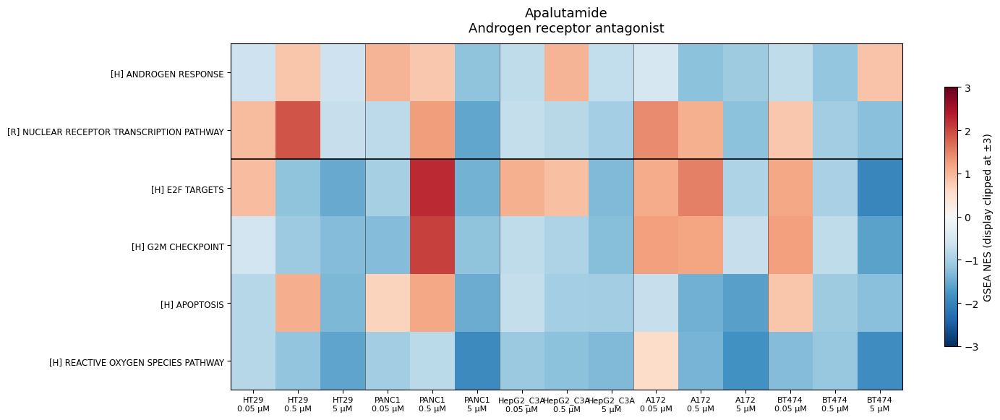

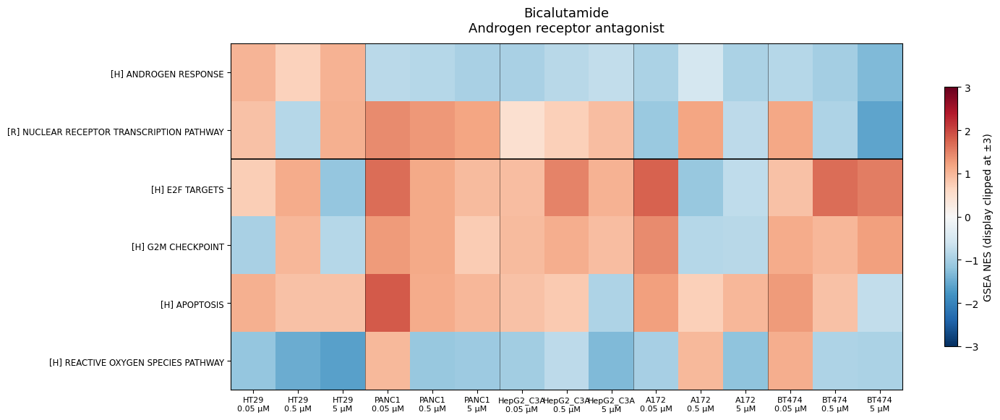

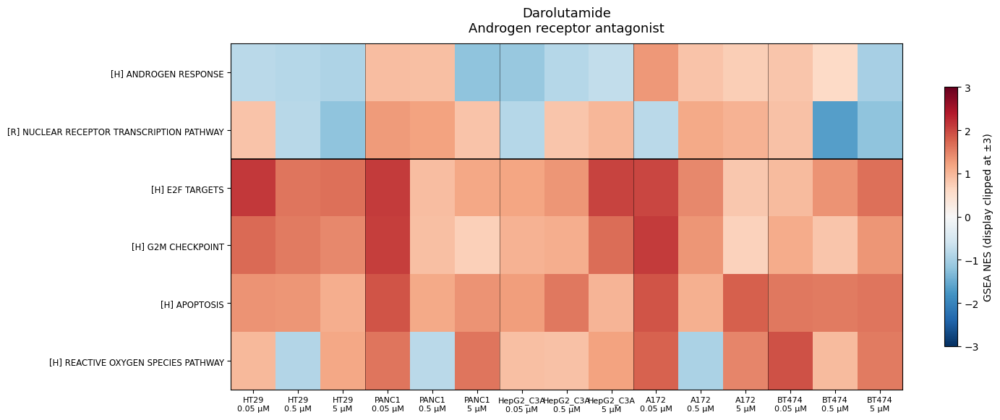

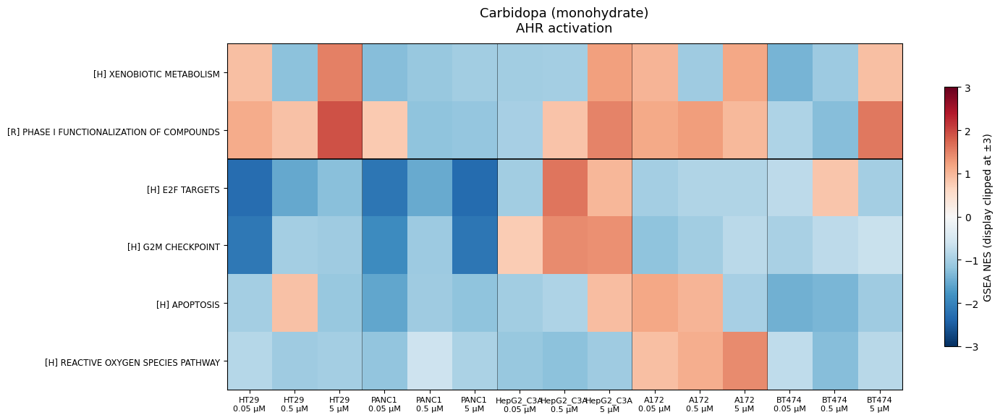

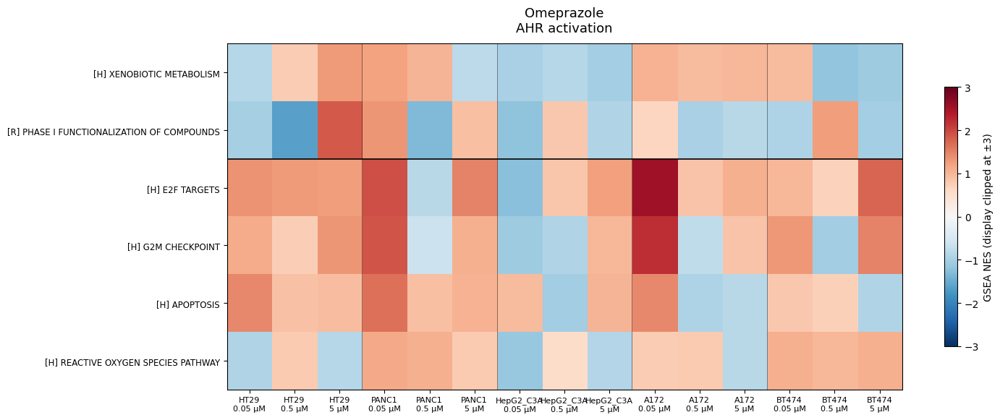

...

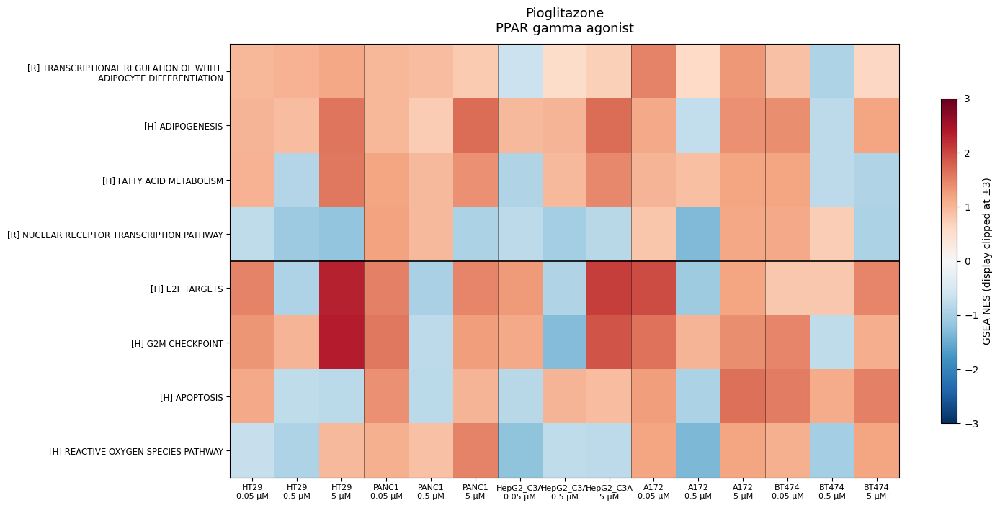

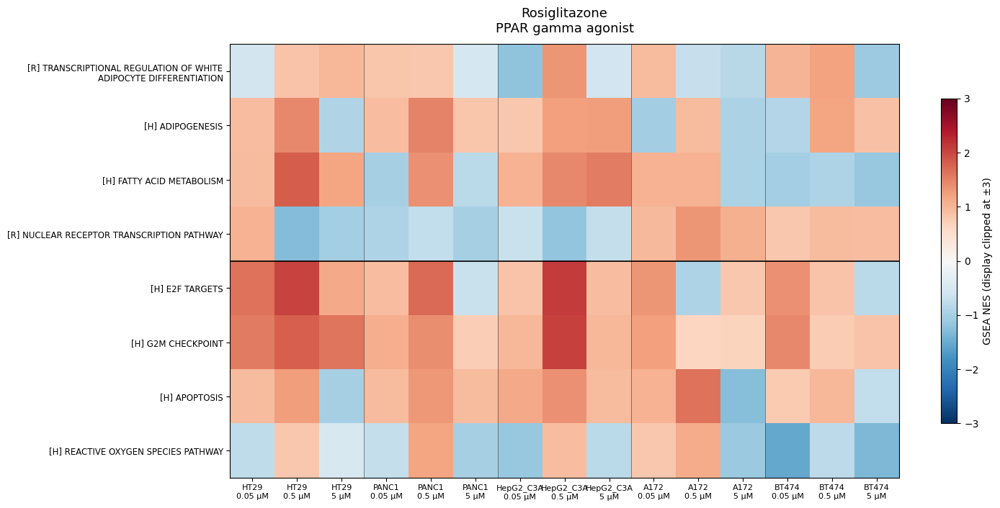

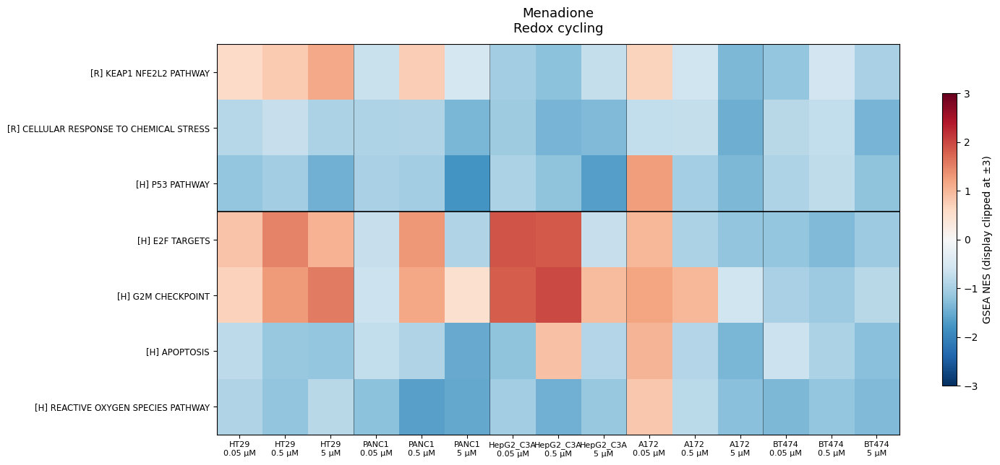

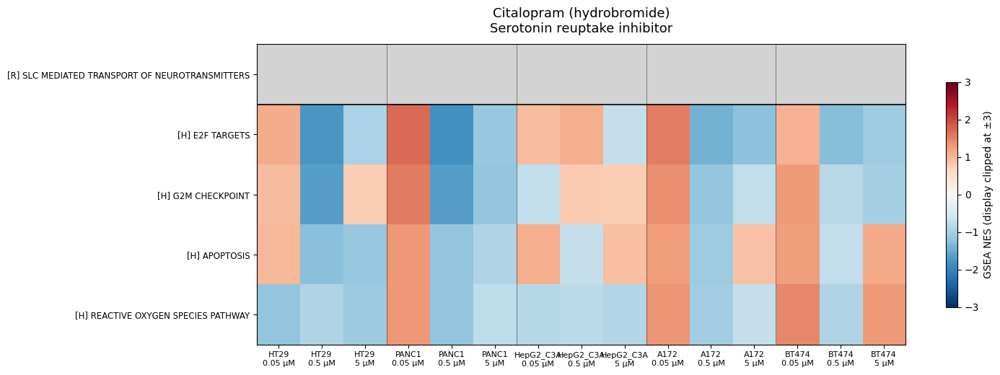

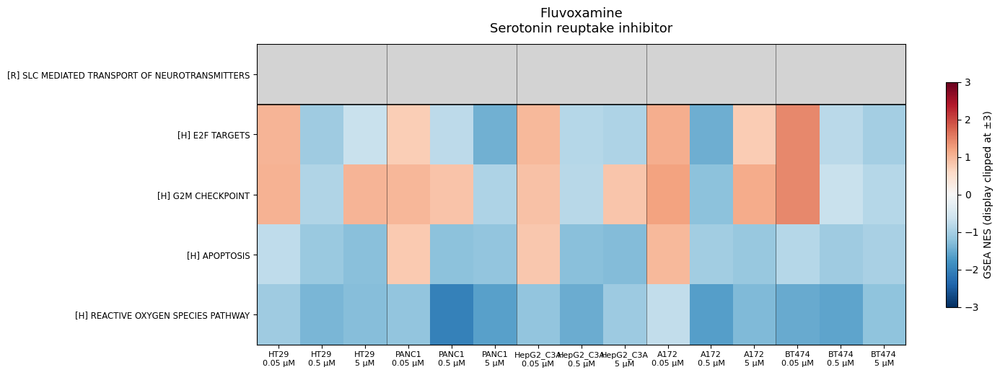


Saved heatmaps to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/MOA_targeted_drug_heatmaps


In [ ]:
# compound-specific MOA-targeted pathway heatmaps

# 기존 Hallmark 결과 재사용
hallmark_nes = pd.read_csv(
    HALLMARK_NES_PATH,
    index_col=0,
)

hallmark_nes = hallmark_nes.reindex(
    adata.obs_names
)


# 새 Reactome 결과
reactome_nes = pd.read_csv(
    RESULTS
    / "Reactome_selected_NES_matrix.csv",
    index_col=0,
)

reactome_nes = reactome_nes.reindex(
    adata.obs_names
)


# 하나의 condition × pathway matrix
combined_nes = pd.concat(
    [
        hallmark_nes,
        reactome_nes,
    ],
    axis=1,
)


# ------------------------------------------------------------
# Save final panel definition
# ------------------------------------------------------------

panel_rows = []

for family, specific in FAMILY_SPECIFIC.items():

    pathways = list(
        dict.fromkeys(
            specific + COMMON_PATHWAYS
        )
    )

    for pathway in pathways:

        role = (
            "MOA-specific / mechanistic"
            if pathway in specific
            else "common response"
        )

        panel_rows.append({
            "moa_family": family,
            "pathway": pathway,
            "role": role,
        })


panel_table = pd.DataFrame(panel_rows)

panel_table.to_csv(
    RESULTS
    / "MOA_targeted_pathway_panel.csv",
    index=False,
)

display(panel_table)


# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

meta = adata.obs[
    [
        "cell_line",
        "drug",
        "concentration",
    ]
].copy()

meta["drug"] = meta["drug"].astype(str)

meta["cell_line"] = (
    meta["cell_line"].astype(str)
)

meta["concentration"] = pd.to_numeric(
    meta["concentration"]
)


CELL_ORDER = [
    "HT29",
    "PANC1",
    "HepG2_C3A",
    "A172",
    "BT474",
]

DOSE_ORDER = [
    0.05,
    0.5,
    5.0,
]


target_columns = pd.MultiIndex.from_product(
    [
        CELL_ORDER,
        DOSE_ORDER,
    ],
    names=[
        "cell_line",
        "concentration",
    ],
)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

HEATMAP_DIR = (
    RESULTS
    / "MOA_targeted_drug_heatmaps"
)

HEATMAP_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def pretty_pathway(term):

    if term.startswith("HALLMARK_"):
        prefix = "[H] "
        name = term.replace(
            "HALLMARK_", ""
        )

    elif term.startswith("REACTOME_"):
        prefix = "[R] "
        name = term.replace(
            "REACTOME_", ""
        )

    else:
        prefix = ""
        name = term

    name = name.replace("_", " ")

    return (
        prefix
        + textwrap.fill(
            name,
            width=43,
        )
    )


def safe_name(text):

    return re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        text,
    ).strip("_")


# 동일한 color scale을 모든 drug에 사용
VMIN = -3
VMAX = 3

SHOW = True


# ------------------------------------------------------------
# 17 drugs
# ------------------------------------------------------------

for drug, family in DRUG_TO_FAMILY.items():

    specific = FAMILY_SPECIFIC[family]

    # common과 중복되는 pathway가 있더라도 한 번만 표시
    pathways = list(
        dict.fromkeys(
            specific
            + COMMON_PATHWAYS
        )
    )


    sub_meta = meta.loc[
        meta["drug"] == drug,
        [
            "cell_line",
            "concentration",
        ],
    ].copy()


    # condition × pathway
    tmp = combined_nes.reindex(
        index=sub_meta.index,
        columns=pathways,
    ).copy()


    tmp = tmp.join(sub_meta)


    # rows = cell line/dose
    # columns = pathways
    tmp = tmp.set_index(
        [
            "cell_line",
            "concentration",
        ]
    )


    # transpose:
    # rows = pathways
    # cols = cell-line × dose
    heat = tmp[pathways].T


    # 항상 5 cell lines × 3 doses 유지
    # Chlorhexidine 0.5 µM은 여기서 NaN으로 남음
    heat = heat.reindex(
        columns=target_columns
    )


    # 원본 matrix 저장
    heat.to_csv(
        HEATMAP_DIR
        / f"{safe_name(drug)}_NES_matrix.csv"
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    n_rows = len(pathways)

    fig_height = max(
        4.5,
        0.62 * n_rows + 2.2,
    )

    fig, ax = plt.subplots(
        figsize=(15, fig_height)
    )


    cmap = plt.get_cmap(
        "RdBu_r"
    ).copy()

    cmap.set_bad(
        "lightgray"
    )


    image = ax.imshow(

        np.ma.masked_invalid(
            heat.to_numpy(dtype=float)
        ),

        aspect="auto",

        cmap=cmap,

        vmin=VMIN,
        vmax=VMAX,
    )


    # x axis
    xlabels = [

        f"{cell}\n{dose:g} µM"

        for cell, dose
        in heat.columns
    ]


    ax.set_xticks(
        range(len(xlabels))
    )

    ax.set_xticklabels(
        xlabels,
        fontsize=8,
    )


    # y axis
    ax.set_yticks(
        range(n_rows)
    )

    ax.set_yticklabels(
        [
            pretty_pathway(x)
            for x in heat.index
        ],
        fontsize=8.5,
    )


    # cell-line group separators
    for x in [
        2.5,
        5.5,
        8.5,
        11.5,
    ]:
        ax.axvline(
            x,
            color="black",
            linewidth=0.6,
            alpha=0.5,
        )


    # MOA-specific vs common separator
    n_specific = len(specific)

    ax.axhline(
        n_specific - 0.5,
        color="black",
        linewidth=1.2,
    )


    ax.set_title(
        f"{drug}\n"
        f"{family}",
        fontsize=13,
        pad=12,
    )


    cbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.75,
    )

    cbar.set_label(
        "GSEA NES "
        "(display clipped at ±3)"
    )


    plt.tight_layout()


    fig.savefig(
        HEATMAP_DIR
        / f"{safe_name(drug)}_pathway_heatmap.png",
        dpi=220,
        bbox_inches="tight",
    )


    if SHOW:
        plt.show()
    else:
        plt.close(fig)


print(
    "\nSaved heatmaps to:",
    HEATMAP_DIR
)

In [ ]:
hallmark_gsea = pd.read_csv(
    RESULTS / "Hallmark_GSEA_all_conditions.csv"
)

reactome_gsea = pd.read_csv(
    RESULTS / "Reactome_selected_GSEA_all_conditions.csv"
)

print("Hallmark columns:")
print(hallmark_gsea.columns.tolist())

print("\nReactome columns:")
print(reactome_gsea.columns.tolist())

Hallmark columns:
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'condition_id', 'cell_line', 'drug', 'concentration', 'signature_status', 'n_ranked_genes']

Reactome columns:
['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'condition_id', 'cell_line', 'drug', 'concentration', 'signature_status', 'n_ranked_genes', 'n_gene_overlap']


In [ ]:
# Diagnose why SLC-mediated neurotransmitter transport
# was not tested by GSEA

import numpy as np
import pandas as pd

TERM = "REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS"

# Reactome에 정의된 pathway genes
pathway_genes = {
    str(g).strip().upper()
    for g in reactome_sets[TERM]
}

print("Reactome pathway size:", len(pathway_genes))


# ------------------------------------------------------------
# 1. Tahoe AnnData 자체에 존재하는가?
# ------------------------------------------------------------

var_symbols = (
    pd.Series(
        adata.var["gene_symbol"].to_numpy()
    )
    .astype(str)
    .str.strip()
    .str.upper()
)

adata_gene_set = set(
    var_symbols[var_symbols.ne("")]
)

present = sorted(
    pathway_genes & adata_gene_set
)

missing = sorted(
    pathway_genes - adata_gene_set
)

print("\nPresent in Tahoe AnnData:", len(present))
print("Missing from Tahoe AnnData:", len(missing))

print("\nPresent genes:")
print(present)

print("\nMissing genes:")
print(missing)


# ------------------------------------------------------------
# 2. 조건별 expression_eligible를 통과하는 gene 수
#    실제 GSEA ranking에 들어갈 수 있는 수
# ------------------------------------------------------------

records = []

for i, condition_id in enumerate(adata.obs_names):

    eligible = np.asarray(
        adata.layers["expression_eligible"][i, :]
    ).ravel().astype(bool)

    eligible_symbols = set(
        var_symbols[eligible]
    )

    usable_genes = sorted(
        pathway_genes & eligible_symbols
    )

    records.append({
        "condition_id": condition_id,
        "cell_line": str(adata.obs.iloc[i]["cell_line"]),
        "drug": str(adata.obs.iloc[i]["drug"]),
        "concentration": float(
            adata.obs.iloc[i]["concentration"]
        ),
        "n_pathway_genes": len(pathway_genes),
        "n_eligible_pathway_genes": len(usable_genes),
        "passes_min_size_15": len(usable_genes) >= 15,
        "eligible_genes": ";".join(usable_genes),
    })

slc_coverage = pd.DataFrame(records)


print("\nEligible gene count across 250 conditions:")
display(
    slc_coverage[
        "n_eligible_pathway_genes"
    ].describe()
)


print("\nBy cell line:")
display(
    slc_coverage.groupby("cell_line")[
        "n_eligible_pathway_genes"
    ].agg(["min", "median", "max"])
)


print("\nConditions passing min_size=15:")
print(
    slc_coverage[
        "passes_min_size_15"
    ].sum(),
    "/",
    len(slc_coverage)
)


# ------------------------------------------------------------
# 3. 각 pathway gene이 몇 개 조건에서 eligible했는지
# ------------------------------------------------------------

gene_records = []

for gene in sorted(pathway_genes):

    if gene not in adata_gene_set:

        gene_records.append({
            "gene": gene,
            "present_in_adata": False,
            "n_conditions_eligible": 0,
        })

        continue

    gene_mask = (
        var_symbols.to_numpy() == gene
    )

    eligible_matrix = np.asarray(
        adata.layers["expression_eligible"][
            :, gene_mask
        ]
    )

    # 동일 symbol feature가 여러 개면 하나라도 eligible이면 인정
    if eligible_matrix.ndim == 1:
        cond_eligible = eligible_matrix.astype(bool)
    else:
        cond_eligible = (
            eligible_matrix.astype(bool)
            .any(axis=1)
        )

    gene_records.append({
        "gene": gene,
        "present_in_adata": True,
        "n_conditions_eligible":
            int(cond_eligible.sum()),
    })


slc_gene_coverage = pd.DataFrame(
    gene_records
).sort_values(
    "n_conditions_eligible",
    ascending=False
)

print("\nPer-gene eligibility:")
display(slc_gene_coverage)

Reactome pathway size: 21

Present in Tahoe AnnData: 21
Missing from Tahoe AnnData: 0

Present genes:
['SLC17A6', 'SLC17A7', 'SLC17A8', 'SLC22A1', 'SLC22A2', 'SLC25A18', 'SLC25A22', 'SLC32A1', 'SLC6A1', 'SLC6A11', 'SLC6A13', 'SLC6A14', 'SLC6A15', 'SLC6A19', 'SLC6A2', 'SLC6A20', 'SLC6A3', 'SLC6A4', 'SLC6A5', 'SLC6A7', 'SLC6A9']

Missing genes:
[]

Eligible gene count across 250 conditions:


count    250.00000
mean       4.62400
std        1.19681
min        2.00000
25%        4.00000
50%        5.00000
75%        5.00000
max       10.00000
Name: n_eligible_pathway_genes, dtype: float64


By cell line:


,min,median,max
cell_line,,,
A172,3,4.0,6
BT474,2,5.0,7
HT29,4,5.0,7
HepG2_C3A,3,3.0,5
PANC1,3,5.0,10



Conditions passing min_size=15:
0 / 250

Per-gene eligibility:


,gene,present_in_adata,n_conditions_eligible
3,SLC22A1,True,217
6,SLC25A22,True,179
20,SLC6A9,True,168
11,SLC6A14,True,156
9,SLC6A11,True,100
1,SLC17A7,True,66
15,SLC6A20,True,58
16,SLC6A3,True,54
14,SLC6A2,True,50
10,SLC6A13,True,49


# Check leading genes

In [ ]:
# Build leading-edge gene tables
#        + special constituent-gene analysis for SLC pathway

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse


ROOT = Path("/content/drive/MyDrive/Tahoe_project")
RESULTS = ROOT / "results" / "gene_pathway"

LE_DIR = RESULTS / "leading_edge_analysis"
LE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

adata = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

hallmark_gsea = pd.read_csv(
    RESULTS / "Hallmark_GSEA_all_conditions.csv"
)

reactome_gsea = pd.read_csv(
    RESULTS / "Reactome_selected_GSEA_all_conditions.csv"
)

panel = pd.read_csv(
    RESULTS / "MOA_targeted_pathway_panel.csv"
)


# previous cell에서 정의되어 있어야 함
assert "DRUG_TO_FAMILY" in globals()
assert "reactome_sets" in globals()


# ------------------------------------------------------------
# 2. Combine Hallmark + Reactome GSEA results
# ------------------------------------------------------------

gsea_all = pd.concat(
    [
        hallmark_gsea.assign(collection="Hallmark"),
        reactome_gsea.assign(collection="Reactome"),
    ],
    ignore_index=True,
)


for col in ["NES", "FDR q-val"]:
    gsea_all[col] = pd.to_numeric(
        gsea_all[col],
        errors="coerce",
    )


# 우리가 최종 panel에서 사용하는 pathway만 유지
selected_pathways = set(panel["pathway"])

gsea_selected = gsea_all.loc[
    gsea_all["Term"].isin(selected_pathways)
].copy()


# ------------------------------------------------------------
# 3. Expand Lead_genes:
#    pathway-condition 한 행 -> gene 한 행
# ------------------------------------------------------------

records = []

for _, row in gsea_selected.iterrows():

    lead = row["Lead_genes"]

    if pd.isna(lead):
        continue

    genes = [
        g.strip().upper()
        for g in str(lead).split(";")
        if g.strip()
    ]

    for gene in genes:

        records.append({
            "condition_id": row["condition_id"],
            "cell_line": row["cell_line"],
            "drug": row["drug"],
            "concentration": row["concentration"],
            "pathway": row["Term"],
            "collection": row["collection"],
            "NES": row["NES"],
            "FDR_qval": row["FDR q-val"],
            "gene": gene,
        })


leading_edge_long = pd.DataFrame(records)

leading_edge_long.to_csv(
    LE_DIR / "leading_edge_genes_long.csv",
    index=False,
)

print("Leading-edge rows:", len(leading_edge_long))
print(
    "Unique pathway-condition pairs:",
    leading_edge_long[
        ["condition_id", "pathway"]
    ].drop_duplicates().shape[0]
)

Leading-edge rows: 184857
Unique pathway-condition pairs: 5250


In [ ]:
# Calculate Leading-edge recurrence per drug × pathway

summary = (
    leading_edge_long
    .groupby(
        ["drug", "pathway", "gene"],
        observed=True,
    )
    .agg(
        n_conditions_leading_edge=(
            "condition_id",
            "nunique",
        ),
        n_cell_lines=(
            "cell_line",
            "nunique",
        ),
        mean_NES=(
            "NES",
            "mean",
        ),
        median_NES=(
            "NES",
            "median",
        ),
        min_FDR=(
            "FDR_qval",
            "min",
        ),
    )
    .reset_index()
)


# 전체 가능한 condition 수:
# 일반적으로 5 cell lines × 3 doses = 15
# Chlorhexidine 0.5는 signature 없음
available_conditions = (
    adata.obs
    .reset_index()
    .groupby("drug", observed=True)
    .size()
    .rename("n_total_conditions")
)


summary = summary.merge(
    available_conditions,
    on="drug",
    how="left",
)


summary["leading_edge_fraction"] = (
    summary["n_conditions_leading_edge"]
    / summary["n_total_conditions"]
)


summary = summary.sort_values(
    [
        "drug",
        "pathway",
        "n_conditions_leading_edge",
        "n_cell_lines",
    ],
    ascending=[
        True,
        True,
        False,
        False,
    ],
)


summary.to_csv(
    LE_DIR / "leading_edge_gene_recurrence.csv",
    index=False,
)


display(summary.head(30))

,drug,pathway,gene,n_conditions_leading_edge,n_cell_lines,mean_NES,median_NES,min_FDR,n_total_conditions,leading_edge_fraction
13,Apalutamide,HALLMARK_ADIPOGENESIS,ALDOA,14,5,-1.237257,-1.232532,0.000704,15,0.933333
48,Apalutamide,HALLMARK_ADIPOGENESIS,CRAT,11,5,-1.199494,-1.199550,0.000704,15,0.733333
106,Apalutamide,HALLMARK_ADIPOGENESIS,MTCH2,11,5,-1.325055,-1.336771,0.000704,15,0.733333
138,Apalutamide,HALLMARK_ADIPOGENESIS,RNF11,11,5,-1.194877,-1.199550,0.000704,15,0.733333
5,Apalutamide,HALLMARK_ADIPOGENESIS,ACLY,10,5,-1.313623,-1.326260,0.000704,15,0.666667
49,Apalutamide,HALLMARK_ADIPOGENESIS,CYC1,10,5,-1.171938,-1.293278,0.000704,15,0.666667
123,Apalutamide,HALLMARK_ADIPOGENESIS,PIM3,10,5,-1.374569,-1.361888,0.000704,15,0.666667
147,Apalutamide,HALLMARK_ADIPOGENESIS,SLC1A5,10,5,-1.189153,-1.181681,0.000704,15,0.666667
125,Apalutamide,HALLMARK_ADIPOGENESIS,POR,10,4,-1.231678,-1.268160,0.000704,15,0.666667
18,Apalutamide,HALLMARK_ADIPOGENESIS,ARAF,9,5,-1.143789,-1.199550,0.008758,15,0.600000


In [ ]:
# Helper functions for gene-level log2FC

gene_symbols = (
    pd.Series(
        adata.var["gene_symbol"].to_numpy()
    )
    .astype(str)
    .str.strip()
    .str.upper()
)

symbol_to_idx = {}

for idx, gene in enumerate(gene_symbols):
    if gene and gene != "NAN":
        symbol_to_idx.setdefault(
            gene,
            []
        ).append(idx)


def get_gene_values(condition_indices, genes):
    """
    Returns:
      log2FC dataframe: conditions × genes
      eligibility dataframe: conditions × genes

    If duplicate features map to same symbol:
      log2FC = mean
      eligible = any
    """

    lfc_out = pd.DataFrame(
        index=condition_indices,
        columns=genes,
        dtype=float,
    )

    elig_out = pd.DataFrame(
        index=condition_indices,
        columns=genes,
        dtype=bool,
    )


    for gene in genes:

        idxs = symbol_to_idx.get(
            gene.upper(),
            []
        )

        if len(idxs) == 0:
            continue


        x = adata[
            condition_indices,
            idxs
        ].X

        e = adata.layers[
            "expression_eligible"
        ][
            [
                adata.obs_names.get_loc(x)
                for x in condition_indices
            ],
            :
        ][:, idxs]


        if sparse.issparse(x):
            x = x.toarray()

        if sparse.issparse(e):
            e = e.toarray()


        x = np.asarray(x)
        e = np.asarray(e).astype(bool)


        lfc_out[gene] = x.mean(axis=1)
        elig_out[gene] = e.any(axis=1)


    return lfc_out, elig_out

In [ ]:
# Plot gene-level heatmap for a drug × pathway

CELL_ORDER = [
    "HT29",
    "PANC1",
    "HepG2_C3A",
    "A172",
    "BT474",
]

DOSE_ORDER = [
    0.05,
    0.5,
    5.0,
]


SLC_TERM = (
    "REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS"
)


def plot_pathway_genes(
    drug,
    pathway,
    min_recurrence=2,
    max_genes=40,
    save=True,
):

    # --------------------------------------------------------
    # Conditions for this drug
    # --------------------------------------------------------

    obs = adata.obs.copy()

    mask = (
        obs["drug"].astype(str)
        == drug
    )

    condition_ids = (
        obs.index[mask]
        .tolist()
    )


    if len(condition_ids) == 0:
        raise ValueError(
            f"Drug not found: {drug}"
        )


    # --------------------------------------------------------
    # Gene selection
    # --------------------------------------------------------

    if pathway == SLC_TERM:

        # No GSEA / no leading edge exists.
        # Use all Reactome constituent genes instead.

        genes = sorted({
            str(g).strip().upper()
            for g in reactome_sets[pathway]
        })

        selection_type = (
            "Reactome constituent genes "
            "(GSEA not available)"
        )


    else:

        rec = summary.loc[
            (summary["drug"] == drug)
            & (summary["pathway"] == pathway)
        ].copy()


        if len(rec) == 0:
            raise ValueError(
                f"No leading-edge result for:\n"
                f"{drug}\n{pathway}"
            )


        rec = rec.loc[
            rec["n_conditions_leading_edge"]
            >= min_recurrence
        ]


        # 너무 많으면 recurrence 기준으로 display만 제한
        rec = rec.sort_values(
            [
                "n_conditions_leading_edge",
                "n_cell_lines",
            ],
            ascending=False,
        )


        if max_genes is not None:
            rec = rec.head(max_genes)


        genes = rec["gene"].tolist()

        selection_type = (
            f"Leading-edge genes "
            f"(recurrence ≥ {min_recurrence})"
        )


        if len(genes) == 0:
            raise ValueError(
                "No genes passed the recurrence threshold."
            )


    # --------------------------------------------------------
    # Extract log2FC and eligibility
    # --------------------------------------------------------

    lfc, elig = get_gene_values(
        condition_ids,
        genes,
    )


    meta = obs.loc[
        condition_ids,
        [
            "cell_line",
            "concentration",
        ]
    ].copy()

    meta["cell_line"] = (
        meta["cell_line"].astype(str)
    )

    meta["concentration"] = pd.to_numeric(
        meta["concentration"]
    )


    # desired column order
    desired = []

    for cell in CELL_ORDER:
        for dose in DOSE_ORDER:

            hit = meta.index[
                (meta["cell_line"] == cell)
                & np.isclose(
                    meta["concentration"],
                    dose,
                )
            ].tolist()

            if len(hit) == 1:
                desired.append(hit[0])
            else:
                desired.append(None)


    # --------------------------------------------------------
    # Build heatmap:
    # rows genes
    # cols cell line × dose
    # --------------------------------------------------------

    heat = pd.DataFrame(
        index=genes,
        columns=range(15),
        dtype=float,
    )


    labels = []

    for j, cid in enumerate(desired):

        cell = CELL_ORDER[j // 3]
        dose = DOSE_ORDER[j % 3]

        labels.append(
            f"{cell}\n{dose:g} µM"
        )

        if cid is None:
            continue

        vals = lfc.loc[cid, genes].copy()
        ok = elig.loc[cid, genes].copy()

        # expression-ineligible genes = gray
        vals.loc[~ok] = np.nan

        heat.iloc[:, j] = vals.to_numpy()


    # save complete matrix
    safe_drug = (
        drug.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    safe_path = (
        pathway.replace(" ", "_")
        .replace("/", "_")
    )


    heat.to_csv(
        LE_DIR
        / f"{safe_drug}__{safe_path}__gene_log2FC.csv"
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig_height = max(
        5,
        0.30 * len(genes) + 2.5,
    )

    fig, ax = plt.subplots(
        figsize=(15, fig_height)
    )


    cmap = plt.get_cmap(
        "RdBu_r"
    ).copy()

    cmap.set_bad(
        "lightgray"
    )


    im = ax.imshow(
        np.ma.masked_invalid(
            heat.to_numpy(dtype=float)
        ),
        aspect="auto",
        cmap=cmap,
        vmin=-2,
        vmax=2,
    )


    ax.set_xticks(
        range(15)
    )

    ax.set_xticklabels(
        labels,
        fontsize=8,
    )


    ax.set_yticks(
        range(len(genes))
    )

    ax.set_yticklabels(
        genes,
        fontsize=8,
    )


    for x in [
        2.5,
        5.5,
        8.5,
        11.5,
    ]:

        ax.axvline(
            x,
            color="black",
            linewidth=0.6,
            alpha=0.5,
        )


    ax.set_title(
        f"{drug}\n"
        f"{pathway}\n"
        f"{selection_type}",
        fontsize=12,
    )


    cbar = fig.colorbar(
        im,
        ax=ax,
        shrink=0.7,
    )

    cbar.set_label(
        "log2FC vs matched DMSO "
        "(display clipped at ±2)"
    )


    plt.tight_layout()


    if save:

        fig.savefig(
            LE_DIR
            / f"{safe_drug}__{safe_path}__gene_heatmap.png",
            dpi=220,
            bbox_inches="tight",
        )


    plt.show()


    return heat

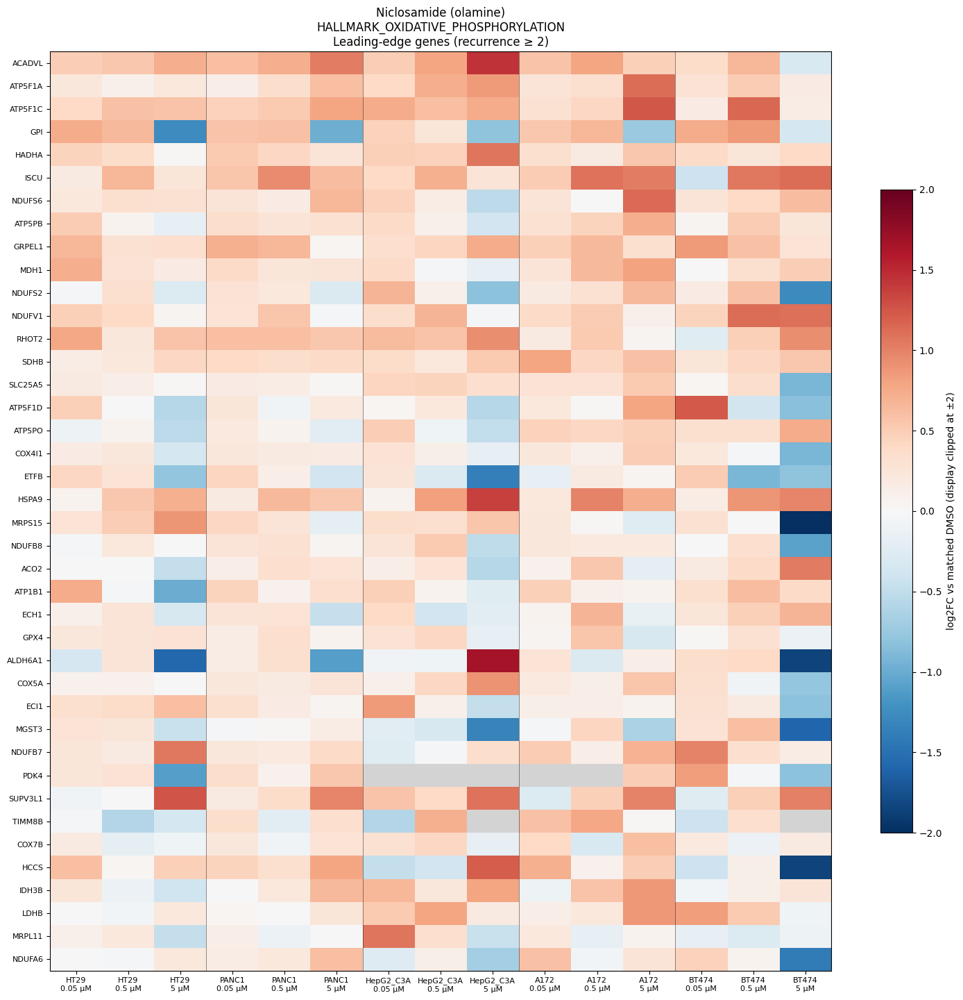

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
ACADVL,0.492935,0.534119,0.719010,0.594556,0.727256,1.017793,0.492361,0.782016,1.451730,0.571475,0.786767,0.473428,0.370905,0.667809,-0.311806
ATP5F1A,0.224190,0.106962,0.215959,0.132042,0.347048,0.597511,0.402460,0.726589,0.845694,0.257511,0.314850,1.124050,0.283173,0.500005,0.169993
ATP5F1C,0.392664,0.578143,0.574006,0.458316,0.523491,0.789140,0.736604,0.595770,0.740367,0.307191,0.419345,1.240999,0.165207,1.144183,0.147850
GPI,0.741919,0.641038,-1.259723,0.567393,0.586623,-0.979451,0.463615,0.238960,-0.799260,0.532640,0.658258,-0.743272,0.737126,0.849239,-0.348303
HADHA,0.438779,0.373355,0.027947,0.529316,0.408257,0.261128,0.470318,0.462837,1.071243,0.322078,0.187183,0.544367,0.388335,0.242234,0.394868
ISCU,0.182372,0.665316,0.238515,0.556050,0.941417,0.623660,0.391612,0.714418,0.257275,0.512422,1.090904,1.017167,-0.421772,1.053919,1.123679
NDUFS6,0.213662,0.325762,0.304994,0.255565,0.163057,0.666177,0.454166,0.146781,-0.520737,0.261365,0.010734,1.136793,0.250994,0.402686,0.621110
ATP5PB,0.500425,0.062525,-0.161983,0.355413,0.250102,0.306392,0.386502,0.102497,-0.386537,0.299618,0.447639,0.730479,0.049198,0.504885,0.243525
GRPEL1,0.668956,0.306660,0.339400,0.707028,0.670788,0.035891,0.330936,0.423000,0.749179,0.484147,0.647366,0.320689,0.850953,0.585522,0.271295
MDH1,0.720453,0.284135,0.169710,0.385508,0.247843,0.250186,0.379274,-0.024044,-0.169793,0.260259,0.655913,0.801612,0.013519,0.323372,0.490699


In [ ]:
plot_pathway_genes(
    drug="Niclosamide (olamine)",
    pathway="HALLMARK_OXIDATIVE_PHOSPHORYLATION",
)

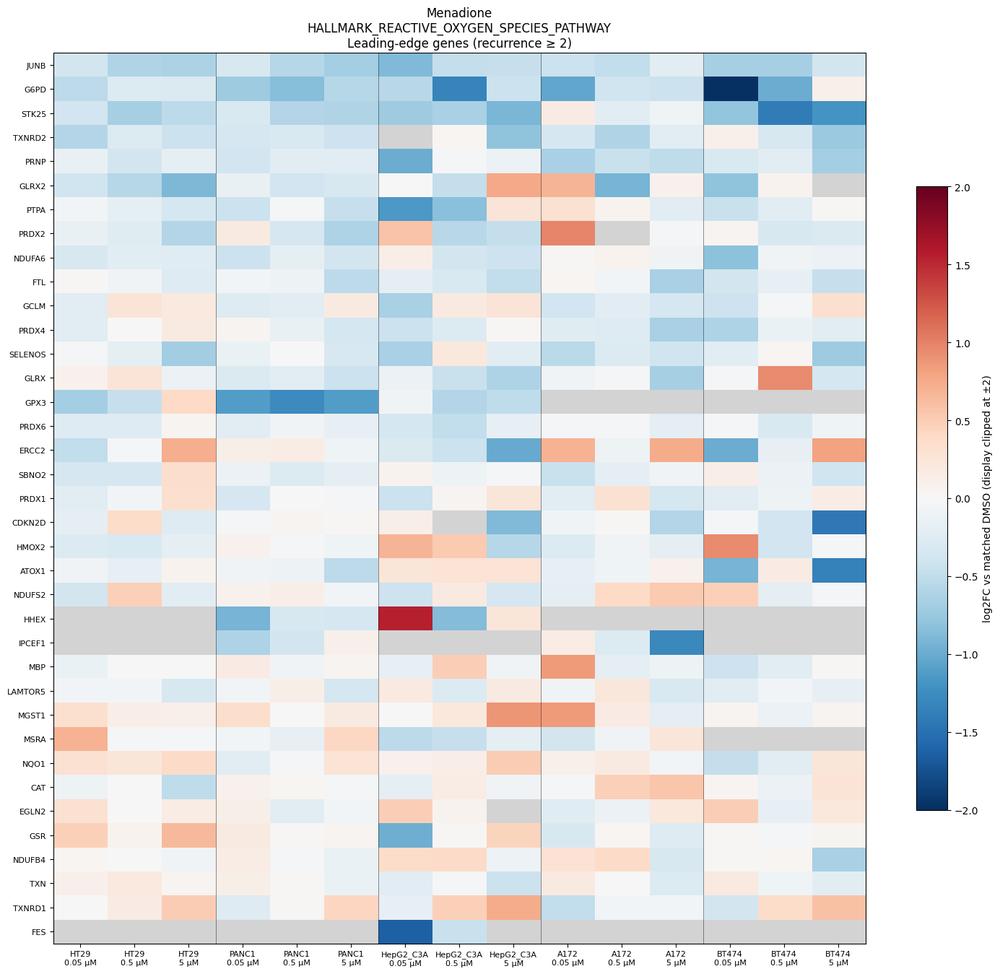

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
JUNB,-0.360327,-0.595095,-0.625960,-0.314907,-0.576481,-0.680588,-0.885890,-0.470577,-0.459045,-0.429430,-0.488388,-0.230628,-0.662134,-0.665243,-0.371366
G6PD,-0.530269,-0.273019,-0.281842,-0.714187,-0.853711,-0.576183,-0.555160,-1.334832,-0.432538,-1.041137,-0.398255,-0.426531,-2.210166,-0.990162,0.100942
STK25,-0.381917,-0.662239,-0.525404,-0.305759,-0.581624,-0.600201,-0.707963,-0.649281,-0.920367,0.164623,-0.208801,-0.079586,-0.794174,-1.398979,-1.197509
TXNRD2,-0.578903,-0.271111,-0.426822,-0.339044,-0.297386,-0.410656,NaN,0.045302,-0.807807,-0.337110,-0.606569,-0.219750,0.099808,-0.314243,-0.746941
PRNP,-0.153102,-0.368958,-0.186919,-0.384718,-0.217931,-0.218845,-0.985436,-0.024393,-0.114909,-0.653128,-0.452150,-0.511099,-0.309910,-0.224749,-0.675276
GLRX2,-0.399114,-0.568587,-0.901270,-0.155659,-0.380926,-0.318973,0.001489,-0.470916,0.751678,0.683260,-0.929599,0.088910,-0.797196,0.070985,NaN
PTPA,-0.055344,-0.176488,-0.351404,-0.436858,-0.045217,-0.459263,-1.155064,-0.834343,0.256514,0.307749,0.075904,-0.229540,-0.444376,-0.230903,0.017750
PRDX2,-0.146518,-0.236628,-0.589099,0.175156,-0.338724,-0.616231,0.573669,-0.548166,-0.482514,0.979289,NaN,-0.028816,0.061923,-0.322122,-0.287239
NDUFA6,-0.321019,-0.210656,-0.240976,-0.433377,-0.183928,-0.363917,0.137468,-0.365265,-0.407423,0.028956,0.064975,-0.068806,-0.814893,-0.067640,-0.111507
FTL,0.026619,-0.075832,-0.252942,-0.048427,-0.107448,-0.518580,-0.186618,-0.309517,-0.497903,0.041136,-0.061387,-0.652804,-0.372887,-0.161534,-0.466635


In [ ]:
plot_pathway_genes(
    drug="Menadione",
    pathway="HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY",
)

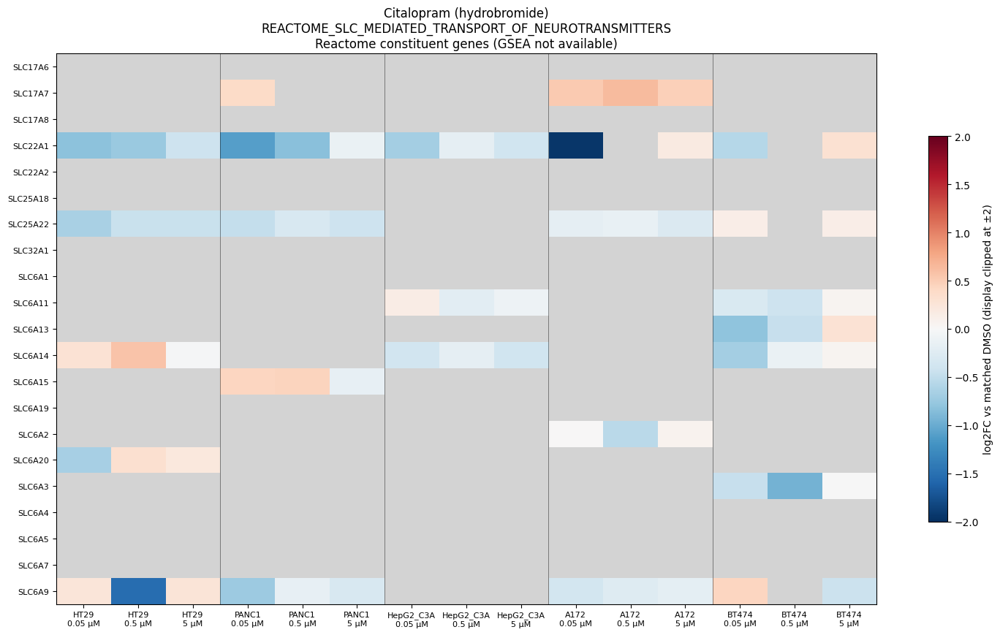

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
SLC17A6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC17A7,NaN,NaN,NaN,0.386032,NaN,NaN,NaN,NaN,NaN,0.529053,0.640433,0.481493,NaN,NaN,NaN
SLC17A8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC22A1,-0.815834,-0.735629,-0.420938,-1.102758,-0.841133,-0.133739,-0.679169,-0.182248,-0.403108,-1.948986,NaN,0.181292,-0.577134,NaN,0.298405
SLC22A2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC25A18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC25A22,-0.645863,-0.444994,-0.438475,-0.479913,-0.320658,-0.415705,NaN,NaN,NaN,-0.186962,-0.156133,-0.281959,0.137293,NaN,0.139866
SLC32A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC6A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC6A11,NaN,NaN,NaN,NaN,NaN,NaN,0.149804,-0.217917,-0.098170,NaN,NaN,NaN,-0.311123,-0.413847,0.051898


In [ ]:
plot_pathway_genes(
    drug="Citalopram (hydrobromide)",
    pathway="REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS",
    min_recurrence=1,   # SLC에서는 실제로 사용되지 않음
    max_genes=None,
)

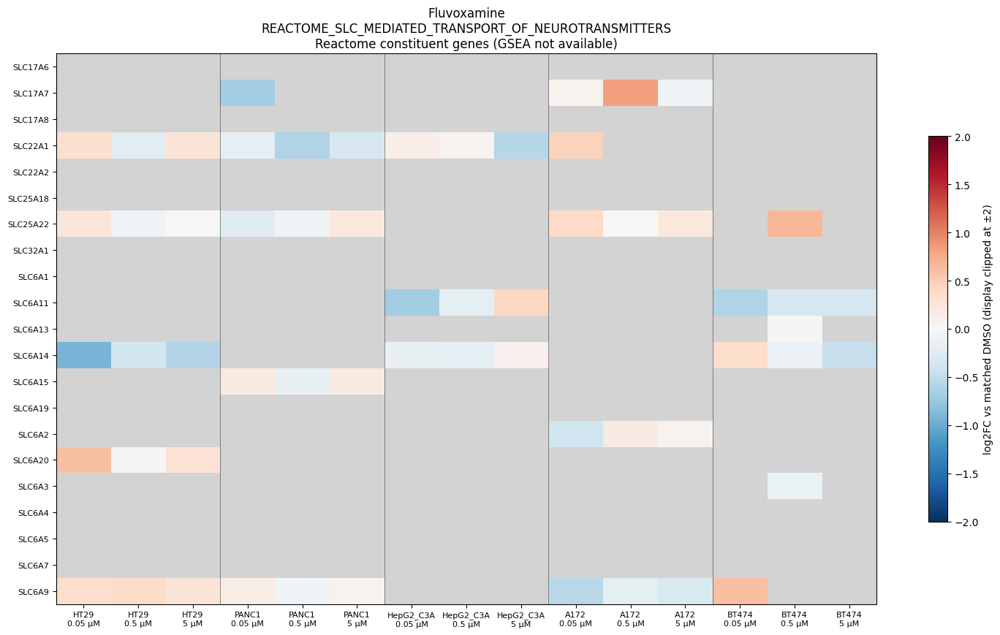

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
SLC17A6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC17A7,NaN,NaN,NaN,-0.687792,NaN,NaN,NaN,NaN,NaN,0.068595,0.827268,-0.079952,NaN,NaN,NaN
SLC17A8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC22A1,0.318882,-0.227026,0.253667,-0.193414,-0.597698,-0.313541,0.129268,0.057927,-0.564453,0.455453,NaN,NaN,NaN,NaN,NaN
SLC22A2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC25A18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC25A22,0.247737,-0.089170,0.011660,-0.247223,-0.068411,0.206992,NaN,NaN,NaN,0.397238,0.011518,0.208879,NaN,0.659321,NaN
SLC32A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC6A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SLC6A11,NaN,NaN,NaN,NaN,NaN,NaN,-0.690268,-0.189513,0.419479,NaN,NaN,NaN,-0.596097,-0.328775,-0.34303


In [ ]:
plot_pathway_genes(
    drug="Fluvoxamine",
    pathway="REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS",
    max_genes=None,
)

# MOA-specific pathways: top4 leading genes analysis
- decide leading genes per pathway considering changes within common MOA family

In [ ]:
# MOA-specific leading-edge analysis

from pathlib import Path
import re

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse


ROOT = Path("/content/drive/MyDrive/Tahoe_project")
RESULTS = ROOT / "results" / "gene_pathway"

LE_DIR = RESULTS / "MOA_specific_leading_edge"
LE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

adata = ad.read_h5ad(
    RESULTS / "condition_level_log2FC_screened.h5ad"
)

hallmark_gsea = pd.read_csv(
    RESULTS / "Hallmark_GSEA_all_conditions.csv"
)

reactome_gsea = pd.read_csv(
    RESULTS / "Reactome_selected_GSEA_all_conditions.csv"
)


# ------------------------------------------------------------
# Final MOA-specific pathways
# Common E2F / G2M / APOPTOSIS / ROS are NOT included here.
# ------------------------------------------------------------

FAMILY_SPECIFIC = {

    "Androgen receptor antagonist": [
        "HALLMARK_ANDROGEN_RESPONSE",
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
    ],

    "AHR activation": [
        "HALLMARK_XENOBIOTIC_METABOLISM",
        "REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS",
    ],

    "Glucocorticoid receptor agonist": [
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
        "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
        "HALLMARK_IL6_JAK_STAT3_SIGNALING",
    ],

    "Membrane perturbation": [
        "REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS",
        "HALLMARK_UNFOLDED_PROTEIN_RESPONSE",
    ],

    "Mitochondrial OXPHOS uncoupling": [
        "HALLMARK_OXIDATIVE_PHOSPHORYLATION",
        "REACTOME_RESPIRATORY_ELECTRON_TRANSPORT",
        "REACTOME_FORMATION_OF_ATP_BY_CHEMIOSMOTIC_COUPLING",
        "HALLMARK_GLYCOLYSIS",
    ],

    "PPAR gamma agonist": [
        "REACTOME_TRANSCRIPTIONAL_REGULATION_OF_WHITE_ADIPOCYTE_DIFFERENTIATION",
        "HALLMARK_ADIPOGENESIS",
        "HALLMARK_FATTY_ACID_METABOLISM",
        "REACTOME_NUCLEAR_RECEPTOR_TRANSCRIPTION_PATHWAY",
    ],

    "Redox cycling": [
        "REACTOME_KEAP1_NFE2L2_PATHWAY",
        "REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS",
        "HALLMARK_P53_PATHWAY",
    ],

    "Serotonin reuptake inhibitor": [
        "REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS",
    ],
}


DRUG_TO_FAMILY = {

    "Apalutamide":
        "Androgen receptor antagonist",
    "Bicalutamide":
        "Androgen receptor antagonist",
    "Darolutamide":
        "Androgen receptor antagonist",

    "Carbidopa (monohydrate)":
        "AHR activation",
    "Omeprazole":
        "AHR activation",

    "Dexamethasone":
        "Glucocorticoid receptor agonist",
    "Methylprednisolone succinate":
        "Glucocorticoid receptor agonist",
    "Triamcinolone":
        "Glucocorticoid receptor agonist",

    "Chlorhexidine (diacetate)":
        "Membrane perturbation",
    "Thymol":
        "Membrane perturbation",

    "Niclosamide (olamine)":
        "Mitochondrial OXPHOS uncoupling",
    "Triclosan":
        "Mitochondrial OXPHOS uncoupling",

    "Pioglitazone":
        "PPAR gamma agonist",
    "Rosiglitazone":
        "PPAR gamma agonist",

    "Menadione":
        "Redox cycling",

    "Citalopram (hydrobromide)":
        "Serotonin reuptake inhibitor",
    "Fluvoxamine":
        "Serotonin reuptake inhibitor",
}


# ------------------------------------------------------------
# Combine GSEA results
# ------------------------------------------------------------

hallmark_gsea["collection"] = "Hallmark"
reactome_gsea["collection"] = "Reactome"

gsea_all = pd.concat(
    [hallmark_gsea, reactome_gsea],
    ignore_index=True,
)


for col in ["NES", "FDR q-val"]:
    gsea_all[col] = pd.to_numeric(
        gsea_all[col],
        errors="coerce",
    )


# ------------------------------------------------------------
# Expand Lead_genes:
# one pathway-condition row -> one gene per row
# ------------------------------------------------------------

records = []

for _, row in gsea_all.iterrows():

    drug = str(row["drug"])

    if drug not in DRUG_TO_FAMILY:
        continue

    family = DRUG_TO_FAMILY[drug]
    pathway = row["Term"]

    # Only predefined MOA-specific pathways
    if pathway not in FAMILY_SPECIFIC[family]:
        continue

    # SLC has no GSEA result anyway
    if pd.isna(row["Lead_genes"]):
        continue

    genes = [
        g.strip().upper()
        for g in str(row["Lead_genes"]).split(";")
        if g.strip()
    ]

    for gene in genes:

        records.append({
            "family": family,
            "drug": drug,
            "cell_line": str(row["cell_line"]),
            "concentration": float(row["concentration"]),
            "condition_id": row["condition_id"],
            "pathway": pathway,
            "gene": gene,
            "NES": row["NES"],
            "FDR_qval": row["FDR q-val"],
        })


leading_edge_long = pd.DataFrame(records)

leading_edge_long.to_csv(
    LE_DIR / "leading_edge_long_MOA_specific.csv",
    index=False,
)

print("Leading-edge rows:", len(leading_edge_long))
print("Families:", leading_edge_long["family"].nunique())
print("Pathways:", leading_edge_long["pathway"].nunique())

Leading-edge rows: 18438
Families: 7
Pathways: 17


In [ ]:
# Attach gene-level log2FC to leading-edge genes

gene_symbols = (
    pd.Series(
        adata.var["gene_symbol"].to_numpy()
    )
    .astype(str)
    .str.strip()
    .str.upper()
)


symbol_to_indices = {}

for j, gene in enumerate(gene_symbols):

    if gene and gene != "NAN":

        symbol_to_indices.setdefault(
            gene,
            []
        ).append(j)


def get_condition_gene_lfc(condition_id, gene):
    """
    Same logic as GSEA ranking:
    average log2FC only across features with this symbol
    that pass expression_eligible in this condition.
    """

    i = adata.obs_names.get_loc(condition_id)

    idxs = symbol_to_indices.get(
        gene.upper(),
        []
    )

    if len(idxs) == 0:
        return np.nan


    x = adata.X[i, idxs]

    e = adata.layers[
        "expression_eligible"
    ][i, idxs]


    if sparse.issparse(x):
        x = x.toarray()

    if sparse.issparse(e):
        e = e.toarray()


    x = np.asarray(x).ravel()
    e = np.asarray(e).ravel().astype(bool)


    if not e.any():
        return np.nan


    return float(
        np.mean(x[e])
    )


# add log2FC to every leading-edge occurrence
leading_edge_long["gene_log2FC"] = [

    get_condition_gene_lfc(
        cid,
        gene,
    )

    for cid, gene in zip(
        leading_edge_long["condition_id"],
        leading_edge_long["gene"],
    )
]


assert (
    leading_edge_long["gene_log2FC"]
    .notna()
    .all()
)


leading_edge_long.to_csv(
    LE_DIR
    / "leading_edge_long_MOA_specific_with_log2FC.csv",
    index=False,
)

display(
    leading_edge_long.head()
)

,family,drug,cell_line,concentration,condition_id,pathway,gene,NES,FDR_qval,gene_log2FC
0,Membrane perturbation,Chlorhexidine (diacetate),HT29,0.05,HT29__Chlorhexidine (diacetate)__0.05,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,CHAC1,-1.321064,0.226768,-0.990254
1,Membrane perturbation,Chlorhexidine (diacetate),HT29,0.05,HT29__Chlorhexidine (diacetate)__0.05,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,CXXC1,-1.321064,0.226768,-0.707398
2,Membrane perturbation,Chlorhexidine (diacetate),HT29,0.05,HT29__Chlorhexidine (diacetate)__0.05,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,ASNS,-1.321064,0.226768,-0.640336
3,Membrane perturbation,Chlorhexidine (diacetate),HT29,0.05,HT29__Chlorhexidine (diacetate)__0.05,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,SHC1,-1.321064,0.226768,-0.603943
4,Membrane perturbation,Chlorhexidine (diacetate),HT29,0.05,HT29__Chlorhexidine (diacetate)__0.05,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,WFS1,-1.321064,0.226768,-0.592530


In [ ]:
# Rank recurrent leading-edge genes by MOA family

TOP_N = 4


# ------------------------------------------------------------
# denominator:
# family 내 실제 존재하는 treatment conditions
# ------------------------------------------------------------

obs_meta = adata.obs.copy()

obs_meta["drug"] = (
    obs_meta["drug"].astype(str)
)

obs_meta["family"] = (
    obs_meta["drug"]
    .map(DRUG_TO_FAMILY)
)


family_condition_counts = (
    obs_meta
    .groupby(
        "family",
        observed=True,
    )
    .size()
    .rename(
        "n_family_conditions"
    )
)


# ------------------------------------------------------------
# Leading-edge recurrence statistics
# ------------------------------------------------------------

gene_stats = (
    leading_edge_long
    .groupby(
        [
            "family",
            "pathway",
            "gene",
        ],
        observed=True,
    )
    .agg(

        n_le_conditions=(
            "condition_id",
            "nunique",
        ),

        n_drugs=(
            "drug",
            "nunique",
        ),

        n_cell_lines=(
            "cell_line",
            "nunique",
        ),

        median_abs_log2FC=(
            "gene_log2FC",
            lambda x: np.nanmedian(
                np.abs(x)
            ),
        ),

        median_log2FC=(
            "gene_log2FC",
            "median",
        ),

        median_NES=(
            "NES",
            "median",
        ),

    )
    .reset_index()
)


gene_stats = gene_stats.merge(
    family_condition_counts,
    on="family",
    how="left",
)


gene_stats[
    "leading_edge_fraction"
] = (
    gene_stats["n_le_conditions"]
    / gene_stats["n_family_conditions"]
)


# ------------------------------------------------------------
# Ranking rule:
# 1. recurrence across conditions
# 2. recurrence across drugs
# 3. recurrence across cell lines
# 4. absolute log2FC magnitude
# ------------------------------------------------------------

gene_stats = gene_stats.sort_values(

    [
        "family",
        "pathway",
        "n_le_conditions",
        "n_drugs",
        "n_cell_lines",
        "median_abs_log2FC",
        "gene",
    ],

    ascending=[
        True,
        True,
        False,
        False,
        False,
        False,
        True,
    ],
)


gene_stats["pathway_rank"] = (
    gene_stats
    .groupby(
        [
            "family",
            "pathway",
        ],
        observed=True,
    )
    .cumcount()
    + 1
)


top_genes = gene_stats.loc[
    gene_stats["pathway_rank"]
    <= TOP_N
].copy()


top_genes[
    "selection_method"
] = "recurrent_leading_edge"


gene_stats.to_csv(
    LE_DIR
    / "all_leading_edge_gene_ranking.csv",
    index=False,
)


top_genes.to_csv(
    LE_DIR
    / "top4_leading_edge_genes_per_pathway.csv",
    index=False,
)


display(
    top_genes[
        [
            "family",
            "pathway",
            "gene",
            "pathway_rank",
            "n_le_conditions",
            "n_drugs",
            "n_cell_lines",
            "median_abs_log2FC",
        ]
    ]
)

,family,pathway,gene,pathway_rank,n_le_conditions,n_drugs,n_cell_lines,median_abs_log2FC
35,AHR activation,HALLMARK_XENOBIOTIC_METABOLISM,CFB,1,14,2,5,0.462764
117,AHR activation,HALLMARK_XENOBIOTIC_METABOLISM,PINK1,2,13,2,5,0.409825
109,AHR activation,HALLMARK_XENOBIOTIC_METABOLISM,NQO1,3,12,2,5,0.464396
29,AHR activation,HALLMARK_XENOBIOTIC_METABOLISM,CASP6,4,12,2,5,0.421427
185,AHR activation,REACTOME_PHASE_I_FUNCTIONALIZATION_OF_COMPOUNDS,CYP24A1,1,15,2,5,0.489975
...,...,...,...,...,...,...,...,...
2199,Redox cycling,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,MAP1LC3B,4,14,1,5,0.615040
2388,Redox cycling,REACTOME_KEAP1_NFE2L2_PATHWAY,UBC,1,10,1,4,0.485790
2348,Redox cycling,REACTOME_KEAP1_NFE2L2_PATHWAY,PSMB3,2,10,1,4,0.460544
2386,Redox cycling,REACTOME_KEAP1_NFE2L2_PATHWAY,UBA52,3,9,1,5,0.420582


In [ ]:
# Special handling for SSRI SLC pathway

SLC_TERM = (
    "REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSMITTERS"
)


# reactome_sets must already exist from previous pathway-GSEA cell
slc_genes = sorted({
    str(g).strip().upper()
    for g in reactome_sets[SLC_TERM]
})


ssri_drugs = [
    drug
    for drug, family
    in DRUG_TO_FAMILY.items()
    if family
    == "Serotonin reuptake inhibitor"
]


ssri_conditions = (
    obs_meta.index[
        obs_meta["drug"].isin(
            ssri_drugs
        )
    ]
    .tolist()
)


slc_records = []


for gene in slc_genes:

    n_eligible = 0
    eligible_cell_lines = set()
    eligible_drugs = set()
    abs_lfc = []


    for condition_id in ssri_conditions:

        i = adata.obs_names.get_loc(
            condition_id
        )

        idxs = symbol_to_indices.get(
            gene,
            []
        )

        if len(idxs) == 0:
            continue


        e = adata.layers[
            "expression_eligible"
        ][i, idxs]

        x = adata.X[i, idxs]


        if sparse.issparse(e):
            e = e.toarray()

        if sparse.issparse(x):
            x = x.toarray()


        e = (
            np.asarray(e)
            .ravel()
            .astype(bool)
        )

        x = (
            np.asarray(x)
            .ravel()
        )


        if e.any():

            n_eligible += 1

            eligible_cell_lines.add(
                str(
                    obs_meta.loc[
                        condition_id,
                        "cell_line"
                    ]
                )
            )

            eligible_drugs.add(
                str(
                    obs_meta.loc[
                        condition_id,
                        "drug"
                    ]
                )
            )

            abs_lfc.append(
                abs(
                    float(
                        np.mean(
                            x[e]
                        )
                    )
                )
            )


    slc_records.append({

        "family":
            "Serotonin reuptake inhibitor",

        "pathway":
            SLC_TERM,

        "gene":
            gene,

        "n_eligible_conditions":
            n_eligible,

        "n_drugs":
            len(eligible_drugs),

        "n_cell_lines":
            len(eligible_cell_lines),

        "median_abs_log2FC":
            (
                np.median(abs_lfc)
                if abs_lfc
                else np.nan
            ),
    })


slc_stats = pd.DataFrame(
    slc_records
)


# ------------------------------------------------------------
# SLC6A4 is shown explicitly because it is the canonical target.
# Remaining 3 genes selected by eligibility recurrence.
# ------------------------------------------------------------

slc6a4_row = slc_stats.loc[
    slc_stats["gene"] == "SLC6A4"
].copy()


others = (
    slc_stats.loc[
        slc_stats["gene"] != "SLC6A4"
    ]
    .sort_values(
        [
            "n_eligible_conditions",
            "n_drugs",
            "n_cell_lines",
            "median_abs_log2FC",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .head(3)
)


slc_top = pd.concat(
    [
        slc6a4_row,
        others,
    ],
    ignore_index=True,
)


slc_top["pathway_rank"] = (
    range(
        1,
        len(slc_top) + 1
    )
)

slc_top[
    "selection_method"
] = (
    "SLC6A4 + constituent_gene_eligibility"
)


slc_stats.to_csv(
    LE_DIR
    / "SLC_constituent_gene_stats.csv",
    index=False,
)

slc_top.to_csv(
    LE_DIR
    / "SLC_selected_top4.csv",
    index=False,
)


print("Selected SSRI/SLC genes:")
display(slc_top)

Selected SSRI/SLC genes:


,family,pathway,gene,n_eligible_conditions,n_drugs,n_cell_lines,median_abs_log2FC,pathway_rank,selection_method
0,Serotonin reuptake inhibitor,REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSM...,SLC6A4,0,0,0,NaN,1,SLC6A4 + constituent_gene_eligibility
1,Serotonin reuptake inhibitor,REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSM...,SLC22A1,23,2,5,0.403108,2,SLC6A4 + constituent_gene_eligibility
2,Serotonin reuptake inhibitor,REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSM...,SLC6A9,21,2,4,0.309250,3,SLC6A4 + constituent_gene_eligibility
3,Serotonin reuptake inhibitor,REACTOME_SLC_MEDIATED_TRANSPORT_OF_NEUROTRANSM...,SLC25A22,21,2,4,0.247223,4,SLC6A4 + constituent_gene_eligibility


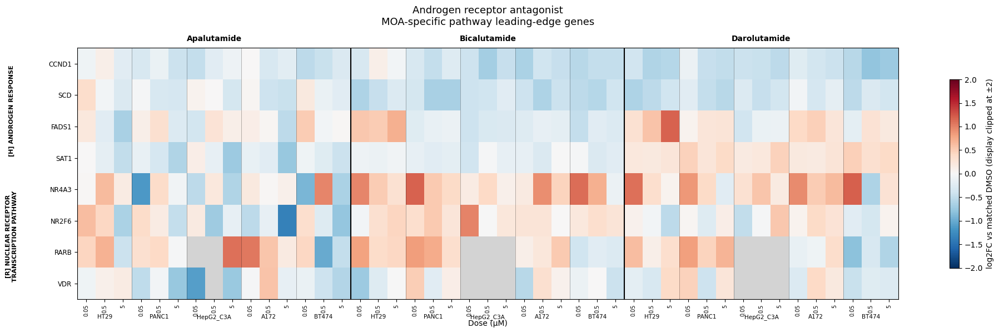

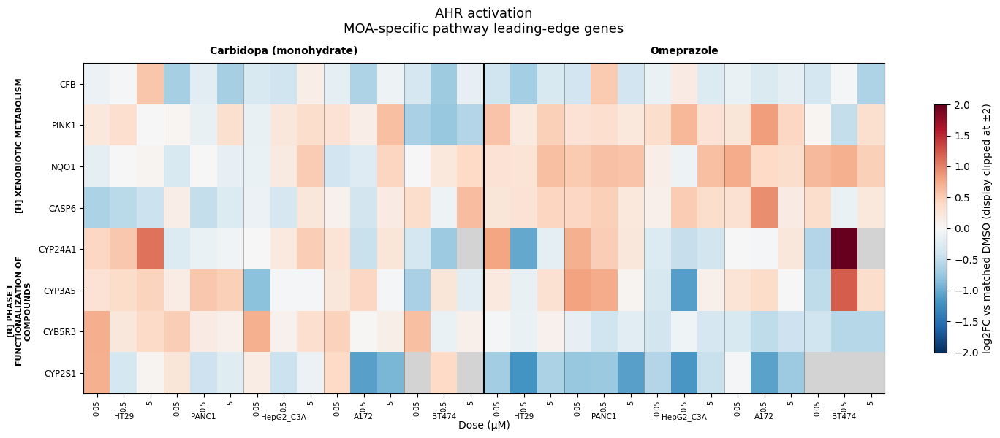

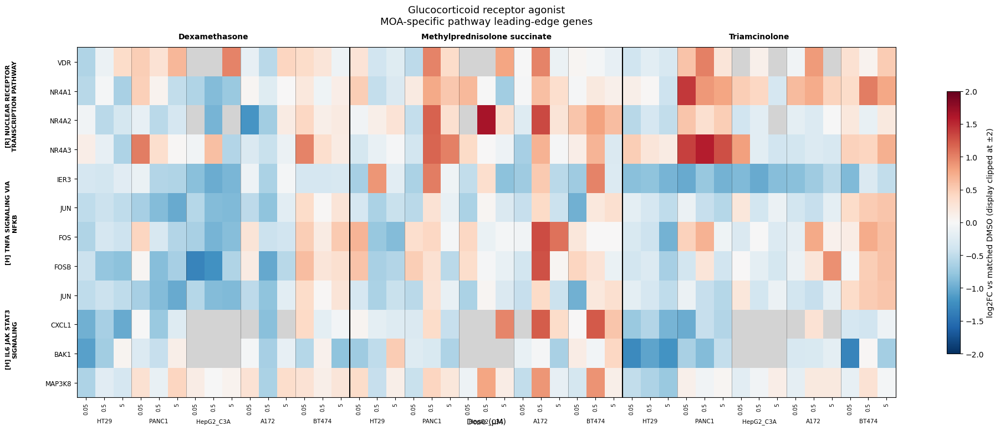

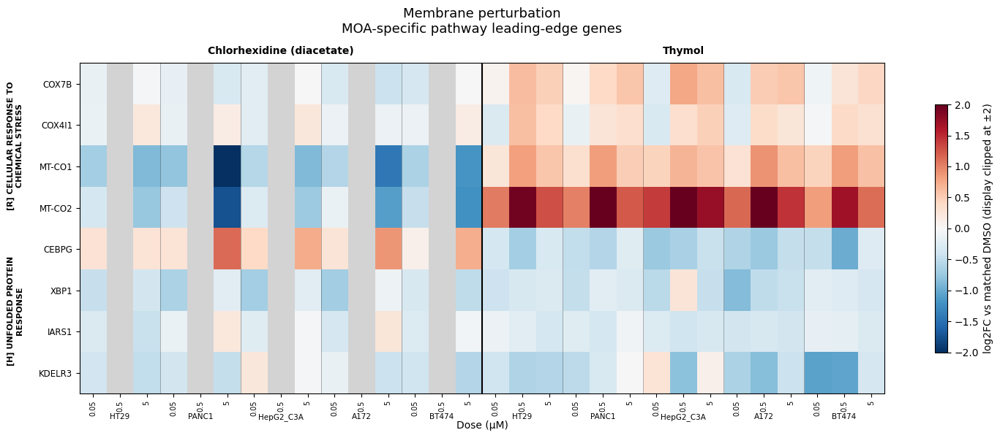

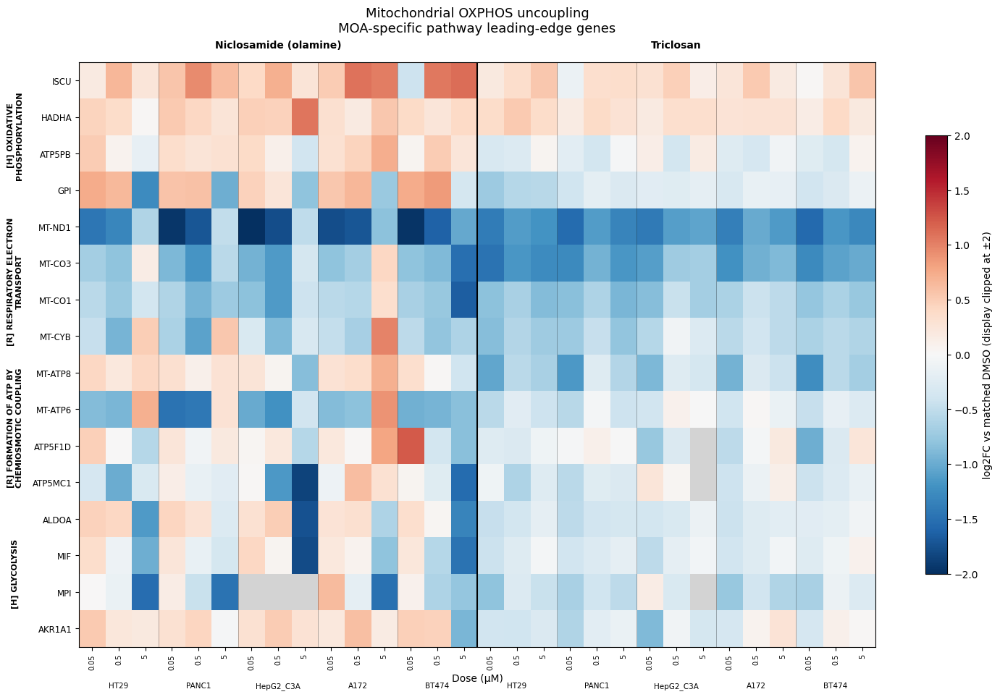

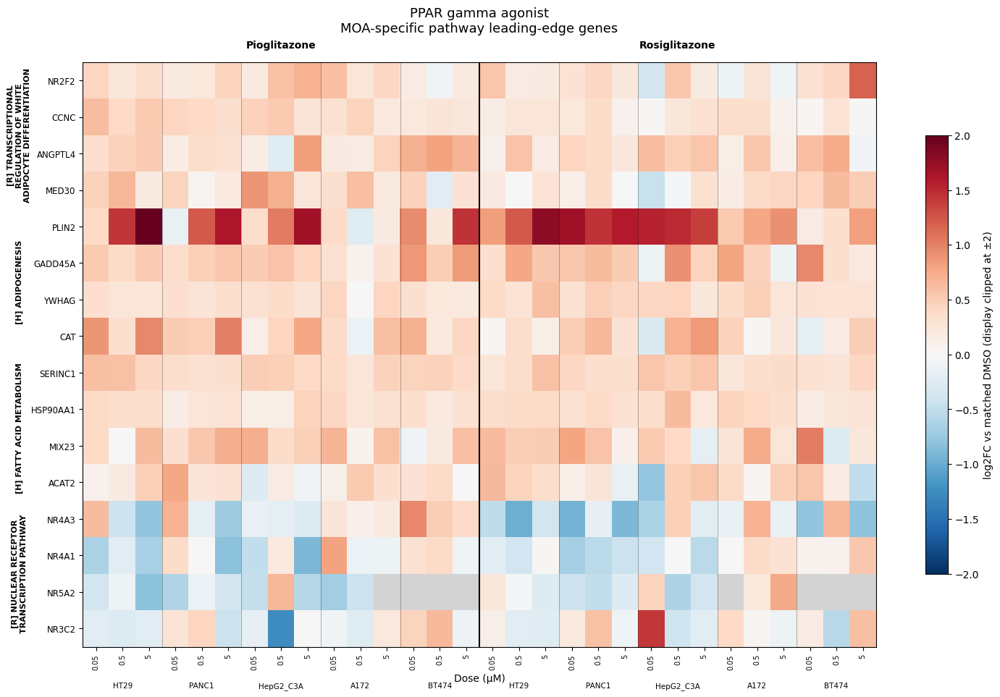

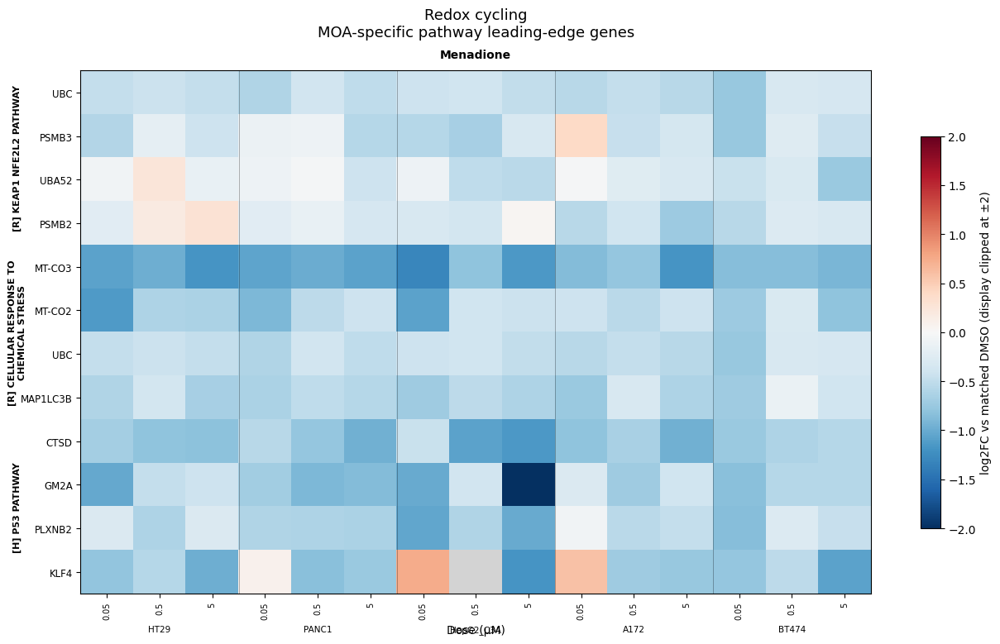

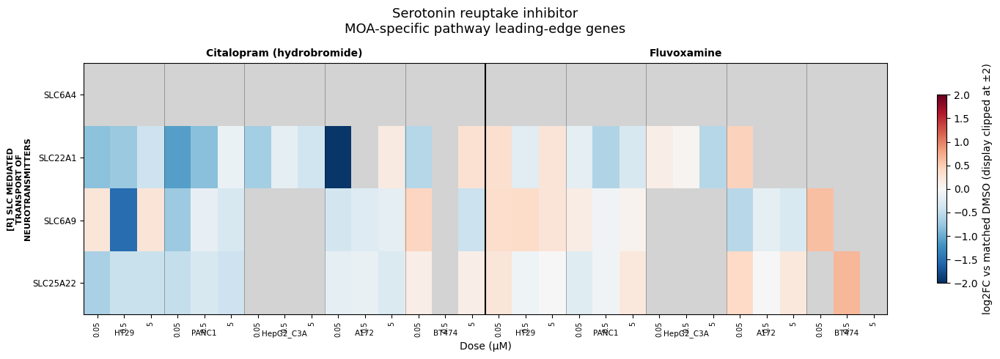


Saved to: /content/drive/MyDrive/Tahoe_project/results/gene_pathway/MOA_specific_leading_edge


In [ ]:
# Family-level MOA-specific gene heatmaps
import textwrap
CELL_ORDER = [
    "HT29",
    "PANC1",
    "HepG2_C3A",
    "A172",
    "BT474",
]

DOSE_ORDER = [
    0.05,
    0.5,
    5.0,
]


def get_gene_lfc_and_elig(
    condition_id,
    gene,
):

    i = adata.obs_names.get_loc(
        condition_id
    )

    idxs = symbol_to_indices.get(
        gene.upper(),
        []
    )

    if len(idxs) == 0:
        return np.nan, False


    x = adata.X[i, idxs]

    e = adata.layers[
        "expression_eligible"
    ][i, idxs]


    if sparse.issparse(x):
        x = x.toarray()

    if sparse.issparse(e):
        e = e.toarray()


    x = np.asarray(x).ravel()

    e = (
        np.asarray(e)
        .ravel()
        .astype(bool)
    )


    if not e.any():
        return np.nan, False


    return (
        float(np.mean(x[e])),
        True,
    )


def pretty_pathway(term):

    name = (
        term
        .replace("HALLMARK_", "")
        .replace("REACTOME_", "")
        .replace("_", " ")
    )

    if term.startswith("HALLMARK_"):
        return "[H] " + name

    if term.startswith("REACTOME_"):
        return "[R] " + name

    return name


def safe_name(x):

    return re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        x,
    ).strip("_")


# ------------------------------------------------------------
# Create all family heatmaps
# ------------------------------------------------------------

for family, pathways in FAMILY_SPECIFIC.items():

    family_drugs = [
        drug
        for drug, fam
        in DRUG_TO_FAMILY.items()
        if fam == family
    ]


    # --------------------------------------------------------
    # Selected genes for each pathway
    # --------------------------------------------------------

    selected = []

    pathway_ranges = []

    row_start = 0


    for pathway in pathways:

        if pathway == SLC_TERM:

            genes = (
                slc_top["gene"]
                .tolist()
            )

        else:

            genes = (
                top_genes.loc[
                    (top_genes["family"] == family)
                    & (
                        top_genes["pathway"]
                        == pathway
                    )
                ]
                .sort_values(
                    "pathway_rank"
                )["gene"]
                .tolist()
            )


        if len(genes) == 0:
            print(
                "WARNING: no selected genes:",
                family,
                pathway,
            )
            continue


        for gene in genes:

            selected.append({
                "pathway": pathway,
                "gene": gene,
            })


        row_end = (
            row_start
            + len(genes)
        )

        pathway_ranges.append({
            "pathway": pathway,
            "start": row_start,
            "end": row_end,
        })

        row_start = row_end


    selected_df = pd.DataFrame(
        selected
    )


    # --------------------------------------------------------
    # Desired columns:
    # drug × cell line × dose
    # --------------------------------------------------------

    col_info = []


    for drug in family_drugs:

        for cell in CELL_ORDER:

            for dose in DOSE_ORDER:

                matches = obs_meta.index[
                    (obs_meta["drug"] == drug)
                    & (
                        obs_meta["cell_line"]
                        .astype(str)
                        == cell
                    )
                    & np.isclose(
                        pd.to_numeric(
                            obs_meta[
                                "concentration"
                            ]
                        ),
                        dose,
                    )
                ].tolist()


                cid = (
                    matches[0]
                    if len(matches) == 1
                    else None
                )


                col_info.append({
                    "drug": drug,
                    "cell_line": cell,
                    "dose": dose,
                    "condition_id": cid,
                })


    n_rows = len(selected_df)
    n_cols = len(col_info)


    heat = np.full(
        (n_rows, n_cols),
        np.nan,
        dtype=float,
    )


    # --------------------------------------------------------
    # Fill matrix
    # --------------------------------------------------------

    for r, row in selected_df.iterrows():

        gene = row["gene"]

        for c, info in enumerate(col_info):

            cid = info["condition_id"]

            if cid is None:
                continue


            lfc, eligible = (
                get_gene_lfc_and_elig(
                    cid,
                    gene,
                )
            )


            if eligible:
                heat[r, c] = lfc


    # --------------------------------------------------------
    # Save numeric matrix
    # --------------------------------------------------------

    column_index = pd.MultiIndex.from_tuples(
        [
            (
                x["drug"],
                x["cell_line"],
                x["dose"],
            )
            for x in col_info
        ],
        names=[
            "drug",
            "cell_line",
            "dose",
        ],
    )


    row_index = pd.MultiIndex.from_frame(
        selected_df[
            ["pathway", "gene"]
        ]
    )


    heat_df = pd.DataFrame(
        heat,
        index=row_index,
        columns=column_index,
    )


    heat_df.to_csv(
        LE_DIR
        / (
            safe_name(family)
            + "_top4_gene_log2FC_matrix.csv"
        )
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig_width = max(
        13,
        0.33 * n_cols + 5,
    )

    fig_height = max(
        5,
        0.45 * n_rows + 2.5,
    )


    fig, ax = plt.subplots(
        figsize=(
            fig_width,
            fig_height,
        )
    )


    cmap = plt.get_cmap(
        "RdBu_r"
    ).copy()

    cmap.set_bad(
        "lightgray"
    )


    im = ax.imshow(

        np.ma.masked_invalid(
            heat
        ),

        aspect="auto",

        cmap=cmap,

        vmin=-2,
        vmax=2,
    )


    # --------------------------------------------------------
    # Y: genes
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(n_rows)
    )

    ax.set_yticklabels(
        selected_df["gene"],
        fontsize=8.5,
    )


    # pathway block labels + separators
    for k, block in enumerate(
        pathway_ranges
    ):

        start = block["start"]
        end = block["end"]

        center = (
            start
            + end
            - 1
        ) / 2



        pathway_label = pretty_pathway(
            block["pathway"]
        )

        # 긴 pathway 이름 자동 줄바꿈
        pathway_label = "\n".join(
            textwrap.wrap(
                pathway_label,
                width=25,   # 원하는 길이에 맞게 조절
            )
        )

        ax.text(
            -0.08,
            center,

            pathway_label,

            transform=ax.get_yaxis_transform(),

            ha="center",
            va="center",

            rotation=90,        # pathway 이름을 세로 방향으로
            rotation_mode="anchor",

            fontsize=8,
            fontweight="bold",
        )

    # --------------------------------------------------------
    # X: dose labels only
    # --------------------------------------------------------

    xlabels = [
        f"{x['dose']:g}"
        for x in col_info
    ]


    ax.set_xticks(
        np.arange(n_cols)
    )

    ax.set_xticklabels(
        xlabels,
        rotation=90,
        fontsize=7,
    )


    ax.set_xlabel(
        "Dose (µM)"
    )


    # --------------------------------------------------------
    # Cell-line separators
    # --------------------------------------------------------

    for d, drug in enumerate(
        family_drugs
    ):

        drug_start = (
            d
            * len(CELL_ORDER)
            * len(DOSE_ORDER)
        )


        # cell-line labels
        for j, cell in enumerate(
            CELL_ORDER
        ):

            start = (
                drug_start
                + j * 3
            )

            center = start + 1


            ax.text(

                center,
                -0.06,

                cell,

                transform=ax.get_xaxis_transform(),

                ha="center",
                va="top",

                fontsize=7.5,
            )


            if j > 0:

                ax.axvline(
                    start - 0.5,
                    linewidth=0.5,
                    color="black",
                    alpha=0.4,
                )


        # drug separator
        if d > 0:

            ax.axvline(
                drug_start - 0.5,
                linewidth=1.5,
                color="black",
            )


        # drug label above plot
        center = (
            drug_start
            + 7
        )


        ax.text(

            center,
            1.02,

            drug,

            transform=ax.get_xaxis_transform(),

            ha="center",
            va="bottom",

            fontsize=10,
            fontweight="bold",
        )


    # --------------------------------------------------------
    # Title / colorbar
    # --------------------------------------------------------

    ax.set_title(
        f"{family}\n"
        "MOA-specific pathway leading-edge genes",
        fontsize=13,
        pad=30,
    )


    cbar = fig.colorbar(
        im,
        ax=ax,
        shrink=0.75,
    )

    cbar.set_label(
        "log2FC vs matched DMSO "
        "(display clipped at ±2)"
    )


    plt.tight_layout()


    fig.savefig(

        LE_DIR
        / (
            safe_name(family)
            + "_top4_leading_edge_heatmap.png"
        ),

        dpi=220,
        bbox_inches="tight",
    )


    plt.show()


print(
    "\nSaved to:",
    LE_DIR
)

# Concordance analysis - cross cell line / cross compounds within MOA class

In [ ]:
print(type(hallmark_sets))
print(type(reactome_sets))

print(list(hallmark_sets.keys())[:5])
print(list(reactome_sets.keys())[:5])

<class 'dict'>
<class 'dict'>
['HALLMARK_ADIPOGENESIS', 'HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_ANDROGEN_RESPONSE', 'HALLMARK_ANGIOGENESIS', 'HALLMARK_APICAL_JUNCTION']
['REACTOME_2_LTR_CIRCLE_FORMATION', 'REACTOME_ABACAVIR_ADME', 'REACTOME_ABACAVIR_TRANSMEMBRANE_TRANSPORT', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT', 'REACTOME_ABC_TRANSPORTERS_IN_LIPID_HOMEOSTASIS']


In [ ]:
# Build full MOA-specific pathway gene universes

MOA_GENE_DIR = RESULTS / "MOA_gene_concordance"
MOA_GENE_DIR.mkdir(parents=True, exist_ok=True)


family_gene_sets = {}
family_pathway_gene_sets = {}


for family, pathways in FAMILY_SPECIFIC.items():

    pathway_sets = {}

    for pathway in pathways:

        # --------------------------------------------
        # Hallmark
        # --------------------------------------------
        if pathway.startswith("HALLMARK_"):

            genes = hallmark_sets.get(
                pathway,
                []
            )

        # --------------------------------------------
        # Reactome
        # --------------------------------------------
        elif pathway.startswith("REACTOME_"):

            genes = reactome_sets.get(
                pathway,
                []
            )

        else:
            genes = []


        genes = {
            str(g).strip().upper()
            for g in genes
            if str(g).strip()
        }

        pathway_sets[pathway] = genes


    family_pathway_gene_sets[family] = pathway_sets


    # union of ALL MOA-specific pathways
    union_genes = set().union(
        *pathway_sets.values()
    )

    family_gene_sets[family] = sorted(
        union_genes
    )


# summary
gene_universe_summary = pd.DataFrame(
    [
        {
            "family": family,
            "n_pathways": len(
                FAMILY_SPECIFIC[family]
            ),
            "n_unique_MOA_genes": len(genes),
        }
        for family, genes
        in family_gene_sets.items()
    ]
)


display(gene_universe_summary)

,family,n_pathways,n_unique_MOA_genes
0,Androgen receptor antagonist,2,154
1,AHR activation,2,281
2,Glucocorticoid receptor agonist,3,319
3,Membrane perturbation,2,307
4,Mitochondrial OXPHOS uncoupling,4,482
5,PPAR gamma agonist,4,451
6,Redox cycling,3,386
7,Serotonin reuptake inhibitor,1,21


In [ ]:
# Build condition × full-MOA-gene matrices

family_lfc_matrices = {}
family_elig_matrices = {}


for family, genes in family_gene_sets.items():

    family_drugs = [
        drug
        for drug, fam in DRUG_TO_FAMILY.items()
        if fam == family
    ]


    condition_ids = (
        obs_meta.index[
            obs_meta["drug"].isin(
                family_drugs
            )
        ]
        .tolist()
    )


    lfc_mat = pd.DataFrame(
        np.nan,
        index=condition_ids,
        columns=genes,
        dtype=float,
    )

    elig_mat = pd.DataFrame(
        False,
        index=condition_ids,
        columns=genes,
        dtype=bool,
    )


    for cid in condition_ids:

        for gene in genes:

            lfc, eligible = (
                get_gene_lfc_and_elig(
                    cid,
                    gene,
                )
            )

            if eligible:

                lfc_mat.loc[
                    cid,
                    gene
                ] = lfc

                elig_mat.loc[
                    cid,
                    gene
                ] = True


    family_lfc_matrices[family] = (
        lfc_mat
    )

    family_elig_matrices[family] = (
        elig_mat
    )


    # save
    lfc_mat.to_csv(
        MOA_GENE_DIR
        / (
            safe_name(family)
            + "_full_MOA_gene_log2FC.csv"
        )
    )


    print(
        family,
        "| genes:",
        len(genes),
        "| conditions:",
        len(condition_ids),
        "| median eligible genes:",
        int(
            elig_mat.sum(axis=1).median()
        ),
    )

Androgen receptor antagonist | genes: 154 | conditions: 45 | median eligible genes: 130
AHR activation | genes: 281 | conditions: 30 | median eligible genes: 162
Glucocorticoid receptor agonist | genes: 319 | conditions: 45 | median eligible genes: 244
Membrane perturbation | genes: 307 | conditions: 25 | median eligible genes: 274
Mitochondrial OXPHOS uncoupling | genes: 482 | conditions: 30 | median eligible genes: 435
PPAR gamma agonist | genes: 451 | conditions: 30 | median eligible genes: 367
Redox cycling | genes: 386 | conditions: 15 | median eligible genes: 335
Serotonin reuptake inhibitor | genes: 21 | conditions: 30 | median eligible genes: 4


In [ ]:
# Cross-cell-line concordance
#        using ALL MOA-specific pathway genes

from itertools import combinations


cellline_records = []


for family, lfc_mat in family_lfc_matrices.items():

    family_drugs = [
        drug
        for drug, fam in DRUG_TO_FAMILY.items()
        if fam == family
    ]


    for drug in family_drugs:

        for dose in DOSE_ORDER:

            for cell1, cell2 in combinations(
                CELL_ORDER,
                2,
            ):

                # find condition IDs
                def find_condition(cell):

                    hits = obs_meta.index[
                        (obs_meta["drug"] == drug)
                        & (
                            obs_meta["cell_line"]
                            .astype(str)
                            == cell
                        )
                        & np.isclose(
                            pd.to_numeric(
                                obs_meta["concentration"]
                            ),
                            dose,
                        )
                    ].tolist()

                    return (
                        hits[0]
                        if len(hits) == 1
                        else None
                    )


                cid1 = find_condition(cell1)
                cid2 = find_condition(cell2)


                if (
                    cid1 is None
                    or cid2 is None
                ):
                    continue


                x = lfc_mat.loc[cid1]
                y = lfc_mat.loc[cid2]


                # IMPORTANT:
                # use genes eligible in BOTH conditions
                valid = (
                    x.notna()
                    & y.notna()
                )

                n_shared = int(
                    valid.sum()
                )


                # require enough genes
                if n_shared < 15:

                    rho = np.nan

                else:

                    rho = x[valid].corr(
                        y[valid],
                        method="spearman",
                    )


                cellline_records.append({

                    "family": family,
                    "drug": drug,
                    "dose": dose,

                    "cell_line_1": cell1,
                    "cell_line_2": cell2,

                    "n_shared_MOA_genes":
                        n_shared,

                    "spearman_rho":
                        rho,
                })


cellline_pairwise_full = (
    pd.DataFrame(
        cellline_records
    )
)


cellline_pairwise_full.to_csv(
    MOA_GENE_DIR
    / "cross_cell_line_pairwise_full_MOA_genes.csv",
    index=False,
)

In [ ]:
# Cross-cell-line summary

cellline_summary_full = (
    cellline_pairwise_full
    .groupby(
        [
            "family",
            "drug",
            "dose",
        ],
        observed=True,
    )
    .agg(

        median_cross_cell_rho=(
            "spearman_rho",
            "median",
        ),

        mean_cross_cell_rho=(
            "spearman_rho",
            "mean",
        ),

        min_cross_cell_rho=(
            "spearman_rho",
            "min",
        ),

        max_cross_cell_rho=(
            "spearman_rho",
            "max",
        ),

        median_shared_genes=(
            "n_shared_MOA_genes",
            "median",
        ),

        n_valid_pairs=(
            "spearman_rho",
            "count",
        ),

    )
    .reset_index()
)


cellline_summary_full.to_csv(
    MOA_GENE_DIR
    / "cross_cell_line_summary_full_MOA_genes.csv",
    index=False,
)


display(
    cellline_summary_full.sort_values(
        "median_cross_cell_rho",
        ascending=False,
    )
)

,family,drug,dose,median_cross_cell_rho,mean_cross_cell_rho,min_cross_cell_rho,max_cross_cell_rho,median_shared_genes,n_valid_pairs
28,Membrane perturbation,Thymol,5.00,0.672037,0.684716,0.617243,0.778480,263.0,10
25,Membrane perturbation,Chlorhexidine (diacetate),5.00,0.537681,0.538965,0.456040,0.688649,262.0,10
34,Mitochondrial OXPHOS uncoupling,Triclosan,5.00,0.529751,0.533345,0.429583,0.643012,403.0,10
24,Membrane perturbation,Chlorhexidine (diacetate),0.05,0.510320,0.524033,0.478924,0.629741,267.5,10
32,Mitochondrial OXPHOS uncoupling,Triclosan,0.05,0.491059,0.476419,0.346883,0.618791,415.5,10
37,PPAR gamma agonist,Pioglitazone,5.00,0.480893,0.482787,0.376379,0.588953,335.0,10
27,Membrane perturbation,Thymol,0.50,0.472642,0.462803,0.343508,0.573689,271.0,10
43,Redox cycling,Menadione,5.00,0.464198,0.459007,0.395881,0.542660,320.0,10
21,Glucocorticoid receptor agonist,Triamcinolone,0.05,0.461730,0.463391,0.366424,0.537042,221.5,10
23,Glucocorticoid receptor agonist,Triamcinolone,5.00,0.458604,0.451949,0.231483,0.603940,215.0,10


In [ ]:
# Cell-line-specific concordance

records = []


for _, row in (
    cellline_pairwise_full.iterrows()
):

    rho = row["spearman_rho"]

    if pd.isna(rho):
        continue


    for cell in [
        row["cell_line_1"],
        row["cell_line_2"],
    ]:

        records.append({

            "family":
                row["family"],

            "drug":
                row["drug"],

            "dose":
                row["dose"],

            "cell_line":
                cell,

            "rho_to_other_cell_line":
                rho,
        })


cellline_specific_full = (
    pd.DataFrame(records)
    .groupby(
        [
            "family",
            "drug",
            "dose",
            "cell_line",
        ],
        observed=True,
    )
    .agg(

        median_rho_to_others=(
            "rho_to_other_cell_line",
            "median",
        ),

        mean_rho_to_others=(
            "rho_to_other_cell_line",
            "mean",
        ),

        n_comparisons=(
            "rho_to_other_cell_line",
            "count",
        ),

    )
    .reset_index()
)


cellline_specific_full.to_csv(
    MOA_GENE_DIR
    / "cell_line_specific_full_MOA_genes.csv",
    index=False,
)


display(
    cellline_specific_full
    .sort_values(
        "median_rho_to_others"
    )
    .head(30)
)

,family,drug,dose,cell_line,median_rho_to_others,mean_rho_to_others,n_comparisons
1,AHR activation,Carbidopa (monohydrate),0.05,BT474,0.137815,0.143293,4
6,AHR activation,Carbidopa (monohydrate),0.50,BT474,0.156750,0.189512,4
20,AHR activation,Omeprazole,0.50,A172,0.186319,0.229792,4
181,PPAR gamma agonist,Pioglitazone,0.50,BT474,0.195019,0.222676,4
21,AHR activation,Omeprazole,0.50,BT474,0.195845,0.221686,4
203,PPAR gamma agonist,Rosiglitazone,5.00,HepG2_C3A,0.207324,0.224793,4
183,PPAR gamma agonist,Pioglitazone,0.50,HepG2_C3A,0.221708,0.245067,4
81,Glucocorticoid receptor agonist,Dexamethasone,0.50,BT474,0.222761,0.253504,4
66,Androgen receptor antagonist,Darolutamide,0.50,BT474,0.224184,0.254174,4
193,PPAR gamma agonist,Rosiglitazone,0.05,HepG2_C3A,0.225004,0.225605,4


In [ ]:
# Within-MOA cross-drug concordance

cross_drug_records = []


for family, lfc_mat in (
    family_lfc_matrices.items()
):

    family_drugs = [
        drug
        for drug, fam
        in DRUG_TO_FAMILY.items()
        if fam == family
    ]


    if len(family_drugs) < 2:
        continue


    for drug1, drug2 in combinations(
        family_drugs,
        2,
    ):

        for cell in CELL_ORDER:

            for dose in DOSE_ORDER:


                def find_condition(drug):

                    hits = obs_meta.index[
                        (obs_meta["drug"] == drug)
                        & (
                            obs_meta["cell_line"]
                            .astype(str)
                            == cell
                        )
                        & np.isclose(
                            pd.to_numeric(
                                obs_meta[
                                    "concentration"
                                ]
                            ),
                            dose,
                        )
                    ].tolist()

                    return (
                        hits[0]
                        if len(hits) == 1
                        else None
                    )


                cid1 = find_condition(drug1)
                cid2 = find_condition(drug2)


                if (
                    cid1 is None
                    or cid2 is None
                ):
                    continue


                x = lfc_mat.loc[cid1]
                y = lfc_mat.loc[cid2]

                valid = (
                    x.notna()
                    & y.notna()
                )

                n_shared = int(
                    valid.sum()
                )


                if n_shared < 15:

                    rho = np.nan

                else:

                    rho = x[valid].corr(
                        y[valid],
                        method="spearman",
                    )


                cross_drug_records.append({

                    "family":
                        family,

                    "drug_1":
                        drug1,

                    "drug_2":
                        drug2,

                    "cell_line":
                        cell,

                    "dose":
                        dose,

                    "n_shared_MOA_genes":
                        n_shared,

                    "spearman_rho":
                        rho,
                })


cross_drug_full = pd.DataFrame(
    cross_drug_records
)


cross_drug_summary_full = (
    cross_drug_full
    .groupby(
        [
            "family",
            "drug_1",
            "drug_2",
            "dose",
        ],
        observed=True,
    )
    .agg(

        median_rho_across_cell_lines=(
            "spearman_rho",
            "median",
        ),

        mean_rho_across_cell_lines=(
            "spearman_rho",
            "mean",
        ),

        median_shared_genes=(
            "n_shared_MOA_genes",
            "median",
        ),

        n_valid_cell_lines=(
            "spearman_rho",
            "count",
        ),

    )
    .reset_index()
)


cross_drug_full.to_csv(
    MOA_GENE_DIR
    / "within_MOA_cross_drug_full_MOA_genes.csv",
    index=False,
)


cross_drug_summary_full.to_csv(
    MOA_GENE_DIR
    / "within_MOA_cross_drug_summary_full_MOA_genes.csv",
    index=False,
)


display(
    cross_drug_summary_full.sort_values(
        "median_rho_across_cell_lines",
        ascending=False,
    )
)

,family,drug_1,drug_2,dose,median_rho_across_cell_lines,mean_rho_across_cell_lines,median_shared_genes,n_valid_cell_lines
9,Androgen receptor antagonist,Bicalutamide,Darolutamide,0.05,0.586290,0.563144,129.0,5
17,Glucocorticoid receptor agonist,Dexamethasone,Triamcinolone,5.00,0.488017,0.448114,234.0,5
21,Membrane perturbation,Chlorhexidine (diacetate),Thymol,0.05,0.409168,0.406628,275.0,5
10,Androgen receptor antagonist,Bicalutamide,Darolutamide,0.50,0.401412,0.376656,130.0,5
16,Glucocorticoid receptor agonist,Dexamethasone,Triamcinolone,0.50,0.385999,0.375039,236.0,5
11,Androgen receptor antagonist,Bicalutamide,Darolutamide,5.00,0.334384,0.389447,129.0,5
15,Glucocorticoid receptor agonist,Dexamethasone,Triamcinolone,0.05,0.301472,0.351885,235.0,5
27,PPAR gamma agonist,Pioglitazone,Rosiglitazone,0.50,0.286999,0.277282,362.0,5
20,Glucocorticoid receptor agonist,Methylprednisolone succinate,Triamcinolone,5.00,0.281907,0.268674,236.0,5
4,Androgen receptor antagonist,Apalutamide,Bicalutamide,0.50,0.245954,0.253343,130.0,5


# Visualize

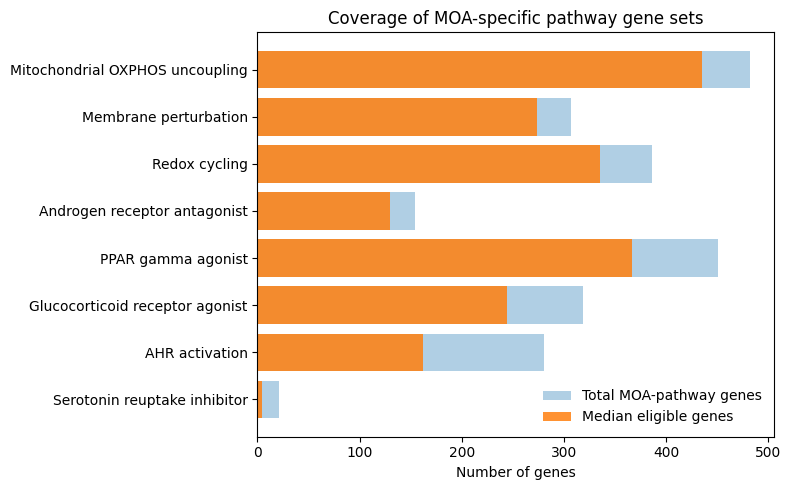

In [ ]:
# A. MOA gene coverage

coverage_df = gene_universe_summary.copy()

median_eligible = {
    family: int(
        family_elig_matrices[family]
        .sum(axis=1)
        .median()
    )
    for family in family_elig_matrices
}

coverage_df["median_eligible_genes"] = (
    coverage_df["family"]
    .map(median_eligible)
)

coverage_df["coverage_fraction"] = (
    coverage_df["median_eligible_genes"]
    / coverage_df["n_unique_MOA_genes"]
)


plot_df = (
    coverage_df
    .sort_values("coverage_fraction")
)


fig, ax = plt.subplots(figsize=(8, 5))

y = np.arange(len(plot_df))


# total MOA universe
ax.barh(
    y,
    plot_df["n_unique_MOA_genes"],
    alpha=0.35,
    label="Total MOA-pathway genes",
)

# median eligible
ax.barh(
    y,
    plot_df["median_eligible_genes"],
    alpha=0.85,
    label="Median eligible genes",
)


ax.set_yticks(y)
ax.set_yticklabels(plot_df["family"])

ax.set_xlabel("Number of genes")
ax.set_title("Coverage of MOA-specific pathway gene sets")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
import textwrap

def add_family_blocks(
    ax,
    heat_index,
    x=-0.22,
    wrap_width=22,
):
    """
    Add MOA-family labels and separators.

    - MOA labels: vertical + automatic line wrapping
    - Family separators: thick black lines
    """

    families = heat_index.get_level_values(0)

    blocks = []
    start = 0

    for i in range(1, len(families) + 1):

        if (
            i == len(families)
            or families[i] != families[start]
        ):

            blocks.append(
                (
                    families[start],
                    start,
                    i - 1,
                )
            )

            start = i


    for k, (family, first, last) in enumerate(blocks):

        center = (first + last) / 2

        # --------------------------------------------
        # Wrap long MOA names
        # --------------------------------------------

        family_label = "\n".join(
            textwrap.wrap(
                str(family),
                width=12,
            )
        )
        # --------------------------------------------
        # MOA family label
        # --------------------------------------------
        ax.text(
            x,
            center,
            family_label,

            transform=ax.get_yaxis_transform(),

            ha="center",
            va="center",

            rotation=90,
            rotation_mode="anchor",

            fontsize=8,
            fontweight="bold",

            clip_on=False,
        )

        # --------------------------------------------
        # Thick BLACK separator
        # --------------------------------------------
        if k > 0:

            ax.axhline(
                first - 0.5,

                color="black",
                linewidth=2.0,
                zorder=10,
            )

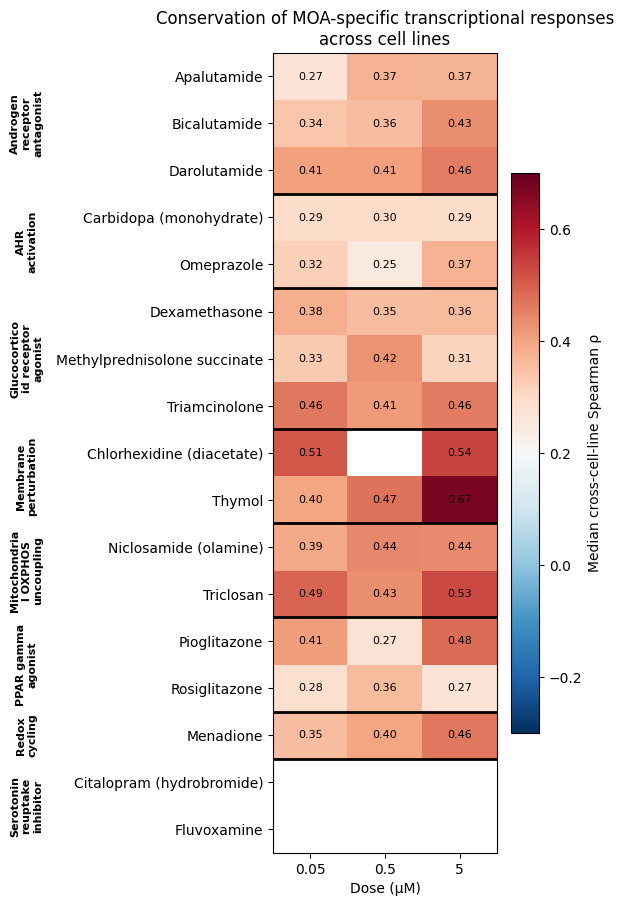

In [ ]:
# B. Cross-cell-line concordance

plot_df = (
    cellline_summary_full
    .copy()
)

family_order = list(FAMILY_SPECIFIC.keys())

plot_df["family"] = pd.Categorical(
    plot_df["family"],
    categories=family_order,
    ordered=True,
)

plot_df = plot_df.sort_values(
    ["family", "drug", "dose"]
)

heat = (
    plot_df
    .pivot(
        index=["family", "drug"],
        columns="dose",
        values="median_cross_cell_rho",
    )
)


fig, ax = plt.subplots(
    figsize=(7, 10)
)

im = ax.imshow(
    heat.values,
    aspect="auto",
    vmin=-0.3,
    vmax=0.7,
    cmap="RdBu_r",
)


ax.set_xticks(
    np.arange(len(heat.columns))
)

ax.set_xticklabels(
    [
        f"{x:g}"
        for x in heat.columns
    ]
)

ax.set_xlabel("Dose (µM)")


drug_labels = [
    drug
    for family, drug
    in heat.index
]

ax.set_yticks(
    np.arange(len(drug_labels))
)

ax.set_yticklabels(
    drug_labels
)


# write rho inside cells
for i in range(
    heat.shape[0]
):

    for j in range(
        heat.shape[1]
    ):

        val = heat.iloc[i, j]

        if pd.notna(val):

            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )


cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.7,
)

cbar.set_label(
    "Median cross-cell-line Spearman ρ"
)


ax.set_title(
    "Conservation of MOA-specific transcriptional responses\n"
    "across cell lines"
)

add_family_blocks(
    ax,
    heat.index,
    x=-1.1,
    wrap_width=22,
)

plt.subplots_adjust(
    left=0.48,
    right=0.88,
    top=0.90,
    bottom=0.10,
)
plt.show()

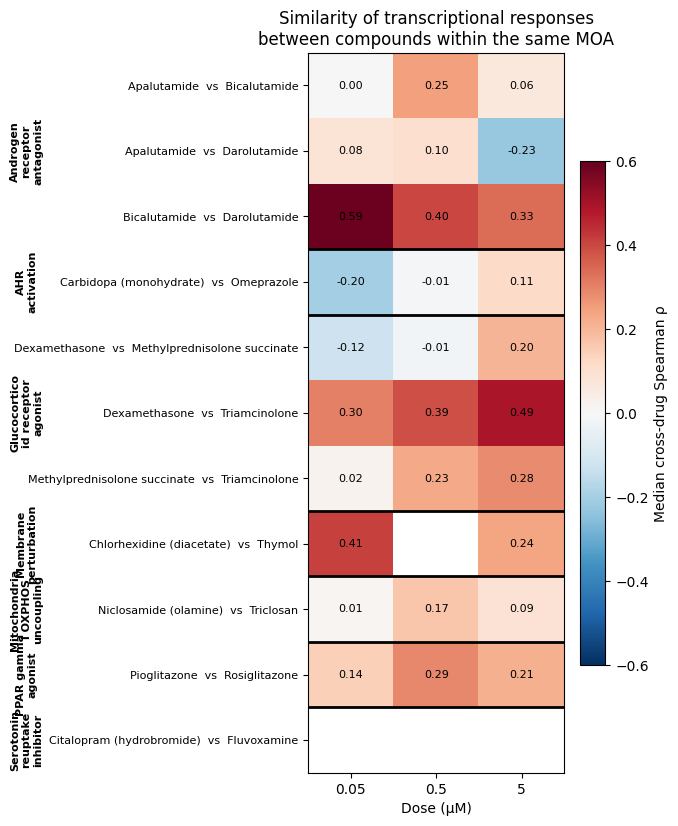

In [ ]:
# Within-MOA cross-drug concordance

plot_df = (
    cross_drug_summary_full
    .copy()
)

family_order = list(FAMILY_SPECIFIC.keys())

plot_df["family"] = pd.Categorical(
    plot_df["family"],
    categories=family_order,
    ordered=True,
)

plot_df = plot_df.sort_values(
    ["family", "drug_1", "drug_2", "dose"]
)

plot_df["drug_pair"] = (
    plot_df["drug_1"]
    + "  vs  "
    + plot_df["drug_2"]
)


heat = (
    plot_df
    .pivot(
        index=["family", "drug_pair"],
        columns="dose",
        values="median_rho_across_cell_lines",
    )
)


fig, ax = plt.subplots(
    figsize=(8, 9)
)


im = ax.imshow(
    heat.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.6,
    vmax=0.6,
)


ax.set_xticks(
    np.arange(len(heat.columns))
)

ax.set_xticklabels(
    [
        f"{x:g}"
        for x in heat.columns
    ]
)

ax.set_xlabel("Dose (µM)")


pair_labels = [
    pair
    for family, pair
    in heat.index
]

ax.set_yticks(
    np.arange(len(pair_labels))
)

ax.set_yticklabels(
    pair_labels,
    fontsize=8,
)


for i in range(
    heat.shape[0]
):

    for j in range(
        heat.shape[1]
    ):

        val = heat.iloc[i, j]

        if pd.notna(val):

            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )


cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.7,
)

cbar.set_label(
    "Median cross-drug Spearman ρ"
)


ax.set_title(
    "Similarity of transcriptional responses\n"
    "between compounds within the same MOA"
)

add_family_blocks(
    ax,
    heat.index,
    x=-1.1,
)
plt.subplots_adjust(
    left=0.48,
    right=0.88,
    top=0.90,
    bottom=0.10,
)
plt.show()

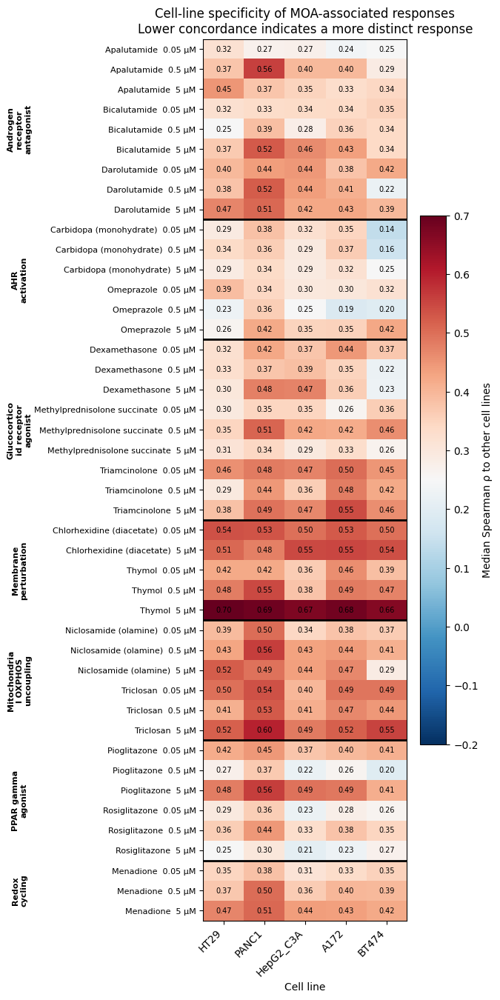

In [ ]:
# D. Cell-line-specific concordance heatmap

plot_df = (
    cellline_specific_full
    .copy()
)



# ------------------------------------------------------------
# Keep MOA family order
# ------------------------------------------------------------

family_order = list(FAMILY_SPECIFIC.keys())

plot_df["family"] = pd.Categorical(
    plot_df["family"],
    categories=family_order,
    ordered=True,
)

plot_df = plot_df.sort_values(
    [
        "family",
        "drug",
        "dose",
        "cell_line",
    ]
)

# ------------------------------------------------------------
# Row label = drug + dose
# ------------------------------------------------------------

plot_df["condition_label"] = (
    plot_df["drug"]
    + "  "
    + plot_df["dose"]
        .map(lambda x: f"{x:g} µM")
)


# ------------------------------------------------------------
# Pivot
# ------------------------------------------------------------

heat = (
    plot_df
    .pivot(
        index=[
            "family",
            "drug",
            "dose",
            "condition_label",
        ],
        columns="cell_line",
        values="median_rho_to_others",
    )
)


# force desired cell-line order
heat = heat.reindex(
    columns=CELL_ORDER
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 14)
)


im = ax.imshow(
    heat.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.2,
    vmax=0.7,
)


# ------------------------------------------------------------
# X axis
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(heat.columns)
    )
)

ax.set_xticklabels(
    heat.columns,
    rotation=45,
    ha="right",
)

ax.set_xlabel(
    "Cell line"
)


# ------------------------------------------------------------
# Y axis
# ------------------------------------------------------------

condition_labels = (
    heat.index
    .get_level_values(
        "condition_label"
    )
)


ax.set_yticks(
    np.arange(
        len(condition_labels)
    )
)

ax.set_yticklabels(
    condition_labels,
    fontsize=8,
)


# ------------------------------------------------------------
# Numbers inside cells
# ------------------------------------------------------------

for i in range(
    heat.shape[0]
):

    for j in range(
        heat.shape[1]
    ):

        val = heat.iloc[i, j]

        if pd.notna(val):

            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=7,
            )


# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.6,
)

cbar.set_label(
    "Median Spearman ρ to other cell lines"
)


# ------------------------------------------------------------
# MOA family blocks
# ------------------------------------------------------------

add_family_blocks(
    ax,
    heat.index,
    x=-0.9,
    wrap_width=12,
)


ax.set_title(
    "Cell-line specificity of MOA-associated responses\n"
    "Lower concordance indicates a more distinct response"
)


plt.subplots_adjust(
    left=0.45,
    right=0.88,
    top=0.93,
    bottom=0.08,
)

plt.show()